# FR10 — Financial condition, production efficiency and market position of enterprises and productions

**MIIS module 15.5.2 — Microeconomic analysis and forecasting.** Ministry of Economy of the Republic of Azerbaijan.

## The requirement (approved wording, 24 August 2026)

> *"Müəssisələrin və istehsalatların maliyyə vəziyyəti, istehsal effektivliyi və bazar paylarının təhlili və
> proqnozlaşdırılması mümkün olmalıdır."*

FR10 must deliver an analytical assessment, a comparative analysis and a forecast of the **financial condition**,
the **production efficiency** and the **market position** of enterprises and productions, by linking enterprise,
financial, production and market indicators from several sources. Its six goals are: (1) assess and compare
performance efficiency; (2) identify growth or decline of production indicators; (3) compare by region, activity,
product and other breakdowns; (4) identify the key factors behind development or decline; (5) forecast production
and market indicators; (6) give decision makers a data-driven analytical capacity. It must **not** be limited to
presenting financial data, and it must state concretely **which data, from which source, are used for which
indicator, and in which form they reach the user** (Part 8 and `output/FR10_data_source_matrix.csv`).

## Constraints set by the requester (as in FR1–FR5)

- **No autoregressive models** — no AR, ARIMA, ARCH, GARCH, no lagged dependent variable, no variable forecast from
  its own history. Part 9 lists every lag construct that does appear and why it is not an autoregression.
- **Structural econometric models** that show the effect of related sectors: every branch forecast in FR10 is
  conditional on FR1's sector paths (manufacturing, mining, electricity, water value added and their deflators,
  oil price), FR3's branch wages and FR4's employment.
- **Where the workbook lacks data, collect it from DSK** (Part 4): 120+ DSK tables are downloaded once into
  `data/dsk_enterprise/` and re-read from disk afterwards.
- **NFR1**: forecast accuracy tested against simple benchmarks, using only data available at the forecast time
  (Part 13, rolling origins scored ≤ 2019, untouched 2020–2025 hold-out).

## Two layers

| Layer | Unit of analysis | Data | Status |
|---|---|---|---|
| **A — operational now** | "enterprise groups": 30 industrial branches (NACE 06–09, 10–33, 35, 36–39), size classes, state / non-state, 14 economic regions, ~150 products | DSK industry, national-accounts, entrepreneurship and statistical-register tables; workbook `Emal Sənayesi`, `Mədənçıxarma`, `Elektrik enerjisi `, `Su təchizatı`, `Real sektor`, `DVX üzrə göstəricilər`, `KOBİA`, `Park`, `Regionlar*` | **Results** (Parts 4–16) |
| **B — firm-level engine** | the individual enterprise | Tax Service / DSMF balance-sheet and P&L panel, requested 24 Aug 2026 (due 26 Aug 2026) — **not yet received** | **Pipeline only**, tested on a clearly labelled **SYNTHETIC** panel (Part 17); never mixed into Layer-A results |

Layer A is organised in the three pillars the requirement names:

1. **Market position** — branch shares of industrial and manufacturing output, concentration (HHI, CR4) across
   branches and regions, non-state share, SME share, regional distribution, product volumes, entry and exit.
2. **Production efficiency** — labour productivity, intermediate-consumption share, capital productivity,
   total factor productivity by growth accounting with **observed** cost shares, wage–productivity gap,
   innovation intensity.
3. **Financial condition** — gross operating surplus (GOS) margins by industrial section (national accounts) and a
   GOS proxy by branch (value added − wage bill), profit-tax declaration aggregates (DVX), investment self-financing,
   finished-goods stocks, SME assets and taxes.

## Relation to FR1, FR3 and FR4

| Module | Object | Supplies FR10 with |
|---|---|---|
| **FR1** | Sector output, prices, macro economy | Real value added and deflators of mining, manufacturing, electricity and water, oil export price, non-oil GDP, investment deflator; three scenarios and 500 baseline bootstrap draws (`FR1_fan_draws.csv`) |
| **FR3** | Wages | Average wage paths by industrial branch (`FR3_industry_branch_wages.csv`) |
| **FR4** | Employment | Hired employees by activity (`FR4_hired_by_activity.csv`) |
| **FR10** *(this notebook)* | Enterprise groups | — |

| Part | Content |
|---|---|
| 1–3 | Purpose; environment; econometric toolkit (validated against statsmodels) |
| 4–6 | Collecting DSK data; building the branch, region and product panels; data-integrity findings |
| 7 | Layer A analytics: market position, efficiency, financial condition |
| 8 | Indicator system: the data–source matrix, the gaps table, the presentation specification |
| 9 | Permitted lag constructs; specifications tested and rejected |
| 10 | Key factors: determinants panel of branch growth |
| 11–12 | The branch share system (manufacturing, mining) and the regional share system |
| 13 | Hold-out validation against random walk and constant growth |
| 14–15 | Forecast 2026–2030 under three FR1 scenarios; uncertainty bands |
| 16 | Plausibility against history; early-warning flags |
| 17 | Layer B — firm-level engine, its SYNTHETIC pipeline test, and (v2) the full firm-level econometric analysis: profitability, production function, TFP, distress, investment, market share, exports, parameter recovery |
| 18 | Identity checks, exports, presentation specification, findings, documentation |
| 19 | v2: equation registry, indicator catalogue, full forecast table, scenario engine, robustness and tornado, Azerbaijani strings |

> **Status note.** Layer B awaits the Tax Service / DSMF enterprise panel. Every Layer-B table and figure is
> produced from a seeded synthetic panel, carries the watermark **"SYNTHETIC — pipeline test, not results"**, is
> written to `output/FR10_SYNTHETIC_*.csv`, and is never used in a Layer-A result or in the findings.

## Part 2 — Environment and reproducibility

Inputs: the workbook, the DSK tables in `data/dsk_enterprise/` (downloaded on first run with a `Mozilla/5.0`
User-Agent and re-read from disk afterwards), and the FR1, FR3 and FR4 result files in `output/`. One seed drives
every random element (fan-chart resampling, parameter draws, wild bootstrap, the Layer-B synthetic panel); no
random number enters a point estimate or a baseline forecast of Layer A.

In [1]:
%matplotlib inline
import os, sys, re, json, math, warnings, unicodedata, urllib.request, copy
from pathlib import Path
import numpy as np, pandas as pd
from scipy import stats
import matplotlib, matplotlib.pyplot as plt
import xlrd, openpyxl

warnings.filterwarnings('ignore')
SEED = 20261001
pd.set_option('display.width', 230, 'display.max_columns', 60, 'display.max_rows', 200,
              'display.float_format', lambda v: f'{v:,.3f}')
plt.rcParams.update({'figure.figsize': (12, 5.5), 'figure.dpi': 105, 'font.size': 9, 'axes.grid': True,
                     'grid.alpha': 0.3, 'axes.spines.top': False, 'axes.spines.right': False,
                     'legend.frameon': False})
PAL = ['#1f77b4', '#d62728', '#2ca02c', '#ff7f0e', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22',
       '#17becf', '#393b79', '#b5cf6b', '#a55194', '#637939']

BASE = Path.cwd().resolve()            # the notebook's directory (nbconvert and Jupyter run in it)
assert (BASE / 'data').is_dir() and (BASE / 'output').is_dir(), f'run FR10.ipynb from the MicroUnit directory, not {BASE}'
XL   = BASE / 'data' / 'Statistik data dinamika 05.06.2026 +.xlsx'
DDIR = BASE / 'data' / 'dsk_enterprise'
OUT  = BASE / 'output'
OUT.mkdir(exist_ok=True); DDIR.mkdir(parents=True, exist_ok=True)

LAST_ACT  = 2025                      # last actual year
FC_YEARS  = list(range(2026, 2031))
H         = len(FC_YEARS)
SCEN      = ['Baseline', 'Adverse', 'Reform']
BASE_YR   = 2015                      # price base of chained volumes, as in FR1 and FR5
EST0      = 2005                      # first year of the branch estimation sample (national-accounts coverage)
SEL_END   = 2019                      # every selection score falls in years <= 2019
HOLD      = (2020, LAST_ACT)          # final hold-out window, used for no choice
SYN_MARK  = 'SYNTHETIC — pipeline test, not results'

print('python      ', sys.version.split()[0])
for m in ['numpy', 'pandas', 'scipy', 'statsmodels', 'matplotlib', 'xlrd', 'openpyxl']:
    try:
        mod = __import__(m); print(f'{m:<12}', getattr(mod, '__version__', 'n/a'))
    except ImportError:
        print(f'{m:<12} NOT INSTALLED')
print('workbook    ', XL.exists(), f'{XL.stat().st_size/1e6:.2f} MB' if XL.exists() else '')
print(f'last actual {LAST_ACT} | forecast {FC_YEARS[0]}-{FC_YEARS[-1]} | selection scores <= {SEL_END} | '
      f'hold-out {HOLD[0]}-{HOLD[1]} | seed {SEED}')

python       3.13.15
numpy        2.3.5
pandas       2.2.3
scipy        1.16.3
statsmodels  0.14.6
matplotlib   3.10.8
xlrd         2.0.1
openpyxl     3.1.5
workbook     True 3.43 MB
last actual 2025 | forecast 2026-2030 | selection scores <= 2019 | hold-out 2020-2025 | seed 20261001


### 2.1 Parsing conventions

Two traps carried over from FR1–FR5. (1) Azerbaijani casing: `'İ'.lower()` returns `i` + U+0307, which must be
folded, while the dotless `ı` must be preserved. (2) DSK cells stored as text: non-breaking-space thousands
separators, comma decimals, footnote asterisks, and — new in the industry tables — the suffix **`t.`** meaning
*thousand per cent* (`'7.8 t.'` = 7 800% of the base year). `to_num` handles all of them; the assertions below
keep a future edit from breaking any.

In [2]:
def az_lower(s):
    return unicodedata.normalize('NFC', str(s).lower().replace('̇', ''))

_BLANK = {'', '-', '–', '—', '...', '..', '…', 'x', 'n/a', 'N/A'}
def to_num(v):
    if v is None or isinstance(v, bool):
        return np.nan
    if isinstance(v, (int, float, np.floating)):
        return np.nan if (isinstance(v, float) and np.isnan(v)) else float(v)
    t = str(v).replace('\xa0', '').replace(' ', '').strip()
    mult = 1.0
    if re.search(r'\d\s*t\.?\s*$', t):          # DSK index tables: '7.8 t.' = thousand per cent
        mult = 1000.0; t = re.sub(r'\s*t\.?\s*$', '', t)
    t = t.replace(' ', '').rstrip('*').replace('%', '')
    if t in _BLANK:
        return np.nan
    if re.fullmatch(r'-?\d+,\d+', t):
        t = t.replace(',', '.')
    elif re.fullmatch(r'-?\d{1,3}(\.\d{3})+,\d+', t):
        t = t.replace('.', '').replace(',', '.')
    elif re.fullmatch(r'-?[1-9]\d{0,2}(\.\d{3})+', t):       # TEXT '1.581' = 1 581 (dot as thousands separator)
        t = t.replace('.', '')
    else:
        t = t.replace(',', '')
    try:
        return float(t) * mult
    except ValueError:
        return np.nan

for raw, want in [('7.8 t.', 7800.0), ('97,8 t.', 97800.0), ('33,0*', 33.0), ('4\xa0088\xa0188,1', 4088188.1),
                  ('…', np.nan), ('-', np.nan), (12.5, 12.5), ('1.234,5', 1234.5), ('108 .3', 108.3), ('1.581', 1581.0), (1.581, 1.581)]:
    got = to_num(raw)
    assert (np.isnan(got) and np.isnan(want)) or abs(got - want) < 1e-9, f'to_num({raw!r}) = {got}'
assert az_lower('İqtisadiyyat') == 'iqtisadiyyat' and az_lower('artım') == 'artım'
print('parsing self-tests passed (thousand-per-cent suffix, comma decimals, footnote marks, Azerbaijani casing)')

parsing self-tests passed (thousand-per-cent suffix, comma decimals, footnote marks, Azerbaijani casing)


## Part 3 — Econometric toolkit

The estimators are the **same code as FR1, FR4 and FR5** (copied for self-containment), so all modules share one
covariance convention:

| Function | What it does |
|---|---|
| `ols` | OLS with Newey–West HAC covariance scaled by n/(n−k); p-values from t(n−k) |
| `lr_fit` | Level (long-run) relation by **DOLS**: ±1 lead/lag of the *regressor* differences if residual df ≥ 10, contemporaneous differences if df ≥ 8, else OLS; Engle–Granger residual ADF mapped through MacKinnon (`eg_coint_p`, N = I(1) regressors + 1, 'ct' with a trend) |
| `diff_fit`, `ci95` | The same equation in first differences, and its 95% CI (the **coherence rule**) |
| `wald_F` | HAC-F test of linear restrictions, F(m, n−k) |
| `dm_hln`, `dm_by_year` | Diebold–Mariano with the Harvey–Leybourne–Newbold correction; `dm_by_year` aggregates the loss by **target year** first, so overlapping origins that score the same year count once |
| `panel_fe` | Two-way fixed effects, Driscoll–Kraay SEs with ⌊T^¼⌋ lags and **t(T−1)** inference |
| `wild_cluster_p` | Wild cluster bootstrap-t by year, Webb six-point weights, null imposed |
| `between_fit` | The between estimator on unit means (cross-sectional association, kept distinct from the within estimate) |

The last cell checks them against statsmodels on simulated data to 1e-8.

In [3]:
class Fit:
    def __init__(self, **kw): self.__dict__.update(kw)
    def table(self, digits=4):
        t = pd.DataFrame({'coef': self.beta, 'se': self.se, 't': self.tstat, 'p': self.pval}, index=self.names)
        t['sig'] = ['***' if p < .01 else '**' if p < .05 else '*' if p < .10 else '' for p in self.pval]
        return t.round(digits)

def _prep(y, X, add_const=True):
    d = pd.concat([y.rename('__y__'), X], axis=1).dropna()
    yv = d['__y__'].to_numpy(float); Xv = d.drop(columns='__y__').to_numpy(float)
    names = [c for c in d.columns if c != '__y__']
    if add_const:
        Xv = np.column_stack([np.ones(len(Xv)), Xv]); names = ['const'] + names
    return yv, Xv, names, d.index

def hac_cov(X, u, XtXi, lags=None):
    '''Newey-West HAC covariance: corrects INFERENCE for residual dependence; no lag enters the model.'''
    n = len(X)
    if lags is None: lags = max(1, int(np.floor(4 * (n / 100) ** (2 / 9))))
    Xu = X * u[:, None]; S = Xu.T @ Xu
    for L_ in range(1, lags + 1):
        G = Xu[L_:].T @ Xu[:-L_]; S += (1 - L_ / (lags + 1)) * (G + G.T)
    return XtXi @ S @ XtXi

def ols(y, X, cov='hac', lags=None, add_const=True):
    yv, Xv, names, idx = _prep(y, X, add_const)
    n, k = Xv.shape
    XtXi = np.linalg.pinv(Xv.T @ Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv @ b
    dof = max(n - k, 1)
    if   cov == 'hac': V = hac_cov(Xv, u, XtXi, lags) * n / dof
    elif cov == 'hc1': V = XtXi @ ((Xv * u[:, None]).T @ (Xv * u[:, None])) @ XtXi * n / dof
    else:              V = XtXi * (u @ u) / dof
    se = np.sqrt(np.maximum(np.diag(V), 0))
    with np.errstate(divide='ignore', invalid='ignore'): t = b / se
    tss = ((yv - yv.mean()) ** 2).sum() if add_const else (yv ** 2).sum()
    r2 = 1 - (u @ u) / tss if tss > 0 else np.nan
    return Fit(kind=f'OLS[{cov}]', beta=b, se=se, tstat=t, pval=2 * (1 - stats.t.cdf(np.abs(t), dof)),
               names=names, n=n, k=k, r2=r2, V=V, X=Xv, y=yv, index=idx, dof=dof,
               resid=pd.Series(u, index=idx), fitted=pd.Series(Xv @ b, index=idx), sigma2=(u @ u) / dof)

def wald_F(fit, R, q):
    '''HAC-F test of R beta = q against F(m, n-k).'''
    R = np.atleast_2d(np.asarray(R, float)); q = np.atleast_1d(np.asarray(q, float))
    d = R @ fit.beta - q; Vr = R @ fit.V @ R.T
    m = R.shape[0]; Fs = float(d @ np.linalg.pinv(Vr) @ d) / m
    return Fs, float(1 - stats.f.cdf(Fs, m, fit.dof))

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.adfvalues import mackinnonp

def eg_coint_p(resid, n_i1, trend=False):
    '''Engle-Granger: ADF on the static residuals (no deterministics, maxlag 1) mapped through MacKinnon,
    N = number of I(1) regressors + 1; 'ct' when the equation has a linear trend.'''
    u = pd.Series(resid).dropna().to_numpy(float)
    if len(u) < 6 or np.allclose(u, 0): return np.nan, np.nan
    stat = float(adfuller(u, maxlag=1, regression='n', autolag=None)[0])
    return stat, float(mackinnonp(stat, regression='ct' if trend else 'c', N=n_i1 + 1))

def rho1(u):
    u = pd.Series(u).dropna().to_numpy(float)
    return float(np.corrcoef(u[1:], u[:-1])[0, 1]) if len(u) > 3 and u.std() > 0 else np.nan

def lr_fit(y, Xi, Xd=None, sample=None, trend=False, lags=None):
    '''Level relation by the DOLS rule. Xi: I(1) regressors; Xd: deterministic regressors. Leads/lags are of the
    DIFFERENCES OF THE REGRESSORS; the dependent variable's own lags never enter. Only data up to max(sample) are
    used, including for the leads.'''
    Xi = Xi.to_frame() if isinstance(Xi, pd.Series) else Xi
    Xd = pd.DataFrame(index=Xi.index) if Xd is None else (Xd.to_frame() if isinstance(Xd, pd.Series) else Xd)
    base = pd.concat([y.rename('_y'), Xi, Xd], axis=1).dropna()
    if sample is not None:
        base = base.loc[[t for t in base.index if t in set(sample)]]
    last = base.index.max()
    dcols = [c for c in Xd.columns if base[c].abs().sum() > 0]
    icols = list(Xi.columns)
    base = base[['_y'] + icols + dcols]
    Xtr = Xi.loc[Xi.index <= last]
    fit, est = None, None
    for ll, need in [(1, 10), (0, 8)]:
        aug = {}
        for c in icols:
            dx = Xtr[c].diff()
            for Lg in range(-ll, ll + 1):
                aug[f'd_{c}_{"F" if Lg < 0 else "L" if Lg > 0 else "0"}{abs(Lg) if Lg else ""}'] = dx.shift(Lg)
        d = pd.concat([base, pd.DataFrame(aug)], axis=1).loc[base.index].dropna()
        k = 1 + len(icols) + len(dcols) + len(aug)
        if len(d) - k >= need:
            fit = ols(d['_y'], d.drop(columns='_y'), cov='hac', lags=lags)
            est = f'DOLS(+-{ll})' if ll else 'DOLS(0: contemporaneous dx)'
            break
    if fit is None:
        fit = ols(base['_y'], base.drop(columns='_y'), cov='hac', lags=lags)
        est = 'OLS (df too small for DOLS)'
    core = ['const'] + icols + dcols
    ix = [fit.names.index(c) for c in core]
    fit.lr = pd.Series(fit.beta[ix], index=core); fit.lr_se = pd.Series(fit.se[ix], index=core)
    fit.lr_V = fit.V[np.ix_(ix, ix)]; fit.lr_p = pd.Series(fit.pval[ix], index=core)
    fit.estimator = est; fit.icols = icols; fit.dcols = dcols
    fit.resid_lr = base['_y'] - (fit.lr['const'] + sum(fit.lr[c] * base[c] for c in icols + dcols))
    st = ols(base['_y'], base.drop(columns='_y'), cov='nonrobust')
    fit.eg_stat, fit.eg_p = eg_coint_p(st.resid, len(icols), trend=trend)
    fit.rho = rho1(fit.resid_lr)
    fit.sample = (int(base.index.min()), int(base.index.max())); fit.n_lr = len(base)
    return fit

def diff_fit(y, Xi, Xd=None, sample=None, lags=None):
    '''The same equation in first differences (the coherence check).'''
    Xi = Xi.to_frame() if isinstance(Xi, pd.Series) else Xi
    Xd = pd.DataFrame(index=Xi.index) if Xd is None else (Xd.to_frame() if isinstance(Xd, pd.Series) else Xd)
    d = pd.concat([y.rename('_y'), Xi, Xd], axis=1)
    if sample is not None:
        d = d.loc[[t for t in d.index if t in set(sample)]]
    d = d.diff().dropna()
    d = d[[c for c in d.columns if c == '_y' or d[c].abs().sum() > 0]]
    return ols(d['_y'], d.drop(columns='_y'), cov='hac', lags=lags)

def ci95(fit, name):
    i = fit.names.index(name); tq = stats.t.ppf(0.975, fit.dof)
    return fit.beta[i] - tq * fit.se[i], fit.beta[i] + tq * fit.se[i]

def dm_hln(loss1, loss2, h=1):
    '''Diebold-Mariano with the HLN small-sample correction, t(T-1). Negative = model 1 has lower loss.'''
    d = np.asarray(loss1, float) - np.asarray(loss2, float)
    d = d[np.isfinite(d)]; T = len(d)
    if T < 3 or np.allclose(d, 0): return np.nan, 1.0
    h = int(max(1, min(h, T // 3))); db = d.mean()
    g = [np.mean((d[k:] - db) * (d[:T - k] - db)) for k in range(h)]
    V = (g[0] + 2 * sum(g[1:])) / T
    if V <= 0: V = g[0] / T
    s = db / np.sqrt(V) * np.sqrt(max((T + 1 - 2 * h + h * (h - 1) / T) / T, 1e-12))
    return float(s), float(2 * (1 - stats.t.cdf(abs(s), T - 1)))

def dm_by_year(loss1, loss2, h=2):
    '''Overlap-robust DM: losses indexed (origin, target year) are averaged by TARGET YEAR first, so overlapping
    origins that score the same year contribute one observation; then DM/HLN on the year series.'''
    a = pd.Series(loss1).groupby(level=1).mean(); b = pd.Series(loss2).groupby(level=1).mean()
    yrs = a.index.intersection(b.index)
    s, p = dm_hln(a.loc[yrs].values, b.loc[yrs].values, h=h)
    return s, p, len(yrs)

def _within(df, dep, regs, entity, time, twoway):
    d = df[[entity, time, dep] + regs].dropna().copy()
    for c in [dep] + regs:
        if twoway:
            # alternating projections: exact two-way within transformation on an UNBALANCED panel (equals LSDV)
            x = d[c].astype(float)
            for _ in range(10000):
                x_new = x - x.groupby(d[entity]).transform('mean')
                x_new = x_new - x_new.groupby(d[time]).transform('mean')
                if float((x_new - x).abs().max()) < 1e-13: x = x_new; break
                x = x_new
            d[c] = x
        else:
            d[c] = d[c] - d.groupby(entity)[c].transform('mean')
    return d

def panel_fe(df, dep, regs, entity='unit', time='year', twoway=True, dk_lags=None):
    '''Two-way FE within estimator; Driscoll-Kraay SEs, bandwidth floor(T^(1/4)); t(T-1) inference because the
    DK variance is built from T year-level score sums.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    XtXi = np.linalg.pinv(Xv.T @ Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv @ b
    nN, nT = d[entity].nunique(), d[time].nunique()
    if dk_lags is None: dk_lags = int(np.floor(nT ** 0.25))
    k = len(regs) + nN + (nT - 1 if twoway else 0)
    ht = pd.DataFrame(Xv * u[:, None], index=d[time].to_numpy()).groupby(level=0).sum().sort_index().to_numpy()
    S = ht.T @ ht
    for L_ in range(1, dk_lags + 1):
        G = ht[L_:].T @ ht[:-L_]; S += (1 - L_ / (dk_lags + 1)) * (G + G.T)
    V = XtXi @ S @ XtXi * (len(d) / max(len(d) - k, 1))
    se = np.sqrt(np.maximum(np.diag(V), 0)); t = b / se; dof = max(nT - 1, 1)
    r2 = 1 - (u @ u) / (yv @ yv) if (yv @ yv) > 0 else np.nan
    return Fit(kind='two-way FE [Driscoll-Kraay]' if twoway else 'entity FE [DK]', beta=b, se=se, tstat=t,
               pval=2 * (1 - stats.t.cdf(np.abs(t), dof)), names=regs, n=len(d), k=k, r2=r2, V=V,
               resid=pd.Series(u, index=d.index), nN=nN, nT=nT, dof=dof, dk_lags=dk_lags)

WEBB6 = np.array([-np.sqrt(1.5), -1.0, -np.sqrt(0.5), np.sqrt(0.5), 1.0, np.sqrt(1.5)])

def wild_cluster_p(df, dep, regs, test, entity='unit', time='year', twoway=True, B=999, seed=None):
    '''Wild cluster bootstrap-t (null imposed), clusters = years, Webb six-point weights, CR1 t-statistics.'''
    d = _within(df, dep, regs, entity, time, twoway)
    yv = d[dep].to_numpy(float); Xv = d[regs].to_numpy(float)
    tt = d[time].to_numpy(); ug = np.unique(tt); G = len(ug); gi = np.searchsorted(ug, tt)
    j = regs.index(test); XtXi = np.linalg.pinv(Xv.T @ Xv)
    def tstat(y_):
        b = XtXi @ Xv.T @ y_; u = y_ - Xv @ b
        sc = np.zeros((G, Xv.shape[1])); np.add.at(sc, gi, Xv * u[:, None])
        V = XtXi @ (sc.T @ sc) @ XtXi * G / max(G - 1, 1)
        return b[j] / np.sqrt(max(V[j, j], 1e-300))
    t0 = tstat(yv)
    Xr = np.delete(Xv, j, axis=1)
    fr = Xr @ (np.linalg.pinv(Xr.T @ Xr) @ Xr.T @ yv) if Xr.shape[1] else np.zeros_like(yv)
    ur = yv - fr
    rg = np.random.default_rng(SEED if seed is None else seed)
    W = rg.choice(WEBB6, size=(B, G))
    ts = np.array([tstat(fr + ur * W[b_, gi]) for b_ in range(B)])
    return float(np.mean(np.abs(ts) >= abs(t0))), float(t0)

def between_fit(df, dep, regs, entity='unit'):
    '''Between estimator: OLS on unit means (HC1). Cross-sectional association, NOT a within-unit effect.'''
    m = df[[entity, dep] + regs].dropna().groupby(entity).mean()
    return ols(m[dep], m[regs], cov='hc1')

def theil(m, b):
    a = float(np.sqrt(np.nanmean(np.asarray(m, float) ** 2))); c = float(np.sqrt(np.nanmean(np.asarray(b, float) ** 2)))
    return a / c if c > 0 else np.nan

def chain_level(nom, vi, base=BASE_YR):
    '''Real level at base-year prices from a nominal series and a previous-year = 100 volume index: the official
    chain-linking identity Q_t = Q_{t-1} * I_t / 100 (an accounting relation, not a fitted equation).'''
    yrs = sorted(set(nom.dropna().index) | set(vi.dropna().index))
    s = pd.Series(np.nan, index=yrs, dtype=float)
    if base not in nom.index or not np.isfinite(nom.get(base, np.nan)): return s
    s[base] = float(nom.loc[base])
    for y in [y for y in yrs if y > base]:
        s[y] = s[y - 1] * vi.get(y, np.nan) / 100.0 if (y - 1) in s.index else np.nan
    for y in [y for y in yrs if y < base][::-1]:
        s[y] = s[y + 1] / (vi.get(y + 1, np.nan) / 100.0) if (y + 1) in s.index else np.nan
    return s
print('toolkit defined: ols, wald_F, eg_coint_p, lr_fit (DOLS rule), diff_fit, ci95, dm_hln, dm_by_year, '
      'panel_fe (DK, t(T-1)), wild_cluster_p (Webb), between_fit, theil, chain_level')

toolkit defined: ols, wald_F, eg_coint_p, lr_fit (DOLS rule), diff_fit, ci95, dm_hln, dm_by_year, panel_fe (DK, t(T-1)), wild_cluster_p (Webb), between_fit, theil, chain_level


In [4]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import coint as _sm_coint
_rng = np.random.default_rng(SEED)
n = 80
Xt = pd.DataFrame(_rng.standard_normal((n, 3)), columns=['a', 'b', 'c'])
yt = pd.Series(1 + 2 * Xt.a - 1.5 * Xt.b + .5 * Xt.c + _rng.standard_normal(n) * .3, name='y')
rows = []
f0 = ols(yt, Xt, cov='nonrobust'); r0 = sm.OLS(yt, sm.add_constant(Xt)).fit()
rows.append(['OLS coefficients', np.abs(f0.beta - r0.params.values).max()])
rows.append(['OLS standard errors', np.abs(f0.se - r0.bse.values).max()])
f1 = ols(yt, Xt, cov='hc1'); r1 = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HC1')
rows.append(['HC1 robust SE', np.abs(f1.se - r1.bse.values).max()])
f2 = ols(yt, Xt, cov='hac', lags=3)
r2_ = sm.OLS(yt, sm.add_constant(Xt)).fit(cov_type='HAC', cov_kwds={'maxlags': 3, 'use_correction': True})
rows.append(['Newey-West HAC SE, n/(n-k) scaled', np.abs(f2.se - r2_.bse.values).max()])
_x = pd.Series(np.cumsum(_rng.standard_normal(60)), name='x')
_y = pd.Series(0.5 + 0.8 * _x + _rng.standard_normal(60) * 4.0, name='y')
_p_own = eg_coint_p(ols(_y, _x.to_frame(), cov='nonrobust').resid, 1)[1]
rows.append(['eg_coint_p vs statsmodels coint()', abs(_p_own - _sm_coint(_y, _x, trend='c', maxlag=1, autolag=None)[1])])
pdf = pd.DataFrame({'unit': np.repeat(np.arange(10), 8), 'year': np.tile(np.arange(8), 10)})
pdf['x'] = _rng.standard_normal(80); pdf['y'] = 1 + 0.6 * pdf.x + pdf.unit * 0.3 + _rng.standard_normal(80) * .2
fp = panel_fe(pdf, 'y', ['x'], twoway=False)
dd = pdf.copy()
for c in ['y', 'x']: dd[c] = dd[c] - dd.groupby('unit')[c].transform('mean')
rows.append(['panel FE coefficient vs OLS on demeaned data', abs(fp.beta[0] - ols(dd.y, dd[['x']], cov='nonrobust').beta[1])])
_ub = pdf.drop(index=[3, 11, 12, 40, 41, 42, 77]).copy(); _ub['x2'] = _rng.standard_normal(len(_ub)) + _ub.year * 0.1
_f2 = panel_fe(_ub, 'y', ['x', 'x2'])
_D = pd.get_dummies(_ub[['unit', 'year']].astype(str), drop_first=True).astype(float)
_l = sm.OLS(_ub.y, sm.add_constant(pd.concat([_ub[['x', 'x2']], _D], axis=1))).fit()
rows.append(['two-way FE on an UNBALANCED panel vs dummy-variable OLS', float(np.abs(_f2.beta - _l.params[['x', 'x2']].values).max())])
chk = pd.DataFrame(rows, columns=['check', 'max abs difference'])
chk['verdict'] = np.where(chk['max abs difference'] < 1e-8, 'exact', 'MISMATCH')
display(chk)
assert (chk.verdict == 'exact').all(), 'estimator validation failed'
_c = lr_fit(1 + 2 * _x + pd.Series(_rng.standard_normal(60)), _x)
_s, _p = dm_hln(np.ones(20), np.ones(20) + _rng.standard_normal(20) * 0.01)
print(f'all estimators reproduce statsmodels to 1e-8 | DOLS slope on a cointegrated pair {_c.lr["x"]:.3f} (true 2), '
      f'eg_coint_p {_c.eg_p:.4f} | DM/HLN on equal losses p = {_p:.2f}')

,check,max abs difference,verdict
0,OLS coefficients,0.000,exact
1,OLS standard errors,0.000,exact
2,HC1 robust SE,0.000,exact
3,"Newey-West HAC SE, n/(n-k) scaled",0.000,exact
4,eg_coint_p vs statsmodels coint(),0.000,exact
5,panel FE coefficient vs OLS on demeaned data,0.000,exact
6,two-way FE on an UNBALANCED panel vs dummy-var...,0.000,exact


all estimators reproduce statsmodels to 1e-8 | DOLS slope on a cointegrated pair 2.014 (true 2), eg_coint_p 0.0000 | DM/HLN on equal losses p = 0.94


## Part 4 — Collecting the DSK tables

The workbook carries the 30 industrial branches only from **2016** (ten annual observations: output, value added,
investment, wage, headcount) and the tax-declaration aggregates only from **2021**. That is too short for any
structural share system or growth-accounting exercise, and it has no ownership, size-class, stock, product or
regional-industry breakdown at all. The DSK tables below fill those gaps; they are downloaded once from
`https://www.stat.gov.az/source/<section>/en/<file>` (direct file URLs accept a `Mozilla/5.0` User-Agent) and kept
in `data/dsk_enterprise/<section>/`.

Each file is checked to be a genuine Excel workbook: the DSK site returns an **HTML page with HTTP 200** for a
table it no longer publishes, and such a reply is recorded as "not published", not saved as data. This is how
Part 6 establishes that the fixed-asset renewal, disposal and depreciation tables (industry `017_2`–`017_7`) and
the capital-yield index (`018_1` in the old numbering) are **no longer published** — their section of the DSK
index is commented out, and the file numbers were reused for the regional product tables.

In [5]:
DSK_URL = 'https://www.stat.gov.az/source/{sec}/en/{fn}'
DSK_FILES = {
 'industry': {
  '002-003en.xls': 'Main macro-economic indicators by sector of industry; share of industry in the economy',
  '004-007-008en.xls': 'Active industrial enterprises by ownership and activity (4/7); by size class (8)',
  '005en.xls': 'Industrial output by type of ownership',
  '006en.xls': 'Number of employees in industry by activity',
  '006_1en.xls': 'Number of employees in industry by economic region',
  '006_2en.xls': 'Average monthly nominal wages in industry by activity',
  '009en.xls': 'Indices of industrial output by activity (9.1 previous year = 100; 9.2 2010 = 100)',
  '010en.xls': 'Volume of industrial output at actual prices by activity',
  '010_1en.xls': 'Sectoral structure of industry, % of total',
  '010_2en.xls': 'Structure of industrial production by form of ownership, by activity',
  '011en.xls': 'Shipped goods by activity',
  '012en.xls': 'Structure of non-state industrial output by activity',
  '013en.xls': 'Stocks of finished goods held by industrial enterprises (as of 1 January)',
  '014en.xls': 'Main indicators of mining and quarrying',
  **{f'014_{i}en.xls': f'Main indicators of mining branch 14.{i}' for i in range(1, 5)},
  '015en.xls': 'Main indicators of manufacturing',
  **{f'015_{i}en.xls': f'Main indicators of manufacturing branch 15.{i} (incl. main products in kind)' for i in range(1, 25)},
  '016en.xls': 'Main indicators of electricity, gas and steam supply',
  '017en.xls': 'Main indicators of water supply, sewerage and waste management',
  '017_1en.xls': 'Main industrial products in kind by region (reused number)',
  **{f'017_{i}en.xls': 'Fixed industrial assets: indexes / structure / renewal / disposal / depreciation (old index)' for i in range(2, 8)},
  '018en.xls': 'Manufacture of the most important industrial products in kind',
  '018_1en.xls': 'Main industrial products in kind by region (reused number; formerly capital-yield index)',
  '018_2en.xls': 'Main industrial products in kind by region (2)',
  '019-019_1en.xls': 'Investment in fixed capital of industry by activity and source',
  '020_1en.xls': 'Volume of innovative products by activity',
  '020_2en.xls': 'Expenditure on technological innovation by type',
  '020_3en.xls': 'Expenditure on technological innovation by activity',
  '020_4en.xls': 'Expenditure on technological innovation by direction of use',
  '020_5en.xls': 'Factors impeding innovation',
  '021en.xls': 'Number of active industrial enterprises by economic region',
  '022en.xls': 'Volume of industrial output by economic region',
  '023en.xls': 'Indices of industrial output by economic region',
  '024en.xls': 'Share of the non-state sector in industrial output by economic region',
  '025en.xls': 'Industry of Baku city (regional profile)'},
 'entrepreneurship': {
  '001en.xls': 'Main indicators of micro, small and medium enterprises (SMEs)',
  '001_1en.xls': 'Share of SMEs in the economy',
  '002en.xls': 'Number of active SMEs', '003en.xls': 'SMEs by economic region',
  '004en.xls': 'Newly registered SMEs', '004_1en.xls': 'Deregistered SMEs',
  '005en.xls': 'Active SMEs by activity and ownership', '006en.xls': 'Registered / newly registered / deregistered entities by activity',
  '007en.xls': 'Newly registered SMEs by activity', '008en.xls': 'Deregistered SMEs by activity',
  '009en.xls': 'Value of goods and services of SMEs by activity', '010en.xls': 'Employees of SMEs by activity',
  '012en.xls': 'SME share of output by activity', '013en.xls': 'SME share of employees by activity',
  '014en.xls': 'SME investment in fixed capital by activity', '015en.xls': 'SME share of investment by activity',
  '021en.xls': 'SME output by region and activity',
  '024en.xls': 'Active SMEs established one year ago', '025en.xls': 'Active SMEs established two years ago',
  '026en.xls': 'Active SMEs established three years ago', '027en.xls': 'Active SMEs established four years ago',
  '028en.xls': 'Active SMEs established five years ago', '029en.xls': 'Value added of SMEs by activity',
  '031en.xls': 'Average wages in SMEs by activity', '039en.xls': 'Assets of SMEs by activity',
  '039_1en.xls': 'SME share of assets', '040en.xls': 'Stocks of SMEs by activity', '040_1en.xls': 'SME share of stocks',
  '041en.xls': 'Taxes paid by SMEs by activity'},
 'st_units': {
  '1_1_en.xls': 'Statistical units by activity', '1_2_en.xls': 'Statistical units by ownership and activity',
  '1_3_i_en.xls': 'Large business entities by activity', '1_3_o_en.xls': 'Medium business entities by activity',
  '1_3_k_en.xls': 'Small business entities by activity', '1_3_m_en.xls': 'Micro business entities by activity',
  '1_4_i_en.xls': 'Large business entities by region',
  '2_1_en.xls': 'Newly created and liquidated units by activity', '2_2_en.xls': 'Newly created and liquidated units by ownership',
  '2_3_en.xls': 'Newly created and liquidated units by region'},
 'system_nat_accounts': {
  '013en.xls': 'Production and generation of income account by section (output, IC, VA, compensation, GOS, CFC)',
  '014en.xls': 'GDP by activity, current prices', '015en.xls': 'Output of industry by activity (NACE 2-digit)',
  '015_1en.xls': 'Intermediate consumption of industry by activity', '015_2en.xls': 'Value added in industry by activity',
  '015_4en.xls': 'Share of intermediate consumption in output, industry', '022en.xls': 'Structure of compensation of employees',
  '023en.xls': 'Share of compensation in value added', '024en.xls': 'Structure of consumption of fixed capital',
  '025en.xls': 'Share of consumption of fixed capital in value added', '029en.xls': 'Physical volume index of output / value added',
  '030_1en.xls': 'GDP by activity at 2015 prices', '030_2en.xls': 'Labour productivity by activity',
  '031en.xls': 'Fixed assets by activity, end of year', '034en.xls': 'Output of main branches by economic region'}}
LOCAL_DIR = {'industry': 'industry', 'entrepreneurship': 'entrepreneurship', 'st_units': 'st_units',
             'system_nat_accounts': 'nat_accounts'}
XLS_MAGIC = bytes.fromhex('d0cf11e0a1b11ae1')

def fetch_dsk():
    rows = []
    for sec, files in DSK_FILES.items():
        d = DDIR / LOCAL_DIR[sec]; d.mkdir(parents=True, exist_ok=True)
        for fn, title in files.items():
            p = d / fn; flag = d / (fn + '.unpublished')
            if p.exists() and p.read_bytes()[:8] == XLS_MAGIC:
                rows.append((sec, fn, title, p.stat().st_size, 'present')); continue
            if flag.exists():
                rows.append((sec, fn, title, 0, 'NOT PUBLISHED (' + flag.read_text().strip() + ')')); continue
            try:
                req = urllib.request.Request(DSK_URL.format(sec=sec, fn=fn), headers={'User-Agent': 'Mozilla/5.0'})
                with urllib.request.urlopen(req, timeout=60) as r:
                    blob = r.read()
                if blob[:8] == XLS_MAGIC:
                    p.write_bytes(blob); rows.append((sec, fn, title, len(blob), 'downloaded'))
                else:
                    flag.write_text('URL returns an HTML page, HTTP 200')
                    rows.append((sec, fn, title, 0, 'NOT PUBLISHED (URL returns an HTML page, HTTP 200)'))
            except Exception as e:
                rows.append((sec, fn, title, 0, f'FAILED: {e}'))
    return pd.DataFrame(rows, columns=['section', 'file', 'content', 'bytes', 'status'])

MANIFEST = fetch_dsk()
print(MANIFEST.status.str.split(' ').str[0].value_counts().to_string())
display(MANIFEST[~MANIFEST.status.isin(['present', 'downloaded'])])
miss = MANIFEST[MANIFEST.status.str.startswith('FAILED')]
assert miss.empty, f'DSK inputs could not be downloaded: {miss.file.tolist()}'
UNPUBLISHED = MANIFEST[MANIFEST.status.str.startswith('NOT')].file.tolist()
print(f'{(MANIFEST.status.isin(["present", "downloaded"])).sum()} DSK tables available in {DDIR}; '
      f'{len(UNPUBLISHED)} no longer published: {UNPUBLISHED}')

status
present    114
NOT          6


,section,file,content,bytes,status
46,industry,017_2en.xls,Fixed industrial assets: indexes / structure /...,0,"NOT PUBLISHED (URL returns an HTML page, HTTP ..."
47,industry,017_3en.xls,Fixed industrial assets: indexes / structure /...,0,"NOT PUBLISHED (URL returns an HTML page, HTTP ..."
48,industry,017_4en.xls,Fixed industrial assets: indexes / structure /...,0,"NOT PUBLISHED (URL returns an HTML page, HTTP ..."
49,industry,017_5en.xls,Fixed industrial assets: indexes / structure /...,0,"NOT PUBLISHED (URL returns an HTML page, HTTP ..."
50,industry,017_6en.xls,Fixed industrial assets: indexes / structure /...,0,"NOT PUBLISHED (URL returns an HTML page, HTTP ..."
51,industry,017_7en.xls,Fixed industrial assets: indexes / structure /...,0,"NOT PUBLISHED (URL returns an HTML page, HTTP ..."


114 DSK tables available in /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/data/dsk_enterprise; 6 no longer published: ['017_2en.xls', '017_3en.xls', '017_4en.xls', '017_5en.xls', '017_6en.xls', '017_7en.xls']


### 4.1 One reader for every DSK table, and one branch dictionary

No reader assumes a fixed offset. `dsk_wide` locates the header row with the most year cells, takes the label from
the text columns to its left (and a NACE code where the table prints one), and returns the rows in their printed
order. The **branch dictionary** gives each of the 30 industrial branches its NACE code, an English and an
Azerbaijani name, a pattern for the DSK English labels and a pattern for the workbook's Azerbaijani labels; every
match is asserted to be **unique**, so a relabelled or inserted row stops the notebook instead of silently
shifting a series.

In [6]:
def _yr(v):
    if isinstance(v, float) and v.is_integer() and 1985 <= v <= 2035: return int(v)
    if isinstance(v, str):
        m = re.fullmatch(r'\s*((?:19|20)\d{2})\s*\**\s*(\d\))?\s*', v)
        if m: return int(m.group(1))
        m = re.search(r'as of 01\.01\.((?:19|20)\d{2})', v)
        if m: return int(m.group(1))
    return None

import pickle
CACHE_PATH = DDIR / '_fr10_parse_cache.pkl'
def _sig():
    fs = sorted(p for p in DDIR.rglob('*.xls'))
    return tuple((p.name, p.stat().st_size, int(p.stat().st_mtime)) for p in fs) + ((XL.name, XL.stat().st_size, int(XL.stat().st_mtime)), ('parser', 2))
SIG = _sig()
try:
    _c = pickle.loads(CACHE_PATH.read_bytes()) if CACHE_PATH.exists() else {}
    CACHE = _c['data'] if _c.get('sig') == SIG else {}
except Exception:
    CACHE = {}
print(f'parse cache: {len(CACHE)} parsed tables reused' if CACHE else 'parse cache: empty or stale - tables parsed from the files')
def save_cache():
    CACHE_PATH.write_bytes(pickle.dumps({'sig': SIG, 'data': CACHE}))

def dsk_wide(path, sheet=None, min_years=4, label_cols=None):
    key = ('dsk', str(path), sheet, min_years, label_cols)
    if key not in CACHE: CACHE[key] = _dsk_wide(path, sheet, min_years, label_cols)
    return CACHE[key].copy()

def _dsk_wide(path, sheet=None, min_years=4, label_cols=None):
    wb = xlrd.open_workbook(path)
    sh = wb.sheet_by_name(sheet) if sheet else wb.sheet_by_index(0)
    best = (0, None, None)
    for r in range(min(sh.nrows, 14)):
        ys = {c: _yr(sh.cell_value(r, c)) for c in range(sh.ncols)}
        ys = {c: y for c, y in ys.items() if y}
        if len(ys) > best[0]: best = (len(ys), r, ys)
    assert best[0] >= min_years, f'{path}: no year header found'
    _, hr, ycols = best
    fyc = min(ycols) if label_cols is None else label_cols
    rows = []
    for r in range(hr + 1, sh.nrows):
        cells = [sh.cell_value(r, c) for c in range(fyc)]
        lab = ' '.join(str(v).strip() for v in cells if isinstance(v, str) and str(v).strip())
        code = ''
        for v in cells:
            if isinstance(v, float) and v.is_integer() and 1 <= v <= 99: code = f'{int(v):02d}'
            if isinstance(v, str) and re.fullmatch(r'\s*\d{2}\s*', v): code = v.strip()
        vals = {y: to_num(sh.cell_value(r, c)) for c, y in ycols.items()}
        if not lab and not np.isfinite(list(vals.values())).any(): continue
        d_ = {'row': r, 'code': code, 'label': re.sub(r'\s+', ' ', lab).strip()}; d_.update(vals); rows.append(d_)
    return pd.DataFrame(rows)

def P_(sec, fn): return DDIR / LOCAL_DIR[sec] / fn

BR = [  # code, section, short English name, Azerbaijani (workbook) pattern, DSK English include / exclude patterns
 ('06', 'B', 'Crude oil and natural gas',        r'xam neft',                          r'crude petroleum and natural gas', None),
 ('07', 'B', 'Metal ores',                       r'metal filiz',                       r'metal ores', None),
 ('08', 'B', 'Other mining and quarrying',       r'mədənçıxarma sənayesinin digər',    r'other mining', None),
 ('09', 'B', 'Mining support services',          r'sahəsinə xidmətlərin',              r'mining support', None),
 ('10', 'C', 'Food products',                    r'qida məhsullarının',                r'food products', None),
 ('11', 'C', 'Beverages',                        r'içki istehsalı',                    r'beverage', None),
 ('12', 'C', 'Tobacco products',                 r'tütün',                             r'tobacco', None),
 ('13', 'C', 'Textiles',                         r'toxuculuq',                         r'textile', None),
 ('14', 'C', 'Wearing apparel',                  r'geyim istehsalı',                   r'wearing apparel', None),
 ('15', 'C', 'Leather and footwear',             r'dəri və dəridən',                   r'leather', None),
 ('16', 'C', 'Wood products',                    r'ağacın emalı',                      r'\bwood', None),
 ('17', 'C', 'Paper products',                   r'kağız',                             r'paper', None),
 ('18', 'C', 'Printing',                         r'poliqrafiya',                       r'printing', None),
 ('19', 'C', 'Refined petroleum products',       r'neft məhsullarının',                r'refined petroleum', None),
 ('20', 'C', 'Chemicals',                        r'kimya',                             r'chemical', None),
 ('21', 'C', 'Pharmaceuticals',                  r'əczaçılıq',                         r'pharmaceutical', None),
 ('22', 'C', 'Rubber and plastics',              r'rezin',                             r'rubber', None),
 ('23', 'C', 'Non-metallic minerals',            r'tikinti materiallarının',           r'non-metallic', None),
 ('24', 'C', 'Basic metals',                     r'metallurgiya',                      r'basic metals', None),
 ('25', 'C', 'Fabricated metal products',        r'hazır metal',                       r'fabricated metal', None),
 ('26', 'C', 'Computer and electronics',         r'komputer',                          r'computer', None),
 ('27', 'C', 'Electrical equipment',             r'elektrik avadanlıqlarının',         r'electrical equipment', None),
 ('28', 'C', 'Machinery and equipment',          r'maşın və avadanlıqların istehsalı', r'machinery and equipment', r'fabricated|repair|installation'),
 ('29', 'C', 'Motor vehicles',                   r'avtomobil',                         r'motor vehicles', None),
 ('30', 'C', 'Other transport equipment',        r'sair nəqliyyat',                    r'other transport', None),
 ('31', 'C', 'Furniture',                        r'mebellərin',                        r'^(manufacture of )?furniture', None),
 ('32', 'C', 'Other manufacturing',              r'zərgərlik',                         r'other manufacturing', None),
 ('33', 'C', 'Repair and installation',          r'quraşdırılması və təmiri',          r'repair and installation|installation of industrial', None),
 ('35', 'D', 'Electricity, gas and steam',       r'elektrik enerjisi',                 r'electricity, gas', None),
 ('36', 'E', 'Water supply and waste',           r'su təchizatı',                      r'water supply', None)]
BCODES = [b[0] for b in BR]
BNAME  = {b[0]: b[2] for b in BR}
BSEC   = {b[0]: b[1] for b in BR}
MINING = [b for b in BCODES if BSEC[b] == 'B']
MANUF  = [b for b in BCODES if BSEC[b] == 'C']
SECT   = {'B': 'Mining', 'C': 'Manufacturing', 'D': 'Electricity', 'E': 'Water'}
AGG_PAT = {'ALL': r'^all industry|^by all types of economic ownership|^total for industry|^industry, total', 'B': r'^mining( and quarrying| industry)?$',
           'C': r'^manufacturing( industry)?$'}

def match_rows(df, codes=BCODES, aggregates=True, subrows=r'^(state|non-state|private|joint|foreign|domestic|of which|including)'):
    '''Return {code: row position} for the branch rows of a DSK table, asserting uniqueness.'''
    lab = df.label.map(az_lower)
    out = {}
    for code, sec, nm, azp, inc, exc in BR:
        if code not in codes: continue
        m = lab.str.contains(inc, regex=True) & ~lab.str.contains(subrows, regex=True)
        if exc: m &= ~lab.str.contains(exc, regex=True)
        if code == '16': m &= ~lab.str.contains('furniture$|except furniture', regex=True) | lab.str.contains(r'\bwood', regex=True)
        if code == '31': m &= ~lab.str.contains('wood')
        hits = list(df.index[m])
        if len(hits) > 1:      # keep data rows only; a label printed twice with data is an error
            hits = [h for h in hits if np.isfinite(df.loc[h].drop(['row', 'code', 'label']).astype(float)).any()]
        assert len(hits) <= 1, f'ambiguous DSK row for branch {code}: {df.loc[hits, "label"].tolist()}'
        out[code] = hits[0] if hits else None
    if aggregates:
        for a, pat in AGG_PAT.items():
            hits = list(df.index[lab.str.contains(pat, regex=True)])
            out[a] = hits[0] if hits else None
    return out

def branch_frame(df, codes=BCODES, aggregates=True):
    '''Years x branch-code frame from a DSK table; missing branches are absent, never silently zero.'''
    pos = match_rows(df, codes, aggregates)
    ycols = [c for c in df.columns if isinstance(c, (int, np.integer))]
    return pd.DataFrame({k: df.loc[v, ycols].astype(float) for k, v in pos.items() if v is not None}).sort_index()

print(f'branch dictionary: {len(BR)} branches ({len(MINING)} mining, {len(MANUF)} manufacturing, electricity, water)')

parse cache: 40 parsed tables reused
branch dictionary: 30 branches (4 mining, 24 manufacturing, electricity, water)


## Part 5 — Building the branch, section, region and product panels

### 5.1 Branch panel from DSK industry tables

| Series | DSK table | Unit | Years |
|---|---|---|---|
| Gross output at current prices, 30 branches | `010` | mn AZN | 1995–2025 |
| Volume index, previous year = 100 | `009` sheet 9.1 | % | 1990–2025 |
| State / non-state share of output | `010_2` | % | 1997–2025 |
| Active enterprises | `004-007-008` sheet 4;7 | units | 1995–2025 |
| Enterprises by size class | `004-007-008` sheet 8 | units | 2009–2025 |
| Finished-goods stocks (1 January) | `013` | mn AZN | 1999–2025 (end of year) |
| Investment in fixed capital (domestic / foreign) | `019` | mn AZN | 2005–2025 |
| Expenditure on technological innovation | `020_3` | thsd AZN | 2005–2025 |
| Employees; average monthly wage | `006`, `006_2` | persons; AZN | 2019–2025 |

Real output is chained from the published volume index at 2015 prices (the official identity
$Q_t = Q_{t-1}\,I_t/100$), and the branch output deflator is $P = $ nominal / real. The reconciliation cell
asserts that the branches add up to the published mining, manufacturing and all-industry totals.

In [7]:
ROUND_TOL = 0.6   # per cent: DSK prints one decimal, so branch sums can miss the total by rounding
d010 = dsk_wide(P_('industry', '010en.xls'))
GO_all = branch_frame(d010).loc[1995:]                  # 1990-1994 are thousands of pre-denomination manats (F1)
GO = GO_all[BCODES]
d091 = dsk_wide(P_('industry', '009en.xls'), sheet=' 9.1')
VI = branch_frame(d091).loc[1991:]
Q = pd.DataFrame({b: chain_level(GO[b], VI[b]) for b in BCODES})        # real output, 2015 prices
Q_AGG = {a: chain_level(GO_all[a], VI[a]) for a in ['ALL', 'B', 'C']}
PDEF = GO / Q                                                              # branch output deflator, 2015 = 1

REC = []
def rec(what, a, b, years, tol=ROUND_TOL):
    gap = float(((a / b - 1).loc[years].abs().max()) * 100)
    REC.append(dict(check=what, years=f'{min(years)}-{max(years)}', max_gap_pct=round(gap, 4), tolerance_pct=tol,
                    passed=gap <= tol))
yrs_full = [y for y in GO.index if GO.loc[y].notna().all()]
rec('DSK 010: 4 mining branches = mining total', GO[MINING].sum(axis=1), GO_all['B'], yrs_full)
rec('DSK 010: 24 manufacturing branches = manufacturing total', GO[MANUF].sum(axis=1), GO_all['C'], yrs_full)
rec('DSK 010: 30 branches = all industry', GO.sum(axis=1), GO_all['ALL'], yrs_full)
print(f'branch output complete for all 30 branches in {yrs_full[0]}-{yrs_full[-1]} ({len(yrs_full)} years)')

def subrow(df, pos, pat, ahead=3):
    lab = df.label.map(az_lower)
    for j in range(pos + 1, min(pos + 1 + ahead, len(df))):
        if re.search(pat, lab.iloc[j]): return j
    return None

def branch_sub(df, pat, codes=BCODES):
    '''Sub-row (e.g. "non-state property") printed under each branch row.'''
    pos = match_rows(df, codes, aggregates=True)
    ycols = [c for c in df.columns if isinstance(c, (int, np.integer))]
    out = {}
    for k, p in pos.items():
        if p is None: continue
        j = subrow(df, p, pat)
        if j is not None: out[k] = df.iloc[j][ycols].astype(float)
    return pd.DataFrame(out).sort_index()

d102 = dsk_wide(P_('industry', '010_2en.xls'))
NS = branch_sub(d102, r'^non-state') / 100.0                 # non-state share of branch output
STATE_SH = branch_sub(d102, r'^state') / 100.0
d047 = dsk_wide(P_('industry', '004-007-008en.xls'), sheet='4;7')
NENT = branch_frame(d047)
pos_own = {lab: i for i, lab in enumerate(d047.label.map(az_lower))}
d013 = dsk_wide(P_('industry', '013en.xls'))
STK = branch_frame(d013)
STK.index = STK.index - 1                                    # "as of 1 January t+1" = end of year t
d019 = dsk_wide(P_('industry', '019-019_1en.xls'), sheet='19')
INV = branch_frame(d019)
INV_FOR = branch_sub(d019, r'^foreign')
d203 = dsk_wide(P_('industry', '020_3en.xls'))
INNOV = branch_frame(d203)
d006 = dsk_wide(P_('industry', '006en.xls')); EMP_DSK = branch_frame(d006)
d0062 = dsk_wide(P_('industry', '006_2en.xls')); WAGE_DSK = branch_frame(d0062)
INV_GAP = (INV[BCODES].sum(axis=1, min_count=1) / INV['ALL'] - 1) * 100     # finding F3 (Part 6)
rec('DSK 019: branch investment = industry total', INV[BCODES].sum(axis=1, min_count=1), INV['ALL'],
    [y for y in INV.index if y >= 2010], tol=0.6)
rec('DSK 006: branch employees = industry total', EMP_DSK[BCODES].sum(axis=1), EMP_DSK['ALL'], list(EMP_DSK.index))

# size classes (sheet 8): column groups per year, labels in the two header rows
sh8 = xlrd.open_workbook(P_('industry', '004-007-008en.xls')).sheet_by_name('8')
_yc = {c: int(sh8.cell_value(3, c)) for c in range(sh8.ncols) if isinstance(sh8.cell_value(3, c), float)}
_ystart = sorted(_yc)
SIZE = []
for i, c0 in enumerate(_ystart):
    c1 = _ystart[i + 1] if i + 1 < len(_ystart) else sh8.ncols
    labs = {c: az_lower(str(sh8.cell_value(5, c))).strip() or az_lower(str(sh8.cell_value(4, c))).strip() for c in range(c0, c1)}
    for r in range(6, sh8.nrows):
        lab = str(sh8.cell_value(r, 1)).strip()
        if not lab: continue
        for c in range(c0, c1):
            v = to_num(sh8.cell_value(r, c))
            cls = 'total' if c == c0 else labs[c].replace('of which:', '').strip()
            SIZE.append(dict(year=_yc[c0], label=lab, size_class=cls, n=v))
SIZE = pd.DataFrame(SIZE)
SIZE['size_class'] = SIZE.size_class.str.replace(r'\s+', ' ', regex=True).str.strip()
display(pd.DataFrame(REC))
assert pd.DataFrame(REC).passed.all(), 'a DSK adding-up check failed'

branch output complete for all 30 branches in 1996-2025 (30 years)


,check,years,max_gap_pct,tolerance_pct,passed
0,DSK 010: 4 mining branches = mining total,1996-2025,0.001,0.600,True
1,DSK 010: 24 manufacturing branches = manufactu...,1996-2025,0.000,0.600,True
2,DSK 010: 30 branches = all industry,1996-2025,0.000,0.600,True
3,DSK 019: branch investment = industry total,2010-2025,0.002,0.600,True
4,DSK 006: branch employees = industry total,2019-2025,0.000,0.600,True


### 5.2 National accounts by branch and section

DSK national-accounts tables `015`, `015_1`, `015_2` give **output, intermediate consumption and value added for
every manufacturing branch (NACE 10–33)** and for the four industrial sections, 2005–2025; `013` gives the full
production and generation-of-income account by section (compensation of employees, other taxes on production,
gross operating surplus, consumption of fixed capital), 2005–2025; `031` gives fixed assets by section. These are
the inputs of the efficiency and financial-condition pillars.

In [8]:
def na_branch(fn):
    d = dsk_wide(P_('system_nat_accounts', fn))
    ycols = [c for c in d.columns if isinstance(c, (int, np.integer))]
    out = {}
    for _, r in d.iterrows():
        lab = az_lower(r.label)
        if r.code in MANUF or r.code == '06': out[r.code] = r[ycols].astype(float)
        m = re.match(r'^([bcde])\s', lab)
        if m and m.group(1).upper() not in out: out[m.group(1).upper()] = r[ycols].astype(float)
    return pd.DataFrame(out).sort_index()
NA_GO, NA_IC, NA_VA = na_branch('015en.xls'), na_branch('015_1en.xls'), na_branch('015_2en.xls')
for nm, fr in [('output', NA_GO), ('intermediate consumption', NA_IC), ('value added', NA_VA)]:
    missing = [c for c in MANUF + ['B', 'C', 'D', 'E', '06'] if c not in fr.columns]
    assert not missing, f'national accounts {nm}: branches missing {missing}'
REC2 = []
for nm, fr in [('output', NA_GO), ('value added', NA_VA)]:
    gap = float(((fr[MANUF].sum(axis=1) / fr['C'] - 1).abs().max()) * 100)
    REC2.append(dict(check=f'NA {nm}: 24 branches = manufacturing', max_gap_pct=round(gap, 4), passed=gap < ROUND_TOL))
gap = float(((NA_GO - NA_IC - NA_VA)[MANUF + ['B', 'C', 'D', 'E']].abs().max().max()))
REC2.append(dict(check='NA identity output - IC - VA (mn AZN, max abs)', max_gap_pct=round(gap, 3), passed=gap < 0.6))
gap = float(((NA_GO['C'] / GO_all['C']).loc[2005:] - 1).abs().max() * 100)
REC2.append(dict(check='NA manufacturing output vs DSK industry 010 (per cent)', max_gap_pct=round(gap, 3), passed=gap < 5))
display(pd.DataFrame(REC2))
assert pd.DataFrame(REC2).passed.all()

# production and generation of income account: one block per year
sh13 = xlrd.open_workbook(P_('system_nat_accounts', '013en.xls')).sheet_by_index(0)
INC = []; yr = None
for r in range(sh13.nrows):
    v3 = sh13.cell_value(r, 3)
    y = _yr(v3) if isinstance(v3, (str, float)) else None
    if y and isinstance(sh13.cell_value(r, 4), str) and not str(sh13.cell_value(r, 4)).strip(): yr = y; continue
    code = str(sh13.cell_value(r, 1)).strip()
    if yr and code in ('B', 'C', 'D', 'E') and 'total' not in az_lower(sh13.cell_value(r, 2)):
        vals = [to_num(sh13.cell_value(r, c)) for c in range(3, 11)]
        INC.append(dict(year=yr, sec=code, GO=vals[0], IC=vals[1], VA=vals[2], CE=vals[3], OTP=vals[4], GOS=vals[5],
                        CFC=vals[6], NOS=vals[7]))
INC = pd.DataFrame(INC).drop_duplicates(['year', 'sec']).set_index(['sec', 'year']).sort_index()
INC_RESID = (INC.VA - INC.CE - INC.OTP - INC.GOS)                 # finding F5 (Part 6)
INC_BAD = INC_RESID[INC_RESID.abs() > 0.6]
_g = INC_RESID.drop(index=INC_BAD.index).abs().max()
print(f'income account parsed: sections {sorted(INC.index.get_level_values(0).unique())}, years '
      f'{INC.index.get_level_values(1).min()}-{INC.index.get_level_values(1).max()}; identity VA = CE + OTP + GOS holds to '
      f'{_g:.2f} mn AZN except {len(INC_BAD)} section-years (Part 6, F5): '
      + ', '.join(f'{s_} {y_} {v_:+.1f}' for (s_, y_), v_ in INC_BAD.items()))
assert _g < 0.6 and len(INC_BAD.index.get_level_values(1).unique()) <= 1 and abs(INC_BAD.sum()) < 0.6
d031 = dsk_wide(P_('system_nat_accounts', '031en.xls'))
FA = {}
for _, r in d031.iterrows():
    m = re.match(r'^([bcde])\s', az_lower(r.label))
    if m: FA[m.group(1).upper()] = r[[c for c in d031.columns if isinstance(c, (int, np.integer))]].astype(float)
FA = pd.DataFrame(FA)
print(f'fixed assets by section {sorted(FA.columns)}: {FA.index.min()}-{FA.index.max()}')

,check,max_gap_pct,passed
0,NA output: 24 branches = manufacturing,0.000,True
1,NA value added: 24 branches = manufacturing,0.018,True
2,"NA identity output - IC - VA (mn AZN, max abs)",0.100,True
3,NA manufacturing output vs DSK industry 010 (p...,2.782,True


income account parsed: sections ['B', 'C', 'D', 'E'], years 2005-2025; identity VA = CE + OTP + GOS holds to 0.01 mn AZN except 3 section-years (Part 6, F5): C 2016 -22.5, D 2016 +7.3, E 2016 +15.2
fixed assets by section ['B', 'C', 'D', 'E']: 2005-2025


### 5.3 The workbook's industry sheets, DVX declarations, investment sources and regions

The workbook's four industry sheets carry output, value added, investment, average wage and headcount for the
same 30 branches, **2016–2025**, in the order *output row, then its VA / investment / wage / headcount rows*; the
branch is carried forward from the output row, exactly as FR1 reads them. The cell checks the workbook against
DSK wherever both publish the same concept.

In [9]:
class _LazyWB:
    '''Open the workbook only if a sheet is not in the parse cache.'''
    _wb = None
    def __getitem__(self, k):
        if _LazyWB._wb is None: _LazyWB._wb = openpyxl.load_workbook(XL, read_only=True, data_only=True)
        return _LazyWB._wb[k]
    @property
    def sheetnames(self):
        if ('wb', '_sheetnames') not in CACHE:
            if _LazyWB._wb is None: _LazyWB._wb = openpyxl.load_workbook(XL, read_only=True, data_only=True)
            CACHE[('wb', '_sheetnames')] = list(_LazyWB._wb.sheetnames)
        return CACHE[('wb', '_sheetnames')]
WBK = _LazyWB()
def wb_mat(sheet):
    key = ('wb', sheet)
    if key not in CACHE: CACHE[key] = _wb_mat(sheet)
    return CACHE[key]
def _wb_mat(sheet):
    ws = WBK[sheet]; n = ws.max_column
    return [list(r) + [None] * (n - len(r)) for r in ws.iter_rows(values_only=True)]
def wb_years(mat, scan=4):
    best = {}
    for i in range(min(scan, len(mat))):
        yc = {j: int(v) for j, v in enumerate(mat[i]) if isinstance(v, (int, float)) and not isinstance(v, bool)
              and float(v).is_integer() and 1985 <= v <= 2035}
        if len(yc) > len(best): best = yc
    return best

def wb_industry():
    recs = []
    for sh in ['Mədənçıxarma', 'Emal Sənayesi', 'Elektrik enerjisi ', 'Su təchizatı']:
        mat = wb_mat(sh); yc = wb_years(mat); branch = None
        for i, row in enumerate(mat):
            lab = az_lower(row[0] or '').strip()
            if not lab: continue
            vals = {y: to_num(row[j]) for j, y in yc.items()}
            if not np.isfinite(list(vals.values())).any(): continue
            var = None
            hit = [b for b in BR if re.search(b[3], lab)]
            if ('buraxılış' in lab or 'xidmətlərin göstərilməsi' in lab) and 'üzrə əlavə' not in lab:
                if hit:
                    branch, var = hit[0][0], 'GO'
                elif lab.startswith('emal sənayesi') or lab.startswith('mədənçıxarma sənayesi üzrə buraxılış'):
                    branch, var = ('C' if lab.startswith('emal') else 'B'), 'GO'
            elif 'əlavə dəyər' in lab or lab.startswith('üdm') or 'sahə üzrə üdm' in lab: var = 'VA'
            elif 'əsas kapitala' in lab: var = 'INV'
            elif 'əmək haqları' in lab: var = 'WAGE'
            elif 'orta siyahı sayı' in lab: var = 'EMP'
            if var is None or branch is None: continue
            if var == 'VA' and lab.startswith('mədənçıxarma sənayesi üzrə əlavə'): branch = 'B'
            for y, v in vals.items():
                if np.isfinite(v): recs.append(dict(branch=branch, year=y, var=var, value=v))
    W = pd.DataFrame(recs).pivot_table(index=['branch', 'year'], columns='var', values='value', aggfunc='first')
    return W
# text cells written with a dot as thousands separator ('1.581'): read as 1 581 by to_num; list every one
DOTK = [(sh, i + 1, j, str(v)) for sh in ['Mədənçıxarma', 'Emal Sənayesi', 'Elektrik enerjisi ', 'Su təchizatı', 'DVX üzrə göstəricilər', 'Real sektor']
        for i, row in enumerate(wb_mat(sh)) for j, v in enumerate(row)
        if isinstance(v, str) and re.fullmatch(r'\s*-?[1-9]\d{0,2}(\.\d{3})+\s*', v)]
print(f'text cells with a dot thousands separator in the workbook sheets used: {[(a, r, v) for a, r, _, v in DOTK]}')
assert len(DOTK) == 1 and DOTK[0][0] == 'Emal Sənayesi', f'unexpected dot-thousands text cells: {DOTK}'
WBI = wb_industry()
wgo = WBI.GO.unstack(0)
cmp_ = pd.DataFrame({'workbook output, 30 branches': wgo[BCODES].sum(axis=1), 'DSK 010 all industry': GO_all['ALL']}).dropna()
cmp_['gap %'] = (cmp_.iloc[:, 0] / cmp_.iloc[:, 1] - 1) * 100
display(cmp_.round(2))
_bgap = ((wgo[BCODES] / GO[BCODES]).loc[2016:LAST_ACT] - 1).abs() * 100
print(f'workbook vs DSK branch output 2016-{LAST_ACT}: median gap {np.nanmedian(_bgap.values):.3f}%, '
      f'max {np.nanmax(_bgap.values):.2f}% ({_bgap.max().idxmax()})')
WEMP = WBI.EMP.unstack(0); WWAGE = WBI.WAGE.unstack(0); WVA = WBI.VA.unstack(0); WINV = WBI.INV.unstack(0)
_eg = ((WEMP[BCODES] / EMP_DSK[BCODES]).loc[2019:LAST_ACT] - 1).abs() * 100
print(f'workbook vs DSK 006 employees 2019-{LAST_ACT}: median gap {np.nanmedian(_eg.values):.2f}%, max {np.nanmax(_eg.values):.1f}% '
      f'({_eg.max().idxmax()} in {int(_eg[_eg.max().idxmax()].idxmax())})')
_vg = ((WVA[MANUF] / NA_VA[MANUF]).loc[2016:LAST_ACT] - 1).abs() * 100
print(f'workbook vs national-accounts VA, manufacturing branches: median gap {np.nanmedian(_vg.values):.3f}%, max {np.nanmax(_vg.values):.2f}%')

def wb_rows_by_label(sheet, pats):
    mat = wb_mat(sheet); yc = wb_years(mat); out = {}; lab_found = {}
    for nm, (pat, nth) in pats.items():
        hits = [i for i, row in enumerate(mat) if row[0] and re.search(pat, az_lower(row[0]))]
        assert len(hits) > nth, f'{sheet}: label /{pat}/ not found'
        i = hits[nth]
        out[nm] = pd.Series({y: to_num(mat[i][j]) for j, y in yc.items()}).sort_index()
        lab_found[nm] = (i + 1, str(mat[i][0]).strip()[:70])
    return pd.DataFrame(out), lab_found

DVX, DVX_LAB = wb_rows_by_label('DVX üzrə göstəricilər', {
    'pt_payers':   (r'^mənfəət vergisi bəyannamələr üzrə ödəyici sayı', 0),
    'pt_income':   (r'^mənfəət vergisi bəyannamələri üzrə ümumi gəlirlər', 0),
    'pt_income_net': (r'^mənfəət vergisi bəyannamələri üzrə çıxılmalardan sonra', 0),
    'pt_expenses': (r'^mənfəət vergisi bəyannamələri üzrə cəmi xərclər', 0),
    'pt_deductible': (r'^mənfəət vergisi bəyannamələri üzrə ümumi gəlirdən çıxılan', 0),
    'pt_profit':   (r'^mənfəət vergisi bəyannamələri üzrə vergitutma məqsədləri', 0),
    'pt_loss':     (r'^mənfəət vergisi bəyannamələri üzrə zərər', 0),
    'pt_tax':      (r'^mənfəət vergisi bəyannamələri üzrə ödənilməli', 0),
    'pt_rent':     (r'^mənfəət vergisi bəyannamələri üzrə rentabellik', 0),
    'it_payers':   (r'^gəlir vergisi bəyannamələr üzrə ödəyici sayı', 0),
    'it_income':   (r'^gəlir vergisi bəyannamələri üzrə ümumi gəlirlər', 0),
    'it_profit':   (r'^gəlir vergisi bəyannamələri üzrə vergitutma', 0),
    'it_loss':     (r'^gəlir vergisi bəyannamələri üzrə zərər', 0),
    'it_rent':     (r'^gəlir vergisi bəyannamələri üzrə rentabellik', 0),
    'arrears':     (r'^vergi borcları', 0),
    'turn_total':  (r'^cəmi dövriyyə', 0),
    'turn_ind':    (r'^sənaye sektrou üzrə dövriyyə', 0),
    'turn_ind_non': (r'^qeyri neft-qaz sənayesi üzrə dövriyyə', 0),
    'tax_ind':     (r'^sənaye üzrə vergi daxilolmaları', 0),
    'large_n': (r'^iri vergi ödəyicilərin sayı', 0), 'large_turn': (r'^iri vergi ödəyiciləri üzrə dövriyyə', 0),
    'large_emp': (r'^iri vergi ödəyiciləri üzrə işçi', 0),
    'medium_n': (r'^orta vergi ödəyicilərin sayı', 0), 'medium_turn': (r'^orta vergi ödəyiciləri üzrə dövriyyə', 0),
    'medium_emp': (r'^orta vergi ödəyiciləri üzrə işçi', 0),
    'small_n': (r'^kiçik vergi ödəyicilərin sayı', 0), 'small_turn': (r'^kiçik vergi ödəyiciləri üzrə dövriyyə', 0),
    'small_emp': (r'^kiçik vergi ödəyiciləri üzrə işçi', 0),
    'micro_n': (r'^mikro vergi ödəyicilərin sayı', 0), 'micro_turn': (r'^mikro vergi ödəyiciləri üzrə dövriyyə', 0),
    'micro_emp': (r'^mikro vergi ödəyiciləri üzrə işçi', 0),
    'budget_n': (r'^büdcə təşkilatları üzrə vergi ödəyicilərin sayı', 0),
    'budget_turn': (r'^büdcə təşkilatları üzrə dövriyyə', 0)})
DVX = DVX.loc[2021:LAST_ACT]
RS, RS_LAB = wb_rows_by_label('Real sektor', {
    'inv_total': (r'^əsas kapitala cəmi investisiyalar', 0), 'inv_own': (r'^müəssisə və təşkilatların öz vəsaitləri', 0),
    'inv_budget': (r'^büdcə vəsaitləri hesabına', 0), 'inv_other': (r'^digər maliyyə mənbələri', 0),
    'priv_share_gdp': (r'^özəl sektorun ümumi daxili məhsulda payı|^özəl sektorun üdm-də payı', 0),
    'inv_ind': (r'^sənaye üzrə əsas kapitala', 0)})
print('workbook rows used (sheet row, label):')
display(pd.DataFrame({**{f'DVX {k}': v for k, v in DVX_LAB.items()}, **{f'Real sektor {k}': v for k, v in RS_LAB.items()}},
                     index=['row', 'label']).T)

text cells with a dot thousands separator in the workbook sheets used: [('Emal Sənayesi', 59, '1.581')]


,"workbook output, 30 branches",DSK 010 all industry,gap %
2016,"32,300.200","32,300.200",-0.000
2017,"39,892.500","39,892.500",0.000
2018,"47,677.000","47,677.000",-0.000
2019,"46,999.200","46,999.200",0.000
2020,"37,269.900","37,269.900",0.000
2021,"55,229.100","55,229.100",0.000
2022,"86,383.400","86,383.400",0.000
2023,"67,296.000","67,296.000",-0.000
2024,"64,867.400","64,867.400",0.000
2025,"63,123.500","63,011.000",0.180


workbook vs DSK branch output 2016-2025: median gap 0.000%, max 227.66% (28)
workbook vs DSK 006 employees 2019-2025: median gap 0.00%, max 77.8% (28 in 2025)
workbook vs national-accounts VA, manufacturing branches: median gap 0.000%, max 0.00%
workbook rows used (sheet row, label):


,row,label
DVX pt_payers,215,Mənfəət vergisi bəyannamələr üzrə ödəyici sayı
DVX pt_income,216,Mənfəət vergisi bəyannamələri üzrə ümumi gəlirlər
DVX pt_income_net,217,Mənfəət vergisi bəyannamələri üzrə çıxılmalard...
DVX pt_expenses,218,Mənfəət vergisi bəyannamələri üzrə cəmi xərclər
DVX pt_deductible,219,Mənfəət vergisi bəyannamələri üzrə ümumi gəlir...
DVX pt_profit,220,Mənfəət vergisi bəyannamələri üzrə vergitutma ...
DVX pt_loss,221,Mənfəət vergisi bəyannamələri üzrə zərər
DVX pt_tax,222,Mənfəət vergisi bəyannamələri üzrə ödənilməli ...
DVX pt_rent,223,Mənfəət vergisi bəyannamələri üzrə rentabellik
DVX it_payers,224,Gəlir vergisi bəyannamələr üzrə ödəyici sayı


### 5.4 Regions, products, SMEs, the statistical register, industrial parks

Fourteen economic regions (DSK `021`–`024`, 2003/2005–2025, and the workbook's `Regionlar` sheets, 2021–2025);
about 150 products in physical units (DSK `018`, 1995–2025) linked to their branch through the product lists of
the branch tables `014_x`, `015_x`, `016`, `017`; SME indicators (DSK entrepreneurship, **2023 and 2024 only**);
the statistical register (a single snapshot, 1 July 2026); industrial parks and zones (workbook `Park`, 2019–2025).

In [10]:
REG_PAT = {'Baku city': r'^baku', 'Nakhchivan AR': r'^nakh?chivan', 'Absheron-Khizi': r'^absheron-khizi',
           'Daghlig Shirvan': r'^da[gğ]h?lig shirvan', 'Ganja-Dashkasan': r'^ganja-dashkasan', 'Garabagh': r'^garaba[gğ]h',
           'Gazakh-Tovuz': r'^gazakh-tovuz', 'Guba-Khachmaz': r'^guba-khachmaz', 'Lankaran-Astara': r'^lankaran-astara',
           'Central Aran': r'^central aran', 'Mil-Mughan': r'^mil-mu[gğ]han', 'Shaki-Zagatala': r'^sh[ae]ki-zagatala',
           'Eastern Zangezur': r'^eastern zang[ae]zur', 'Shirvan-Salyan': r'^shirvan-salyan'}
REG_NAMES = list(REG_PAT)
def region_frame(fn):
    d = dsk_wide(P_('industry', fn)); lab = d.label.map(az_lower)
    ycols = [c for c in d.columns if isinstance(c, (int, np.integer))]
    out = {}
    for r in REG_NAMES:
        hits = list(d.index[lab.str.contains(REG_PAT[r], regex=True)])
        assert len(hits) >= 1, f'{fn}: region {r} not found'
        out[r] = d.loc[hits[0], ycols].astype(float)
    return pd.DataFrame(out).sort_index()
REG_GO = region_frame('022en.xls') / 1000.0            # thousand -> million AZN
REG_VI = region_frame('023en.xls'); REG_NS = region_frame('024en.xls') / 100.0; REG_NENT = region_frame('021en.xls')
_rg = ((REG_GO.sum(axis=1) / GO_all['ALL']).loc[REG_GO.index.min():LAST_ACT] - 1) * 100
REG_GAP = _rg
print(f'14 regions vs DSK 010 all-industry output: gap {_rg.min():+.2f}% to {_rg.max():+.2f}% '
      f'({REG_GO.index.min()}-{LAST_ACT}; worst {int(_rg.abs().idxmax())})')
_ng = (REG_NENT.sum(axis=1) / NENT['ALL'] - 1).dropna() * 100
print(f'14 regions vs DSK 004 enterprise count: gap {_ng.min():+.2f}% to {_ng.max():+.2f}%')

# workbook region sheets (2021-2025): enterprises, entry, exit, size classes, industrial output
RG_WB = []
for sh in [s for s in WBK.sheetnames if s.startswith('Regionlar')]:
    mat = wb_mat(sh); yc = wb_years(mat)
    title = str(mat[0][0] or '')
    def grab(pat, nth=0):
        hits = [i for i, row in enumerate(mat) if row[0] and re.search(pat, az_lower(row[0]))]
        return {y: to_num(mat[hits[nth]][j]) for j, y in yc.items()} if len(hits) > nth else {}
    for var, pat, nth in [('enterprises', r'^müəssisə və təşkilatların sayı', 0), ('new', r'^yeni yaradılmış müəssisə', 0),
                          ('liquidated', r'^ləğv edilmiş müəssisə', 0), ('micro', r'^mikro sahibkarların sayı', 0),
                          ('small', r'^kiçik sahibkarların sayı', 0), ('medium', r'^orta sahibkarların sayı', 0),
                          ('ind_vi', r'^sənaye', 0), ('ind_go', r'^sənaye', 1)]:
        for y, v in grab(pat, nth).items():
            RG_WB.append(dict(sheet=sh, region=re.sub(r'\s+', ' ', title.split('iqtisadi rayon')[0].split('sosial')[0]).strip(),
                              year=y, var=var, value=v))
RG_WB = pd.DataFrame(RG_WB)
print(f'workbook region sheets: {RG_WB.sheet.nunique()} sheets, years {RG_WB.year.min()}-{RG_WB.year.max()}')

# products in physical units, and the product -> branch link from the branch tables' product lists
d018 = dsk_wide(P_('industry', '018en.xls'))
PROD = d018[d018.label.str.contains(',')].copy()
PROD['key'] = PROD.label.map(lambda s: re.sub(r'[^a-z]', '', az_lower(s)))
PROD_BR = {}
for fn in ['014_1en.xls', '014_2en.xls', '014_3en.xls', '014_4en.xls'] + [f'015_{i}en.xls' for i in range(1, 25)] + ['016en.xls', '017en.xls']:
    sh = xlrd.open_workbook(P_('industry', fn)).sheet_by_index(0)
    title = ' '.join(str(sh.cell_value(r, c)) for r in range(0, 3) for c in range(sh.ncols) if isinstance(sh.cell_value(r, c), str))
    tl = az_lower(title)
    code = [b[0] for b in BR if re.search(b[4], tl) and not (b[5] and re.search(b[5], tl))]
    code = code[-1] if code else None
    on = False
    for r in range(sh.nrows):
        lab = str(sh.cell_value(r, 0)).strip() or str(sh.cell_value(r, 1)).strip()
        if 'products in kind' in az_lower(lab): on = True; continue
        if on and ',' in lab and code:
            PROD_BR[re.sub(r'[^a-z]', '', az_lower(lab))] = code
PROD['branch'] = PROD.key.map(PROD_BR)
print(f'DSK 018: {len(PROD)} product rows; {PROD.branch.notna().sum()} linked to a branch through the branch tables')

# SMEs (2023, 2024), the statistical register (1 July 2026), industrial parks
def sme_table(fn, first_row_pat=r'sənaye|industry'):
    sh = xlrd.open_workbook(P_('entrepreneurship', fn)).sheet_by_index(0)
    out = []
    for r in range(sh.nrows):
        lab = str(sh.cell_value(r, 0)).strip()
        if not lab: continue
        vals = [to_num(sh.cell_value(r, c)) for c in range(1, sh.ncols)]
        if np.isfinite(vals).sum() >= 4:
            out.append([lab] + vals[:8])
    df = pd.DataFrame(out, columns=['label', 'total_2023', 'micro_2023', 'small_2023', 'medium_2023',
                                    'total_2024', 'micro_2024', 'small_2024', 'medium_2024'][:len(out[0])])
    df['label_en'] = df.label.map(lambda s: re.split(r'(?<=[a-zəüöğıçş)])\s+(?=[A-Z])', s, maxsplit=1)[-1])
    return df
SME_SHARE_OUT = sme_table('012en.xls'); SME_ASSETS = sme_table('039en.xls'); SME_STOCKS = sme_table('040en.xls')
SME_TAX = sme_table('041en.xls'); SME_MAIN = sme_table('001_1en.xls')
def stu(fn, ncol):
    """Statistical-register snapshot: numeric columns are located on the 'Total' row and read at the same
    positions in every row (a '-' cell is a missing value, not a shift)."""
    sh = xlrd.open_workbook(P_('st_units', fn)).sheet_by_index(0)
    lab_of = lambda r: (str(sh.cell_value(r, 0)).strip() or str(sh.cell_value(r, 1)).strip())
    tot = [r for r in range(sh.nrows) if az_lower(lab_of(r)) == 'total'][0]
    cols = [c for c in range(1, sh.ncols) if np.isfinite(to_num(sh.cell_value(tot, c)))][:ncol]
    out = []
    for r in range(tot, sh.nrows):
        lab = lab_of(r)
        vals = [to_num(sh.cell_value(r, c)) for c in cols]
        if lab and not az_lower(lab).startswith('of which') and np.isfinite(vals[0]): out.append([lab] + vals)
    return pd.DataFrame(out)
ST_ENTRY = stu('2_1_en.xls', 5); ST_ENTRY.columns = ['activity', 'units', 'new', 'new_pct', 'liquidated', 'liquidated_pct']
ST_LARGE = stu('1_3_i_en.xls', 3); ST_LARGE.columns = ['activity', 'large_units', 'pct_of_large', 'share_large_in_units_pct']
PARK, _ = None, None
_pm = wb_mat('Park'); _grp = {}; cur = None
for j, v in enumerate(_pm[1]):
    if v: cur = str(v).strip()
    _grp[j] = cur
PARKS = []
for i in range(3, len(_pm)):
    nm = str(_pm[i][0] or '').strip()
    if not nm or nm.startswith('Qeyd'): continue
    for j in range(1, len(_pm[i])):
        y = _pm[2][j]
        if isinstance(y, (int, float)) and 2015 <= y <= 2035 and _grp.get(j):
            PARKS.append(dict(park=nm, indicator=_grp[j], year=int(y), value=to_num(_pm[i][j])))
PARKS = pd.DataFrame(PARKS)
print(f'SME tables (2023-2024): {len(SME_SHARE_OUT)} activity rows; register snapshot: {len(ST_ENTRY)} activity rows; '
      f'industrial parks/zones: {PARKS.park.nunique()} rows x {PARKS.indicator.nunique()} indicators, '
      f'{PARKS.year.min()}-{PARKS.year.max()}')

14 regions vs DSK 010 all-industry output: gap -13.91% to +0.00% (2003-2025; worst 2003)
14 regions vs DSK 004 enterprise count: gap -3.95% to +0.08%
workbook region sheets: 14 sheets, years 2021-2025


DSK 018: 142 product rows; 133 linked to a branch through the branch tables


SME tables (2023-2024): 12 activity rows; register snapshot: 21 activity rows; industrial parks/zones: 19 rows x 11 indicators, 2019-2025


### 5.5 Inputs from FR1, FR3 and FR4

FR10 reads FR1's forecast (`FR1_forecast_full.csv`: real value added and deflators of the four industrial sections,
oil export price, non-oil GDP, investment deflator, wage, employment — three scenarios), FR1's 500 baseline
bootstrap draws (`FR1_fan_draws.csv`), FR1's history (`FR1_analysis_dataset.csv`), FR3's branch wages and FR4's
hired employees by activity. If a file or column is absent the notebook stops: FR10 has no fallback that would
silently decouple it from the macro scenarios.

In [11]:
need = ['FR1_forecast_full.csv', 'FR1_fan_draws.csv', 'FR1_analysis_dataset.csv', 'FR3_industry_branch_wages.csv',
        'FR4_hired_by_activity.csv']
for fn in need: assert (OUT / fn).exists(), f'{fn} missing: run FR1, FR3, FR4 first'
F1H = pd.read_csv(OUT / 'FR1_analysis_dataset.csv', index_col=0)
F1F = pd.read_csv(OUT / 'FR1_forecast_full.csv').rename(columns={'Unnamed: 0': 'year'})
F1D = pd.read_csv(OUT / 'FR1_fan_draws.csv'); F1D = F1D.drop(columns=[c for c in F1D.columns if c.startswith('Unnamed')])
assert list(F1F.scenario.unique()) == SCEN and sorted(F1F.year.unique()) == FC_YEARS
SECV = {'B': 'min', 'C': 'man', 'D': 'elc', 'E': 'wat'}
for v in [f'rva_{s}' for s in SECV.values()] + [f'p_{s}' for s in SECV.values()] + ['oil_exp_price', 'rgdpnon', 'p_inv', 'wage', 'emp']:
    assert v in F1F.columns and v in F1D.columns, f'{v} absent from FR1 outputs'
FR3W = pd.read_csv(OUT / 'FR3_industry_branch_wages.csv').rename(columns={'Unnamed: 0': 'scenario', 'Unnamed: 1': 'year'})
FR4H = pd.read_csv(OUT / 'FR4_hired_by_activity.csv').rename(columns={'Unnamed: 0': 'scenario', 'Unnamed: 1': 'year'})
# FR3 branch columns carry the workbook's Azerbaijani branch names: map them to NACE codes
FR3_MAP = {}
for c in FR3W.columns[2:]:
    hit = [b[0] for b in BR if re.search(b[3], az_lower(c))]
    assert len(hit) == 1, f'FR3 column {c} maps to {hit}'
    FR3_MAP[c] = hit[0]
FR3W = FR3W.rename(columns=FR3_MAP)
print(f'FR1: {F1D.draw.nunique()} baseline draws; FR3 branch wages for {len(FR3_MAP)} branches '
      f'(not: {[b for b in BCODES if b not in FR3_MAP.values()]}); FR4 hired employees by activity, 3 scenarios')
# FR1 history vs DSK national accounts: the section value added FR10 anchors on
_c = pd.DataFrame({'FR1 va_man_n': F1H.va_man_n, 'DSK NA manufacturing VA': NA_VA['C'],
                   'FR1 va_min_n': F1H.va_min_n, 'DSK NA mining VA': NA_VA['B']}).loc[2015:LAST_ACT]
display(_c.round(1))
_gap = float(max((_c.iloc[:, 0] / _c.iloc[:, 1] - 1).abs().max(), (_c.iloc[:, 2] / _c.iloc[:, 3] - 1).abs().max()) * 100)
print(f'FR1 and the DSK national accounts agree on section value added to {_gap:.2f}% (2015-{LAST_ACT})')
save_cache()
print(f'parse cache saved: {len(CACHE)} tables -> {CACHE_PATH.name}')

FR1: 500 baseline draws; FR3 branch wages for 29 branches (not: ['09']); FR4 hired employees by activity, 3 scenarios


,FR1 va_man_n,DSK NA manufacturing VA,FR1 va_min_n,DSK NA mining VA
2015,"2,713.900","2,714.000","14,370.200","14,370.200"
2016,"2,956.400","2,956.400","18,557.000","18,557.000"
2017,"3,305.500","3,305.500","24,039.400","24,039.400"
2018,"3,700.100","3,700.100","31,041.400","31,041.400"
2019,"4,097.800","4,097.800","28,846.800","28,846.800"
2020,"4,428.400","4,428.400","19,248.200","19,248.200"
2021,"5,982.800","5,982.800","32,649.900","32,649.900"
2022,"7,078.300","7,078.300","60,143.100","60,143.100"
2023,"6,321.000","6,321.000","40,897.200","40,897.200"
2024,"7,475.500","7,019.400","36,278.500","36,722.600"


FR1 and the DSK national accounts agree on section value added to 6.50% (2015-2025)
parse cache saved: 40 tables -> _fr10_parse_cache.pkl


## Part 6 — Data-integrity findings

Every finding below is computed from the files, not asserted; the table is exported as
`output/FR10_data_integrity_findings.csv`. Each changes what may legitimately be estimated or how a number must
be read, and each is a property of the source rather than of this notebook.

In [12]:
FIND = []
def finding(fid, title, evidence, consequence):
    FIND.append(dict(id=fid, finding=title, evidence=evidence, consequence=consequence))

finding('F1', 'DSK no longer publishes the fixed-asset renewal, disposal and depreciation tables by branch, nor the capital-yield index',
        f'{len(UNPUBLISHED)} URLs ({", ".join(UNPUBLISHED)}) return an HTML page with HTTP 200; the section is commented out of the '
        'DSK industry index and file numbers 017_1/018_1/018_2 now hold regional product tables',
        'Renewal and depreciation rates by branch are NOT AVAILABLE; FR10 uses the investment rate (I/GO, DSK 019) and the '
        'national-accounts consumption of fixed capital and fixed assets by section (DSK NA 013, 031) as alternatives (gaps table)')
g25 = ((wgo[BCODES] / GO[BCODES]).loc[LAST_ACT] - 1) * 100
worst = g25.abs().sort_values(ascending=False).head(4)
finding('F2', f'The workbook\'s {LAST_ACT} branch columns are a different (preliminary) vintage from DSK',
        f'workbook industry total {wgo.loc[LAST_ACT, BCODES].sum():,.0f} vs DSK {GO_all.loc[LAST_ACT, "ALL"]:,.0f} mn AZN '
        f'({cmp_.loc[LAST_ACT, "gap %"]:+.2f}%); largest branch gaps: ' +
        ', '.join(f'{BNAME[b]} {g25[b]:+.0f}%' for b in worst.index) +
        f'; 2016-{LAST_ACT - 1} agree to {float(_bgap.loc[:LAST_ACT - 1].max().max()):.3f}%',
        f'FR10 takes {LAST_ACT} branch data from DSK; the workbook branch rows are used only where they match DSK')
finding('F3', 'Branch investment does not add up to the industry total before 2010',
        f'unattributed investment {INV_GAP.loc[2005:2009].min():+.2f}% to {INV_GAP.loc[2005:2009].max():+.2f}% of the total in '
        f'2005-2009; exact (<0.01%) from 2010; mining-support investment printed as "-" until 2017 although its output was '
        f'{GO.loc[2010:2017, "09"].mean():,.0f} mn AZN a year',
        'Investment rates are used from 2010 in the determinants panel; mining-support investment before 2018 is treated as missing, not zero')
_wb9 = xlrd.open_workbook(P_('industry', '009en.xls'))
_tcount = {nm: sum(1 for r in range(_wb9.sheet_by_name(nm).nrows) for c in range(_wb9.sheet_by_name(nm).ncols)
                   if isinstance(_wb9.sheet_by_name(nm).cell_value(r, c), str) and re.search(r'\d\s*t\.?\s*$', _wb9.sheet_by_name(nm).cell_value(r, c)))
           for nm in [' 9.1', ' 9.2']}
finding('F4', 'Volume indices printed in thousands of per cent with a "t." suffix',
        f'DSK 009 prints e.g. "7.8 t." (= 7 800% of 2010) in {_tcount[" 9.2"]} cells of sheet 9.2 and {_tcount[" 9.1"]} of sheet 9.1; '
        'read naively these cells become missing',
        'to_num reads the suffix (Part 2); real output is chained from 9.1 (previous year = 100) only')
finding('F5', 'National-accounts income account does not close by section in 2016',
        'VA - compensation - other taxes - GOS = ' + ', '.join(f'{s_} {v_:+.1f}' for (s_, y_), v_ in INC_BAD.items()) +
        f' mn AZN in {int(INC_BAD.index.get_level_values(1)[0])} (sum {INC_BAD.sum():+.2f}); exact in every other year',
        'An allocation error between sections C, D, E; GOS margins of those sections in 2016 are uncertain by these amounts')
w_e = INC.loc['E']
finding('F6', 'Water supply runs a negative gross operating surplus; the income-account total row carries the section code "C"',
        f'section E GOS {w_e.GOS.loc[LAST_ACT]:+.1f} mn AZN in {LAST_ACT} (compensation {w_e.CE.loc[LAST_ACT]:.1f} > value added '
        f'{w_e.VA.loc[LAST_ACT]:.1f}); negative in {int((w_e.GOS < 0).sum())} of {len(w_e)} years',
        'Not an error but an economic fact (a subsidised utility); the total row is identified by its label, not its code')
rent_chk = (DVX.pt_tax / DVX.pt_income_net * 100 - DVX.pt_rent).abs().max()
true_marg = ((DVX.pt_income_net - DVX.pt_deductible) / DVX.pt_deductible * 100)
finding('F7', 'The DVX "rentabellik" (profitability) row is a tax ratio, not profitability',
        f'r223 equals payable profit tax / income after deductions to {rent_chk:.2f} pp in every year 2021-{LAST_ACT} '
        f'({DVX.pt_rent.min():.1f}-{DVX.pt_rent.max():.1f}%); the profitability the declarations imply, (income after deductions - '
        f'deductible expenses) / deductible expenses, is {true_marg.min():.1f}-{true_marg.max():.1f}%; taxable profit minus declared '
        f'loss equals that net result to {float(((DVX.pt_profit - DVX.pt_loss) - (DVX.pt_income_net - DVX.pt_deductible)).abs().max()):.2f} mn AZN',
        'FR10 reports the declaration margin computed from the components and labels r223 as an effective tax ratio')
dup = bool(np.allclose(DVX[['micro_n', 'micro_turn']].dropna().values, DVX[['budget_n', 'budget_turn']].dropna().values))
finding('F8', 'DVX budget-organisation rows duplicate the micro-taxpayer rows; micro-taxpayer count carries a money unit',
        f'rows 127-129 equal rows 123-125 in every year: {dup}; row 123 (a count) is labelled "mln. manat"',
        'Budget-organisation taxpayer counts are NOT AVAILABLE; the size-class table uses the micro rows only (as FR4 F4)')
finding('F14', 'DVX taxpayer counts carry a population unit',
        f'rows 111, 115 and 119 (numbers of large, medium and small taxpayers, e.g. {DVX.large_n.dropna().iloc[0]:,.0f} large payers in '
        f'{int(DVX.large_n.dropna().index[0])}) are labelled "min nəfər" (thousand persons)',
        'Read as counts of taxpayers; the unit should be corrected in the workbook')
finding('F9', 'Regional industrial output does not add up to the national total before 2019, and includes household industry after',
        f'sum of 14 regions vs DSK 010: {REG_GAP.loc[:2018].min():+.1f}% to {REG_GAP.loc[:2018].max():+.1f}% in '
        f'{int(REG_GAP.index.min())}-2018, exact from 2019; DSK 022 footnotes 2019+ as "considering industrial activities of '
        'households and informal individual owners"',
        'Regional shares are modelled on the regional sum (shares add to one by construction); the 2018/2019 change of '
        'coverage is a level break, handled by a step dummy in the regional share equations')
finding('F10', f'FR1\'s {LAST_ACT - 1} section value added is an earlier vintage than DSK\'s',
        f'FR1 manufacturing VA {LAST_ACT - 1} {F1H.va_man_n.loc[LAST_ACT - 1]:,.1f} vs DSK NA {NA_VA.loc[LAST_ACT - 1, "C"]:,.1f} mn AZN '
        f'({(F1H.va_man_n.loc[LAST_ACT - 1] / NA_VA.loc[LAST_ACT - 1, "C"] - 1) * 100:+.1f}%); the two agree exactly in {LAST_ACT}',
        f'FR10 anchors on {LAST_ACT}, where FR1 and DSK coincide, and uses FR1 only as growth indices from {LAST_ACT}')
finding('F11', 'SME indicators exist for two years only; the statistical register is a single snapshot',
        f'DSK entrepreneurship tables cover 2023 and 2024; st_units tables are as of 1 July 2026 (entry/exit January-June 2026)',
        'SME shares and register-based entry/exit rates are presented, not modelled: no time series exists to identify a projection')
FINDINGS = pd.DataFrame(FIND).set_index('id')
display(FINDINGS)
print(f'{len(FINDINGS)} data-integrity findings')

,finding,evidence,consequence
id,,,
F1,DSK no longer publishes the fixed-asset renewa...,"6 URLs (017_2en.xls, 017_3en.xls, 017_4en.xls,...",Renewal and depreciation rates by branch are N...
F2,The workbook's 2025 branch columns are a diffe...,"workbook industry total 63,123 vs DSK 63,011 m...",FR10 takes 2025 branch data from DSK; the work...
F3,Branch investment does not add up to the indus...,unattributed investment -3.05% to -0.41% of th...,Investment rates are used from 2010 in the det...
F4,Volume indices printed in thousands of per cen...,"DSK 009 prints e.g. ""7.8 t."" (= 7 800% of 2010...",to_num reads the suffix (Part 2); real output ...
F5,National-accounts income account does not clos...,VA - compensation - other taxes - GOS = C -22....,"An allocation error between sections C, D, E; ..."
F6,Water supply runs a negative gross operating s...,section E GOS -155.7 mn AZN in 2025 (compensat...,Not an error but an economic fact (a subsidise...
F7,"The DVX ""rentabellik"" (profitability) row is a...",r223 equals payable profit tax / income after ...,FR10 reports the declaration margin computed f...
F8,DVX budget-organisation rows duplicate the mic...,rows 127-129 equal rows 123-125 in every year:...,Budget-organisation taxpayer counts are NOT AV...
F14,DVX taxpayer counts carry a population unit,"rows 111, 115 and 119 (numbers of large, mediu...",Read as counts of taxpayers; the unit should b...


12 data-integrity findings


## Part 7 — Layer A analytics: the three pillars, history 2005–2025

### 7.1 Market position

Market share here is the share of a branch (or region, or ownership group) in the **nominal** output of its parent
aggregate: nominal values add up exactly, chain-linked volumes do not (the non-additivity FR1 and FR5 document).
Concentration across branches and regions is measured by the Herfindahl–Hirschman index (HHI, ×10 000) and the
four-unit concentration ratio CR4. **Firm-level concentration cannot be computed from these data**; what they do
allow is a *bound*: if the N largest enterprises produce a share $s$ of output, the firm-level HHI is at least
$s^2/N$ (equal split among them). The equivalent-number-of-firms bound $N/s^2$ follows.

,HHI manufacturing branches,"CR4 manufacturing, %",HHI industry branches,"CR4 industry, %",HHI 14 regions,"CR4 regions, %"
2005,"2,187.600",78.100,"3,603.000",83.600,"8,046.800",96.200
2010,"2,645.200",82.100,"5,346.500",91.200,"8,776.600",97.000
2015,"2,007.000",75.200,"3,381.200",81.100,"7,711.500",95.100
2019,"1,696.800",66.600,"4,048.200",82.900,"7,190.400",93.500
2020,"1,761.200",67.700,"2,975.300",77.700,"6,409.300",91.500
2022,"1,566.300",67.600,"5,287.200",86.400,"7,652.100",95.100
2024,"1,422.700",64.100,"3,646.600",78.700,"6,910.800",93.400
2025,"1,399.600",62.400,"3,021.100",75.300,"6,460.100",91.200


2025 manufacturing leaders: Refined petroleum products 25.3%, Food products 23.0%, Chemicals 7.3%, Non-metallic minerals 6.8%, Basic metals 5.2%
share gains 2015-2025, pp: Tobacco products +4.8, Chemicals +2.8, Basic metals +2.5, Beverages +1.7 | losses: Food products -6.3, Refined petroleum products -6.1, Repair and installation -3.4, Machinery and equipment -1.9


,"published non-state share, %","composition identity, %","non-state share of manufacturing, %","non-state share of mining, %","identity gap, pp"
2005,70.600,69.760,59.100,82.800,-0.840
2010,80.100,80.080,54.700,92.000,-0.020
2015,76.400,84.270,61.500,93.100,7.870
2020,78.300,78.270,70.900,90.200,-0.030
2023,82.700,82.690,67.700,94.700,-0.010
2024,81.100,81.070,67.800,94.000,-0.030
2025,78.130,78.140,64.870,94.090,0.010


the branch-weighted non-state share reproduces the published industry figure to 0.15 pp, except in 2005 (-0.8 pp), 2013 (+6.3 pp), 2014 (+7.6 pp), 2015 (+7.9 pp), 2016 (+6.7 pp) (Part 6, finding F12)


,industry enterprises,manufacturing,mining,state-owned (industry),non-state (industry),"net entry rate, % (industry)"
2005,"2,621.000","2,010.000",243.000,645.000,"1,976.000",7.500
2010,"2,650.000","1,909.000",311.000,549.000,"2,101.000",-5.200
2015,"2,583.000","1,778.000",325.000,577.000,"2,006.000",1.900
2019,"3,169.000","2,330.000",331.000,562.000,"2,607.000",11.700
2021,"3,689.000","2,777.000",351.000,564.000,"3,125.000",8.900
2023,"4,691.000","3,660.000",400.000,562.000,"4,129.000",14.600
2024,"5,355.000","4,259.000",427.000,557.000,"4,798.000",14.200
2025,"4,831.000","3,824.000",365.000,538.000,"4,293.000",-9.800


firm-level concentration bound: large (non-SME) enterprises produce 89.2% of industrial output (2024, = 100 - SME share); the register counts 237 large industrial units (1 Jul 2026). Split equally among them that output gives HHI = s^2/N = 33.6; any unequal split, and the SME part, can only raise it, so it is a lower bound (equivalent number of firms <= 298); the two sources refer to different dates. The actual HHI needs firm data (Layer B)


,activity,units,new,new_pct,liquidated,liquidated_pct
0,Total,"232,847.000","6,604.000",2.800,400.000,0.200
1,Mining and quarrying,"1,186.000",25.000,2.100,1.000,0.100
2,Manufacturing,"14,195.000",503.000,3.500,5.000,0.000
3,"Electricity, gas and steam production, distrib...",466.000,21.000,4.500,NaN,NaN
4,Water supply; waste treatment and disposal,978.000,30.000,3.100,3.000,0.300


products with a 2020-2025 growth rate: 136; fastest: passenger public transport +199%, Caviar +105%, Medicaments +82%


indicator,Faktiki fəaliyyətdə olan müəssisələr,"Faktiki iş yerlərinin sayı, nəfər","İnvestisiyanın miqdarı, milyon manat","İstehsalın həcmi, milyon manat","İxracın həcmi, milyon manat"
year,,,,,
2019,48.000,"8,918.000",872.400,"1,006.600",317.700
2020,52.000,"9,316.000",345.800,"1,270.500",355.700
2021,58.000,"9,726.000",247.700,"2,394.400",959.300
2022,65.000,"10,325.000",88.500,"2,938.300","1,083.700"
2023,74.000,"10,141.000",202.400,"3,305.400",989.000
2024,84.000,"10,732.000",222.000,"3,303.900","1,069.300"
2025,103.000,"11,100.000",160.700,"4,000.700","1,212.300"


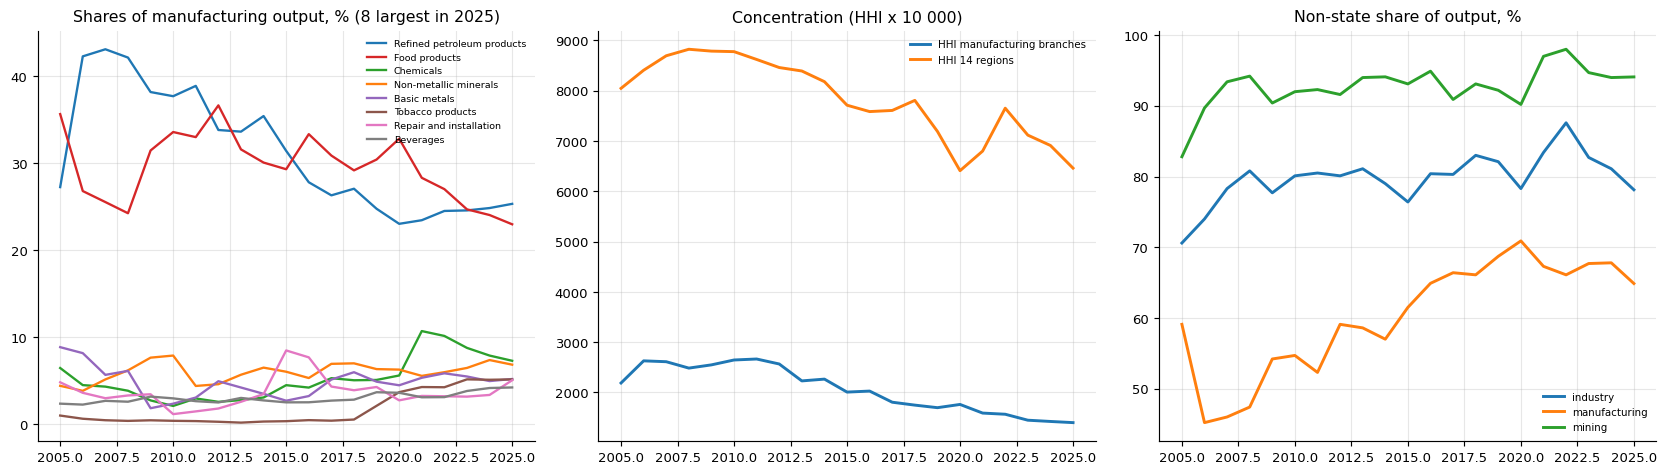

In [13]:
GO_C = GO[MANUF]; GO_B = GO[MINING]
SH_MAN = GO_C.div(GO_C.sum(axis=1), axis=0)                 # shares within manufacturing
SH_MIN = GO_B.div(GO_B.sum(axis=1), axis=0)                 # shares within mining
SH_IND = GO.div(GO.sum(axis=1), axis=0)                     # shares within industry
SEC_GO = pd.DataFrame({'B': GO_B.sum(axis=1), 'C': GO_C.sum(axis=1), 'D': GO['35'], 'E': GO['36']})
SH_SEC = SEC_GO.div(SEC_GO.sum(axis=1), axis=0)
def hhi(S): return (S ** 2).sum(axis=1) * 1e4
def cr4(S): return S.apply(lambda r: r.sort_values(ascending=False).head(4).sum(), axis=1) * 100
REG_SH = REG_GO.div(REG_GO.sum(axis=1), axis=0)
CONC = pd.DataFrame({'HHI manufacturing branches': hhi(SH_MAN), 'CR4 manufacturing, %': cr4(SH_MAN),
                     'HHI industry branches': hhi(SH_IND), 'CR4 industry, %': cr4(SH_IND),
                     'HHI 14 regions': hhi(REG_SH), 'CR4 regions, %': cr4(REG_SH)}).loc[2005:LAST_ACT]
display(CONC.loc[[2005, 2010, 2015, 2019, 2020, 2022, 2024, LAST_ACT]].round(1))
top = SH_MAN.loc[LAST_ACT].sort_values(ascending=False)
print(f'{LAST_ACT} manufacturing leaders: ' + ', '.join(f'{BNAME[b]} {v*100:.1f}%' for b, v in top.head(5).items()))
ch = (SH_MAN.loc[LAST_ACT] - SH_MAN.loc[2015]) * 100
print('share gains 2015-2025, pp: ' + ', '.join(f'{BNAME[b]} {v:+.1f}' for b, v in ch.sort_values(ascending=False).head(4).items())
      + ' | losses: ' + ', '.join(f'{BNAME[b]} {v:+.1f}' for b, v in ch.sort_values().head(4).items()))

# ownership: the composition identity reproduces the published non-state share
NS_COMP = (GO[BCODES] * NS[BCODES]).sum(axis=1, min_count=20) / GO[BCODES].where(NS[BCODES].notna()).sum(axis=1, min_count=20)
own = pd.DataFrame({'published non-state share, %': NS['ALL'] * 100, 'composition identity, %': NS_COMP * 100,
                    'non-state share of manufacturing, %': NS['C'] * 100, 'non-state share of mining, %': NS['B'] * 100}).loc[2005:LAST_ACT]
own['identity gap, pp'] = own.iloc[:, 1] - own.iloc[:, 0]
display(own.loc[[2005, 2010, 2015, 2020, 2023, 2024, LAST_ACT]].round(2))
OWN_BAD = own['identity gap, pp'][own['identity gap, pp'].abs() > 0.5]
OWN_GAP = float(own['identity gap, pp'].drop(OWN_BAD.index).abs().max())
print(f'the branch-weighted non-state share reproduces the published industry figure to {OWN_GAP:.2f} pp, except in '
      + ', '.join(f'{int(y)} ({v:+.1f} pp)' for y, v in OWN_BAD.items()) + ' (Part 6, finding F12)')
finding('F12', 'The published non-state share of industry is inconsistent with its own branch breakdown in some years',
        'output-weighted branch non-state shares (DSK 010_2 x 010) differ from the published industry total by '
        + ', '.join(f'{int(y)} {v:+.1f} pp' for y, v in OWN_BAD.items()) + f'; within {OWN_GAP:.2f} pp in every other year',
        'The forecast of the non-state share is built from the branch composition (consistent by construction); the '
        'published total for those years should be queried with DSK')
FINDINGS = pd.DataFrame(FIND).set_index('id')

# enterprises, entry and exit, size classes, SMEs, firm-concentration bound
ENT = pd.DataFrame({'industry enterprises': NENT['ALL'], 'manufacturing': NENT['C'], 'mining': NENT['B'],
                    'state-owned (industry)': d047.set_index('label').loc['State property', [c for c in d047.columns if isinstance(c, (int, np.integer))]].astype(float),
                    'non-state (industry)': d047.set_index('label').loc['Non-state property', [c for c in d047.columns if isinstance(c, (int, np.integer))]].astype(float)})
ENT['net entry rate, % (industry)'] = ENT['industry enterprises'].pct_change() * 100
display(ENT.loc[[2005, 2010, 2015, 2019, 2021, 2023, 2024, LAST_ACT]].round(1))
sz = SIZE[SIZE.label == 'All industry'].pivot_table(index='year', columns='size_class', values='n')
sme_ind = SME_SHARE_OUT[SME_SHARE_OUT.label_en.str.contains('Industr')].iloc[0]
s_large = 1 - sme_ind.total_2024 / 100
n_large = float(ST_LARGE[ST_LARGE.activity.str.contains('Manufacturing|Mining|Electricity|Water')].large_units.sum())
HHI_BOUND = dict(non_sme_output_share=s_large, n_large_units=n_large, hhi_lower_bound=s_large ** 2 / n_large * 1e4,
                 equiv_firms_upper=n_large / s_large ** 2)
print(f'firm-level concentration bound: large (non-SME) enterprises produce {s_large*100:.1f}% of industrial output (2024, '
      f'= 100 - SME share); the register counts {n_large:.0f} large industrial units (1 Jul 2026). Split equally among them that '
      f'output gives HHI = s^2/N = {HHI_BOUND["hhi_lower_bound"]:.1f}; any unequal split, and the SME part, can only raise it, so it is a '
      f'lower bound (equivalent number of firms <= {HHI_BOUND["equiv_firms_upper"]:.0f}); the two sources refer to different dates. The actual HHI needs firm data (Layer B)')
ENTRY_REG = ST_ENTRY.copy()
display(ENTRY_REG[ENTRY_REG.activity.str.contains('Total|Mining|Manufactur|Electric|Water')].reset_index(drop=True))
rw = RG_WB.pivot_table(index=['region', 'year'], columns='var', values='value')
rw['entry_rate_pct'] = rw.new / rw.enterprises * 100; rw['exit_rate_pct'] = rw.liquidated / rw.enterprises * 100
REG_ENTRY = rw.reset_index()

# products: volumes in kind, growth 2020-2025, linked to branches
yc18 = [c for c in PROD.columns if isinstance(c, (int, np.integer))]
pv = PROD.set_index('label')[yc18].astype(float)
PROD_VIEW = pd.DataFrame({'branch': PROD.set_index('label').branch, 'unit': [l.split(',')[-1].strip() for l in pv.index],
                          f'{LAST_ACT - 5}': pv[LAST_ACT - 5], f'{LAST_ACT}': pv[LAST_ACT],
                          'growth 2020-2025, % a year': ((pv[LAST_ACT] / pv[LAST_ACT - 5]) ** (1 / 5) - 1) * 100})
PROD_VIEW = PROD_VIEW[np.isfinite(PROD_VIEW['growth 2020-2025, % a year'])]
print(f'products with a 2020-2025 growth rate: {len(PROD_VIEW)}; fastest: ' +
      ', '.join(f'{i.split(",")[0]} {v:+.0f}%' for i, v in PROD_VIEW['growth 2020-2025, % a year'].sort_values(ascending=False).head(3).items()))
pk = PARKS[PARKS.park.str.contains('zonaları üzrə cəmi')].pivot_table(index='year', columns='indicator', values='value')
PARK_TOT = pk[[c for c in pk.columns if c.startswith(('Faktiki', 'İstehsalın həcmi', 'İxracın həcmi', 'İnvestisiyanın'))]]
display(PARK_TOT.round(1))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.6))
for i, b in enumerate(top.head(8).index):
    ax[0].plot(SH_MAN.loc[2005:].index, SH_MAN.loc[2005:, b] * 100, color=PAL[i], lw=1.6, label=BNAME[b])
ax[0].set_title('Shares of manufacturing output, % (8 largest in 2025)'); ax[0].legend(fontsize=6.5)
ax[1].plot(CONC.index, CONC['HHI manufacturing branches'], lw=2, label='HHI manufacturing branches')
ax[1].plot(CONC.index, CONC['HHI 14 regions'], lw=2, label='HHI 14 regions'); ax[1].legend(fontsize=7)
ax[1].set_title('Concentration (HHI x 10 000)')
ax[2].plot(own.index, own.iloc[:, 0], lw=2, label='industry'); ax[2].plot(own.index, own.iloc[:, 2], lw=2, label='manufacturing')
ax[2].plot(own.index, own.iloc[:, 3], lw=2, label='mining'); ax[2].set_title('Non-state share of output, %'); ax[2].legend(fontsize=7)
plt.tight_layout(); plt.show()

### 7.2 Production efficiency

| Indicator | Formula | Source |
|---|---|---|
| Labour productivity (output) | real gross output / employees | DSK 010, 009; workbook and DSK 006 headcount |
| Labour productivity (VA) | real value added / employees (VA deflated by the branch output deflator — single deflation, stated) | DSK NA 015_2 |
| Intermediate-consumption share | IC / output | DSK NA 015, 015_1 |
| Capital productivity | real output / real capital (perpetual inventory from branch investment, δ = 0.07 as FR1; 2010 stock = the section's **observed** fixed assets (DSK NA 031, deflated by FR1's investment deflator) allocated by 2005–10 investment shares) | DSK 019, NA 031 |
| TFP growth (gross output, Törnqvist) | Δln Q − s̄_M Δln M − s̄_L Δln L − s̄_K Δln K with **observed** shares s_M = IC/GO, s_L = gross wage bill/GO (employer contributions 22%, FR1), s_K = 1 − s_M − s_L | as above |
| TFP growth (value added, sections) | Δln VA − s̄_L Δln L − (1−s̄_L) Δln K, s_L = compensation/VA, K = observed fixed assets (NA 031) at constant prices | DSK NA 013, 031; FR1 rva_*, p_inv; FR4 hired employees |
| Wage–productivity gap | Δln(wage / output deflator) − Δln LP | workbook / DSK 006_2 |
| Innovation intensity | innovation expenditure / output | DSK 020_3 |

No production-function parameter is estimated: cost shares are observed, as the brief requires. Where observed
labour plus materials exceed output the residual capital share would be negative; such branch-years are flagged,
not forced.

In [14]:
EMPC = WEMP[BCODES].loc[2016:LAST_ACT - 1].combine_first(EMP_DSK[BCODES]).loc[2016:LAST_ACT]   # DSK for 2025 (F2)
WAGEC = WWAGE[BCODES].loc[2016:LAST_ACT - 1].combine_first(WAGE_DSK[BCODES]).loc[2016:LAST_ACT]
SSC = 0.22                                                                                 # as FR1 EMPLOYER_SSC
WBILL = WAGEC * EMPC * 12 / 1e6 * (1 + SSC)                                                # mn AZN, gross of employer SSC
VA_B = NA_VA[[b for b in MANUF]].copy()
VA_B['06'] = NA_VA['06']; VA_B['35'] = NA_VA['D']; VA_B['36'] = NA_VA['E']
IC_SH = (NA_IC / NA_GO)[MANUF + ['06']].rename(columns={})
LP_GO = (Q[BCODES] / EMPC * 1e3).loc[2016:LAST_ACT]                                         # thousand AZN (2015 prices) per employee
LP_VA = (VA_B / PDEF[VA_B.columns] / EMPC[VA_B.columns] * 1e3).loc[2016:LAST_ACT]
# perpetual-inventory capital by branch, consistent with FR1's section capital in 2010
DELTA = 0.07
PINV = F1H.p_inv
K = {}
FA_REAL = FA.div(PINV, axis=0).loc[2006:]          # FR1's investment deflator has a level break 2005/06: start 2006
for sec, cols in [('C', MANUF), ('B', MINING)]:
    cum = INV.loc[2005:2010, cols].fillna(0).sum()
    for b in cols:
        k = pd.Series(np.nan, index=range(2010, LAST_ACT + 1), dtype=float)
        k[2010] = FA_REAL.loc[2010, sec] * cum[b] / cum.sum() if cum[b] > 0 else np.nan
        for y in range(2011, LAST_ACT + 1):
            k[y] = (1 - DELTA) * k[y - 1] + np.nan_to_num(INV.loc[y, b]) / PINV.loc[y]
        K[b] = k
for b, sec in [('35', 'D'), ('36', 'E')]:
    K[b] = FA_REAL[sec].loc[2010:LAST_ACT]
K = pd.DataFrame(K)
KPROD = (Q[BCODES].loc[2010:LAST_ACT] / K[BCODES])
INV_RATE = (INV[BCODES] / GO[BCODES] * 100)

def tornqvist_tfp(b):
    y = list(range(2017, LAST_ACT + 1))
    go, ic = NA_GO[b] if b in NA_GO else GO[b], NA_IC[b] if b in NA_IC else np.nan
    sM = (NA_IC[b] / NA_GO[b]) if b in NA_IC else pd.Series(np.nan, index=GO.index)
    sL = WBILL[b] / GO[b]
    sK = 1 - sM - sL
    dQ = np.log(Q[b]).diff(); dM = np.log(NA_IC[b] / PDEF[b]).diff() if b in NA_IC else np.nan
    dL = np.log(EMPC[b]).diff(); dK = np.log(K[b]).diff()
    av = lambda s: (s + s.shift(1)) / 2
    t = dQ - av(sM) * dM - av(sL) * dL - av(sK) * dK
    return pd.DataFrame({'dlnQ': dQ, 'contrib_M': av(sM) * dM, 'contrib_L': av(sL) * dL, 'contrib_K': av(sK) * dK,
                         'dlnTFP': t, 'sM': sM, 'sL': sL, 'sK': sK}).loc[y]
TFP = pd.concat({b: tornqvist_tfp(b) for b in MANUF}, names=['branch', 'year'])
neg_sk = TFP[TFP.sK < 0]
_sum = lambda s: s.sum(min_count=len(s))          # a branch with any missing year has no cumulative TFP
TFP_SUM = TFP.groupby(level=0).agg(dlnQ=('dlnQ', _sum), contrib_M=('contrib_M', _sum), contrib_L=('contrib_L', _sum),
                                   contrib_K=('contrib_K', _sum), dlnTFP=('dlnTFP', _sum), mean_sK=('sK', 'mean'))
TFP_SUM = (TFP_SUM * [100, 100, 100, 100, 100, 1]).rename(index=BNAME)
TFP_SUM.columns = ['output growth 2016-25, log pts x100', 'materials', 'labour', 'capital', 'TFP', 'mean capital share']
gap_ = (TFP.dlnQ - TFP.contrib_M - TFP.contrib_L - TFP.contrib_K - TFP.dlnTFP).abs().max()
print(f'gross-output Törnqvist TFP, 24 manufacturing branches, 2017-{LAST_ACT}: decomposition closes to {gap_:.1e} (arithmetic); '
      f'{len(neg_sk)} branch-years have labour + materials cost shares above 1 (negative residual capital share) - flagged')
display(TFP_SUM.sort_values('TFP', ascending=False).round(2))

# section level (value added), 2006-2025: FR1 real VA and capital, NA labour share, FR4/DSK hired employees
HIRED_H = pd.read_csv(OUT / 'FR4_dsk_hired_by_activity_history.csv', index_col=0)
FR4H_B = FR4H[FR4H.scenario == 'Baseline'].set_index('year')
SEC_TFP = {}
for sec, v, h4 in [('B', 'min', 'mining'), ('C', 'man', 'manuf'), ('D', 'elc', 'elec'), ('E', 'wat', 'water')]:
    L_ = HIRED_H[h4].copy(); L_.loc[LAST_ACT] = FR4H_B.loc[LAST_ACT, h4] if LAST_ACT not in L_.index else L_.loc[LAST_ACT]
    sL = (INC.loc[sec].CE / INC.loc[sec].VA).clip(0, 1)
    dVA = np.log(F1H[f'rva_{v}']).diff(); dL = np.log(L_).diff(); dK = np.log(FA_REAL[sec]).diff()
    a = (sL + sL.shift(1)) / 2
    SEC_TFP[SECT[sec]] = pd.DataFrame({'dlnVA': dVA, 'labour': a * dL, 'capital': (1 - a) * dK,
                                       'TFP': dVA - a * dL - (1 - a) * dK}).loc[2007:LAST_ACT]
SEC_TFP = pd.concat(SEC_TFP, names=['section', 'year'])
st_ = SEC_TFP.groupby(level=0).agg(['mean']).droplevel(1, axis=1) * 100
st_.columns = [c + ', % a year (2007-2025 mean)' for c in st_.columns]
display(st_.round(2))
WPG = pd.DataFrame({'real product wage growth': np.log(WAGEC[MANUF] / PDEF[MANUF]).diff().loc[2017:].sum(),
                    'labour productivity growth': np.log(LP_GO[MANUF]).diff().loc[2017:].sum()}) * 100
WPG['gap (wage - productivity), log pts'] = WPG.iloc[:, 0] - WPG.iloc[:, 1]
INNOV_INT = (INNOV.reindex(columns=BCODES) / 1000 / GO[BCODES] * 100)

gross-output Törnqvist TFP, 24 manufacturing branches, 2017-2025: decomposition closes to 0.0e+00 (arithmetic); 17 branch-years have labour + materials cost shares above 1 (negative residual capital share) - flagged


,"output growth 2016-25, log pts x100",materials,labour,capital,TFP,mean capital share
branch,,,,,,
Pharmaceuticals,736.970,484.530,59.560,21.510,171.360,-0.250
Electrical equipment,584.660,428.630,-7.980,-2.710,166.710,0.080
Wood products,282.740,175.150,-6.830,-2.550,116.970,0.210
Tobacco products,217.680,130.100,12.560,0.090,74.920,0.330
Non-metallic minerals,185.060,112.370,0.440,0.400,71.860,0.250
Fabricated metal products,103.160,37.180,8.040,-10.440,68.370,0.230
Computer and electronics,72.450,46.120,-28.080,-11.780,66.190,0.240
Furniture,186.770,122.260,14.510,-0.080,50.080,0.100
Textiles,138.790,76.640,11.570,13.090,37.500,0.240


,"dlnVA, % a year (2007-2025 mean)","labour, % a year (2007-2025 mean)","capital, % a year (2007-2025 mean)","TFP, % a year (2007-2025 mean)"
section,,,,
Electricity,2.210,0.110,7.000,-4.900
Manufacturing,5.040,0.460,4.360,0.230
Mining,1.080,-0.080,8.020,-6.870
Water,4.730,2.930,2.350,-0.560


### 7.3 Financial condition

Three windows on profitability, each with its limits stated:

1. **National accounts by section** (DSK NA 013, 2005–2025): gross operating surplus = value added − compensation −
   other taxes on production; margins GOS/output and GOS/VA; labour share; consumption of fixed capital.
2. **GOS proxy by manufacturing branch** (2016–2025): value added (DSK NA) − gross wage bill (workbook / DSK headcount ×
   average wage × 12 × 1.22). It omits other taxes on production (0.3–1.0% of VA at section level) and the
   compensation of non-employees, so it is an upper bound on the true margin.
3. **Profit-tax declarations** (DVX, all payers, 2021–2025): the declaration net margin, the share of declared losses,
   the effective tax ratio (finding F7) — economy-wide aggregates with no branch dimension.

Liquidity, solvency, leverage, interest cover and the distress score require balance sheets: they are defined in
Layer B and wait for the Tax Service / DSMF panel.

sec,Mining,Manufacturing,Electricity,Water
year,,,,
2005,89.400,74.000,29.300,16.400
2010,96.400,83.400,68.200,18.000
2015,91.900,76.700,70.400,2.200
2019,93.400,62.700,62.500,9.200
2020,90.400,65.400,65.200,5.200
2022,96.900,72.400,70.100,-33.200
2024,94.400,65.900,64.700,-35.300
2025,93.600,65.800,65.400,-51.600


branch GOS-proxy margin 2025: median 20.4% of output; negative in 2 branches: Pharmaceuticals, Other transport equipment


,"profit-tax payers, thsd","declaration net margin, % of deductible expenses","taxable profit / gross income, %","declared losses / taxable profit, %","effective tax ratio (r223), %","tax arrears, mn AZN","industry turnover share of total, %"
2021,35.910,12.940,12.070,19.510,2.500,"1,896.600",37.230
2022,40.530,13.250,13.470,26.020,2.800,"2,356.700",44.740
2023,42.700,12.280,10.790,13.800,2.300,"2,782.200",37.910
2024,43.960,11.070,10.940,19.430,2.200,"3,120.400",35.120
2025,38.950,10.050,9.330,26.580,2.200,"3,253.300",34.870


investment self-financing (own funds / total investment, workbook Real sektor r114/r80): 2023 50.1%, 2024 49.1%, 2025 51.4% (annual values exist only for these years)


total_2023    total_2024
                   label_en                                                                      
assets, mn AZN     Industry                                              25,270.400    22,987.300
                   Mining industry                                       17,063.300    13,420.500
                   Manufacturing industry                                 5,298.400     6,340.300
                   Electricity, gas and steam production, distribu...       719.100     1,361.100
                   Water supply; waste treatment and disposal             2,189.600     1,865.400
stocks, thsd AZN   Industry                                           1,255,521.000 1,362,851.100
                   Mining industry                                       38,179.200    38,500.300
                   Manufacturing industry                             1,143,858.900 1,138,382.700
                   Electricity, gas and steam production, distribu...    49,426.600   170,878.600
                   Water supply; waste treatment and disposal            24,056.300    15,089.500
taxes paid, mn AZN Industry                                                 341.100       479.600

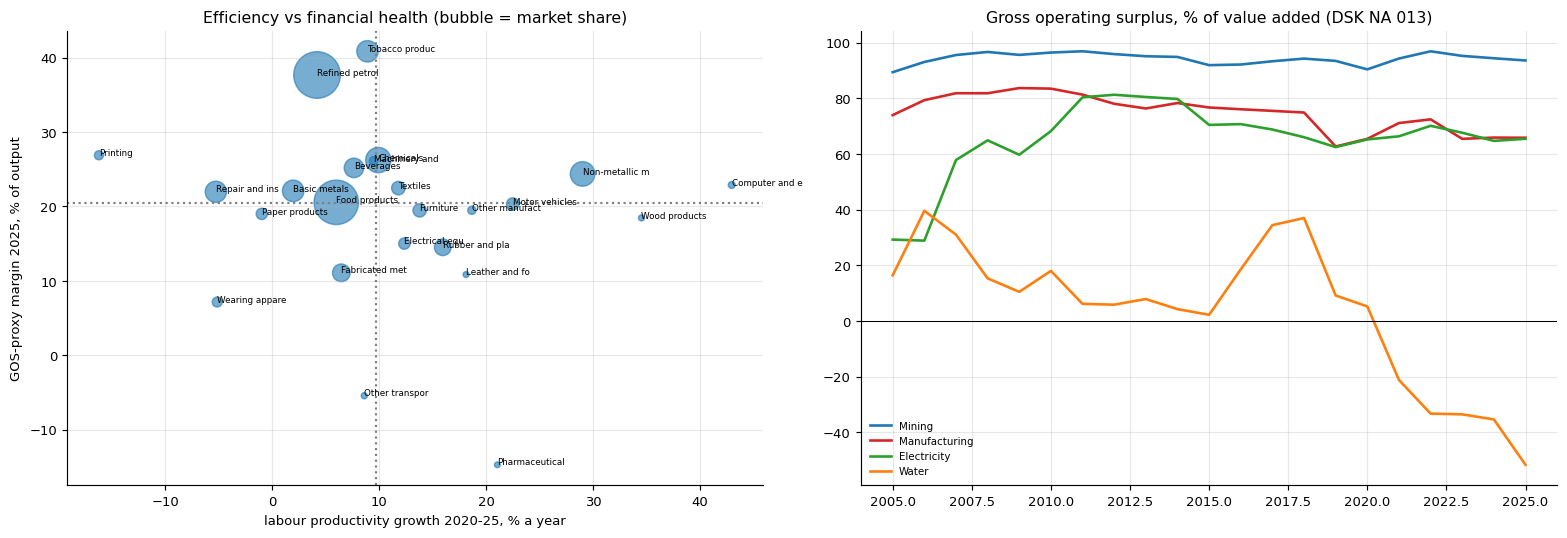

,branch,"LP growth 2020-25, % a year","GOS-proxy margin 2025, %","share of manufacturing 2025, %",quadrant
26,Computer and electronics,42.960,22.890,0.320,efficient and profitable
23,Non-metallic minerals,29.010,24.370,6.840,efficient and profitable
13,Textiles,11.790,22.470,1.900,efficient and profitable
20,Chemicals,9.910,26.230,7.280,efficient and profitable
27,Electrical equipment,12.350,15.020,1.270,"efficient, thin margin"
22,Rubber and plastics,15.940,14.520,3.020,"efficient, thin margin"
32,Other manufacturing,18.660,19.490,0.560,"efficient, thin margin"
21,Pharmaceuticals,21.040,-14.690,0.140,"efficient, thin margin"
16,Wood products,34.520,18.460,0.170,"efficient, thin margin"
15,Leather and footwear,18.120,10.860,0.160,"efficient, thin margin"


In [15]:
SEC_FIN = INC.copy()
SEC_FIN['GOS_margin_GO'] = SEC_FIN.GOS / SEC_FIN.GO * 100; SEC_FIN['GOS_share_VA'] = SEC_FIN.GOS / SEC_FIN.VA * 100
SEC_FIN['labour_share_VA'] = SEC_FIN.CE / SEC_FIN.VA * 100; SEC_FIN['CFC_share_VA'] = SEC_FIN.CFC / SEC_FIN.VA * 100
SEC_FIN['IC_share_GO'] = SEC_FIN.IC / SEC_FIN.GO * 100
sf = SEC_FIN['GOS_share_VA'].unstack(0).rename(columns=SECT)
display(sf.loc[[2005, 2010, 2015, 2019, 2020, 2022, 2024, LAST_ACT]].round(1))
# margins use the national-accounts output of the same branch (consistent with its value added; DSK 010 output
# differs from NA output for a few small branches, e.g. machinery in 2025, where NA VA exceeds DSK 010 output)
GOSP = ((VA_B[MANUF] - WBILL[MANUF]) / NA_GO[MANUF] * 100).loc[2016:LAST_ACT]        # branch GOS-proxy margin, % of output
VA_MARG = (VA_B[MANUF] / NA_GO[MANUF] * 100).loc[2016:LAST_ACT]
print(f'branch GOS-proxy margin {LAST_ACT}: median {GOSP.loc[LAST_ACT].median():.1f}% of output; negative in '
      f'{int((GOSP.loc[LAST_ACT] < 0).sum())} branches: ' + ', '.join(BNAME[b] for b in GOSP.columns[GOSP.loc[LAST_ACT] < 0]))
DVX_M = pd.DataFrame({'profit-tax payers, thsd': DVX.pt_payers,
                      'declaration net margin, % of deductible expenses': true_marg,
                      'taxable profit / gross income, %': DVX.pt_profit / DVX.pt_income * 100,
                      'declared losses / taxable profit, %': DVX.pt_loss / DVX.pt_profit * 100,
                      'effective tax ratio (r223), %': DVX.pt_rent,
                      'tax arrears, mn AZN': DVX.arrears,
                      'industry turnover share of total, %': DVX.turn_ind / DVX.turn_total * 100})
display(DVX_M.round(2))
SELF_FIN = (RS.inv_own / RS.inv_total * 100).dropna()
print(f'investment self-financing (own funds / total investment, workbook Real sektor r114/r80): ' +
      ', '.join(f'{int(y)} {v:.1f}%' for y, v in SELF_FIN.items()) + ' (annual values exist only for these years)')
STK_RATIO = (STK.reindex(columns=BCODES) / GO[BCODES] * 100)
sme_rows = lambda df: df[df.label_en.str.contains('Industry|Mining|Manufact|Electric|Water')]
SME_FIN = pd.concat({'assets, mn AZN': sme_rows(SME_ASSETS).set_index('label_en')[['total_2023', 'total_2024']],
                     'stocks, thsd AZN': sme_rows(SME_STOCKS).set_index('label_en')[['total_2023', 'total_2024']],
                     'taxes paid, mn AZN': sme_rows(SME_TAX).set_index('label_en')[['total_2023', 'total_2024']]})
display(SME_FIN.round(1))

# the quadrant the presentation layer uses: efficiency vs financial health, manufacturing branches
QUAD = pd.DataFrame({'branch': [BNAME[b] for b in MANUF],
                     'LP growth 2020-25, % a year': (((LP_GO.loc[LAST_ACT, MANUF] / LP_GO.loc[2020, MANUF]) ** (1 / 5) - 1) * 100).values,
                     f'GOS-proxy margin {LAST_ACT}, %': GOSP.loc[LAST_ACT, MANUF].values,
                     f'share of manufacturing {LAST_ACT}, %': (SH_MAN.loc[LAST_ACT, MANUF] * 100).values}, index=MANUF)
mx, my = QUAD.iloc[:, 1].median(), QUAD.iloc[:, 2].median()
QUAD['quadrant'] = np.select([(QUAD.iloc[:, 1] >= mx) & (QUAD.iloc[:, 2] >= my), (QUAD.iloc[:, 1] >= mx) & (QUAD.iloc[:, 2] < my),
                              (QUAD.iloc[:, 1] < mx) & (QUAD.iloc[:, 2] >= my)],
                             ['efficient and profitable', 'efficient, thin margin', 'profitable, lagging efficiency'], 'lagging on both')
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))
a = ax[0]
a.scatter(QUAD.iloc[:, 1], QUAD.iloc[:, 2], s=QUAD.iloc[:, 3] * 40 + 10, alpha=0.6, color=PAL[0])
for b, r in QUAD.iterrows(): a.annotate(r.branch[:14], (r.iloc[1], r.iloc[2]), fontsize=6)
a.axvline(mx, color='grey', ls=':'); a.axhline(my, color='grey', ls=':')
a.set_xlabel('labour productivity growth 2020-25, % a year'); a.set_ylabel(f'GOS-proxy margin {LAST_ACT}, % of output')
a.set_title('Efficiency vs financial health (bubble = market share)')
for i, s_ in enumerate(['Mining', 'Manufacturing', 'Electricity', 'Water']):
    ax[1].plot(sf.index, sf[s_], lw=1.8, color=PAL[i], label=s_)
ax[1].axhline(0, color='k', lw=0.7); ax[1].set_title('Gross operating surplus, % of value added (DSK NA 013)'); ax[1].legend(fontsize=7)
plt.tight_layout(); plt.show()
display(QUAD.round(2).sort_values('quadrant'))

## Part 8 — The indicator system: which data, from which source, for which indicator, in which form

The requirement asks the executor to state **concretely** which data, from which source, are used for which
analytical indicator and how they reach the user. The data–source matrix below (`output/FR10_data_source_matrix.csv`)
has one row per indicator. The "years available now" column is **computed from the files read in Parts 4–5**, not
typed. Status: *available now* (in the workbook or downloadable from DSK today), *requested* (in the 24 Aug 2026 data
request, not yet received), *not available* (no source publishes it; an alternative is named).

In [16]:
def cov(x):
    if isinstance(x, str): return x
    s = x.dropna(how='all') if isinstance(x, pd.DataFrame) else x.dropna()
    yrs = [int(y) for y in s.index if isinstance(y, (int, np.integer)) and 1990 <= y <= 2035]
    return f'{min(yrs)}-{max(yrs)}' if yrs else 'n/a'
MX = []
def mrow(pillar, az, en, formula, unit, inst, dataset, gran, freq, years, status, integ, use, form, upd, alt=''):
    MX.append(dict(pillar=pillar, indicator_az=az, indicator_en=en, formula=formula, unit=unit, source_institution=inst,
                   dataset_table_row=dataset, granularity=gran, frequency=freq, years_available_now=cov(years), status=status,
                   integration_into_MIIS=integ, analytical_use=use, presentation_form=form, update_frequency=upd,
                   alternative_if_unavailable=alt))
DL, WB_, DSA = 'file download (DSK xls, scheduled)', 'workbook upload (Ministry of Economy)', 'data-sharing agreement + secure API'
MP = 'market position'
mrow(MP, 'Sahənin sənaye məhsulunda payı', 'Branch share of industrial output', 'GO_b / sum GO', '%', 'DSK', 'industry 010', 'branch (30)', 'annual', GO, 'available now', DL, 'share system, HHI (Parts 7, 11)', 'ranking table; time series with fan', 'annual (DSK release)')
mrow(MP, 'Emal sənayesində sahənin payı', 'Branch share of manufacturing output', 'GO_b / GO_C', '%', 'DSK', 'industry 010', 'branch (24)', 'annual', GO[MANUF], 'available now', DL, 'MNL share system (Part 11), forecast', 'stacked area; fan chart', 'annual')
mrow(MP, 'Konsentrasiya indeksi (HHİ, CR4) — sahələr', 'Concentration across branches (HHI, CR4)', 'sum s^2 x 10^4; top-4 share', 'index; %', 'DSK', 'industry 010 (derived)', 'industry / manufacturing', 'annual', GO, 'available now', DL, 'market-structure KPI, forecast', 'dashboard KPI card', 'annual')
mrow(MP, 'Müəssisə səviyyəsində HHİ', 'Firm-level HHI / CR4 by NACE x region', 'sum firm s^2 within cell', 'index', 'DVX / DSMF', 'enterprise panel (requested 24.08.2026)', 'firm', 'annual', 'none', 'requested', DSA, 'Layer B concentration', 'heat map NACE x region', 'annual', 'lower bound from DSK register large-unit count and SME output share (Part 7.1)')
mrow(MP, 'Qeyri-dövlət bölməsinin payı', 'Non-state share of output by branch', 'non-state output / output', '%', 'DSK', 'industry 010_2', 'branch', 'annual', NS, 'available now', DL, 'ownership composition forecast (Part 14)', 'time series; KPI card', 'annual')
mrow(MP, 'Fəaliyyət göstərən müəssisələrin sayı', 'Active enterprises by branch and ownership', 'count', 'units', 'DSK', 'industry 004-007-008 sheet 4;7', 'branch x ownership', 'annual', NENT, 'available now', DL, 'entry/net-entry rates, determinants panel', 'ranking table', 'annual')
mrow(MP, 'Ölçü qrupları üzrə müəssisələr', 'Enterprises by size class', 'count by micro/small/medium-large', 'units', 'DSK', 'industry 004-007-008 sheet 8', 'branch x size', 'annual', SIZE.set_index('year').n, 'available now', DL, 'size structure, concentration bound', 'stacked bar', 'annual')
mrow(MP, 'KOB-ların payı (buraxılış, məşğulluq, investisiya)', 'SME share of output, employment, investment', 'SME value / total', '%', 'DSK', 'entrepreneurship 001_1, 012, 013, 015', 'section x size', 'annual', '2023-2024', 'available now (2 years)', DL, 'held constant (not identifiable, F11)', 'KPI card', 'annual', 'DVX taxpayer size classes r111-r126 (2022-2025)')
mrow(MP, 'Vergi ödəyicilərinin ölçü qrupları', 'Taxpayer size classes: count, turnover, employees', 'by large/medium/small/micro', 'units; mn AZN; thsd', 'DVX', "workbook 'DVX üzrə göstəricilər' r111-r126", 'size class', 'annual', DVX.large_n, 'available now', WB_, 'size structure cross-check', 'table', 'annual')
mrow(MP, 'Regionun sənaye məhsulunda payı', 'Regional share of industrial output', 'GO_r / sum GO_r', '%', 'DSK', 'industry 022 (and 023 volume index)', 'economic region (14)', 'annual', REG_GO, 'available now', DL, 'regional share system (Part 12)', 'map; region x year heat map', 'annual')
mrow(MP, 'Regionlarda qeyri-dövlət payı', 'Non-state share of industrial output by region', 'published', '%', 'DSK', 'industry 024', 'region', 'annual', REG_NS, 'available now', DL, 'regional ownership profile', 'map', 'annual')
mrow(MP, 'Regionlarda müəssisələrin sayı', 'Industrial enterprises by region', 'count', 'units', 'DSK', 'industry 021', 'region', 'annual', REG_NENT, 'available now', DL, 'regional entry dynamics', 'map', 'annual')
mrow(MP, 'Yeni yaradılmış / ləğv edilmiş müəssisələr (regionlar)', 'New and liquidated enterprises by region (all sectors)', 'new / stock; liquidated / stock', '%', 'DSK via workbook', "workbook 'Regionlar*' rows 'Müəssisə və təşkilatların sayı', 'Yeni yaradılmış', 'Ləğv edilmiş'", 'region', 'annual', RG_WB.set_index('year').value, 'available now', WB_, 'entry/exit rates', 'map; table', 'annual')
mrow(MP, 'Yaradılmış və ləğv edilmiş vahidlər (fəaliyyət növləri)', 'Created and liquidated statistical units by activity', 'new / units; liquidated / units', '%', 'DSK', 'st_units 2_1-2_3 (snapshot 1 Jul 2026)', 'section, region, ownership', 'semi-annual snapshot', 'H1 2026', 'available now (snapshot)', DL, 'entry/exit rates', 'table', 'semi-annual', 'DVX register flows (requested)')
mrow(MP, 'Əsas məhsulların natura ilə istehsalı', 'Main products in physical units', 'volume', 'tonnes, units', 'DSK', 'industry 018; product lists in 014_x, 015_x, 016, 017', 'product (~140) x branch', 'annual', PROD.set_index('label')[[c for c in PROD.columns if isinstance(c, (int, np.integer))]].T, 'available now', DL, 'product view, growth ranking', 'product table with sparklines', 'annual')
mrow(MP, 'Regionlar üzrə məhsullar', 'Main products by place of production; product location shares', 'volume; place / national', 'tonnes, units; %', 'DSK', 'industry 018_1 (2011-2025), 018_2 (2019-2025); 017_1 (to 2022)', 'product x city/district', 'annual', '2011-2025', 'available now', DL, 'product market shares by place, HHI across places (Part 14.3)', 'map; product table', 'annual')
mrow(MP, 'Sahələr üzrə ixrac', 'Exports by branch (export orientation)', 'exports / output', '%', 'State Customs Committee (DGK)', 'HS-level exports (not in project)', 'branch / product', 'monthly', 'none', 'not available', DSA + ' with DGK; HS-NACE concordance', 'share-system driver, determinants panel', 'scatter; time series', 'monthly', 'industrial-park exports (workbook Park, 2019-2025); DSK shipped goods 011 is not exports')
mrow(MP, 'Sənaye parkları: istehsal, ixrac, iş yerləri', 'Industrial parks and zones: output, exports, jobs, investment', 'published', 'mn AZN; persons', 'Industrial-park operators (İZİA, Ministry of Economy)', "workbook 'Park'", 'park', 'quarterly', PARKS.set_index('year').value, 'available now', WB_, 'park performance', 'table; KPI card', 'quarterly')
mrow(MP, 'İnvestisiya təşviqi sənədləri', 'Investment promotion certificates: projects, jobs, value', 'count, value', 'units; mn AZN', 'Ministry of Economy', "workbook 'İnvestisiya təşviqi sənədi '", 'national', 'annual', '2016-2025', 'available now', WB_, 'support-measure context', 'table', 'annual')
mrow(MP, 'KOBİA dəstək xidmətləri', 'SME agency (KOBİA) support services', 'counts', 'units; thsd AZN', 'KOBİA', "workbook 'KOBİA'", 'national / SME house', 'annual', '2021-2025', 'available now', WB_, 'support-measure context', 'table', 'annual')
print(f'{len(MX)} market-position indicators')

20 market-position indicators


In [17]:
EF, FC_ = 'production efficiency', 'financial condition'
_emp = WEMP[BCODES].combine_first(EMP_DSK[BCODES])
mrow(EF, 'Əmək məhsuldarlığı (buraxılış/işçi)', 'Labour productivity, real output per employee', 'Q_b / employees', 'thsd AZN 2015 prices', 'DSK; workbook', 'industry 010, 009, 006; industry sheets (headcount)', 'branch', 'annual', _emp, 'available now', DL + '; ' + WB_, 'efficiency ranking, quadrant, forecast path', 'ranking table; quadrant; fan', 'annual')
mrow(EF, 'Əmək məhsuldarlığı (ƏD/işçi)', 'Labour productivity, real value added per employee', 'VA_b / P_b / employees', 'thsd AZN 2015 prices', 'DSK', 'national accounts 015_2; 006', 'branch', 'annual', _emp.loc[2016:], 'available now', DL, 'efficiency ranking', 'ranking table', 'annual')
mrow(EF, 'Əmək məhsuldarlığı (rəsmi)', 'Labour productivity by section (official)', 'VA / employed', 'AZN', 'DSK', 'national accounts 030_2', 'section', 'annual', '2017-2025', 'available now', DL, 'cross-check', 'KPI card', 'annual')
mrow(EF, 'Aralıq istehlakın payı', 'Intermediate-consumption share of output', 'IC / GO', '%', 'DSK', 'national accounts 015, 015_1', 'branch', 'annual', NA_IC, 'available now', DL, 'TFP materials share; cost structure', 'time series', 'annual')
mrow(EF, 'Kapital məhsuldarlığı', 'Capital productivity', 'Q_b / K_b (perpetual inventory)', 'ratio', 'DSK', 'industry 019; national accounts 031', 'branch / section', 'annual', K, 'available now (derived)', DL, 'efficiency, TFP capital input', 'time series', 'annual')
mrow(EF, 'Ümumi amil məhsuldarlığı (TFP)', 'TFP growth, gross output (branches) and value added (sections)', 'Tornqvist residual with observed cost shares', 'log points', 'DSK; FR1; FR4', 'NA 013, 015, 015_1, 031; industry 019; FR4 hired', 'branch, section', 'annual', TFP.dlnTFP.unstack(0), 'available now (derived)', DL, 'efficiency decomposition (Part 7.2)', 'waterfall / decomposition chart', 'annual')
mrow(EF, 'Əmək haqqı - məhsuldarlıq fərqi', 'Wage-productivity gap', 'dln(w/P) - dln LP', 'log points', 'DSK; workbook', 'industry 006_2; industry sheets', 'branch', 'annual', WAGEC, 'available now', DL, 'unit-labour-cost pressure', 'bar chart', 'annual')
mrow(EF, 'İnnovasiya intensivliyi', 'Innovation intensity', 'innovation expenditure / output', '%', 'DSK', 'industry 020_3 (also 020_1, 020_2, 020_4, 020_5)', 'branch', 'annual', INNOV, 'available now', DL, 'efficiency profile', 'ranking table', 'annual')
mrow(EF, 'İnvestisiya norması', 'Investment rate (renewal proxy)', 'I / GO', '%', 'DSK', 'industry 019, 010', 'branch', 'annual', INV, 'available now', DL, 'determinants panel; early-warning flag', 'heat map', 'annual')
mrow(EF, 'Əsas fondların yenilənmə, çıxma, köhnəlmə dərəcəsi', 'Fixed-asset renewal, disposal and depreciation rates', 'published rates', '%', 'DSK', 'industry 017_2-017_7 (no longer published, F1)', 'branch', 'annual', 'none', 'not available', 'request to DSK to resume publication', 'renewal flag', 'heat map', 'annual', 'investment rate (DSK 019/010); consumption of fixed capital / VA by section (NA 013, 025)')
mrow(EF, 'Kapital qoyuluşlarının səmərəlilik indeksi', 'Capital-yield index', 'published index', 'index', 'DSK', 'industry 018_1 (old numbering, discontinued)', 'branch', 'annual', 'none', 'not available', 'request to DSK', 'efficiency', 'time series', 'annual', 'capital productivity from perpetual inventory')
mrow(EF, 'Enerji intensivliyi', 'Energy intensity of production', 'energy cost / output', '%', 'DSK; Azerenerji', 'not published by branch (SME electricity costs only, entrepreneurship 037, 2023-2024)', 'branch', 'annual', 'none', 'not available', DSA, 'cost structure, determinants', 'ranking table', 'annual', 'SME electricity and fuel costs (entrepreneurship 035, 037)')
mrow(FC_, 'Ümumi əməliyyat mənfəəti (bölmələr)', 'Gross operating surplus margin by section', 'GOS / VA; GOS / GO', '%', 'DSK', 'national accounts 013', 'section (B, C, D, E)', 'annual', INC.GOS.unstack(0), 'available now', DL, 'financial-condition forecast (Part 14)', 'time series with fan', 'annual')
mrow(FC_, 'Əmək haqqının ƏD-də payı', 'Labour share of value added', 'compensation / VA', '%', 'DSK', 'national accounts 013, 023', 'section', 'annual', INC.CE.unstack(0), 'available now', DL, 'margin decomposition', 'time series', 'annual')
mrow(FC_, 'Əsas kapitalın istehlakı', 'Consumption of fixed capital / VA', 'CFC / VA', '%', 'DSK', 'national accounts 013, 025', 'section', 'annual', INC.CFC.unstack(0), 'available now', DL, 'renewal proxy, net margin', 'time series', 'annual')
mrow(FC_, 'Sahə üzrə mənfəət proksisi', 'GOS-proxy margin by manufacturing branch', '(VA - gross wage bill) / GO', '%', 'DSK; workbook', 'NA 015, 015_2; industry 006, 006_2; industry sheets', 'branch', 'annual', GOSP, 'available now (derived)', DL + '; ' + WB_, 'quadrant, early warning, forecast', 'quadrant; ranking; fan', 'annual')
mrow(FC_, 'Mənfəət vergisi bəyannamələri: xalis marja', 'Profit-tax declarations: net margin', '(income after deductions - deductible expenses) / deductible expenses', '%', 'DVX', "workbook 'DVX üzrə göstəricilər' r215-r222", 'all payers', 'annual', DVX.pt_income, 'available now', WB_, 'economy-wide profitability KPI', 'KPI card', 'annual', 'branch breakdown requested from DVX')
mrow(FC_, 'Bəyan edilmiş zərər', 'Declared losses', 'loss / taxable profit', '%', 'DVX', 'DVX r221', 'all payers', 'annual', DVX.pt_loss, 'available now', WB_, 'distress KPI', 'KPI card', 'annual')
mrow(FC_, 'Effektiv mənfəət vergisi nisbəti', 'Effective profit-tax ratio (DVX "rentabellik", F7)', 'payable tax / income after deductions', '%', 'DVX', 'DVX r223', 'all payers', 'annual', DVX.pt_rent, 'available now', WB_, 'tax burden', 'KPI card', 'annual')
mrow(FC_, 'Gəlir vergisi bəyannamələri (fərdi sahibkarlar)', 'Income-tax declarations of individual entrepreneurs', 'profit / income; loss', '%', 'DVX', 'DVX r224-r232', 'all payers', 'annual', DVX.it_income, 'available now', WB_, 'small-business profitability', 'KPI card', 'annual')
mrow(FC_, 'Vergi borcları', 'Tax arrears', 'stock', 'mn AZN', 'DVX', 'DVX r43', 'national', 'annual', DVX.arrears, 'available now', WB_, 'early-warning context', 'KPI card', 'monthly')
mrow(FC_, 'Sənaye dövriyyəsi (vergi bazası)', 'Industry turnover on the tax basis', 'turnover', 'mn AZN', 'DVX', 'DVX r53-r57', 'industry / non-oil industry', 'annual', DVX.turn_ind, 'available now', WB_, 'cross-check of output', 'time series', 'annual')
mrow(FC_, 'İnvestisiyanın öz vəsaitləri hesabına maliyyələşməsi', 'Investment self-financing share', 'own funds / total investment', '%', 'DSK via workbook', "workbook 'Real sektor' r114 / r80", 'national', 'annual', SELF_FIN, 'available now (3 years annual)', WB_, 'financial capacity KPI', 'KPI card', 'annual')
mrow(FC_, 'Hazır məhsul ehtiyatları', 'Finished-goods stocks to output', 'stocks / GO', '%', 'DSK', 'industry 013', 'branch', 'annual', STK, 'available now', DL, 'early-warning flag (rising stocks)', 'heat map', 'annual')
mrow(FC_, 'KOB-ların aktivləri, ehtiyatları, vergiləri', 'SME assets, stocks and taxes paid', 'levels', 'mn AZN', 'DSK', 'entrepreneurship 039, 040, 041', 'section x size', 'annual', '2023-2024', 'available now (2 years)', DL, 'SME balance-sheet profile', 'table', 'annual')
for az, en, f_ in [('Likvidlik əmsalları', 'Liquidity: current, quick, cash ratios', 'CA/STL; (CA-inv)/STL; cash/STL'),
                   ('Borc yükü, faiz örtüyü', 'Leverage and interest cover', '(STL+LTL)/E; EBIT/interest'),
                   ('Rentabellik (DuPont)', 'Profitability: ROE (DuPont), ROA, EBIT margin', 'NP/Rev x Rev/TA x TA/E'),
                   ('Dövriyyə göstəriciləri', 'Turnover: assets, inventories, receivable days', 'Rev/TA; COGS/inv; rec/Rev x 365'),
                   ("Altman Z''-EM", "Distress score (Altman Z''-EM, literature coefficients)", "3.25 + 6.56 X1 + 3.26 X2 + 6.72 X3 + 1.05 X4")]:
    mrow(FC_, az, en, f_, 'ratio', 'DVX', 'enterprise balance sheet and P&L panel (requested 24.08.2026)', 'firm', 'annual', 'none', 'requested', DSA,
         'Layer B engine (Part 17)', 'firm scorecard; peer percentile; early-warning list', 'annual', 'none for firms; aggregate proxies above')
mrow(EF, 'Müəssisə məşğulluğu və əmək haqqı fondu', 'Firm employment and wage bill', 'persons; wage bill', 'persons; thsd AZN', 'DSMF', 'contributor records (requested)', 'firm', 'monthly', 'none', 'requested', DSA, 'Layer B productivity, TFP', 'firm scorecard', 'monthly', 'branch headcount (DSK 006, workbook)')
mrow(FC_, 'Sahələr üzrə kredit, problemli kreditlər', 'Credit and NPLs by branch', 'loans; NPL / loans', 'mn AZN; %', 'CBAR', 'not in project (FR1 holds total industry credit)', 'branch', 'monthly', 'none', 'not available', DSA + ' with CBAR', 'financial-condition driver', 'time series', 'monthly', 'FR1 industry credit (cred_ind_n) at section level')
SRC_MATRIX = pd.DataFrame(MX)
SRC_MATRIX.index = [f'I{i+1:02d}' for i in range(len(SRC_MATRIX))]
SRC_MATRIX['status_group'] = SRC_MATRIX.status.str.extract(r'^(available now|requested|not available)')[0]
print(SRC_MATRIX.status_group.value_counts().to_string())
display(SRC_MATRIX[['pillar', 'indicator_en', 'source_institution', 'dataset_table_row', 'years_available_now', 'status', 'presentation_form']])

status_group
available now    40
requested         7
not available     5


,pillar,indicator_en,source_institution,dataset_table_row,years_available_now,status,presentation_form
I01,market position,Branch share of industrial output,DSK,industry 010,1995-2025,available now,ranking table; time series with fan
I02,market position,Branch share of manufacturing output,DSK,industry 010,1995-2025,available now,stacked area; fan chart
I03,market position,"Concentration across branches (HHI, CR4)",DSK,industry 010 (derived),1995-2025,available now,dashboard KPI card
I04,market position,Firm-level HHI / CR4 by NACE x region,DVX / DSMF,enterprise panel (requested 24.08.2026),none,requested,heat map NACE x region
I05,market position,Non-state share of output by branch,DSK,industry 010_2,1997-2025,available now,time series; KPI card
I06,market position,Active enterprises by branch and ownership,DSK,industry 004-007-008 sheet 4;7,1995-2025,available now,ranking table
I07,market position,Enterprises by size class,DSK,industry 004-007-008 sheet 8,2009-2025,available now,stacked bar
I08,market position,"SME share of output, employment, investment",DSK,"entrepreneurship 001_1, 012, 013, 015",2023-2024,available now (2 years),KPI card
I09,market position,"Taxpayer size classes: count, turnover, employees",DVX,workbook 'DVX üzrə göstəricilər' r111-r126,2022-2025,available now,table
I10,market position,Regional share of industrial output,DSK,industry 022 (and 023 volume index),2003-2025,available now,map; region x year heat map


### 8.1 Gaps, alternatives and actions to agree with the Customer

Every gap that limits an FR10 indicator, its impact, the proxy FR10 uses meanwhile and the **bias** of that proxy,
and the action to agree with the Ministry (`output/FR10_data_gaps_and_alternatives.csv`).

In [18]:
GAPS = pd.DataFrame([
 ('Enterprise balance sheet and P&L panel (Tax Service, >= 5 years)', 'No firm ratios, distress scores, firm-level HHI, entry/exit by firm; Layer B runs on synthetic data only',
  'Section GOS margins (NA 013), branch GOS proxy, DVX declaration aggregates, concentration bound from the register', 'Aggregates hide dispersion; the GOS proxy omits other taxes and non-employee compensation (overstates margins)',
  'Sign the data-sharing agreement on the Part 17.1 schema; pseudonymised VÖEN; annual delivery after the declaration deadline'),
 ('Firm employment and wage bill (DSMF)', 'No firm productivity or TFP', 'DSK branch headcount and wages (006, 006_2), workbook industry sheets', 'Branch averages only', 'DSMF agreement keyed on the same pseudonymised VÖEN'),
 ('Fixed-asset renewal, disposal, depreciation rates by branch (F1)', 'No direct renewal indicator', 'Investment rate I/GO (DSK 019/010); CFC/VA by section (NA 013, 025)', 'Investment rate ignores stock age and is lumpy; section CFC hides branches',
  'Ask DSK to restore tables 017_2-017_7 or deliver them to MIIS'),
 ('Capital-yield index (old DSK 018_1)', 'No published capital efficiency', 'Capital productivity from perpetual inventory', 'Depends on depreciation rate (0.07) and the 2010 starting stock', 'As above'),
 ('Exports by branch / product (State Customs Committee)', 'Export orientation cannot enter the share system or the determinants panel', 'Industrial-park exports (workbook Park)', 'Covers parks and zones only, with no branch structure',
  'Monthly HS-level exports from DGK with an HS-NACE concordance'),
 ('Producer prices by NACE 2-digit branch', 'Real branch output relies on implicit deflators', 'Implicit output deflator = nominal output / chained volume (DSK 010, 009)', 'Composition effects inside a branch enter the deflator', 'DSK PPI by branch'),
 ('Energy costs by branch', 'No energy-intensity indicator', 'SME electricity and fuel costs (entrepreneurship 035, 037; 2023-2024)', 'SMEs only, two years', 'DSK / Azerenerji branch energy use'),
 ('Credit and NPLs by branch (CBAR)', 'No financing-condition driver by branch', 'FR1 industry credit at section level', 'Section level', 'CBAR loan register aggregates by NACE'),
 ('SME indicators as a time series (F11)', 'SME share cannot be projected', 'Held at 2024', 'Ignores any trend', 'DSK back-series of entrepreneurship tables from 2019'),
 ('Industrial output by region x branch', 'Regional forecasts cannot use branch composition', 'Regional totals (022) and products by place of production (018_1 2011-2025, 018_2 2019-2025)', 'Products cover physical units only, main products only', 'DSK region x NACE output table'),
 ('Profit-tax declarations by branch and size class (DVX)', 'Financial condition only economy-wide from declarations', 'Economy-wide DVX aggregates', 'Dominated by oil and large payers', 'DVX breakdown of r215-r232 by NACE and size'),
 ('Budget-organisation taxpayer rows (F8)', 'Budget organisations cannot be separated', 'None', '-', 'DVX to correct rows 127-129 of the workbook'),
 ('Workbook 2025 branch vintage (F2)', 'Workbook 2025 branch data unusable', 'DSK final 2025', 'None once DSK final is used', 'Refresh procedure: workbook rows overwritten from DSK when the final release appears'),
 ('Regional coverage break 2019 (F9)', 'Level break in regional shares', 'Step dummy; shares on the regional sum', 'Pre-2019 shares exclude household industry', 'DSK back-cast of regional output on the 2019+ coverage'),
 ('Published non-state share 2013-2016 inconsistent (F12)', 'Ownership history uncertain in 4 years', 'Composition identity', 'None in the forecast', 'Query DSK'),
 ('FR3 branch wage levels not anchored on 2025 (F13)', 'FR3 branch wage levels unusable for margins', "FR1 average-wage index on DSK 2025 branch wages", 'Common wage growth across branches', 'FR3 maintainers to anchor branch levels on 2025 actuals'),
], columns=['gap', 'impact', 'alternative_proxy', 'bias_of_proxy', 'action_to_agree_with_Customer'])
GAPS.index = [f'G{i+1:02d}' for i in range(len(GAPS))]
display(GAPS)

,gap,impact,alternative_proxy,bias_of_proxy,action_to_agree_with_Customer
G01,Enterprise balance sheet and P&L panel (Tax Se...,"No firm ratios, distress scores, firm-level HH...","Section GOS margins (NA 013), branch GOS proxy...",Aggregates hide dispersion; the GOS proxy omit...,Sign the data-sharing agreement on the Part 17...
G02,Firm employment and wage bill (DSMF),No firm productivity or TFP,"DSK branch headcount and wages (006, 006_2), w...",Branch averages only,DSMF agreement keyed on the same pseudonymised...
G03,"Fixed-asset renewal, disposal, depreciation ra...",No direct renewal indicator,Investment rate I/GO (DSK 019/010); CFC/VA by ...,Investment rate ignores stock age and is lumpy...,Ask DSK to restore tables 017_2-017_7 or deliv...
G04,Capital-yield index (old DSK 018_1),No published capital efficiency,Capital productivity from perpetual inventory,Depends on depreciation rate (0.07) and the 20...,As above
G05,Exports by branch / product (State Customs Com...,Export orientation cannot enter the share syst...,Industrial-park exports (workbook Park),"Covers parks and zones only, with no branch st...",Monthly HS-level exports from DGK with an HS-N...
G06,Producer prices by NACE 2-digit branch,Real branch output relies on implicit deflators,Implicit output deflator = nominal output / ch...,Composition effects inside a branch enter the ...,DSK PPI by branch
G07,Energy costs by branch,No energy-intensity indicator,SME electricity and fuel costs (entrepreneursh...,"SMEs only, two years",DSK / Azerenerji branch energy use
G08,Credit and NPLs by branch (CBAR),No financing-condition driver by branch,FR1 industry credit at section level,Section level,CBAR loan register aggregates by NACE
G09,SME indicators as a time series (F11),SME share cannot be projected,Held at 2024,Ignores any trend,DSK back-series of entrepreneurship tables fro...
G10,Industrial output by region x branch,Regional forecasts cannot use branch composition,Regional totals (022) and products by place of...,"Products cover physical units only, main produ...",DSK region x NACE output table


### 8.2 Presentation specification: the MIIS user views and the files that feed them

Each view reads one or more `output/FR10_*.csv` files written in Part 18; the column layouts are fixed, so the MIIS
front end can bind to them directly.

In [19]:
PRES = pd.DataFrame([
 ('V1 Branch scorecard', 'One card per branch: share of industry and manufacturing, real growth, labour productivity, GOS-proxy margin, investment rate, flags', 'KPI cards + sparkline', 'FR10_branch_scorecard.csv'),
 ('V2 Efficiency vs financial health', 'Labour-productivity growth against GOS-proxy margin, bubble = market share; quadrant labels', 'scatter / quadrant', 'FR10_quadrant.csv'),
 ('V3 Market-share dynamics', 'Branch shares 2005-2025 and 2026-2030 with 50/80/90% bands; HHI, CR4', 'stacked area; fan chart; KPI', 'FR10_branch_shares_history.csv, FR10_forecast_branches.csv, FR10_fan_charts.csv, FR10_concentration.csv'),
 ('V4 Region x activity', 'Regional shares of industrial output by year; non-state share; enterprises; entry/exit; forecast shares', 'map + heat map', 'FR10_regional_history.csv, FR10_forecast_regions.csv, FR10_regional_entry_exit.csv'),
 ('V5 Product view', 'Main products in physical units, 2020-2025 growth, branch link', 'table with sparklines', 'FR10_products.csv'),
 ('V6 Forecast with bands', 'Section and branch output (nominal, real), margins, non-state share under three scenarios with 5-95% bands', 'time series with fan', 'FR10_forecast_branches.csv, FR10_forecast_sections.csv, FR10_fan_charts.csv, FR10_scenario_summary.csv'),
 ('V7 Early-warning flags', 'Margin, market-share, renewal, stocks and productivity flags; watch list', 'flag table (traffic lights)', 'FR10_early_warning.csv'),
 ('V8 Financial condition', 'Section GOS margins, labour share, CFC; DVX declaration margins, losses, arrears; self-financing', 'time series; KPI cards', 'FR10_financial_sections.csv, FR10_dvx_declarations.csv'),
 ('V9 Key factors', 'Growth contributions by branch; determinants panel with honest inference', 'waterfall; coefficient table', 'FR10_growth_contributions.csv, FR10_determinants_panel.csv'),
 ('V10 Efficiency', 'TFP decomposition, capital productivity, wage-productivity gap, innovation intensity', 'decomposition bars', 'FR10_efficiency_branches.csv, FR10_tfp_sections.csv'),
 ('V11 Data catalogue', 'Indicator, source, table/row, years, status, integration route, alternative', 'searchable table', 'FR10_data_source_matrix.csv, FR10_data_gaps_and_alternatives.csv, FR10_data_integrity_findings.csv'),
 ('V12 Firm view (Layer B)', 'Firm scorecard, peer percentiles, distress zone, firm HHI by NACE x region, firm forecast — ACTIVE ONLY when the DVX/DSMF panel arrives', 'firm card; heat map', 'FR10_SYNTHETIC_*.csv now (pipeline test only, watermarked)'),
], columns=['view', 'content', 'form', 'feeding_files'])
display(PRES)

,view,content,form,feeding_files
0,V1 Branch scorecard,One card per branch: share of industry and man...,KPI cards + sparkline,FR10_branch_scorecard.csv
1,V2 Efficiency vs financial health,Labour-productivity growth against GOS-proxy m...,scatter / quadrant,FR10_quadrant.csv
2,V3 Market-share dynamics,Branch shares 2005-2025 and 2026-2030 with 50/...,stacked area; fan chart; KPI,"FR10_branch_shares_history.csv, FR10_forecast_..."
3,V4 Region x activity,Regional shares of industrial output by year; ...,map + heat map,"FR10_regional_history.csv, FR10_forecast_regio..."
4,V5 Product view,"Main products in physical units, 2020-2025 gro...",table with sparklines,FR10_products.csv
5,V6 Forecast with bands,"Section and branch output (nominal, real), mar...",time series with fan,"FR10_forecast_branches.csv, FR10_forecast_sect..."
6,V7 Early-warning flags,"Margin, market-share, renewal, stocks and prod...",flag table (traffic lights),FR10_early_warning.csv
7,V8 Financial condition,"Section GOS margins, labour share, CFC; DVX de...",time series; KPI cards,"FR10_financial_sections.csv, FR10_dvx_declarat..."
8,V9 Key factors,Growth contributions by branch; determinants p...,waterfall; coefficient table,"FR10_growth_contributions.csv, FR10_determinan..."
9,V10 Efficiency,"TFP decomposition, capital productivity, wage-...",decomposition bars,"FR10_efficiency_branches.csv, FR10_tfp_section..."


## Part 9 — What is estimated, what is forbidden, and what was rejected

### 9.1 The no-autoregression constraint, stated precisely

No equation in FR10 contains a lagged dependent variable, a moving-average error or a conditional-variance process,
and no variable is forecast from its own history. The lag constructs that do appear:

| Construct | Where | Why it is not an autoregression |
|---|---|---|
| Newey–West HAC covariance (n/(n−k) scaling), Driscoll–Kraay covariance | every time-series and panel equation | Standard errors only |
| DOLS leads/lags of **regressor** differences | level share equations (Parts 11–12) | Stock–Watson endogeneity correction; the dependent variable's own lags never enter |
| Residual ADF with one fixed lag | `eg_coint_p` | A test statistic on residuals |
| Chained volume levels $Q_t = Q_{t-1} I_t/100$ | Part 5 | The official chain-linking identity between a published level and a published index |
| Perpetual inventory $K_t = (1-\delta)K_{t-1} + I_t$ | Part 7.2 | An accounting identity for a stock built from observed flows |
| One-year lags of **other** variables (investment rate, relative price, ownership, stocks) | determinants panel, Part 10 | Predetermined regressors; branch output growth never appears on the right-hand side |
| Constant add-factor (own last-actual residual); decay at ρ̂ | Parts 11–14 | A fixed level adjustment anchoring 2025; the ρ̂ decay is a labelled sensitivity only |
| Historical residual paths $e_h = u_{s+h} - u_s$ | fan charts, Part 15 | Replays observed error paths; no estimated dynamics |
| Forecast rules "held at the last actual value" (relative prices, within-branch ownership shares, SME shares, IC/output ratios) | Part 14 | A stated scenario assumption, not an estimate; each is listed in the assumptions table |

FR10 has no partial-year data for branches, so the nowcast add-factor rule of the fix contract does not arise.

In [20]:
REJ = []
def reject(spec, block, verdict, evidence):
    REJ.append(dict(specification=spec, block=block, verdict=verdict, evidence=evidence))
NOAR = pd.DataFrame([
    ('HAC / Driscoll-Kraay covariance', 'all equations', 'standard errors only'),
    ('DOLS leads/lags of regressor differences', 'share systems', 'endogeneity correction; no own lag'),
    ('residual ADF, one fixed lag', 'eg_coint_p', 'test statistic'),
    ('chained volume levels', 'Part 5', 'chain-linking identity'),
    ('perpetual inventory capital', 'Part 7.2', 'stock-flow identity'),
    ('one-year lags of other regressors', 'determinants panel', 'predetermined regressors; dependent variable never lagged'),
    ('constant add-factor; decay at rho-hat (sensitivity)', 'share systems', 'level anchor; decay is a labelled sensitivity'),
    ('historical residual paths', 'fan charts', 'replay of observed error paths'),
    ('held-at-last-value forecast rules', 'Part 14', 'scenario assumptions, listed')], columns=['construct', 'where', 'why not autoregressive'])
display(NOAR)

,construct,where,why not autoregressive
0,HAC / Driscoll-Kraay covariance,all equations,standard errors only
1,DOLS leads/lags of regressor differences,share systems,endogeneity correction; no own lag
2,"residual ADF, one fixed lag",eg_coint_p,test statistic
3,chained volume levels,Part 5,chain-linking identity
4,perpetual inventory capital,Part 7.2,stock-flow identity
5,one-year lags of other regressors,determinants panel,predetermined regressors; dependent variable n...
6,constant add-factor; decay at rho-hat (sensiti...,share systems,level anchor; decay is a labelled sensitivity
7,historical residual paths,fan charts,replay of observed error paths
8,held-at-last-value forecast rules,Part 14,"scenario assumptions, listed"


## Part 10 — Key factors behind growth and decline (goal 4)

### 10.1 The accounting answer: which branches carried industrial growth

Before any regression, an exact decomposition: the growth of real manufacturing output equals the share-weighted
sum of branch growth rates (Törnqvist weights = average nominal shares of adjacent years). This identifies the
branches that drove expansion or contraction without any modelling assumption.

### 10.2 The econometric answer: a determinants panel

$$\Delta \ln Q_{b,t} = \alpha_b + \tau_t + \beta_1\,\text{inv\_rate}_{b,t-1} + \beta_2\,\Delta\ln(P_b/P_C)_{t-1}
  + \beta_3\,\text{nonstate}_{b,t-1} + \beta_4\,\text{stocks/GO}_{b,t-1} + \beta_5\,\Delta\ln N^{ent}_{b,t-1} + u_{b,t}$$

manufacturing branches with complete data (21 of 24 enter; the count is printed), 2011–2025 (investment adds up
exactly only from 2010, finding F3). Two-way fixed
effects (exact two-way within transformation on the unbalanced panel, equal to dummy-variable OLS) remove
branch-specific growth and every common year shock (FR1's macro cycle); inference is Driscoll–Kraay
with ⌊T^¼⌋ lags on **t(T−1)** — the effective number of observations is the number of years — and each coefficient
also gets a **wild cluster bootstrap** p-value (clusters = years, Webb weights, null imposed). Regressors are lagged
one year to keep them predetermined; branch output growth never appears on the right-hand side. A second
specification adds the real product wage and labour productivity terms where headcount exists (2018–2025).
The **between** estimator (branch means) is reported beside the within estimate and is not interpreted as an
effect: it says which *kinds* of branch grow faster, not what makes a branch grow.

**Division bias.** Ratios with output in the denominator (investment/output, stocks/output, labour share) share
measurement error with output growth. Their denominators are therefore taken at **t−2** (the numerator at t−1);
the same-year-denominator version is reported beside it to show how much the coefficients move.

Export orientation, credit and energy costs would belong in this equation; none exists by branch (gaps table).

contributions to manufacturing real growth 2016-2025 (log points x100, sum 71.2):
   top: Food products +17.3, Electrical equipment +11.9, Non-metallic minerals +10.9, Chemicals +6.4, Rubber and plastics +5.9
   bottom: Repair and installation -2.3, Refined petroleum products -1.3, Machinery and equipment -0.4, Other transport equipment +0.1


,spec,regressor,coef,se_DK,p_DK_t,p_wild,between_coef,between_p,n,branches,years,df,DK_lags
0,"A: 2011-2025, core",inv_rate_l1,-0.080,0.029,0.017,0.074,0.100,0.063,265,21,15,14,1
1,"A: 2011-2025, core",drelp_l1,0.100,0.028,0.003,0.020,-0.167,0.068,265,21,15,14,1
2,"A: 2011-2025, core",nonstate_l1,-0.049,0.141,0.733,0.725,0.048,0.264,265,21,15,14,1
3,"A: 2011-2025, core",stocks_go_l1,0.044,0.015,0.009,0.133,-0.140,0.114,265,21,15,14,1
4,"A: 2011-2025, core",dln_ent_l1,-0.173,0.098,0.101,0.113,-0.260,0.531,265,21,15,14,1
5,"B: 2018-2025, + wage and labour share",inv_rate_l1,0.020,0.021,0.368,0.671,0.159,0.166,151,21,8,7,1
6,"B: 2018-2025, + wage and labour share",drelp_l1,-0.168,0.343,0.640,0.655,0.025,0.963,151,21,8,7,1
7,"B: 2018-2025, + wage and labour share",nonstate_l1,-0.003,0.301,0.992,0.989,0.063,0.302,151,21,8,7,1
8,"B: 2018-2025, + wage and labour share",stocks_go_l1,0.120,0.395,0.770,0.775,-0.342,0.298,151,21,8,7,1
9,"B: 2018-2025, + wage and labour share",dln_ent_l1,0.000,0.268,1.000,1.000,-0.655,0.132,151,21,8,7,1


division bias: coefficients with t-2 denominators (used) vs same-year denominators


,spec,regressor,coef_t2_denominator,coef_same_year_denominator,change,p_t2,p_same
0,A,inv_rate_l1,-0.080,-0.082,0.002,0.017,0.015
1,A,stocks_go_l1,0.044,0.208,-0.164,0.009,0.110
2,B,inv_rate_l1,0.020,0.042,-0.021,0.368,0.221
3,B,stocks_go_l1,0.120,0.247,-0.127,0.770,0.586
4,B,labour_share_l1,-0.082,0.253,-0.335,0.882,0.395


within-branch effects significant at 10% on BOTH the DK t(T-1) and the wild-bootstrap test: inv_rate_l1 (A) -0.080, drelp_l1 (A) +0.100
Reading: with 15 (8) years of data the panel has the power of 14 (7) observations; coefficients that are not
significant are "not established (low power)", not "no effect". The decomposition in 10.1 is exact and is the
robust answer to "which branches drove growth"; the panel is the answer to "what is associated with it".
average co-movement of branch real growth with FR1 manufacturing real VA growth (branch FE, DK): 0.07 (s.e. 0.18, p 0.714) - descriptive; the aggregate is partly the sum of the branches


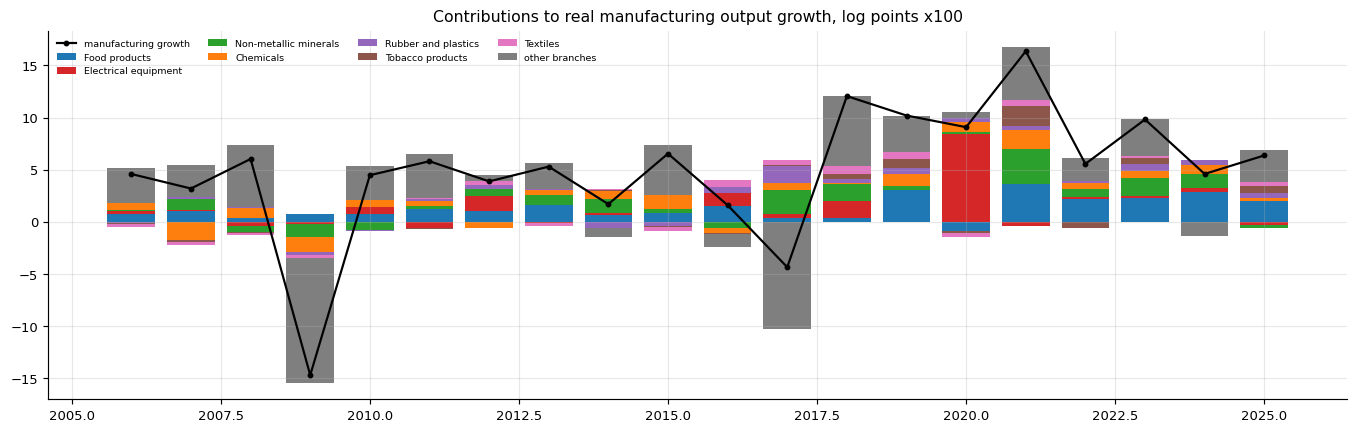

In [21]:
w_ = ((SH_MAN + SH_MAN.shift(1)) / 2)
dq = np.log(Q[MANUF]).diff()
contrib = (w_ * dq) * 100
DECOMP = pd.DataFrame({'Törnqvist manufacturing growth, %': contrib.sum(axis=1, min_count=24)}).loc[2006:LAST_ACT]
cum = contrib.loc[2016:LAST_ACT].sum().sort_values()
print(f'contributions to manufacturing real growth 2016-{LAST_ACT} (log points x100, sum {cum.sum():.1f}):')
print('   top: ' + ', '.join(f'{BNAME[b]} {v:+.1f}' for b, v in cum[::-1].head(5).items()))
print('   bottom: ' + ', '.join(f'{BNAME[b]} {v:+.1f}' for b, v in cum.head(4).items()))
_chk = (DECOMP.iloc[:, 0] - (w_ * dq).sum(axis=1).loc[2006:] * 100).abs().max()
GROWTH_CONTRIB = contrib.loc[2006:LAST_ACT].rename(columns=BNAME)

PNL = []
for b in MANUF:
    d = pd.DataFrame({'year': range(2006, LAST_ACT + 1)})
    d['unit'] = b
    y_ = d.year
    d['dlnQ'] = dq[b].reindex(y_).values * 100
    d['inv_rate_l1'] = (INV[b].shift(1) / GO[b].shift(2) * 100).reindex(y_).values          # denominator at t-2
    d['inv_rate_l1_same'] = (INV[b] / GO[b] * 100).shift(1).reindex(y_).values
    d['drelp_l1'] = (np.log(PDEF[b] / (GO_C.sum(axis=1) / chain_level(GO_all['C'], VI['C']))).diff() * 100).shift(1).reindex(y_).values
    d['nonstate_l1'] = (NS[b] * 100).shift(1).reindex(y_).values
    d['stocks_go_l1'] = (STK[b].shift(1) / GO[b].shift(2) * 100).reindex(y_).values if b in STK else np.nan
    d['stocks_go_l1_same'] = (STK[b] / GO[b] * 100).shift(1).reindex(y_).values if b in STK else np.nan
    d['dln_ent_l1'] = (np.log(NENT[b]).diff() * 100).shift(1).reindex(y_).values
    d['dln_rwage_l1'] = (np.log(WAGEC[b] / PDEF[b]).diff() * 100).shift(1).reindex(y_).values
    d['labour_share_l1'] = (WBILL[b].shift(1) / GO[b].shift(2) * 100).reindex(y_).values
    d['labour_share_l1_same'] = (WBILL[b] / GO[b] * 100).shift(1).reindex(y_).values
    PNL.append(d)
PNL = pd.concat(PNL, ignore_index=True)
PNL = PNL[(PNL.year >= 2011)].replace([np.inf, -np.inf], np.nan)
# robustness to the extreme growth rates of very small branches: winsorise the dependent variable at 5/95%
lo, hi = PNL.dlnQ.quantile([0.05, 0.95])
PNL['dlnQ_w'] = PNL.dlnQ.clip(lo, hi)
REGS1 = ['inv_rate_l1', 'drelp_l1', 'nonstate_l1', 'stocks_go_l1', 'dln_ent_l1']
REGS2 = REGS1 + ['dln_rwage_l1', 'labour_share_l1']
DET_ROWS = []
for spec, regs, yrs in [('A: 2011-2025, core', REGS1, (2011, LAST_ACT)), ('B: 2018-2025, + wage and labour share', REGS2, (2018, LAST_ACT))]:
    d = PNL[(PNL.year >= yrs[0]) & (PNL.year <= yrs[1])].dropna(subset=['dlnQ_w'] + regs)
    f = panel_fe(d, 'dlnQ_w', regs)
    bw = between_fit(d, 'dlnQ_w', regs)
    for j, r in enumerate(regs):
        wp, _ = wild_cluster_p(d, 'dlnQ_w', regs, r, B=999)
        DET_ROWS.append(dict(spec=spec, regressor=r, coef=f.beta[j], se_DK=f.se[j], p_DK_t=f.pval[j], p_wild=wp,
                             between_coef=bw.beta[bw.names.index(r)], between_p=bw.pval[bw.names.index(r)],
                             n=f.n, branches=f.nN, years=f.nT, df=f.dof, DK_lags=f.dk_lags))
DET = pd.DataFrame(DET_ROWS)
display(DET.round(3))
DIVB = []
for spec, regs, yrs in [('A', REGS1, 2011), ('B', REGS2, 2018)]:
    regs_s = [r + '_same' if r + '_same' in PNL else r for r in regs]
    d = PNL[PNL.year >= yrs].dropna(subset=['dlnQ_w'] + regs + regs_s)
    f1_, f2_ = panel_fe(d, 'dlnQ_w', regs), panel_fe(d, 'dlnQ_w', regs_s)
    for j, r in enumerate(regs):
        if regs_s[j] != r:
            DIVB.append(dict(spec=spec, regressor=r, coef_t2_denominator=f1_.beta[j], coef_same_year_denominator=f2_.beta[j],
                             change=f1_.beta[j] - f2_.beta[j], p_t2=f1_.pval[j], p_same=f2_.pval[j]))
DIVB = pd.DataFrame(DIVB)
print('division bias: coefficients with t-2 denominators (used) vs same-year denominators')
display(DIVB.round(3))
sig = DET[(DET.p_DK_t < 0.10) & (DET.p_wild < 0.10)]
print('within-branch effects significant at 10% on BOTH the DK t(T-1) and the wild-bootstrap test: ' +
      (', '.join(f'{r.regressor} ({r.spec[:1]}) {r.coef:+.3f}' for _, r in sig.iterrows()) if len(sig) else 'none'))
print('Reading: with 15 (8) years of data the panel has the power of 14 (7) observations; coefficients that are not')
print('significant are "not established (low power)", not "no effect". The decomposition in 10.1 is exact and is the')
print('robust answer to "which branches drove growth"; the panel is the answer to "what is associated with it".')
for _, r in DET.iterrows():
    if r.p_DK_t > 0.10 or r.p_wild > 0.10:
        reject(f'{r.regressor} as a determinant of branch growth ({r.spec[:1]})', 'determinants panel',
               'NOT ESTABLISHED (low power)', f'coef {r.coef:+.3f}, DK p {r.p_DK_t:.2f} on t({int(r.df)}), wild p {r.p_wild:.2f}')
# sector linkage: how branch growth co-moves with FR1's manufacturing aggregate (branch FE, no year FE)
d = PNL.merge(pd.DataFrame({'year': F1H.index, 'dln_rva_man': np.log(F1H.rva_man).diff().values * 100}), on='year')
fl = panel_fe(d.dropna(subset=['dlnQ_w', 'dln_rva_man']), 'dlnQ_w', ['dln_rva_man'], twoway=False)
LINK = dict(coef=float(fl.beta[0]), se=float(fl.se[0]), p=float(fl.pval[0]), n=fl.n)
print(f'average co-movement of branch real growth with FR1 manufacturing real VA growth (branch FE, DK): '
      f'{LINK["coef"]:.2f} (s.e. {LINK["se"]:.2f}, p {LINK["p"]:.3f}) - descriptive; the aggregate is partly the sum of the branches')
fig, ax = plt.subplots(figsize=(13, 4.2))
c_ = contrib.loc[2006:LAST_ACT]
big = cum.abs().sort_values(ascending=False).head(7).index
bottom = np.zeros(len(c_)); bneg = np.zeros(len(c_))
for i, b in enumerate(list(big) + ['rest']):
    v = (c_[b] if b != 'rest' else c_.drop(columns=big).sum(axis=1)).values
    ax.bar(c_.index, np.where(v > 0, v, 0), bottom=bottom, color=PAL[i % len(PAL)], label=BNAME.get(b, 'other branches'))
    ax.bar(c_.index, np.where(v < 0, v, 0), bottom=bneg, color=PAL[i % len(PAL)])
    bottom += np.where(v > 0, v, 0); bneg += np.where(v < 0, v, 0)
ax.plot(DECOMP.index, DECOMP.iloc[:, 0], color='k', lw=1.5, marker='o', ms=3, label='manufacturing growth')
ax.set_title('Contributions to real manufacturing output growth, log points x100'); ax.legend(fontsize=6.5, ncol=4)
plt.tight_layout(); plt.show()

## Part 11 — The branch share system (goal 5: market indicators conditional on FR1)

### 11.1 Form

Branch nominal shares of manufacturing output are modelled as a **multinomial-logit share system** in log-odds
against a reference branch (food products, the most stable large branch):

$$\ln\frac{w_{b,t}}{w_{r,t}} = \alpha_b + \beta_b \ln Y^{man}_t + \gamma_b \ln P^{oil}_t + u_{b,t},\qquad
  w_{b,t} = \frac{e^{z_{b,t}}}{\sum_j e^{z_{j,t}}}$$

$Y^{man}$ is FR1's real manufacturing value added (the **scale** of the sector: which branches gain share when
manufacturing grows), $P^{oil}$ FR1's oil export price (the **related-sector** channel through which refining,
chemicals and metals shares move with the oil complex). Both drivers are forecast by FR1 in every scenario, so the
branch forecast is conditional on FR1's paths and differs across scenarios. The softmax makes the shares **sum to
one exactly**; adding-up is structural. Branch nominal output = share × FR1-implied manufacturing output; branch
real output = nominal ÷ (branch deflator held at its 2025 price **relative** to FR1's manufacturing deflator — a
stated rule, not an estimate).

### 11.2 Candidates, selection and the decision rule

| Candidate | Slopes per branch |
|---|---|
| constant shares (the null: log-odds frozen at the anchor year) | 0 |
| MNL scale only | 1 |
| MNL oil price only | 1 |
| MNL scale + oil price | 2 |
| combination: ½ constant + ½ MNL scale (FR4's forecast combination) | 1 |

Every slope is estimated by the DOLS rule; the **coherence rule** replaces a level slope lying outside the 95% CI of
the same equation in first differences by the difference-form slope (decided inside every fit window); the branch
slopes are then shrunk towards their common value by **precision-weighted empirical Bayes** (FR5's estimator: full
shrinkage = constant shares). Candidates are scored on rolling origins 2011, 2013, 2015, 2017 with **every score in
2012–2019**; 2020–2025 is never used for a choice. Losses are summed over branches per (origin, target year) and the
Diebold–Mariano/HLN test is run on losses **averaged by target year** (overlap-robust). Rule, as in FR4/FR5: among
candidates not significantly worse than the best (p > 0.10), the one with the fewest slopes. The shrinkage
intensity κ is then chosen by the same rule on the same windows (most shrinkage that is not significantly worse).

In [22]:
SHR_K = [0.0, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0, 64.0, 256.0, np.inf]
COMPLEX = {'const': 0, 'scale': 1, 'oil': 1, 'scale+oil': 2, 'combo': 1}
SPEC_X = {'scale': ['x1'], 'oil': ['x2'], 'scale+oil': ['x1', 'x2'], 'combo': ['x1']}
LABEL = {'const': 'constant shares', 'scale': 'MNL: scale (FR1 real sector VA)', 'oil': 'MNL: oil export price',
         'scale+oil': 'MNL: scale + oil price', 'combo': 'combination: 1/2 constant + 1/2 MNL scale'}

class ShareSystem:
    '''Multinomial-logit share system with DOLS slopes, the coherence rule and empirical-Bayes shrinkage.
    S: nominal levels (years x units); drivers: DataFrame with columns x1, x2 (history); dum: optional step dummies.'''
    def __init__(self, name, S, ref, drivers, est0=EST0, dum=None):
        self.name, self.ref = name, ref
        self.units = list(S.columns); self.W = S.div(S.sum(axis=1), axis=0)
        self.LO = {k: np.log(self.W[k] / self.W[ref]) for k in self.units}
        self.X = drivers; self.est0 = est0; self.dum = dum

    def fit(self, spec, upto, anchor=None, kappa=1.0):
        anchor = upto if anchor is None else anchor
        yrs = [y for y in self.W.index if self.est0 <= y <= upto and self.W.loc[y].notna().all()
               and self.X.loc[y].notna().all()]
        par = {'spec': spec, 'anchor': anchor, 'kappa': kappa, 'u': {}}
        xs = SPEC_X.get(spec, [])
        for k in self.units:
            if k == self.ref or spec == 'const':
                par[k] = dict(b=pd.Series(0.0, index=xs), se=pd.Series(np.nan, index=xs), fit=None, rule=''); continue
            Xd = None if self.dum is None else self.dum
            f = lr_fit(self.LO[k], self.X[xs], Xd, sample=yrs)
            fd = diff_fit(self.LO[k], self.X[xs], Xd, sample=yrs)
            b = f.lr[xs].copy(); se = f.lr_se[xs].copy(); rule = []
            for x in xs:
                if x in fd.names:
                    lo_, hi_ = ci95(fd, x)
                    if not (lo_ <= b[x] <= hi_):
                        b[x] = fd.beta[fd.names.index(x)]; se[x] = fd.se[fd.names.index(x)]; rule.append(f'{x}: difference form')
            par[k] = dict(b=b, se=se, fit=f, rule='; '.join(rule), eg_p=f.eg_p, est=f.estimator)
        if spec != 'const' and xs:
            self._shrink(par, xs, anchor, kappa)
        # anchor every equation on the anchor year (constant add-factor = own last-actual residual)
        for k in self.units:
            p = par[k]
            p['z0'] = float(self.LO[k].loc[anchor]) - float((p['b'] * self.X.loc[anchor, xs]).sum()) if xs else float(self.LO[k].loc[anchor])
            if p.get('fit') is not None:
                p['resid'] = self.LO[k].loc[yrs] - (p['z0'] + (self.X.loc[yrs, xs] * p['b']).sum(axis=1))
        return par

    def _shrink(self, par, xs, anchor, kappa):
        w = self.W.loc[anchor]
        for x in xs:
            b = pd.Series({k: par[k]['b'][x] for k in self.units}); se = pd.Series({k: par[k]['se'][x] for k in self.units})
            se[self.ref] = float((se.drop(self.ref) * w.drop(self.ref)).sum() / w.drop(self.ref).sum())
            d = b - float((w * b).sum())
            tau2 = max(float(d.var(ddof=1) - (se ** 2).mean()), 1e-4)
            B = (kappa * se ** 2 / (kappa * se ** 2 + tau2)) if np.isfinite(kappa) else pd.Series(1.0, index=b.index)
            ds = (1 - B) * d; bs = ds - ds[self.ref]
            for k in self.units:
                par[k]['b'] = par[k]['b'].copy(); par[k]['b'][x] = float(bs[k])
                par[k]['se'] = par[k]['se'].copy(); par[k]['se'][x] = float(np.sqrt(max(1 - B[k], 0)) * se[k])
                par[k].setdefault('B', {})[x] = float(B[k])

    def predict(self, par, X, years, zshift=None):
        xs = SPEC_X.get(par['spec'], [])
        z = pd.DataFrame({k: par[k]['z0'] + ((X.loc[years, xs] * par[k]['b']).sum(axis=1) if xs else 0.0)
                          for k in self.units}, index=years)
        if zshift is not None: z = z + zshift.reindex(index=years, columns=self.units).fillna(0.0)
        e = np.exp(z - z.max(axis=1).values[:, None])
        W = e.div(e.sum(axis=1), axis=0)
        if par['spec'] == 'combo':
            W = 0.5 * W + 0.5 * pd.DataFrame([self.W.loc[par['anchor']].values] * len(years), index=years, columns=self.units)
        return W

    def errors(self, spec, origins, end, kappa=1.0):
        '''share errors (pp), indexed (origin, target year) x unit'''
        out = {}
        for o in origins:
            fy = [y for y in range(o + 1, end + 1) if y in self.W.index]
            par = self.fit(spec, o, kappa=kappa)
            out[o] = (self.predict(par, self.X, fy) - self.W.loc[fy]) * 100
        return pd.concat(out)

def loss_of(E): return (E ** 2).sum(axis=1)
def rmse_of(E): return float(np.sqrt(np.nanmean(E.values ** 2)))

def select(sys_, cands, origins, end, kappa=1.0):
    E = {c: sys_.errors(c, origins, end, kappa) for c in cands}
    T = pd.DataFrame({'RMSE_pp': {c: rmse_of(E[c]) for c in cands}})
    best = min(cands, key=lambda c: T.loc[c, 'RMSE_pp'])
    for c in cands:
        s_, p_, ny = (np.nan, np.nan, np.nan) if c == best else dm_by_year(loss_of(E[best]), loss_of(E[c]))
        T.loc[c, 'DM_HLN_vs_best'] = s_; T.loc[c, 'DM_p_vs_best'] = p_; T.loc[c, 'target_years'] = ny
    ok = [c for c in cands if c == best or T.loc[c, 'DM_p_vs_best'] > 0.10]
    chosen = min(ok, key=lambda c: (COMPLEX.get(c, 0), T.loc[c, 'RMSE_pp']))
    T['slopes'] = [COMPLEX.get(c, 0) for c in cands]; T['non_inferior'] = [c in ok for c in cands]
    T['decision'] = ['CHOSEN' if c == chosen else '' for c in cands]
    T.index = [LABEL.get(c, c) for c in T.index]
    return T, chosen, E

def select_kappa(sys_, spec, origins, end, allow_full=True):
    '''Shrinkage intensity by the same rule. Full shrinkage (= constant shares) is a candidate only if constant
    shares were non-inferior at the specification stage; otherwise the two stages would contradict each other.'''
    grid = [k_ for k_ in SHR_K if allow_full or np.isfinite(k_)]
    E = {k_: sys_.errors(spec, origins, end, kappa=k_) for k_ in grid}
    T = pd.DataFrame({'RMSE_pp': {k_: rmse_of(E[k_]) for k_ in grid}})
    best = min(grid, key=lambda k_: T.loc[k_, 'RMSE_pp'])
    for k_ in grid:
        s_, p_, _ = (np.nan, np.nan, 0) if k_ == best else dm_by_year(loss_of(E[best]), loss_of(E[k_]))
        T.loc[k_, 'DM_HLN_vs_best'] = s_; T.loc[k_, 'DM_p_vs_best'] = p_
    ok = [k_ for k_ in grid if k_ == best or T.loc[k_, 'DM_p_vs_best'] > 0.10]
    if allow_full:
        chosen = max(ok)                              # the most shrinkage that is not significantly worse
    else:
        # constant shares were rejected: an intensity that converges to constant shares cannot be chosen by the
        # parsimony rule. Take the lowest-RMSE kappa among those significantly BETTER than constant shares (DM p < 0.10);
        # if none is, the lowest-RMSE non-inferior kappa.
        Ec = sys_.errors('const', origins, end)
        for k_ in grid:
            s_, p_, _ = dm_by_year(loss_of(E[k_]), loss_of(Ec)); T.loc[k_, 'DM_p_vs_const'] = p_
        sig = [k_ for k_ in grid if T.loc[k_, 'RMSE_pp'] < rmse_of(Ec) and T.loc[k_, 'DM_p_vs_const'] < 0.10]
        chosen = min(sig or ok, key=lambda k_: T.loc[k_, 'RMSE_pp'])
    T['non_inferior'] = [k_ in ok for k_ in grid]; T['decision'] = ['CHOSEN' if k_ == chosen else '' for k_ in grid]
    T.index = [f'kappa = {k_:g}' + (' (no shrinkage)' if k_ == 0 else ' (full shrinkage = constant shares)' if not np.isfinite(k_) else '') for k_ in grid]
    return T, chosen

SEL_ORIGINS = [2011, 2013, 2015, 2017]
X_MAN = pd.DataFrame({'x1': np.log(F1H.rva_man), 'x2': np.log(F1H.oil_exp_price)})
X_MIN = pd.DataFrame({'x1': np.log(F1H.rva_min), 'x2': np.log(F1H.oil_exp_price)})
SYS_C = ShareSystem('manufacturing (24 branches)', GO[MANUF].loc[EST0:], '10', X_MAN)
SYS_B = ShareSystem('mining (4 branches)', GO[MINING].loc[EST0:], '06', X_MIN)
CANDS = ['const', 'scale', 'oil', 'scale+oil', 'combo']
SELECT = {}
for nm, sy in [('C', SYS_C), ('B', SYS_B)]:
    T, ch, E = select(sy, CANDS, SEL_ORIGINS, SEL_END)
    kap, KT = 1.0, None
    if ch != 'const':
        KT, kap = select_kappa(sy, ch, SEL_ORIGINS, SEL_END, allow_full=bool(T.loc[LABEL['const'], 'non_inferior']))
        if not np.isfinite(kap): ch = 'const'
    SELECT[nm] = dict(table=T, chosen=ch, kappa=kap, ktable=KT)
    print(f'=== {sy.name}: selection on origins {SEL_ORIGINS}, every score in years <= {SEL_END}')
    display(T.round(3))
    if KT is not None:
        display(KT.round(3))
    print(f'CHOSEN: {LABEL[ch]}' + (f', shrinkage kappa = {kap:g}' if ch != 'const' else ''))
    for c in CANDS:
        if c != SELECT[nm]['chosen']:
            r = T.loc[LABEL[c]]
            reject(f'{LABEL[c]} ({sy.name})', 'branch share system', 'NOT CHOSEN',
                   f'selection RMSE {r.RMSE_pp:.3f} pp vs {T.loc[LABEL[SELECT[nm]["chosen"]], "RMSE_pp"]:.3f} pp for the chosen system; '
                   f'DM/HLN p vs best {r.DM_p_vs_best:.2f}')

=== manufacturing (24 branches): selection on origins [2011, 2013, 2015, 2017], every score in years <= 2019


,RMSE_pp,DM_HLN_vs_best,DM_p_vs_best,target_years,slopes,non_inferior,decision
constant shares,1.869,NaN,NaN,NaN,0,True,CHOSEN
MNL: scale (FR1 real sector VA),2.493,-2.258,0.058,8.000,1,False,
MNL: oil export price,1.950,-1.166,0.282,8.000,1,True,
MNL: scale + oil price,4.737,-2.387,0.048,8.000,2,False,
combination: 1/2 constant + 1/2 MNL scale,2.037,-2.544,0.038,8.000,1,False,


CHOSEN: constant shares


=== mining (4 branches): selection on origins [2011, 2013, 2015, 2017], every score in years <= 2019


,RMSE_pp,DM_HLN_vs_best,DM_p_vs_best,target_years,slopes,non_inferior,decision
constant shares,3.754,-1.611,0.151,8.000,0,True,CHOSEN
MNL: scale (FR1 real sector VA),3.712,-1.531,0.170,8.000,1,True,
MNL: oil export price,3.760,-1.660,0.141,8.000,1,True,
MNL: scale + oil price,3.306,NaN,NaN,NaN,2,True,
combination: 1/2 constant + 1/2 MNL scale,3.733,-1.572,0.160,8.000,1,True,


CHOSEN: constant shares


### 11.3 The benchmark share systems, estimated 2005–2025 and anchored on 2025

For branches these sector-driver systems are the **benchmark**: the forecast uses the structural model of §11.4–11.5.
For regions the system below is the one used. Coefficients (`output/FR10_share_system_coefficients.csv`): the
DOLS level slope or, where incoherent, its difference-form replacement; its posterior standard error after
shrinkage; the residual-based cointegration p-value. Where cointegration is not established the level slope is
*descriptive*; it enters the forecast only through the shrunk value.

In [23]:
PAR = {}
COEF_ROWS = []
for nm, sy in [('C', SYS_C), ('B', SYS_B)]:
    s_ = SELECT[nm]
    PAR[nm] = sy.fit(s_['chosen'], LAST_ACT, kappa=s_['kappa'])
    xs = SPEC_X.get(s_['chosen'], [])
    raw = sy.fit(s_['chosen'], LAST_ACT, kappa=0.0) if xs else None
    for k in sy.units:
        p = PAR[nm][k]
        for x in xs:
            COEF_ROWS.append(dict(system=sy.name, branch=k, name=BNAME[k], driver={'x1': 'ln FR1 real VA', 'x2': 'ln oil price'}[x],
                                  slope_used=p['b'][x], se_posterior=p['se'][x],
                                  slope_unshrunk=raw[k]['b'][x] if k != sy.ref else 0.0,
                                  shrink_B=p.get('B', {}).get(x, np.nan), eg_coint_p=p.get('eg_p', np.nan),
                                  estimator=p.get('est', 'reference'), coherence=p.get('rule', ''),
                                  inference=('reference' if k == sy.ref else 'descriptive (cointegration not established)'
                                             if not (p.get('eg_p', 1) <= 0.10) else 'cointegration supported at 10%')))
SHARE_COEF = pd.DataFrame(COEF_ROWS)
if len(SHARE_COEF):
    display(SHARE_COEF.round(3))
    print(f'{int((SHARE_COEF.coherence != "").sum())} of {len(SHARE_COEF)} slopes replaced by the difference form (coherence rule); '
          f'{int((SHARE_COEF.eg_coint_p <= 0.10).sum())} cointegrating at 10%')
else:
    print('Both share systems are constant shares: no slope is estimated for the forecast.')
for nm in ['C', 'B']:
    print(f'{SYS_C.name if nm == "C" else SYS_B.name}: benchmark selection = {LABEL[SELECT[nm]["chosen"]]}'
          + (f', kappa {SELECT[nm]["kappa"]:g}' if SELECT[nm]['chosen'] != 'const' else ''))

Both share systems are constant shares: no slope is estimated for the forecast.
manufacturing (24 branches): benchmark selection = constant shares
mining (4 branches): benchmark selection = constant shares


### 11.4 Oil-linked branches: refining and chemicals as capacity-constrained processors

Constant shares would give refining (a quarter of manufacturing output) FR1's manufacturing real growth, far above
anything its single refinery has ever delivered (Part 16 flagged it). The root cause is that refining's output is
set by **throughput capacity**, and its value by the **oil price**. Both branches are therefore modelled outside the
share system:

- **Real output = throughput.** The throughput proxy is the tonnage of the branch's top-level products in DSK `018`
  (refining: gasoline, light distillates, kerosene, fuel oil, diesel, lubricants, coke and bitumen residues; chemicals:
  polymers, organic chemicals, urea and the other products listed in thousand tonnes / tonnes). Baseline: real output
  held at the **2023–2025 average throughput** (capacity-constrained); lever: throughput at its 2015–2025 maximum.
- **Price = FR1 oil export price in manat** (FR1's forecast has no exchange-rate column, so the 2025 rate is held),
  with the elasticity estimated on first differences 2006–2025 (no constant is carried into the forecast).

**Pre-cut test.** For each candidate the capacity rule is scored against the alternative of growing with the sector
(FR1 real manufacturing VA) on the same rolling origins (2011–2017, every score ≤ 2019, DM/HLN). It is adopted only
where it is significantly more accurate (p < 0.10); otherwise the branch joins the non-oil allocation (§11.5).
The remainder of FR1's manufacturing output is allocated to the non-oil branches, and the implied non-oil growth is
checked against history in Part 16.

In [24]:
OIL_CAND = ['19', '20']
yc18 = [c for c in PROD.columns if isinstance(c, (int, np.integer))]
def throughput(b):
    p = PROD[(PROD.branch == b) & PROD.label.str.match(r'^[A-Z]')].set_index('label')[yc18].astype(float)
    f = np.where(p.index.str.contains(r'thsd\. ?tonnes'), 1.0, np.where(p.index.str.contains(r'\bton\b'), 1e-3, np.nan))
    p = p[np.isfinite(f)].mul(f[np.isfinite(f)], axis=0)
    return p.sum(min_count=1), list(p.index)
THR, THR_ITEMS = {}, {}
for b in OIL_CAND:
    THR[b], THR_ITEMS[b] = throughput(b)
OILAZN = F1H.oil_exp_price * F1H.fx
OILB = []
for b in OIL_CAND:
    t = THR[b]
    dq = pd.DataFrame({'dQ': np.log(Q[b]).diff(), 'dT': np.log(t).diff()}).loc[2006:LAST_ACT].dropna()
    fp = ols(np.log(PDEF[b]).diff().loc[2006:LAST_ACT], np.log(OILAZN).diff().loc[2006:LAST_ACT].rename('dln_oil_azn').to_frame())
    cap_base = float(t.loc[LAST_ACT - 2:LAST_ACT].mean() / t.loc[LAST_ACT])
    cap_max = float(t.loc[2015:LAST_ACT].max() / t.loc[LAST_ACT])
    OILB.append(dict(branch=b, name=BNAME[b], n_products=len(THR_ITEMS[b]), throughput_2025_thsd_t=float(t.loc[LAST_ACT]),
                     corr_dlnQ_dlnThroughput=float(dq.corr().iloc[0, 1]), real_growth_2015_25=((Q[b].loc[LAST_ACT] / Q[b].loc[2015]) ** 0.1 - 1) * 100,
                     price_elasticity_oil=float(fp.beta[1]), price_el_se=float(fp.se[1]), price_el_p=float(fp.pval[1]),
                     cap_factor_baseline=cap_base, cap_factor_max=cap_max))
    ek, ec = [], []
    for o in SEL_ORIGINS:
        cf = float(t.loc[o - 2:o].mean() / t.loc[o])
        for y in range(o + 1, SEL_END + 1):
            ek.append(np.log(Q.loc[o, b] * cf / Q.loc[y, b]) * 100)
            ec.append(np.log(Q.loc[o, b] * F1H.rva_man.loc[y] / F1H.rva_man.loc[o] / Q.loc[y, b]) * 100)
    dms, dmp = dm_hln(np.square(ek), np.square(ec), h=2)
    OILB[-1].update(precut_RMSE_capacity=float(np.sqrt(np.mean(np.square(ek)))), precut_RMSE_sector_rate=float(np.sqrt(np.mean(np.square(ec)))),
                    precut_DM_stat=dms, precut_DM_p=dmp, capacity_rule_adopted=bool(dms < 0 and dmp < 0.10))
OILB = pd.DataFrame(OILB).set_index('branch')
OIL = [b for b in OIL_CAND if OILB.loc[b, 'capacity_rule_adopted']]
NONOIL = [b for b in MANUF if b not in OIL]
for b in OIL_CAND:
    if b not in OIL:
        reject(f'capacity rule for {BNAME[b]}', 'oil-linked block', 'REJECTED pre-cut',
               f'RMSE {OILB.loc[b, "precut_RMSE_capacity"]:.1f} vs {OILB.loc[b, "precut_RMSE_sector_rate"]:.1f} log-% for the sector rate, DM p {OILB.loc[b, "precut_DM_p"]:.3f}')
display(OILB.round(3))
EPS_OIL = OILB.price_elasticity_oil.to_dict(); CAPF = OILB.cap_factor_baseline.to_dict(); CAPMAX = OILB.cap_factor_max.to_dict()
print('throughput items: ' + '; '.join(f'{BNAME[b]}: {len(v)} products' for b, v in THR_ITEMS.items()))
print(f'capacity rule adopted (pre-cut test) for: {[BNAME[b] for b in OIL]}; joins the non-oil allocation: {[BNAME[b] for b in OIL_CAND if b not in OIL]}')
print(f'Baseline real output of the oil-linked branches = 2025 x (2023-25 average throughput / 2025 throughput): '
      + ', '.join(f'{BNAME[b]} {CAPF[b]:.3f}' for b in OIL) + '; capacity lever (2015-25 maximum): '
      + ', '.join(f'{BNAME[b]} {CAPMAX[b]:.3f}' for b in OIL))

,name,n_products,throughput_2025_thsd_t,corr_dlnQ_dlnThroughput,real_growth_2015_25,price_elasticity_oil,price_el_se,price_el_p,cap_factor_baseline,cap_factor_max,precut_RMSE_capacity,precut_RMSE_sector_rate,precut_DM_stat,precut_DM_p,capacity_rule_adopted
branch,,,,,,,,,,,,,,,
19,Refined petroleum products,7,"5,782.000",0.622,-0.235,0.330,0.074,0.000,0.982,1.033,20.218,32.591,-2.349,0.030,True
20,Chemicals,8,"1,957.534",0.855,9.640,0.417,0.214,0.067,1.005,1.034,61.077,35.440,2.885,0.009,False


throughput items: Refined petroleum products: 7 products; Chemicals: 8 products
capacity rule adopted (pre-cut test) for: ['Refined petroleum products']; joins the non-oil allocation: ['Chemicals']
Baseline real output of the oil-linked branches = 2025 x (2023-25 average throughput / 2025 throughput): Refined petroleum products 0.982; capacity lever (2015-25 maximum): Refined petroleum products 1.033


### 11.5 Non-oil branches: a pooled related-sector demand model

Each non-oil branch is linked a priori, from input–output logic, to the FR1 aggregate that buys its output:

| Branches | Related sector (FR1) |
|---|---|
| building materials (23), fabricated metals (25), quarrying (08) | construction value added `rva_con` |
| food (10), beverages (11) | household consumption `rcons` |
| electrical equipment, machinery, vehicles, other transport, repair/installation (27–30, 33) | non-oil investment `rinv_non` |
| every other branch | its own sector total (no relative movement) |

$$\Delta\ln s_{b,t} = \mu_b + \beta\,\Delta\ln\!\left(\frac{R_{b,t}}{Y_t}\right) + e_{b,t}$$

$s_b$ is the branch's share of non-oil manufacturing (or of mining for quarrying), $R_b$ its related-sector index
and $Y$ the sector total (FR1 `rva_man`, `rva_min`). **One common elasticity** β, branch fixed effects, first
differences (no lagged share anywhere), Driscoll–Kraay errors on t(T−1) and a wild-bootstrap p. The branch drifts
μ_b identify β but are **not extrapolated**. Coherence: the same model in levels with branch effects is reported and
its β compared with the first-difference 95% CI. With one pooled slope there is nothing to shrink. Forecast:
$\ln s_{b,t} = \ln s_{b,2025} + \beta\,[\ln(R_b/Y)_t - \ln(R_b/Y)_{2025}]$, renormalised by softmax (exact adding-up).

Scored on the pre-cut design (origins 2011–2017, scores ≤ 2019, DM/HLN by target year) against constant shares.
Rule (as FR4): if it beats constant shares at p < 0.10 it is the baseline; otherwise the baseline is the
**equal-weight combination** of it and constant shares, so FR1's sector scenarios still reach the branches.

In [25]:
LINK = {'23': 'rva_con', '25': 'rva_con', '08': 'rva_con', '10': 'rcons', '11': 'rcons',
        '27': 'rinv_non', '28': 'rinv_non', '29': 'rinv_non', '30': 'rinv_non', '33': 'rinv_non'}
GROUP = {'C': NONOIL, 'B': MINING}
SECTOT = {'C': 'rva_man', 'B': 'rva_min'}
def rel_index(Dget, units, grp):
    '''ln(R_b / Y_sector) for each unit; 0 for unlinked branches. Dget(name) -> array or Series.'''
    return {b: (np.log(Dget(LINK[b])) - np.log(Dget(SECTOT[grp]))) if b in LINK else 0.0 * np.log(Dget(SECTOT[grp])) for b in units}
SHH = {g: GO[u].div(GO[u].sum(axis=1), axis=0) for g, u in GROUP.items()}
RH = {g: pd.DataFrame(rel_index(lambda v: F1H[v], u, g)) for g, u in GROUP.items()}
def pooled_panel(upto, lev=False):
    rows = []
    for g, u in GROUP.items():
        for b in [b for b in u if b in LINK]:
            ls, r = np.log(SHH[g][b]), RH[g][b]
            d = pd.DataFrame({'y': ls if lev else ls.diff(), 'x': r if lev else r.diff()}).loc[EST0 + (0 if lev else 1):upto]
            rows.append(d.assign(unit=b, year=d.index))
    return pd.concat(rows, ignore_index=True).dropna()
def fit_pooled(upto):
    P = pooled_panel(upto); f = panel_fe(P, 'y', ['x'], twoway=False)
    return float(f.beta[0]), float(f.se[0]), f, P
BETA, BETA_SE, F_POOL, P_POOL = fit_pooled(LAST_ACT)
WILD_POOL, _ = wild_cluster_p(P_POOL, 'y', ['x'], 'x', twoway=False, B=999)
F_LEV = panel_fe(pooled_panel(LAST_ACT, lev=True), 'y', ['x'], twoway=False)
lo_, hi_ = BETA - stats.t.ppf(0.975, F_POOL.dof) * BETA_SE, BETA + stats.t.ppf(0.975, F_POOL.dof) * BETA_SE
POOL_EST = dict(beta=BETA, se=BETA_SE, p_DK=float(F_POOL.pval[0]), p_wild=WILD_POOL, n=F_POOL.n, branches=F_POOL.nN, years=F_POOL.nT,
                beta_levels=float(F_LEV.beta[0]), levels_inside_fd_ci=bool(lo_ <= F_LEV.beta[0] <= hi_), ci_lo=lo_, ci_hi=hi_)
print(f'pooled related-sector elasticity beta = {BETA:.3f} (DK s.e. {BETA_SE:.3f}, p {POOL_EST["p_DK"]:.3f} on t({F_POOL.dof}); wild p {WILD_POOL:.3f}); '
      f'{F_POOL.nN} branches x {F_POOL.nT} years; levels-with-FE estimate {F_LEV.beta[0]:.3f} '
      f'{"inside" if POOL_EST["levels_inside_fd_ci"] else "OUTSIDE"} the FD 95% CI [{lo_:.2f}, {hi_:.2f}]')

def alloc(s_base, dr, beta, mode, zsh=None):
    '''Shares from 2025 (or anchor) shares s_base (K,), relative-index changes dr (..., T, K), slope beta (scalar or (R,)).'''
    lz = np.log(s_base) + (0 if zsh is None else zsh)
    b_ = np.asarray(beta, float).reshape(-1, *([1] * (dr.ndim - 1))) if np.ndim(beta) else beta
    sm_ = lambda z: (lambda e: e / e.sum(-1, keepdims=True))(np.exp(z - z.max(-1, keepdims=True)))
    if mode == 'const': return sm_(lz + 0 * dr)
    W = sm_(lz + b_ * dr)
    return W if mode == 'pooled' else 0.5 * W + 0.5 * sm_(lz + 0 * dr)

def pooled_errors(mode, origins, end):
    out = {}
    for o in origins:
        b_ = fit_pooled(o)[0] if mode != 'const' else 0.0
        fy = list(range(o + 1, end + 1)); s0 = SHH['C'].loc[o, NONOIL].to_numpy(float)
        dr = (RH['C'].loc[fy, NONOIL] - RH['C'].loc[o, NONOIL]).to_numpy(float)
        out[o] = (pd.DataFrame(alloc(s0, dr, b_, mode), index=fy, columns=NONOIL) - SHH['C'].loc[fy, NONOIL]) * 100
    return pd.concat(out)
EP = {m: pooled_errors(m, SEL_ORIGINS, SEL_END) for m in ['const', 'pooled', 'combo']}
PSEL = pd.DataFrame({'RMSE_pp': {m: rmse_of(e) for m, e in EP.items()}})
for m in ['pooled', 'combo']:
    s_, p_, ny = dm_by_year(loss_of(EP[m]), loss_of(EP['const']))
    PSEL.loc[m, 'DM_HLN_vs_const'] = s_; PSEL.loc[m, 'DM_p_vs_const'] = p_; PSEL.loc[m, 'target_years'] = ny
MAN_MODE = 'pooled' if (PSEL.loc['pooled', 'RMSE_pp'] < PSEL.loc['const', 'RMSE_pp'] and PSEL.loc['pooled', 'DM_p_vs_const'] < 0.10) else 'combo'
PSEL['decision'] = ['BASELINE' if m == MAN_MODE else '' for m in PSEL.index]
display(PSEL.round(3))
print(f'non-oil branch allocation: {"pooled related-sector model" if MAN_MODE == "pooled" else "equal-weight combination of the pooled model and constant shares"} '
      f'(pooled vs constant shares: RMSE {PSEL.loc["pooled", "RMSE_pp"]:.3f} vs {PSEL.loc["const", "RMSE_pp"]:.3f} pp, DM p {PSEL.loc["pooled", "DM_p_vs_const"]:.3f})')
if MAN_MODE != 'pooled':
    reject('pooled related-sector model alone', 'non-oil branch allocation', 'enters via the equal-weight combination',
           f'RMSE {PSEL.loc["pooled", "RMSE_pp"]:.3f} vs {PSEL.loc["const", "RMSE_pp"]:.3f} pp, DM p {PSEL.loc["pooled", "DM_p_vs_const"]:.3f}')

pooled related-sector elasticity beta = 0.219 (DK s.e. 0.090, p 0.025 on t(19); wild p 0.089); 10 branches x 20 years; levels-with-FE estimate 0.082 inside the FD 95% CI [0.03, 0.41]


,RMSE_pp,DM_HLN_vs_const,DM_p_vs_const,target_years,decision
const,2.048,NaN,NaN,NaN,
pooled,2.359,1.996,0.086,8.000,
combo,2.195,2.010,0.084,8.000,BASELINE


non-oil branch allocation: equal-weight combination of the pooled model and constant shares (pooled vs constant shares: RMSE 2.359 vs 2.048 pp, DM p 0.086)


### 11.6 Mining: non-oil branches modelled directly, the oil part absorbs the residual

FR1's mining total is set by crude oil and gas. Allocating quarrying and metal ores as *shares* of it would make them
inherit the oil decline even when their own markets grow. Mining is therefore split by driver:

| Branch | Real output | Price |
|---|---|---|
| Quarrying (08) | v2: anchored null — real output constant at its last actual (2025) level — unless the unit-elasticity link to FR1 construction VA, anchored on the same last actual, is significantly more accurate pre-cut (DM/HLN by target year, p < 0.10); the link is kept as a labelled lever | FR1 construction deflator `p_con` |
| Metal ores (07) | held at its 2023–25 average (neutral) unless a driver (FR1 mining or construction VA) wins pre-cut | FR1 GDP deflator `p_gdp` (no metals price in FR1) |
| Crude oil and gas (06), mining support services (09) | 2025 × FR1 oil-and-gas GDP index `rgdpoil` | **residual**: FR1 mining output − 07 − 08, split 06/09 at 2025 nominal proportions |

The oil part absorbs the residual, so the four branches add up to FR1's mining output exactly (asserted in Part 18);
the implied oil deflator is reported against FR1's mining deflator. The same logic already applies in manufacturing
(refining is the oil part; non-oil branches share the remainder); electricity and water are stand-alone sections.

In [26]:
def precut_rule(b, rules):
    '''Score real-output rules for branch b on origins 2011-2017 (scores <= 2019); rules: name -> f(origin, year) -> predicted Q.'''
    E = {nm: [] for nm in rules}; idx = []
    for o in SEL_ORIGINS:
        for y in range(o + 1, SEL_END + 1):
            idx.append((o, y))
            for nm, f in rules.items(): E[nm].append(np.log(f(o, y) / Q.loc[y, b]) * 100)
    E = {nm: pd.Series(v, index=pd.MultiIndex.from_tuples(idx)) for nm, v in E.items()}
    T = pd.DataFrame({'RMSE_log_pct': {nm: float(np.sqrt((e ** 2).mean())) for nm, e in E.items()}})
    for nm in rules:
        T.loc[nm, 'DM_p_vs_first'] = np.nan if nm == list(rules)[0] else dm_by_year(E[nm] ** 2, E[list(rules)[0]] ** 2)[1]
    return T
def el_fd(b, drv, upto):
    f = ols(np.log(Q[b]).diff().loc[2006:upto], np.log(F1H[drv]).diff().loc[2006:upto].rename('x').to_frame())
    return float(f.beta[1]), float(f.se[1])
# quarrying (v2 decision): the unit-elasticity link to FR1 construction VA is adopted only if it is significantly more
# accurate than the anchored null (real output constant at the origin's last actual) on the pre-cut design; both rules are
# anchored on the origin's last actual (no level step); the estimated
# elasticity is reported for information (its full-sample CI excludes 1 and its sign is unstable), never chosen.
T08 = precut_rule('08', {'neutral: held at the last actual level': lambda o, y: Q.loc[o, '08'],
                          'unit elasticity to construction': lambda o, y: Q.loc[o, '08'] * F1H.rva_con.loc[y] / F1H.rva_con.loc[o],
                          'estimated elasticity to construction': lambda o, y: Q.loc[o, '08'] * (F1H.rva_con.loc[y] / F1H.rva_con.loc[o]) ** el_fd('08', 'rva_con', o)[0]})
E08_EST, E08_SE = el_fd('08', 'rva_con', LAST_ACT)
_u08 = T08.loc['unit elasticity to construction']
won = bool(_u08.RMSE_log_pct < T08.iloc[0].RMSE_log_pct and _u08.DM_p_vs_first < 0.10)
RULE08 = 'unit elasticity to construction' if won else 'neutral: held at the last actual level'
E08 = 1.0                                                        # elasticity of the construction link (baseline only if adopted; else lever)
T08['decision'] = ['CHOSEN' if nm == RULE08 else ('information only' if nm.startswith('estimated') else '') for nm in T08.index]
_t08 = (E08_EST - 1.0) / E08_SE; _p08 = float(2 * stats.t.sf(abs(_t08), _f08_dof := len(np.log(Q['08']).diff().loc[2006:LAST_ACT].dropna()) - 2))
UNIT08_TEST = dict(t=float(_t08), p=_p08, df=int(_f08_dof))
# metal ores: neutral (held at the trailing three-year average) vs FR1 drivers; a driver is used only if significantly better
T07 = precut_rule('07', {'neutral: held at trailing 3-year average': lambda o, y: Q['07'].loc[o - 2:o].mean(),
                          'grows with FR1 mining VA': lambda o, y: Q.loc[o, '07'] * F1H.rva_min.loc[y] / F1H.rva_min.loc[o],
                          'grows with FR1 construction VA': lambda o, y: Q.loc[o, '07'] * F1H.rva_con.loc[y] / F1H.rva_con.loc[o]})
_w = [nm for nm in T07.index[1:] if T07.loc[nm, 'RMSE_log_pct'] < T07.iloc[0].RMSE_log_pct and T07.loc[nm, 'DM_p_vs_first'] < 0.10]
RULE07 = min(_w, key=lambda nm: T07.loc[nm, 'RMSE_log_pct']) if _w else T07.index[0]
T07['decision'] = ['CHOSEN' if nm == RULE07 else '' for nm in T07.index]
display(T08.round(3)); display(T07.round(3))
MINING_RULES = dict(e08=E08, e08_est=E08_EST, e08_se=E08_SE, rule07=RULE07, rule08=RULE08,
                    q08_level_factor=1.0,                                   # anchored null: real output constant at the 2025 actual
                    unit08_dm_p=float(_u08.DM_p_vs_first), unit08_wald_p=_p08,
                    q07_level_factor=float(Q['07'].loc[LAST_ACT - 2:LAST_ACT].mean() / Q.loc[LAST_ACT, '07']),
                    oil_split_06=float(GO.loc[LAST_ACT, '06'] / GO.loc[LAST_ACT, ['06', '09']].sum()))
print(f'quarrying: {RULE08} (unit link vs neutral null: DM p {_u08.DM_p_vs_first:.3f}; estimated elasticity {E08_EST:.3f}, s.e. {E08_SE:.3f}, '
      f'H0 elasticity = 1: t {_t08:.2f}, p {_p08:.3f}); metal ores: {RULE07}')
for nm in T08.index.tolist():
    if nm != RULE08:
        reject(nm + ' (quarrying)', 'mining branches', 'NOT CHOSEN (pre-cut)' + ('; kept as a lever' if nm.startswith('unit') else ''),
               f"RMSE {T08.loc[nm, 'RMSE_log_pct']:.1f} vs {T08.loc[RULE08, 'RMSE_log_pct']:.1f} log-%, DM p vs neutral {T08.loc[nm, 'DM_p_vs_first']:.3f}"
               + (f'; unit restriction rejected on the full sample (t {_t08:.2f}, p {_p08:.3f})' if nm.startswith('unit') else ''))
for nm in T07.index.tolist():
    if nm != RULE07:
        reject(nm + ' (metal ores)', 'mining branches', 'NOT CHOSEN (pre-cut)', 'see Part 11.6 tables')

,RMSE_log_pct,DM_p_vs_first,decision
neutral: held at the last actual level,67.384,NaN,CHOSEN
unit elasticity to construction,89.668,0.042,
estimated elasticity to construction,84.157,0.011,information only


,RMSE_log_pct,DM_p_vs_first,decision
neutral: held at trailing 3-year average,79.006,NaN,
grows with FR1 mining VA,72.297,0.009,CHOSEN
grows with FR1 construction VA,85.660,0.198,


quarrying: neutral: held at the last actual level (unit link vs neutral null: DM p 0.042; estimated elasticity 0.111, s.e. 0.334, H0 elasticity = 1: t -2.66, p 0.016); metal ores: grows with FR1 mining VA


## Part 12 — Regional distribution of industrial output

The same share machinery applied to the 14 economic regions' shares of industrial output (DSK `022`, regional sum
as the denominator so that shares add to one, finding F9), reference region Baku. The structural drivers are FR1's
**oil-sector mix** — ln(nominal mining VA / nominal manufacturing VA), because Baku's share is the oil complex's —
and the **scale** of manufacturing, the sector most of the other regions' industry consists of. A step dummy from
2019 absorbs the coverage change of the regional series (household industry included from 2019). Candidates,
windows (every score ≤ 2019) and decision rule as in Part 11.

,RMSE_pp,DM_HLN_vs_best,DM_p_vs_best,target_years,slopes,non_inferior,decision
constant shares,1.215,-2.360,0.050,8.000,0,False,
MNL: scale (FR1 real sector VA),1.377,-2.862,0.024,8.000,1,False,
MNL: oil-sector mix (FR1 mining/manufacturing VA),1.131,NaN,NaN,NaN,1,True,CHOSEN
MNL: scale + oil-sector mix,1.341,-4.354,0.003,8.000,2,False,
combination: 1/2 constant + 1/2 MNL scale,1.294,-2.791,0.027,8.000,1,False,


,RMSE_pp,DM_HLN_vs_best,DM_p_vs_best,DM_p_vs_const,non_inferior,decision
kappa = 0 (no shrinkage),1.091,NaN,NaN,0.151,True,
kappa = 0.5,1.110,-0.697,0.508,0.054,True,CHOSEN
kappa = 1,1.131,-0.995,0.353,0.050,True,
kappa = 2,1.152,-1.203,0.268,0.047,True,
kappa = 4,1.170,-1.347,0.220,0.043,True,
kappa = 8,1.185,-1.446,0.191,0.041,True,
kappa = 16,1.196,-1.512,0.174,0.038,True,
kappa = 64,1.209,-1.580,0.158,0.036,True,
kappa = 256,1.213,-1.602,0.153,0.035,True,


CHOSEN for regions: MNL: oil-sector mix (FR1 mining/manufacturing VA), kappa 0.5


,system,branch,name,driver,slope_used,se_posterior,shrink_B,eg_coint_p,estimator,coherence
0,14 economic regions,Baku city,Baku city,ln FR1 mining/manufacturing VA,0.000,0.128,0.651,NaN,reference,
1,14 economic regions,Nakhchivan AR,Nakhchivan AR,ln FR1 mining/manufacturing VA,-0.161,0.130,0.676,0.535,DOLS(+-1),x2: difference form
2,14 economic regions,Absheron-Khizi,Absheron-Khizi,ln FR1 mining/manufacturing VA,-0.164,0.127,0.644,0.086,DOLS(+-1),x2: difference form
3,14 economic regions,Daghlig Shirvan,Daghlig Shirvan,ln FR1 mining/manufacturing VA,-0.422,0.108,0.466,0.028,DOLS(+-1),x2: difference form
4,14 economic regions,Ganja-Dashkasan,Ganja-Dashkasan,ln FR1 mining/manufacturing VA,-0.203,0.133,0.703,0.100,DOLS(+-1),x2: difference form
5,14 economic regions,Garabagh,Garabagh,ln FR1 mining/manufacturing VA,-0.256,0.132,0.688,0.189,DOLS(+-1),x2: difference form
6,14 economic regions,Gazakh-Tovuz,Gazakh-Tovuz,ln FR1 mining/manufacturing VA,-0.403,0.106,0.450,0.076,DOLS(+-1),x2: difference form
7,14 economic regions,Guba-Khachmaz,Guba-Khachmaz,ln FR1 mining/manufacturing VA,-0.246,0.132,0.693,0.359,DOLS(+-1),
8,14 economic regions,Lankaran-Astara,Lankaran-Astara,ln FR1 mining/manufacturing VA,-0.412,0.086,0.294,0.046,DOLS(+-1),x2: difference form
9,14 economic regions,Central Aran,Central Aran,ln FR1 mining/manufacturing VA,-0.288,0.136,0.733,0.253,DOLS(+-1),


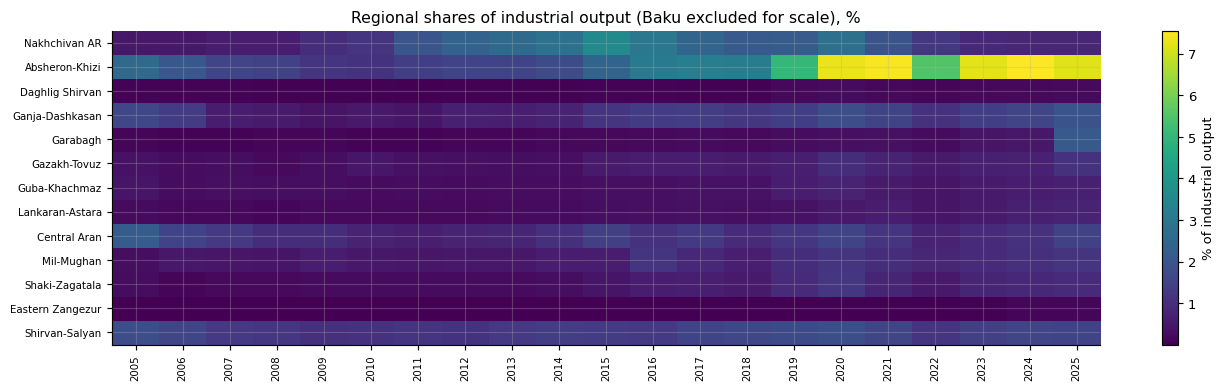

Baku city share of industrial output: 89.6% (2005), 84.6% (2019), 79.9% (2025)


In [27]:
X_REG = pd.DataFrame({'x1': np.log(F1H.rva_man), 'x2': np.log(F1H.va_min_n / F1H.va_man_n)})
D_REG = pd.DataFrame({'d2019': (X_REG.index >= 2019).astype(float)}, index=X_REG.index)
SYS_R = ShareSystem('14 economic regions', REG_GO.loc[EST0:LAST_ACT], 'Baku city', X_REG, dum=D_REG)
REG_LABEL = {LABEL['oil']: 'MNL: oil-sector mix (FR1 mining/manufacturing VA)', LABEL['scale+oil']: 'MNL: scale + oil-sector mix'}
T, ch, E = select(SYS_R, CANDS, SEL_ORIGINS, SEL_END)
kap, KT = 1.0, None
if ch != 'const':
    KT, kap = select_kappa(SYS_R, ch, SEL_ORIGINS, SEL_END, allow_full=bool(T.loc[LABEL['const'], 'non_inferior']))
    if not np.isfinite(kap): ch = 'const'
SELECT['R'] = dict(table=T.rename(index=REG_LABEL), chosen=ch, kappa=kap, ktable=KT)
display(SELECT['R']['table'].round(3))
if KT is not None: display(KT.round(3))
print(f'CHOSEN for regions: {REG_LABEL.get(LABEL[ch], LABEL[ch])}' + (f', kappa {kap:g}' if ch != 'const' else ''))
PAR['R'] = SYS_R.fit(ch, LAST_ACT, kappa=kap)
for c in CANDS:
    if c != ch:
        r = T.loc[LABEL[c]]
        reject(f'{REG_LABEL.get(LABEL[c], LABEL[c])} (regions)', 'regional share system', 'NOT CHOSEN',
               f'selection RMSE {r.RMSE_pp:.3f} pp vs {T.loc[LABEL[ch], "RMSE_pp"]:.3f} pp; DM/HLN p vs best {r.DM_p_vs_best:.2f}')
if ch != 'const':
    for k in SYS_R.units:
        for x in SPEC_X[ch]:
            COEF_ROWS.append(dict(system=SYS_R.name, branch=k, name=k, driver={'x1': 'ln FR1 real manufacturing VA', 'x2': 'ln FR1 mining/manufacturing VA'}[x],
                                  slope_used=PAR['R'][k]['b'][x], se_posterior=PAR['R'][k]['se'][x], shrink_B=PAR['R'][k].get('B', {}).get(x, np.nan),
                                  eg_coint_p=PAR['R'][k].get('eg_p', np.nan), estimator=PAR['R'][k].get('est', 'reference'),
                                  coherence=PAR['R'][k].get('rule', '')))
    SHARE_COEF = pd.DataFrame(COEF_ROWS)
    display(SHARE_COEF[SHARE_COEF.system == SYS_R.name].round(3))
fig, ax = plt.subplots(figsize=(13, 3.8))
hm = (REG_SH.loc[2005:LAST_ACT].drop(columns='Baku city') * 100).T
im = ax.imshow(hm.values, aspect='auto', cmap='viridis'); ax.set_yticks(range(len(hm))); ax.set_yticklabels(hm.index, fontsize=7)
ax.set_xticks(range(len(hm.columns))); ax.set_xticklabels(hm.columns, fontsize=7, rotation=90)
plt.colorbar(im, ax=ax, label='% of industrial output'); ax.set_title('Regional shares of industrial output (Baku excluded for scale), %')
plt.tight_layout(); plt.show()
print(f'Baku city share of industrial output: {REG_SH.loc[2005, "Baku city"]*100:.1f}% (2005), {REG_SH.loc[2019, "Baku city"]*100:.1f}% (2019), '
      f'{REG_SH.loc[LAST_ACT, "Baku city"]*100:.1f}% ({LAST_ACT})')

## Part 13 — Hold-out validation, 2020–2025 (NFR1)

The whole procedure is repeated with information available at the end of 2019: the specification and the shrinkage
intensity were chosen on windows scored ≤ 2019 (Part 11), every coefficient and anchor is re-estimated on data to
2019, and the model is simulated 2020–2025. FR1's sector value added and deflators enter at their **actual** values
(they are FR10's exogenous drivers, as household income is for FR5); **nothing endogenous to FR10 is fed in**:
branch output is simulated as share × (2019 manufacturing output × FR1 nominal VA index) — the same anchoring rule
as the forecast (output/VA ratio held at the anchor year) — and branch real output uses the 2019 relative price,
exactly as the forecast holds the 2025 relative price.

Benchmarks: a **random walk** (each branch's 2019 output held; for shares, constant shares) and **constant growth**
(each branch at its own average growth of 2014–2019; a slow-growth period for most branches, stated). Theil's $U$ =
model RMSE / benchmark RMSE on per-cent errors pooled over branches and years; DM/HLN on the loss averaged over
branches per target year (6 observations: low power, stated).

In [28]:
CUT, END = SEL_END, LAST_ACT
HY = list(range(CUT + 1, END + 1))
def holdout_branches(sy, sec, spec, kappa, units):
    par = sy.fit(spec, CUT, kappa=kappa)
    W = sy.predict(par, sy.X, HY)
    va_n = F1H[f'va_{SECV[sec]}_n']
    tot = GO[units].sum(axis=1)
    tot_sim = tot.loc[CUT] * va_n.loc[HY] / va_n.loc[CUT]
    nom = W.mul(tot_sim, axis=0)
    pman = F1H[f'p_{SECV[sec]}']
    real = nom.div(PDEF.loc[CUT, units], axis=1).div(pman.loc[HY] / pman.loc[CUT], axis=0)
    act_n, act_r = GO.loc[HY, units], Q.loc[HY, units]
    g_n = (GO.loc[CUT, units] / GO.loc[CUT - 5, units]) ** (1 / 5) - 1
    g_r = (Q.loc[CUT, units] / Q.loc[CUT - 5, units]) ** (1 / 5) - 1
    cg_n = pd.DataFrame({y: GO.loc[CUT, units] * (1 + g_n) ** (y - CUT) for y in HY}).T
    cg_r = pd.DataFrame({y: Q.loc[CUT, units] * (1 + g_r) ** (y - CUT) for y in HY}).T
    rw_n = pd.DataFrame([GO.loc[CUT, units].values] * len(HY), index=HY, columns=units)
    rw_r = pd.DataFrame([Q.loc[CUT, units].values] * len(HY), index=HY, columns=units)
    pe = lambda p, a: (np.log(p / a) * 100)          # log-per-cent errors (symmetric for large misses)
    E = {'nominal': (pe(nom, act_n), pe(rw_n, act_n), pe(cg_n, act_n)), 'real': (pe(real, act_r), pe(rw_r, act_r), pe(cg_r, act_r))}
    w19 = sy.W.loc[CUT, units]
    cg_sh = cg_n.div(cg_n.sum(axis=1), axis=0)
    E['shares_pp'] = ((W - sy.W.loc[HY]) * 100, (pd.DataFrame([sy.W.loc[CUT].values] * len(HY), index=HY, columns=units) - sy.W.loc[HY]) * 100,
                      (cg_sh - sy.W.loc[HY]) * 100)
    rows = []
    for meas, (m, r, c) in E.items():
        for wt in ['unweighted', 'share-weighted']:
            ww = (pd.DataFrame([w19.values] * len(HY), index=HY, columns=units) if wt == 'share-weighted'
                  else pd.DataFrame(1.0 / len(units), index=HY, columns=units))
            rm = lambda e: float(np.sqrt((ww * e ** 2).sum().sum() / ww.sum().sum()))
            lm, lr_, lc = (ww * m ** 2).sum(axis=1), (ww * r ** 2).sum(axis=1), (ww * c ** 2).sum(axis=1)
            s1, p1 = dm_hln(lm.values, lr_.values); s2, p2 = dm_hln(lm.values, lc.values)
            rows.append(dict(system=sy.name, measure=meas, weighting=wt, model=LABEL[spec], RMSE=rm(m), RMSE_random_walk=rm(r),
                             RMSE_constant_growth=rm(c), U_vs_random_walk=rm(m) / rm(r), U_vs_constant_growth=rm(m) / rm(c),
                             DM_p_vs_rw=p1, DM_p_vs_cg=p2))
    tot_err = float((np.log(tot_sim / tot.loc[HY]) * 100).abs().max())
    per = pd.DataFrame({'model RMSE, nominal %': np.sqrt((E['nominal'][0] ** 2).mean()),
                        'U vs RW': np.sqrt((E['nominal'][0] ** 2).mean()) / np.sqrt((E['nominal'][1] ** 2).mean()),
                        'U vs CG': np.sqrt((E['nominal'][0] ** 2).mean()) / np.sqrt((E['nominal'][2] ** 2).mean())})
    return pd.DataFrame(rows), per, tot_err

HOLD_ROWS, HOLD_PER, HOLD_TOT = [], {}, {}
for nm, sy, units in [('C', SYS_C, MANUF), ('B', SYS_B, MINING)]:
    for spec in CANDS:
        k_ = SELECT[nm]['kappa'] if spec == SELECT[nm]['chosen'] and spec != 'const' else 1.0
        r_, per, te = holdout_branches(sy, nm, spec, k_, units)
        r_['selected'] = spec == SELECT[nm]['chosen']
        HOLD_ROWS.append(r_)
        if spec == SELECT[nm]['chosen']:
            HOLD_PER[nm] = per.rename(index=BNAME); HOLD_TOT[nm] = te
# regions: shares only (the regional total changes coverage in 2019, F9)
for spec in CANDS:
    par = SYS_R.fit(spec, CUT, kappa=SELECT['R']['kappa'] if spec == SELECT['R']['chosen'] and spec != 'const' else 1.0)
    W = SYS_R.predict(par, SYS_R.X, HY)
    m = (W - SYS_R.W.loc[HY]) * 100
    r = (pd.DataFrame([SYS_R.W.loc[CUT].values] * len(HY), index=HY, columns=SYS_R.units) - SYS_R.W.loc[HY]) * 100
    g = (REG_GO.loc[CUT] / REG_GO.loc[CUT - 5]) ** (1 / 5) - 1
    cg = pd.DataFrame({y: REG_GO.loc[CUT] * (1 + g) ** (y - CUT) for y in HY}).T
    c = (cg.div(cg.sum(axis=1), axis=0) - SYS_R.W.loc[HY]) * 100
    rm = lambda e: float(np.sqrt((e ** 2).mean().mean()))
    _, p1 = dm_hln((m ** 2).sum(axis=1).values, (r ** 2).sum(axis=1).values); _, p2 = dm_hln((m ** 2).sum(axis=1).values, (c ** 2).sum(axis=1).values)
    HOLD_ROWS.append(pd.DataFrame([dict(system=SYS_R.name, measure='shares_pp', weighting='unweighted',
                                        model=REG_LABEL.get(LABEL[spec], LABEL[spec]), RMSE=rm(m), RMSE_random_walk=rm(r),
                                        RMSE_constant_growth=rm(c), U_vs_random_walk=rm(m) / rm(r), U_vs_constant_growth=rm(m) / rm(c),
                                        DM_p_vs_rw=p1, DM_p_vs_cg=p2, selected=spec == SELECT['R']['chosen'])]))
HOLD = pd.concat(HOLD_ROWS, ignore_index=True)
display(HOLD[HOLD.selected].round(3))
print('information only (the hold-out was used for no choice): every candidate re-estimated to 2019, unweighted nominal % errors')
display(HOLD[(~HOLD.selected) & (HOLD.measure.isin(['nominal', 'shares_pp'])) & (HOLD.weighting == 'unweighted')]
        [['system', 'measure', 'model', 'RMSE', 'U_vs_random_walk', 'U_vs_constant_growth']].round(3))
print(f'anchoring-rule error (manufacturing output simulated from FR1 VA with the 2019 output/VA ratio): at most '
      f'{HOLD_TOT["C"]:.1f} log-% over 2020-2025; mining {HOLD_TOT["B"]:.1f}')
display(HOLD_PER['C'].round(2).sort_values('model RMSE, nominal %'))

,system,measure,weighting,model,RMSE,RMSE_random_walk,RMSE_constant_growth,U_vs_random_walk,U_vs_constant_growth,DM_p_vs_rw,DM_p_vs_cg,selected
0,manufacturing (24 branches),nominal,unweighted,constant shares,47.315,63.905,61.548,0.740,0.769,0.055,0.099,True
1,manufacturing (24 branches),nominal,share-weighted,constant shares,28.139,46.858,38.906,0.601,0.723,0.026,0.067,True
2,manufacturing (24 branches),real,unweighted,constant shares,142.364,155.416,137.608,0.916,1.035,0.011,0.041,True
3,manufacturing (24 branches),real,share-weighted,constant shares,66.017,75.443,55.999,0.875,1.179,0.020,0.001,True
4,manufacturing (24 branches),shares_pp,unweighted,constant shares,1.462,1.462,2.493,1.000,0.586,1.000,0.107,True
5,manufacturing (24 branches),shares_pp,share-weighted,constant shares,2.970,2.970,4.603,1.000,0.645,1.000,0.077,True
30,mining (4 branches),nominal,unweighted,constant shares,55.733,57.960,90.407,0.962,0.616,0.600,0.036,True
31,mining (4 branches),nominal,share-weighted,constant shares,22.025,40.016,50.997,0.550,0.432,0.108,0.004,True
32,mining (4 branches),real,unweighted,constant shares,48.241,52.913,105.657,0.912,0.457,0.003,0.015,True
33,mining (4 branches),real,share-weighted,constant shares,28.953,31.609,54.575,0.916,0.531,0.006,0.019,True


information only (the hold-out was used for no choice): every candidate re-estimated to 2019, unweighted nominal % errors


,system,measure,model,RMSE,U_vs_random_walk,U_vs_constant_growth
6,manufacturing (24 branches),nominal,MNL: scale (FR1 real sector VA),63.336,0.991,1.029
10,manufacturing (24 branches),shares_pp,MNL: scale (FR1 real sector VA),2.247,1.537,0.901
12,manufacturing (24 branches),nominal,MNL: oil export price,48.597,0.760,0.790
16,manufacturing (24 branches),shares_pp,MNL: oil export price,1.458,0.997,0.585
18,manufacturing (24 branches),nominal,MNL: scale + oil price,66.203,1.036,1.076
22,manufacturing (24 branches),shares_pp,MNL: scale + oil price,2.134,1.460,0.856
24,manufacturing (24 branches),nominal,combination: 1/2 constant + 1/2 MNL scale,53.326,0.834,0.866
28,manufacturing (24 branches),shares_pp,combination: 1/2 constant + 1/2 MNL scale,1.509,1.033,0.605
36,mining (4 branches),nominal,MNL: scale (FR1 real sector VA),55.733,0.962,0.616
40,mining (4 branches),shares_pp,MNL: scale (FR1 real sector VA),3.122,1.000,0.337


anchoring-rule error (manufacturing output simulated from FR1 VA with the 2019 output/VA ratio): at most 11.7 log-% over 2020-2025; mining 5.6


,"model RMSE, nominal %",U vs RW,U vs CG
Basic metals,9.550,0.190,0.570
Refined petroleum products,10.370,0.240,0.250
Non-metallic minerals,12.200,0.260,0.630
Beverages,16.820,0.360,1.520
Paper products,18.590,0.340,0.310
Fabricated metal products,19.890,0.330,0.730
Wearing apparel,20.810,0.650,1.450
Food products,23.080,0.900,2.500
Rubber and plastics,24.480,0.740,0.410
Leather and footwear,26.470,0.720,0.900


### 13.1 Hold-out of the forecasting model actually used (oil-linked block + non-oil allocation)

Everything re-estimated on data to 2019: the pooled elasticity, the oil-price elasticities of the refining and
chemicals deflators, and their capacity factors (2017–2019 average throughput). Manufacturing output is simulated
from FR1's actual nominal value added with the 2019 output/VA ratio, as in the forecast.

In [29]:
def holdout_full(mode, cut=CUT, end=END):
    hy = list(range(cut + 1, end + 1)); yy = [cut] + hy
    b_ = fit_pooled(cut)[0]
    eps = {b: float(ols(np.log(PDEF[b]).diff().loc[2006:cut], np.log(OILAZN).diff().loc[2006:cut].rename('x').to_frame()).beta[1]) for b in OIL}
    capf = {b: float(THR[b].loc[cut - 2:cut].mean() / THR[b].loc[cut]) for b in OIL}
    gc = GO[MANUF].sum(axis=1).loc[cut] * F1H.va_man_n.loc[yy] / F1H.va_man_n.loc[cut]
    nom = pd.DataFrame(index=yy, columns=MANUF, dtype=float); real = nom.copy()
    oi = OILAZN.loc[yy] / OILAZN.loc[cut]
    for b in OIL:
        real[b] = Q.loc[cut, b] * np.where(np.array(yy) == cut, 1.0, capf[b]); nom[b] = real[b] * PDEF.loc[cut, b] * oi ** eps[b]
    rem = gc - nom[OIL].sum(axis=1)
    s0 = SHH['C'].loc[cut, NONOIL].to_numpy(float)
    dr = (RH['C'].loc[yy, NONOIL] - RH['C'].loc[cut, NONOIL]).to_numpy(float)
    nom[NONOIL] = alloc(s0, dr, b_, mode) * rem.to_numpy(float)[:, None]
    pm = F1H.p_man.loc[yy] / F1H.p_man.loc[cut]
    for b in NONOIL: real[b] = nom[b] / (PDEF.loc[cut, b] * pm)
    nom, real = nom.loc[hy], real.loc[hy]
    act_n, act_r = GO.loc[hy, MANUF], Q.loc[hy, MANUF]
    gn = (GO.loc[cut, MANUF] / GO.loc[cut - 5, MANUF]) ** 0.2 - 1; gr = (Q.loc[cut, MANUF] / Q.loc[cut - 5, MANUF]) ** 0.2 - 1
    bm = {'random walk': (pd.DataFrame([GO.loc[cut, MANUF].values] * len(hy), index=hy, columns=MANUF), pd.DataFrame([Q.loc[cut, MANUF].values] * len(hy), index=hy, columns=MANUF)),
          'constant growth': (pd.DataFrame({y: GO.loc[cut, MANUF] * (1 + gn) ** (y - cut) for y in hy}).T, pd.DataFrame({y: Q.loc[cut, MANUF] * (1 + gr) ** (y - cut) for y in hy}).T)}
    w19 = SH_MAN.loc[cut, MANUF]
    rows = []
    for meas, m, a, k in [('nominal', nom, act_n, 0), ('real', real, act_r, 1)]:
        em = np.log(m / a) * 100
        for wt in ['unweighted', 'share-weighted']:
            ww = (pd.DataFrame([w19.values] * len(hy), index=hy, columns=MANUF) if wt == 'share-weighted' else pd.DataFrame(1 / 24, index=hy, columns=MANUF))
            rm = lambda e: float(np.sqrt((ww * e ** 2).sum().sum() / ww.sum().sum()))
            r = dict(system='manufacturing (24 branches): forecasting model', measure=meas, weighting=wt, model=f'oil block + {mode}', RMSE=rm(em))
            for nb, (bn, br) in bm.items():
                eb = np.log((bn if k == 0 else br) / a) * 100
                r[f'U_vs_{nb.replace(" ", "_")}'] = rm(em) / rm(eb)
                r[f'DM_p_vs_{"rw" if nb == "random walk" else "cg"}'] = dm_hln((ww * em ** 2).sum(axis=1).values, (ww * eb ** 2).sum(axis=1).values)[1]
            rows.append(r)
    per = pd.DataFrame({'real error 2020-25, mean abs log %': (np.log(real / act_r) * 100).abs().mean()}).rename(index=BNAME)
    return pd.DataFrame(rows), per, dict(beta=b_, **{f'eps_{b}': v for b, v in eps.items()}, **{f'capf_{b}': v for b, v in capf.items()})
HF = {m: holdout_full(m) for m in ['combo', 'pooled', 'const']}
HOLD_FULL = pd.concat([HF[m][0].assign(selected=(m == MAN_MODE)) for m in HF], ignore_index=True)
display(HOLD_FULL.round(3))
print('pre-cut parameters: ' + ', '.join(f'{k} {v:.3f}' for k, v in HF[MAN_MODE][2].items()))
HOLD = pd.concat([HOLD_FULL, HOLD.assign(selected=HOLD.selected & HOLD.system.str.contains('regions'),
                                         system=np.where(HOLD.system.str.contains('regions'), HOLD.system, HOLD.system + ' (Part 11 share systems)'))], ignore_index=True)

,system,measure,weighting,model,RMSE,U_vs_random_walk,DM_p_vs_rw,U_vs_constant_growth,DM_p_vs_cg,selected
0,manufacturing (24 branches): forecasting model,nominal,unweighted,oil block + combo,50.664,0.793,0.099,0.823,0.180,True
1,manufacturing (24 branches): forecasting model,nominal,share-weighted,oil block + combo,38.160,0.814,0.039,0.981,0.714,True
2,manufacturing (24 branches): forecasting model,real,unweighted,oil block + combo,139.221,0.896,0.008,1.012,0.456,True
3,manufacturing (24 branches): forecasting model,real,share-weighted,oil block + combo,64.474,0.855,0.023,1.151,0.000,True
4,manufacturing (24 branches): forecasting model,nominal,unweighted,oil block + pooled,50.821,0.795,0.101,0.826,0.184,False
5,manufacturing (24 branches): forecasting model,nominal,share-weighted,oil block + pooled,37.915,0.809,0.038,0.975,0.631,False
6,manufacturing (24 branches): forecasting model,real,unweighted,oil block + pooled,139.085,0.895,0.008,1.011,0.494,False
7,manufacturing (24 branches): forecasting model,real,share-weighted,oil block + pooled,64.513,0.855,0.024,1.152,0.000,False
8,manufacturing (24 branches): forecasting model,nominal,unweighted,oil block + const,50.538,0.791,0.098,0.821,0.177,False
9,manufacturing (24 branches): forecasting model,nominal,share-weighted,oil block + const,38.425,0.820,0.042,0.988,0.811,False


pre-cut parameters: beta 0.166, eps_19 0.332, capf_19 0.950


## Part 14 — Forecast 2026–2030 under FR1's three scenarios

### 14.1 How the pieces connect

| Object | Rule | Driver (scenario-specific) |
|---|---|---|
| Section output | 2025 output × FR1 nominal VA index (output/VA held at 2025) | FR1 `rva_*` × `p_*` |
| Refining, chemicals | real = 2025 × capacity factor (2023–25 average throughput); price = 2025 × (oil price in manat)^ε | DSK 018 throughput; FR1 oil price |
| Non-oil manufacturing branches | (manufacturing output − oil-linked output) × shares from §11.5 (combination or pooled) | FR1 `rva_con`, `rcons`, `rinv_non`, `rva_man` |
| Mining branches | quarrying by the pre-cut rule (v2: neutral null unless the construction link wins); metal ores by the pre-cut rule; crude oil, gas and support services from FR1 `rgdpoil`, nominal = residual of FR1 mining output (§11.6) | FR1 `rva_con`, `rgdpoil`, `p_con`, `p_gdp` |
| Real non-oil branch output | nominal ÷ (2025 deflator × FR1 section deflator index) | FR1 `p_*` |
| Non-state share of industry | output-weighted **2025 within-branch** non-state shares — pure composition, not an ownership forecast | — |
| Regions | Part 12 system × industry output index | FR1 oil mix, scale |
| Employment; wages | 2025 headcount × FR4 section index; 2025 wage × FR1 average-wage index (F13) | FR4; FR1 |
| GOS margin (baseline) | labour share of VA held at its 2023–25 average (a neutral, conditional margin); FR1-wage path and constant product wages are sensitivities | — |
| SME share, entry/exit | held / presented (F11) | — |

One function (`core`) computes every indicator for any number of driver paths at once: the three scenarios, the
levers and the 500 bootstrap replications all go through the same code.

In [30]:
fr3b = FR3W[FR3W.scenario == 'Baseline'].set_index('year')
_c3 = [c for c in fr3b.columns if c in BCODES]
_lev = (fr3b.loc[FC_YEARS[0], _c3] / WAGEC.loc[LAST_ACT, _c3] - 1) * 100
_g = ((fr3b.loc[FC_YEARS[-1], _c3] / fr3b.loc[FC_YEARS[0], _c3]) ** (1 / (H - 1)) - 1) * 100
finding('F13', 'FR3\'s branch wage paths are not anchored on 2025 branch wages and share one growth rate',
        f'FR3 2026 branch wage / DSK 2025 branch wage - 1 ranges {_lev.min():+.0f}% to {_lev.max():+.0f}% across {len(_lev)} branches; '
        f'2026-2030 growth is {_g.min():.2f}-{_g.max():.2f}% a year for every branch',
        'FR10 applies FR1\'s average-wage index to each branch\'s 2025 DSK wage; FR3 is not used for levels')
FINDINGS = pd.DataFrame(FIND).set_index('id')

YRS = [LAST_ACT] + FC_YEARS
DVARS = ['rva_min', 'rva_man', 'rva_elc', 'rva_wat', 'p_min', 'p_man', 'p_elc', 'p_wat', 'oil_exp_price', 'wage', 'emp',
         'rva_con', 'rcons', 'rinv_non', 'rgdpoil', 'p_con', 'p_gdp']
def drv_arrays(fcs):
    '''fcs: FR1 rows indexed (draw, year) -> dict of arrays (R, 6), 2025 actual (FR1 history) first.'''
    out = {}
    for v in DVARS:
        M = fcs[v].unstack('year')[FC_YEARS].to_numpy(float)
        out[v] = np.column_stack([np.full(len(M), F1H.loc[LAST_ACT, v] if v != 'emp' else np.nan), M])
    for s_, v in SECV.items():
        out[f'va_{v}_n'] = out[f'rva_{v}'] * out[f'p_{v}']
    return out
def scen_arrays(s_):
    return drv_arrays(F1F[F1F.scenario == s_].assign(draw=0).set_index(['draw', 'year']))
def fr4_index(scen):
    h = FR4H[FR4H.scenario == scen].set_index('year')
    return {s_: (h.loc[YRS, c] / h.loc[LAST_ACT, c]).to_numpy(float)[None, :] for s_, c in [('B', 'mining'), ('C', 'manuf'), ('D', 'elec'), ('E', 'water')]}

EMP25 = EMP_DSK.loc[LAST_ACT, BCODES]; WAGE25 = WAGEC.loc[LAST_ACT, BCODES]
OTP_SH = (INC.OTP / INC.VA).xs(LAST_ACT, level=1)
LS_AVG = (INC.CE / INC.VA).unstack(0).loc[LAST_ACT - 2:LAST_ACT].mean()
VAGO25 = (NA_VA[MANUF] / NA_GO[MANUF]).loc[LAST_ACT]
WBVA_AVG = (WBILL[MANUF] / NA_VA[MANUF]).loc[LAST_ACT - 2:LAST_ACT].mean()
S25 = {g: SHH[g].loc[LAST_ACT, u].to_numpy(float) for g, u in GROUP.items()}
IC_, IB_ = [BCODES.index(b) for b in NONOIL], [BCODES.index(b) for b in MINING]
NS25 = NS.loc[LAST_ACT, BCODES].to_numpy(float)

def core(D, emp_idx, emp_ratio=None, zsh=None, beta=None, mode=None, capf=None, margin='labour_share', regb=None, q08=None):
    beta = BETA if beta is None else beta; mode = MAN_MODE if mode is None else mode; capf = CAPF if capf is None else capf
    R_ = D['rva_man'].shape[0]; T_ = len(YRS); zsh = zsh or {}; out = {}
    er = np.ones((R_, T_)) if emp_ratio is None else emp_ratio
    t0 = (np.arange(T_) == 0)[None, :]
    secgo = {s_: SEC_GO.loc[LAST_ACT, s_] * D[f'va_{v}_n'] / D[f'va_{v}_n'][:, :1] for s_, v in SECV.items()}
    pidx = {s_: D[f'p_{v}'] / D[f'p_{v}'][:, :1] for s_, v in SECV.items()}
    nom = np.zeros((R_, T_, len(BCODES))); real = np.zeros_like(nom)
    oilidx = D['oil_exp_price'] / D['oil_exp_price'][:, :1]
    for b in OIL:
        j = BCODES.index(b)
        real[..., j] = Q.loc[LAST_ACT, b] * np.where(t0, 1.0, capf[b])
        nom[..., j] = real[..., j] * PDEF.loc[LAST_ACT, b] * oilidx ** EPS_OIL[b]
    rem = secgo['C'] - nom[..., [BCODES.index(b) for b in OIL]].sum(-1)
    out['rem_clipped'] = int((rem < 0.01 * secgo['C']).sum()); rem = np.maximum(rem, 0.01 * secgo['C'])
    for g, idx, tot in [('C', IC_, rem)]:
        rel = rel_index(lambda v: D[v], GROUP[g], g)
        dr = np.stack([rel[b] - rel[b][:, :1] for b in GROUP[g]], -1)
        W = alloc(S25[g], dr, beta, mode, zsh.get(g))
        nom[..., idx] = W * tot[..., None]
        real[..., idx] = nom[..., idx] / (PDEF.loc[LAST_ACT, GROUP[g]].to_numpy(float) * pidx[g][..., None])
    # mining (Part 11.6): quarrying from construction, metal ores neutral, the oil part absorbs the residual
    ix = lambda v: D[v] / D[v][:, :1]
    j6, j7, j8, j9 = (BCODES.index(b) for b in ['06', '07', '08', '09'])
    real[..., j8] = Q.loc[LAST_ACT, '08'] * (np.where(t0, 1.0, MINING_RULES['q08_level_factor']) * np.ones_like(ix('rva_con'))
                                             if (q08 or MINING_RULES['rule08']).startswith('neutral') else ix('rva_con') ** MINING_RULES['e08'])
    nom[..., j8] = real[..., j8] * PDEF.loc[LAST_ACT, '08'] * ix('p_con')
    r7 = MINING_RULES['rule07']
    q7 = (np.where(t0, 1.0, MINING_RULES['q07_level_factor']) if r7.startswith('neutral') else ix('rva_min') if 'mining' in r7 else ix('rva_con'))
    real[..., j7] = Q.loc[LAST_ACT, '07'] * q7 * np.ones_like(ix('p_gdp'))
    nom[..., j7] = real[..., j7] * PDEF.loc[LAST_ACT, '07'] * ix('p_gdp')
    for j, b in [(j6, '06'), (j9, '09')]: real[..., j] = Q.loc[LAST_ACT, b] * ix('rgdpoil')
    resid = secgo['B'] - nom[..., j7] - nom[..., j8]
    out['oil_resid_floor'] = int((resid < 0.05 * secgo['B']).sum()); resid = np.maximum(resid, 0.05 * secgo['B'])
    nom[..., j6] = resid * MINING_RULES['oil_split_06']; nom[..., j9] = resid * (1 - MINING_RULES['oil_split_06'])
    out['oil_defl_idx'] = ((nom[..., j6] + nom[..., j9]) / (real[..., j6] + real[..., j9])) / ((nom[:, :1, j6] + nom[:, :1, j9]) / (real[:, :1, j6] + real[:, :1, j9]))
    out['p_min_idx'] = pidx['B']
    for b, s_ in [('35', 'D'), ('36', 'E')]:
        j = BCODES.index(b); nom[..., j] = secgo[s_]; real[..., j] = nom[..., j] / (PDEF.loc[LAST_ACT, b] * pidx[s_])
    # regions
    par = PAR['R']; xs = SPEC_X.get(par['spec'], []); units = REG_NAMES
    LO25 = np.array([SYS_R.LO[k].loc[LAST_ACT] for k in units])
    mix = np.log(D['va_min_n'] / D['va_man_n']); mix = mix - mix[:, :1] + SYS_R.X.loc[LAST_ACT, 'x2']
    XR = np.stack([np.log(D['rva_man']), mix], -1)
    if xs:
        b0 = np.array([[par[k]['b'][x] for x in xs] for k in units])
        br = np.broadcast_to(b0, (R_,) + b0.shape) if regb is None else regb
        ix = [{'x1': 0, 'x2': 1}[x] for x in xs]
        z = LO25[None, None, :] + np.einsum('rtx,rkx->rtk', XR[..., ix] - XR[:, :1, ix], br)
    else:
        z = np.broadcast_to(LO25, (R_, T_, len(units))).copy()
    z = z + (zsh.get('R') if zsh.get('R') is not None else 0)
    e = np.exp(z - z.max(-1, keepdims=True)); out['reg_sh'] = e / e.sum(-1, keepdims=True)
    # employment, wages, productivity
    eidx = {s_: emp_idx[s_] * er for s_ in SECV}
    emp = np.stack([EMP25[b] * eidx[BSEC[b]] for b in BCODES], -1)
    widx = D['wage'] / D['wage'][:, :1]
    out.update(nom=nom, real=real, emp=emp, lp=real / emp * 1e3, sec_go=np.stack([secgo[s_] for s_ in SECV], -1))
    out['wage'] = WAGE25.to_numpy(float)[None, None, :] * widx[..., None]
    out['sh_ind'] = nom / nom.sum(-1, keepdims=True)
    mi = [BCODES.index(b) for b in MANUF]
    out['sh_man'] = nom[..., mi] / nom[..., mi].sum(-1, keepdims=True)
    out['ns_share'] = (nom * NS25).sum(-1) / nom.sum(-1); out['hhi_man'] = (out['sh_man'] ** 2).sum(-1) * 1e4
    gs, ls, vas, ces, ots = [], [], [], [], []
    for s_, v in SECV.items():
        va = INC.loc[(s_, LAST_ACT), 'VA'] * D[f'va_{v}_n'] / D[f'va_{v}_n'][:, :1]
        ce25 = INC.loc[(s_, LAST_ACT), 'CE']
        if margin == 'labour_share': ce = np.where(t0, ce25, LS_AVG[s_] * va)
        elif margin == 'fr1_wage':   ce = ce25 * widx * eidx[s_]
        else:                        ce = ce25 * pidx[s_] * eidx[s_]          # wages constant in product terms
        gs.append((va - ce - OTP_SH[s_] * va) / va * 100); ls.append(ce / va * 100); vas.append(va); ces.append(ce); ots.append(OTP_SH[s_] * va)
    out['sec_gos'] = np.stack(gs, -1); out['sec_ls'] = np.stack(ls, -1)
    out['sec_va'], out['sec_ce'], out['sec_otp'] = np.stack(vas, -1), np.stack(ces, -1), np.stack(ots, -1)
    na_go = NA_GO.loc[LAST_ACT, MANUF].to_numpy(float) * nom[..., mi] / nom[:, :1, mi]
    va_b = na_go * VAGO25[MANUF].to_numpy(float)
    if margin == 'labour_share':
        wb = np.where(t0[..., None], WBILL.loc[LAST_ACT, MANUF].to_numpy(float), WBVA_AVG[MANUF].to_numpy(float) * va_b)
    else:
        wi = widx if margin == 'fr1_wage' else pidx['C']
        wb = WBILL.loc[LAST_ACT, MANUF].to_numpy(float) * wi[..., None] * eidx['C'][..., None]
    out['gosp'] = (va_b - wb) / na_go * 100
    return out

In [31]:
SKEYS = list(SECV)
def frames(o, i=0):
    F_ = lambda a, cols: pd.DataFrame(a[i], index=YRS, columns=cols)
    R = {'nom': F_(o['nom'], BCODES), 'real': F_(o['real'], BCODES), 'emp': F_(o['emp'], BCODES), 'lp': F_(o['lp'], BCODES),
         'wage': F_(o['wage'], BCODES), 'sec_go': F_(o['sec_go'], SKEYS), 'sh_ind': F_(o['sh_ind'], BCODES),
         'sh_man': F_(o['sh_man'], MANUF), 'gosp': F_(o['gosp'], MANUF), 'reg_sh': F_(o['reg_sh'], REG_NAMES),
         'ns_share': pd.Series(o['ns_share'][i], index=YRS)}
    R['reg_go'] = R['reg_sh'].mul(REG_GO.loc[LAST_ACT].sum() * R['nom'].sum(axis=1) / R['nom'].loc[LAST_ACT].sum(), axis=0)
    R['sec_fin'] = pd.concat({s_: pd.DataFrame({'VA': o['sec_va'][i, :, j], 'CE': o['sec_ce'][i, :, j], 'OTP': o['sec_otp'][i, :, j],
                                                 'GOS_share_VA': o['sec_gos'][i, :, j], 'labour_share_VA': o['sec_ls'][i, :, j]}, index=YRS)
                              for j, s_ in enumerate(SKEYS)}, names=['sec', 'year'])
    R['sec_fin']['GOS'] = R['sec_fin'].VA - R['sec_fin'].CE - R['sec_fin'].OTP
    return R
def solve(s_, **kw):
    return frames(core(scen_arrays(s_), fr4_index(s_), **kw))
SOL = {s_: solve(s_) for s_ in SCEN}
B_ = SOL['Baseline']
cagr = lambda s: ((s.loc[FC_YEARS[-1]] / s.loc[LAST_ACT]) ** (1 / H) - 1) * 100
BR_FC = pd.DataFrame({'branch': [BNAME[b] for b in BCODES], 'section': [SECT[BSEC[b]] for b in BCODES],
                      'model': ['capacity + oil price' if b in OIL else ('quarrying: ' + MINING_RULES['rule08']) if b == '08' else
                                ('metal ores: ' + MINING_RULES['rule07']) if b == '07' else 'FR1 oil & gas real; residual nominal' if b in ('06', '09')
                                else ('related-sector: ' + LINK[b]) if b in LINK else 'sector total' for b in BCODES],
                      f'nominal {LAST_ACT}': B_['nom'].loc[LAST_ACT].values, f'nominal {FC_YEARS[-1]}': B_['nom'].loc[FC_YEARS[-1]].values,
                      'nominal growth % pa': cagr(B_['nom']).values, 'real growth % pa': cagr(B_['real']).values,
                      f'share of industry {LAST_ACT} %': B_['sh_ind'].loc[LAST_ACT].values * 100,
                      f'share of industry {FC_YEARS[-1]} %': B_['sh_ind'].loc[FC_YEARS[-1]].values * 100,
                      'LP growth % pa': cagr(B_['lp']).values}, index=BCODES)
display(BR_FC.round(2))
MIN_PATH = BR_FC.loc[MINING, ['branch', 'model', f'nominal {LAST_ACT}', f'nominal {FC_YEARS[-1]}', 'nominal growth % pa', 'real growth % pa']]
_od = pd.Series(core(scen_arrays('Baseline'), fr4_index('Baseline'))['oil_defl_idx'][0], index=YRS)
MIN_REC = dict(max_gap_pct=float((B_['nom'][MINING].sum(axis=1) / B_['sec_go']['B'] - 1).abs().max() * 100),
               implied_oil_deflator_growth_pa=cagr(_od), fr1_mining_deflator_growth_pa=cagr(pd.Series(scen_arrays('Baseline')['p_min'][0], index=YRS)))
print(f"mining reconciliation: 06+07+08+09 = FR1 mining output to {MIN_REC['max_gap_pct']:.1e}%; implied oil-part deflator "
      f"{MIN_REC['implied_oil_deflator_growth_pa']:+.2f}% a year vs FR1 mining deflator {MIN_REC['fr1_mining_deflator_growth_pa']:+.2f}%")
assert MIN_REC['max_gap_pct'] < 1e-9, 'mining branches do not reconcile with FR1 mining output'
nm_ = BR_FC.loc[NONOIL, 'real growth % pa']
print(f'manufacturing real branch growth 2026-30: min {BR_FC.loc[MANUF, "real growth % pa"].min():+.2f}% '
      f'({BR_FC.loc[MANUF, "real growth % pa"].idxmin()}), max {BR_FC.loc[MANUF, "real growth % pa"].max():+.2f}% ({BR_FC.loc[MANUF, "real growth % pa"].idxmax()}); '
      f'refining {BR_FC.loc["19", "real growth % pa"]:+.2f}% real, {BR_FC.loc["19", "nominal growth % pa"]:+.2f}% nominal')
# implied non-oil manufacturing growth (Törnqvist over the 22 non-oil branches) vs its own history
def tq_growth(nomF, realF, cols):
    w = nomF[cols].div(nomF[cols].sum(axis=1), axis=0); w = (w + w.shift(1)) / 2
    return (w * np.log(realF[cols]).diff()).sum(axis=1, min_count=1) * 100
NONOIL_FC = tq_growth(B_['nom'], B_['real'], NONOIL).loc[FC_YEARS].mean()
_h = tq_growth(GO, Q, NONOIL)
_roll = _h.rolling(5).mean().loc[2010:LAST_ACT]
NONOIL_HIST = dict(avg_2010_19=_h.loc[2010:2019].mean(), avg_2021_25=_h.loc[2021:LAST_ACT].mean(), best_5yr=_roll.max(), worst_5yr=_roll.min(),
                   forecast_2026_30=NONOIL_FC, flag=('ABOVE best 5-yr' if NONOIL_FC > _roll.max() else ''))
print('implied non-oil manufacturing real growth (Törnqvist, % a year): ' + ', '.join(f'{k} {v:+.2f}' if isinstance(v, float) else f'{k} {v}' for k, v in NONOIL_HIST.items()))
SEC_FC = pd.DataFrame({SECT[s_]: [cagr(B_['sec_go'][s_]), B_['sec_fin'].loc[(s_, LAST_ACT), 'GOS_share_VA'],
                                  B_['sec_fin'].loc[(s_, FC_YEARS[-1]), 'GOS_share_VA']] for s_ in SECV},
                      index=['nominal output growth % pa', f'GOS % of VA {LAST_ACT}', f'GOS % of VA {FC_YEARS[-1]}']).T
display(SEC_FC.round(2))
mshare = lambda S, y: S['sec_go'].loc[y, 'B'] / S['nom'].sum(axis=1).loc[y] * 100
SCEN_SUM = pd.DataFrame({s_: {'industry nominal output growth % pa': cagr(SOL[s_]['nom'].sum(axis=1)),
                              'manufacturing nominal growth % pa': cagr(SOL[s_]['nom'][MANUF].sum(axis=1)),
                              'manufacturing real growth % pa (FR1 rva_man)': cagr(pd.Series(scen_arrays(s_)['rva_man'][0], index=YRS)),
                              'refining real growth % pa': cagr(SOL[s_]['real']['19']),
                              f'mining share of industry {FC_YEARS[-1]} %': mshare(SOL[s_], FC_YEARS[-1]),
                              f'non-state share {FC_YEARS[-1]} % (composition)': SOL[s_]['ns_share'].loc[FC_YEARS[-1]] * 100,
                              f'HHI manufacturing {FC_YEARS[-1]}': float(hhi(SOL[s_]['sh_man']).loc[FC_YEARS[-1]]),
                              f'Baku share {FC_YEARS[-1]} %': SOL[s_]['reg_sh'].loc[FC_YEARS[-1], 'Baku city'] * 100,
                              f'manufacturing GOS % VA {FC_YEARS[-1]}': SOL[s_]['sec_fin'].loc[('C', FC_YEARS[-1]), 'GOS_share_VA']}
                         for s_ in SCEN}).T
display(SCEN_SUM.round(2))
# cross-sector multipliers implied by the pooled elasticity: d ln(branch output) / d ln(related sector), at given
# sector total, = beta x (1 - share of the branch in its group); halved under the equal-weight combination
wgt = 1.0 if MAN_MODE == 'pooled' else 0.5
MULT = pd.DataFrame([dict(branch=BNAME[b], related_sector=LINK[b], share_2025=float(SHH['B' if b in MINING else 'C'].loc[LAST_ACT, b]),
                          multiplier=wgt * BETA * (1 - float(SHH['B' if b in MINING else 'C'].loc[LAST_ACT, b])),
                          multiplier_p5=wgt * max(BETA - 1.645 * BETA_SE, 0) * (1 - float(SHH['B' if b in MINING else 'C'].loc[LAST_ACT, b])),
                          multiplier_p95=wgt * (BETA + 1.645 * BETA_SE) * (1 - float(SHH['B' if b in MINING else 'C'].loc[LAST_ACT, b])))
                     for b in LINK], index=list(LINK))
print('implied cross-sector multipliers: % change in branch output per 1% change in its related sector, sector total given')
display(MULT.round(3))

,branch,section,model,nominal 2025,nominal 2030,nominal growth % pa,real growth % pa,share of industry 2025 %,share of industry 2030 %,LP growth % pa
06,Crude oil and natural gas,Mining,FR1 oil & gas real; residual nominal,"33,349.000","25,552.210",-5.190,-3.380,52.930,35.630,-1.270
07,Metal ores,Mining,metal ores: grows with FR1 mining VA,729.900,759.740,0.800,-3.120,1.160,1.060,-1.010
08,Other mining and quarrying,Mining,quarrying: neutral: held at the last actual level,244.800,273.480,2.240,0.000,0.390,0.380,2.180
09,Mining support services,Mining,FR1 oil & gas real; residual nominal,"2,698.400","2,067.530",-5.190,-3.380,4.280,2.880,-1.270
10,Food products,Manufacturing,related-sector: rcons,"4,984.500","9,615.320",14.040,9.720,7.910,13.410,8.820
11,Beverages,Manufacturing,related-sector: rcons,916.200,"1,767.390",14.040,9.720,1.450,2.460,8.820
12,Tobacco products,Manufacturing,sector total,"1,116.900","2,181.920",14.330,10.000,1.770,3.040,9.090
13,Textiles,Manufacturing,sector total,412.500,805.840,14.330,10.000,0.650,1.120,9.090
14,Wearing apparel,Manufacturing,sector total,198.000,386.800,14.330,10.000,0.310,0.540,9.090
15,Leather and footwear,Manufacturing,sector total,35.300,68.960,14.330,10.000,0.060,0.100,9.090


mining reconciliation: 06+07+08+09 = FR1 mining output to 0.0e+00%; implied oil-part deflator -1.87% a year vs FR1 mining deflator -1.93%
manufacturing real branch growth 2026-30: min -0.36% (19), max +10.00% (12); refining -0.36% real, -0.96% nominal
implied non-oil manufacturing real growth (Törnqvist, % a year): avg_2010_19 +7.72, avg_2021_25 +10.06, best_5yr +13.82, worst_5yr -0.98, forecast_2026_30 +9.28, flag 


,nominal output growth % pa,GOS % of VA 2025,GOS % of VA 2030
Mining,-5.000,93.560,94.390
Manufacturing,10.970,65.820,65.810
Electricity,8.840,65.440,65.890
Water,8.680,-51.610,-40.050


,industry nominal output growth % pa,manufacturing nominal growth % pa,manufacturing real growth % pa (FR1 rva_man),refining real growth % pa,mining share of industry 2030 %,non-state share 2030 % (composition),HHI manufacturing 2030,Baku share 2030 %,manufacturing GOS % VA 2030
Baseline,2.620,10.970,6.760,-0.360,39.960,75.870,"1,203.150",77.120,65.810
Adverse,-2.600,6.950,3.180,-0.360,33.680,72.640,"1,218.840",76.150,65.810
Reform,6.700,14.870,10.220,-0.360,42.250,77.730,"1,190.290",77.420,65.810


implied cross-sector multipliers: % change in branch output per 1% change in its related sector, sector total given


,branch,related_sector,share_2025,multiplier,multiplier_p5,multiplier_p95
23,Non-metallic minerals,rva_con,0.092,0.100,0.032,0.167
25,Fabricated metal products,rva_con,0.046,0.105,0.034,0.175
08,Other mining and quarrying,rva_con,0.007,0.109,0.035,0.182
10,Food products,rcons,0.307,0.076,0.025,0.127
11,Beverages,rcons,0.056,0.103,0.034,0.173
27,Electrical equipment,rinv_non,0.017,0.108,0.035,0.181
28,Machinery and equipment,rinv_non,0.008,0.109,0.035,0.182
29,Motor vehicles,rinv_non,0.021,0.107,0.035,0.180
30,Other transport equipment,rinv_non,0.003,0.109,0.035,0.183
33,Repair and installation,rinv_non,0.068,0.102,0.033,0.171


### 14.2 Sensitivities (levers), baseline scenario

Allocation (pooled model alone; constant shares), refining and chemicals at their 2015–2025 maximum throughput,
and the two margin paths that replace the neutral labour-share rule: FR1's wage path, and wages constant in product
terms. The margin is conditional on these assumptions; it measures cash generation and rents, not solvency.

In [32]:
LEV = {'allocation: pooled model alone': solve('Baseline', mode='pooled'), 'allocation: constant shares': solve('Baseline', mode='const'),
       'oil-linked branches at maximum throughput': solve('Baseline', capf=CAPMAX),
       'margin: FR1 wage path': solve('Baseline', margin='fr1_wage'),
       'margin: wages constant in product terms': solve('Baseline', margin='product_wage')}
QUARRY_LINK = solve('Baseline', q08='unit elasticity to construction')    # v2 lever (not part of the v1 LEVERS table)
LEVERS = pd.DataFrame({k: {'manufacturing real branch growth, min % pa': cagr(v['real'][MANUF]).min(),
                           'manufacturing real branch growth, max % pa': cagr(v['real'][MANUF]).max(),
                           'refining real growth % pa': cagr(v['real']['19']),
                           'building materials real growth % pa': cagr(v['real']['23']),
                           'manufacturing GOS % VA 2030': v['sec_fin'].loc[('C', FC_YEARS[-1]), 'GOS_share_VA'],
                           'median branch GOS-proxy margin 2030': float(v['gosp'].loc[FC_YEARS[-1]].median()),
                           'HHI manufacturing 2030': float(hhi(v['sh_man']).loc[FC_YEARS[-1]])}
                       for k, v in {'baseline': B_, **LEV}.items()}).T
display(LEVERS.round(2))

,"manufacturing real branch growth, min % pa","manufacturing real branch growth, max % pa",refining real growth % pa,building materials real growth % pa,manufacturing GOS % VA 2030,median branch GOS-proxy margin 2030,HHI manufacturing 2030
baseline,-0.360,10.000,-0.360,9.220,65.810,19.710,"1,203.150"
allocation: pooled model alone,-0.360,10.260,-0.360,8.700,65.810,19.710,"1,202.360"
allocation: constant shares,-0.360,9.730,-0.360,9.730,65.810,19.710,"1,204.090"
oil-linked branches at maximum throughput,0.660,9.800,0.660,9.030,65.810,19.710,"1,207.790"
margin: FR1 wage path,-0.360,10.000,-0.360,9.220,70.720,24.010,"1,203.150"
margin: wages constant in product terms,-0.360,10.000,-0.360,9.220,74.090,25.610,"1,203.150"


### 14.4 Non-state share: composition only

The non-state share of industry is projected **only through composition**: each branch keeps its 2025 within-branch
non-state share (table below), and the industry share moves because branches grow at different rates. It is **not an
ownership forecast** — no privatisation or nationalisation is modelled.

In [33]:
NS_TAB = pd.DataFrame({'branch': [BNAME[b] for b in BCODES], 'non-state share held (2025), %': NS.loc[LAST_ACT, BCODES].values * 100,
                       f'share of industry {LAST_ACT}, %': B_['sh_ind'].loc[LAST_ACT].values * 100,
                       f'share of industry {FC_YEARS[-1]}, %': B_['sh_ind'].loc[FC_YEARS[-1]].values * 100}, index=BCODES)
display(NS_TAB.round(2))
NS_COMP = dict(mining_share_2025=mshare(B_, LAST_ACT), mining_share_2030=mshare(B_, FC_YEARS[-1]),
               ns_2025=B_['ns_share'].loc[LAST_ACT] * 100, ns_2030=B_['ns_share'].loc[FC_YEARS[-1]] * 100,
               ns_mining=NS.loc[LAST_ACT, 'B'] * 100, ns_refining=NS.loc[LAST_ACT, '19'] * 100, ns_electricity=NS.loc[LAST_ACT, '35'] * 100)
print(f"composition: mining falls from {NS_COMP['mining_share_2025']:.1f}% to {NS_COMP['mining_share_2030']:.1f}% of industrial output; "
      f"non-state shares held at mining {NS_COMP['ns_mining']:.1f}%, refining {NS_COMP['ns_refining']:.1f}%, electricity {NS_COMP['ns_electricity']:.1f}%; "
      f"industry non-state share {NS_COMP['ns_2025']:.1f}% -> {NS_COMP['ns_2030']:.1f}% (composition, not ownership change)")

,branch,"non-state share held (2025), %","share of industry 2025, %","share of industry 2030, %"
06,Crude oil and natural gas,95.710,52.930,35.630
07,Metal ores,39.610,1.160,1.060
08,Other mining and quarrying,98.020,0.390,0.380
09,Mining support services,88.500,4.280,2.880
10,Food products,99.990,7.910,13.410
11,Beverages,99.110,1.450,2.460
12,Tobacco products,100.000,1.770,3.040
13,Textiles,91.750,0.650,1.120
14,Wearing apparel,95.730,0.310,0.540
15,Leather and footwear,94.940,0.060,0.100


composition: mining falls from 58.8% to 40.0% of industrial output; non-state shares held at mining 94.1%, refining 1.9%, electricity 3.4%; industry non-state share 78.1% -> 75.9% (composition, not ownership change)


### 14.3 Product dimension

**Product mix within the branch.** Products are measured in physical units that cannot be added, so the
within-branch share of a product is expressed as its *intensity*: volume per unit of the branch's real output,
averaged over 2023–2025. **Product volume forecasts** hold that mix: volume_t = intensity × branch real output_t —
a proportional, clearly labelled derivation from the branch forecast, not a product model.

**Product market shares by place of production.** DSK `018_1` (2011–2025) lists the main products by city and
district. For each product the share of every place in the listed national volume and the Herfindahl index across
places are computed — a location-concentration measure; firm-level product shares need Layer B.

In [34]:
yc18 = [c for c in PROD.columns if isinstance(c, (int, np.integer))]
pv = PROD.set_index('label')[yc18].astype(float)
PRODF = []
for _, r in PROD.iterrows():
    b, lab = r.branch, r.label
    if not isinstance(b, str) or b not in BCODES: continue
    v = pd.Series({y: float(r[y]) for y in range(LAST_ACT - 2, LAST_ACT + 1)})
    if v.isna().any() or (v <= 0).any(): continue
    inten = float(v.mean() / Q[b].loc[LAST_ACT - 2:LAST_ACT].mean())
    row = dict(product=lab, branch=b, branch_name=BNAME[b], intensity_2023_25=inten, volume_2023_25_avg=float(v.mean()))
    for s_ in SCEN:
        for y in FC_YEARS: row[f'{s_}_{y}'] = inten * float(SOL[s_]['real'].loc[y, b])
    row['baseline_growth_pa'] = ((row[f'Baseline_{FC_YEARS[-1]}'] / row['volume_2023_25_avg']) ** (1 / (FC_YEARS[-1] - (LAST_ACT - 1))) - 1) * 100
    PRODF.append(row)
PRODF = pd.DataFrame(PRODF)
print(f'[derived, product mix held at 2023-25] volume forecasts for {len(PRODF)} products in {PRODF.branch.nunique()} branches')
display(PRODF[['product', 'branch_name', 'volume_2023_25_avg', f'Baseline_{FC_YEARS[-1]}', 'baseline_growth_pa']].head(12).round(2))

sh181 = xlrd.open_workbook(P_('industry', '018_1en.xls')).sheet_by_index(0)
hr1 = max(range(8), key=lambda r: sum(1 for c in range(sh181.ncols) if _yr(sh181.cell_value(r, c))))
yc1 = {c: _yr(sh181.cell_value(hr1, c)) for c in range(sh181.ncols)}; yc1 = {c: y for c, y in yc1.items() if y}
cur, rows = None, []
for r in range(hr1 + 1, sh181.nrows):
    lab = str(sh181.cell_value(r, 0)).strip() or str(sh181.cell_value(r, 1)).strip()
    vals = {y: to_num(sh181.cell_value(r, c)) for c, y in yc1.items()}
    if not lab: continue
    if not np.isfinite(list(vals.values())).any(): cur = lab; continue
    if cur: rows.append(dict(product=cur, place=lab, **{str(y): v for y, v in vals.items()}))
PLACE = pd.DataFrame(rows)
yl = str(LAST_ACT)
g = PLACE[PLACE[yl] > 0].groupby('product')
PMS = pd.DataFrame({'places': g.size(), 'listed_volume': g[yl].sum(),
                    'top_place': g.apply(lambda d: d.loc[d[yl].idxmax(), 'place']),
                    'top_place_share_pct': g.apply(lambda d: d[yl].max() / d[yl].sum() * 100),
                    'HHI_places': g.apply(lambda d: ((d[yl] / d[yl].sum()) ** 2).sum() * 1e4)})
key = lambda s: re.sub(r'[^a-z]', '', az_lower(s))
nat = {key(l): float(v_) for l, v_ in zip(PROD.label, PROD[LAST_ACT])}
PMS['national_volume_018'] = [nat.get(key(p_), np.nan) for p_ in PMS.index]
PMS['coverage_of_national_pct'] = PMS.listed_volume / PMS.national_volume_018 * 100
print(f'018_1 ({min(yc1.values())}-{max(yc1.values())}): {len(PMS)} products with producing places in {LAST_ACT}; median places '
      f'{PMS.places.median():.0f}; median top-place share {PMS.top_place_share_pct.median():.0f}%')
display(PMS.sort_values('HHI_places', ascending=False).head(10).round(1))

[derived, product mix held at 2023-25] volume forecasts for 127 products in 25 branches


,product,branch_name,volume_2023_25_avg,Baseline_2030,baseline_growth_pa
0,"Oil extraction (including gas condensate), ths...",Crude oil and natural gas,"28,957.170","24,041.030",-3.050
1,"Gold, kilogram",Metal ores,"2,796.400","2,909.390",0.660
2,"Silver, kilogram",Metal ores,"3,512.000","3,653.900",0.660
3,"Copper concentrates, ton",Metal ores,"3,409.530","3,547.290",0.660
4,"Bentonite, thsd. tonnes",Other mining and quarrying,226.470,255.000,2.000
5,"Sand for construction, thsd. tonnes",Other mining and quarrying,"1,531.900","1,724.890",2.000
6,"Gravel, crashed stone, pebbles and flint thsd....",Other mining and quarrying,"4,358.330","4,907.390",2.000
7,"Limestone for construction, thsd. tonnes",Other mining and quarrying,536.430,604.010,2.000
8,"Salt, ton",Other mining and quarrying,"82,704.030","93,122.960",2.000
9,"Gypsum and anhydrit, ton",Other mining and quarrying,"597,429.530","672,692.790",2.000


018_1 (2011-2025): 91 products with producing places in 2025; median places 3; median top-place share 81%


,places,listed_volume,top_place,top_place_share_pct,HHI_places,national_volume_018,coverage_of_national_pct
product,,,,,,,
"Light petroleum products, light distillates, thsd. tonnes",1,234.400,Baku city,100.000,"10,000.000",234.400,100.000
"Cotton yarn, ton",1,"21,842.900",Baku city,100.000,"10,000.000",NaN,NaN
"Medicaments, thsd. manat",1,"15,732.800",Baku city,100.000,"10,000.000","15,732.800",100.000
"Mayonnaise, ton",1,"5,056.500",Sumgayit city,100.000,"10,000.000","5,056.500",100.000
"Lubricants, thsd. tonnes",1,36.400,Baku city,100.000,"10,000.000",36.400,100.000
"Aluminum pipes, ton",1,33.400,Ganja city,100.000,"10,000.000",33.400,100.000
"Laptops, unit",1,"27,645.000",Mingachevir city,100.000,"10,000.000","27,645.000",100.000
"Kerosene, thsd. tonnes",1,690.800,Baku city,100.000,"10,000.000",690.800,100.000
"Petroleum coke; Petroleum bitumen and other residues of petroleum oils, thsd. tonnes",1,750.600,Baku city,100.000,"10,000.000",750.600,100.000


## Part 15 — Forecast uncertainty: 5–95% bands

Each of FR1's 500 baseline replications (`FR1_fan_draws.csv`) gives one path of every macro driver. For
replication $r$ FR10 adds:

1. **Historical model-error paths** — a start year $s$ is drawn and the joint vector $e_h = u_{s+h} - u_s$ of the
   **model residuals** is applied to every share equation at once (branch allocation: $u = \ln s - \beta \ln(R/Y)$;
   regions: $u = $ log-odds minus the fitted driver term). No autocorrelation is estimated. Regional paths that cross
   the 2018/2019 coverage break (F9) are excluded. Paths are centred.
2. **Parameter draws with sign rejection** — the pooled elasticity and the regional slopes are drawn from their
   (posterior) normal distributions; draws that change the sign of the point estimate are rejected and redrawn.
3. **Employment** — FR4's index scaled by the replication's total employment relative to FR1's baseline.

All replications go through the same `core` function as the scenarios, in one vectorised call. A variant holds
FR1's **prices** (sector deflators and the oil price) at their baseline paths, to show how much of the industry and
electricity tails comes from FR1's oil- and electricity-price draws.

In [35]:
QTL = [0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
rng_f = np.random.default_rng(SEED + 15)
def centred_paths(U, starts):
    P = np.stack([U.loc[s + 1:s + H].values - U.loc[s].values for s in starts])
    return P - P.mean(axis=0)
POOLS = {}
for g, u in GROUP.items():
    U = np.log(SHH[g][u]).loc[EST0:LAST_ACT] - BETA * RH[g][u].loc[EST0:LAST_ACT]
    st = [s for s in U.index if s + H <= LAST_ACT]
    POOLS[g] = (centred_paths(U, st), st)
_pr = PAR['R']; _xs = SPEC_X.get(_pr['spec'], [])
UR = pd.DataFrame({k: SYS_R.LO[k] - ((SYS_R.X[_xs] * _pr[k]['b']).sum(axis=1) if _xs else 0) for k in REG_NAMES}).loc[EST0:LAST_ACT]
st = [s for s in UR.index if s + H <= LAST_ACT and not (s < 2019 <= s + H)]
POOLS['R'] = (centred_paths(UR, st), st)
print('historical model-error paths: ' + '; '.join(f'{g} {len(v[1])} start years ({v[1][0]}-{v[1][-1]})' for g, v in POOLS.items()))

fcs = F1D.set_index(['draw', 'year']).sort_index()
D = drv_arrays(fcs)
ok = np.ones(D['rva_man'].shape[0], bool)
for k_, a in D.items():
    a_ = a[:, 1:] if k_ == 'emp' else a
    ok &= np.isfinite(a_).all(1) & (a_ > 0).all(1)
D = {k_: a[ok] for k_, a in D.items()}
R_N = int(ok.sum())
f1b_emp = F1F[F1F.scenario == 'Baseline'].set_index('year').loc[FC_YEARS, 'emp'].to_numpy(float)
emp_ratio = np.column_stack([np.ones(R_N), D['emp'][:, 1:] / f1b_emp])
ZS = {}
for g, (P, st_) in POOLS.items():
    ZS[g] = np.concatenate([np.zeros((R_N, 1, P.shape[2])), P[rng_f.integers(0, len(st_), R_N)]], axis=1)
def draw_signed(mu, sd, size):
    x = mu + sd * rng_f.standard_normal(size); n_rej = 0
    for _ in range(100):
        bad = np.sign(x) != np.sign(mu) if np.ndim(mu) == 0 else (np.sign(x) != np.sign(mu)) & (mu != 0)
        if not bad.any(): break
        n_rej += int(bad.sum()); x = np.where(bad, mu + sd * rng_f.standard_normal(size), x)
    return x, n_rej
BETA_DRAWS, REJ_B = draw_signed(BETA, BETA_SE, R_N)
REGB, REJ_R = None, 0
if _xs:
    b0 = np.array([[_pr[k]['b'][x] for x in _xs] for k in REG_NAMES]); s0 = np.nan_to_num(np.array([[_pr[k]['se'][x] for x in _xs] for k in REG_NAMES]))
    REGB, REJ_R = draw_signed(b0[None], s0[None], (R_N,) + b0.shape)
emp_b = fr4_index('Baseline')
SIM = core(D, emp_b, emp_ratio=emp_ratio, zsh=ZS, beta=BETA_DRAWS, regb=REGB)
DP = dict(D); bsa = scen_arrays('Baseline')
for v in ['p_min', 'p_man', 'p_elc', 'p_wat', 'oil_exp_price']: DP[v] = np.repeat(bsa[v], R_N, axis=0)
for s_, v in SECV.items(): DP[f'va_{v}_n'] = DP[f'rva_{v}'] * DP[f'p_{v}']
SIM_P = core(DP, emp_b, emp_ratio=emp_ratio, zsh=ZS, beta=BETA_DRAWS, regb=REGB)
_chk = core({k_: np.repeat(v_, 2, axis=0) for k_, v_ in bsa.items()}, emp_b)
VEC_CHECK = float(np.abs(_chk['nom'][1] / B_['nom'].to_numpy(float) - 1).max())
print(f'{R_N} of {len(ok)} FR1 draws usable; one vectorised pass; batch vs single-path solver difference {VEC_CHECK:.1e}; '
      f'sign rejections: pooled elasticity {REJ_B}, regional slopes {REJ_R}; remainder floor binding in {SIM["rem_clipped"]} replication-years')
assert VEC_CHECK < 1e-12

historical model-error paths: C 16 start years (2005-2020); B 16 start years (2005-2020); R 11 start years (2005-2020)


500 of 500 FR1 draws usable; one vectorised pass; batch vs single-path solver difference 0.0e+00; sign rejections: pooled elasticity 4, regional slopes 580; remainder floor binding in 0 replication-years


198 fan series; baseline inside the inter-quartile band in 98.4% of series-years and inside the 90% band in 100.0%


p5     p10     p25    p50    p75    p90    p95  baseline
indicator                                          unit          year                                                                               
section output, mn AZN                             Mining        2026-2030 growth % pa -19.480 -16.880 -12.270 -5.040  3.060  9.700 12.410    -5.000
                                                   Manufacturing 2026-2030 growth % pa  -0.250   1.690   6.080 10.470 15.740 19.510 21.750    10.970
                                                   Electricity   2026-2030 growth % pa -12.210  -7.170   0.130  8.560 17.860 28.560 37.090     8.840
                                                   Water         2026-2030 growth % pa   0.140   1.900   5.040  8.440 13.090 17.080 19.190     8.680
industry output, mn AZN                            Industry      2026-2030 growth % pa  -8.890  -6.540  -2.510  3.060  9.240 14.060 15.440     2.620
industry output, mn AZN — FR1 prices held at ba... Industry      2026-2030 growth % pa  -0.480   0.130   1.080  2.570  4.060  5.280  6.260     2.620
section output, mn AZN — FR1 prices held at bas... Mining        2026-2030 growth % pa  -6.130  -5.920  -5.530 -5.000 -4.480 -4.030 -3.870    -5.000
                                                   Manufacturing 2026-2030 growth % pa   3.740   5.140   7.350 10.970 14.020 16.220 18.280    10.970
                                                   Electricity   2026-2030 growth % pa   5.890   7.160   7.710  8.840  9.950 10.540 11.810     8.840
                                                   Water         2026-2030 growth % pa   4.640   5.260   6.830  8.680 10.040 11.420 12.570     8.680

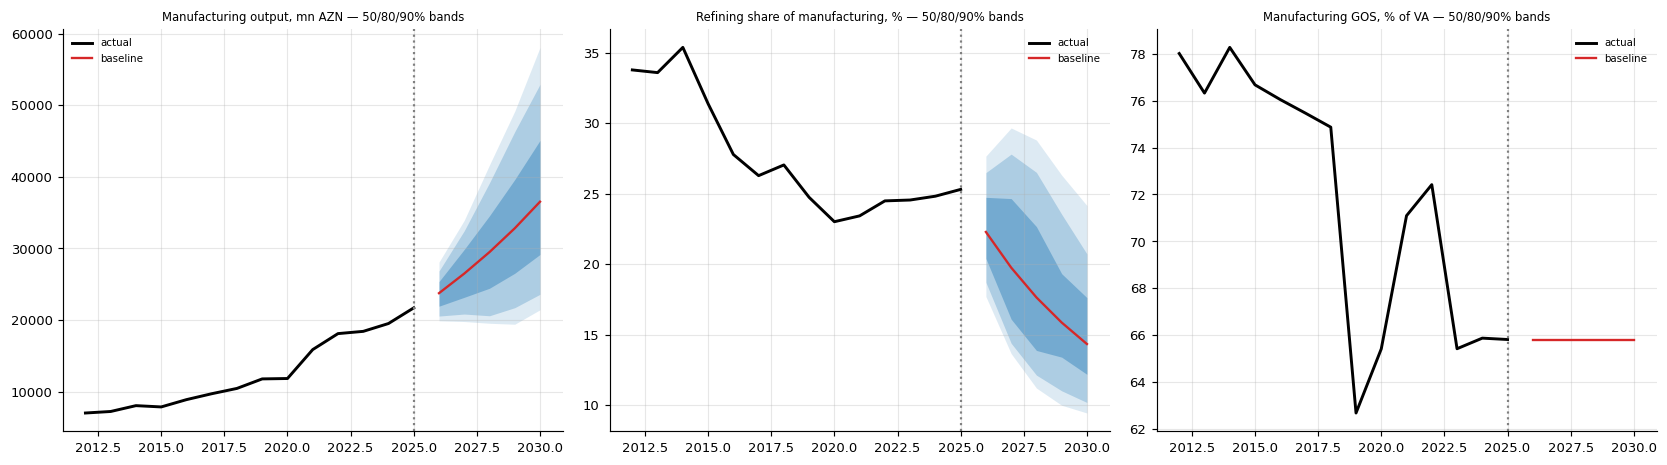

In [36]:
def qtab(M, base_path, last=None):
    '''M: (R, 6) replication paths incl. 2025; returns quantiles by forecast year (+ growth row) and the baseline.'''
    lev = np.quantile(M[:, 1:], QTL, axis=0).T
    df = pd.DataFrame(lev, index=FC_YEARS, columns=[f'p{int(q*100)}' for q in QTL])
    df['baseline'] = np.asarray(base_path, float)[1:]
    if last is not None:
        g = ((M[:, -1] / last) ** (1 / H) - 1) * 100
        df.loc[f'{FC_YEARS[0]}-{FC_YEARS[-1]} growth % pa'] = list(np.quantile(g, QTL)) + [float(((base_path[-1] / last) ** (1 / H) - 1) * 100)]
    return df

FANS = {}
for j, b in enumerate(BCODES):
    FANS[('branch nominal output, mn AZN', b)] = qtab(SIM['nom'][..., j], B_['nom'][b].values, B_['nom'].loc[LAST_ACT, b])
    FANS[('branch real output, mn AZN 2015 prices', b)] = qtab(SIM['real'][..., j], B_['real'][b].values, B_['real'].loc[LAST_ACT, b])
    FANS[('branch share of industry, %', b)] = qtab(SIM['sh_ind'][..., j] * 100, B_['sh_ind'][b].values * 100)
    FANS[('labour productivity, thsd AZN 2015 prices per employee', b)] = qtab(SIM['lp'][..., j], B_['lp'][b].values, B_['lp'].loc[LAST_ACT, b])
for j, b in enumerate(MANUF):
    FANS[('branch share of manufacturing, %', b)] = qtab(SIM['sh_man'][..., j] * 100, B_['sh_man'][b].values * 100)
    FANS[('GOS-proxy margin, % of output', b)] = qtab(SIM['gosp'][..., j], B_['gosp'][b].values)
for j, s_ in enumerate(SECV):
    FANS[('section output, mn AZN', SECT[s_])] = qtab(SIM['sec_go'][..., j], B_['sec_go'][s_].values, B_['sec_go'].loc[LAST_ACT, s_])
    FANS[('section GOS, % of value added', SECT[s_])] = qtab(SIM['sec_gos'][..., j], B_['sec_fin'].xs(s_)['GOS_share_VA'].values)
FANS[('industry output, mn AZN', 'Industry')] = qtab(SIM['nom'].sum(-1), B_['nom'].sum(axis=1).values, B_['nom'].sum(axis=1).loc[LAST_ACT])
FANS[('non-state share of industry, %', 'Industry')] = qtab(SIM['ns_share'] * 100, B_['ns_share'].values * 100)
FANS[('HHI across manufacturing branches', 'Manufacturing')] = qtab(SIM['hhi_man'], hhi(B_['sh_man']).values)
for j, rg in enumerate(REG_NAMES):
    FANS[('regional share of industrial output, %', rg)] = qtab(SIM['reg_sh'][..., j] * 100, B_['reg_sh'][rg].values * 100)
FANS[('industry output, mn AZN — FR1 prices held at baseline', 'Industry')] = qtab(SIM_P['nom'].sum(-1), B_['nom'].sum(axis=1).values, B_['nom'].sum(axis=1).loc[LAST_ACT])
for j, s_ in enumerate(SECV):
    FANS[('section output, mn AZN — FR1 prices held at baseline', SECT[s_])] = qtab(SIM_P['sec_go'][..., j], B_['sec_go'][s_].values, B_['sec_go'].loc[LAST_ACT, s_])
FAN = pd.concat(FANS, names=['indicator', 'unit', 'year'])
lv = FAN[[isinstance(i[2], (int, np.integer)) for i in FAN.index]]
inside = (lv.baseline >= lv.p25 - 1e-9) & (lv.baseline <= lv.p75 + 1e-9)
inside90 = (lv.baseline >= lv.p5 - 1e-9) & (lv.baseline <= lv.p95 + 1e-9)
FAN_META = dict(n_reps=R_N, n_paths_C=len(POOLS['C'][1]), n_paths_R=len(POOLS['R'][1]),
                share_inside_iqr=float(inside.mean() * 100), share_inside_90=float(inside90.mean() * 100))
print(f'{len(FANS)} fan series; baseline inside the inter-quartile band in {FAN_META["share_inside_iqr"]:.1f}% of '
      f'series-years and inside the 90% band in {FAN_META["share_inside_90"]:.1f}%')
gk = f'{FC_YEARS[0]}-{FC_YEARS[-1]} growth % pa'
display(FAN.loc[[i for i in FAN.index if i[0].startswith(('industry output', 'section output')) and i[2] == gk]].round(2))
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
for a, (ind, u, hist, ttl) in zip(ax, [('section output, mn AZN', 'Manufacturing', SEC_GO['C'], 'Manufacturing output, mn AZN'),
                                     ('branch share of manufacturing, %', '19', SH_MAN['19'] * 100, 'Refining share of manufacturing, %'),
                                     ('section GOS, % of value added', 'Manufacturing', SEC_FIN['GOS_share_VA'].xs('C'), 'Manufacturing GOS, % of VA')]):
    f = FAN.loc[(ind, u)]; f = f.loc[[y for y in f.index if isinstance(y, (int, np.integer))]].astype(float)
    a.plot(hist.loc[2012:LAST_ACT].index, hist.loc[2012:LAST_ACT], color='k', lw=2, label='actual')
    for lo_, hi_, al in [('p5', 'p95', 0.15), ('p10', 'p90', 0.25), ('p25', 'p75', 0.4)]:
        a.fill_between(FC_YEARS, f[lo_], f[hi_], color=PAL[0], alpha=al, lw=0)
    a.plot(FC_YEARS, f.baseline, color=PAL[1], lw=1.6, label='baseline')
    a.axvline(LAST_ACT, color='grey', ls=':'); a.set_title(ttl + ' — 50/80/90% bands', fontsize=8); a.legend(fontsize=7)
plt.tight_layout(); plt.show()

## Part 16 — Plausibility against history, and early-warning flags

### 16.1 Every forecast growth rate against the unit's own history

For each branch, section and the industry total the baseline average real growth 2026–2030 is compared with the
unit's own 2010–2019 and 2021–2025 averages and with its best and worst five-year averages since 2005. A forecast
above the best (below the worst) five-year average is **flagged**, with its root cause. The first vintage flagged
refining (a constant-share allocation passed FR1's manufacturing rate to a capacity-constrained refinery); the
root cause was fixed by the capacity model of §11.2. The table also states whether each branch's own 2010–2019 rate
lies inside the 90% band of Part 15.

In [37]:
def win5(s):
    s = s.dropna(); v = [((s.loc[y] / s.loc[y - 5]) ** 0.2 - 1) * 100 for y in s.index if y - 5 in s.index and y - 5 >= 2005]
    return (max(v), min(v)) if v else (np.nan, np.nan)
def avg_g(s, a, b): return ((s.loc[b] / s.loc[a]) ** (1 / (b - a)) - 1) * 100
PL = []
units = [(b, BNAME[b], Q[b], B_['real'][b], ('branch real output, mn AZN 2015 prices', b)) for b in BCODES]
units += [(s_, SECT[s_], F1H[f'rva_{v}'], pd.Series(scen_arrays('Baseline')[f'rva_{v}'][0], index=YRS), None) for s_, v in SECV.items()]
for code, nm, hist, fc, fk in units:
    best, worst = win5(hist.loc[2005:LAST_ACT])
    g = cagr(fc)
    row = dict(code=code, unit=nm, forecast_real_growth=g, hist_2010_2019=avg_g(hist, 2010, 2019),
               hist_2021_2025=avg_g(hist, 2020, LAST_ACT), best_5yr=best, worst_5yr=worst,
               flag=('ABOVE best 5-yr' if g > best else 'BELOW worst 5-yr' if g < worst else ''))
    if fk is not None:
        f = FAN.loc[fk + (gk,)]
        row.update(band_p5=f.p5, band_p95=f.p95, hist_2010_19_inside_90band=bool(f.p5 <= row['hist_2010_2019'] <= f.p95))
    PL.append(row)
PLAUS = pd.DataFrame(PL).set_index('code')
display(PLAUS.round(2))
nflag = int((PLAUS.flag != '').sum())
print(f'{nflag} of {len(PLAUS)} units flagged against their own five-year history: ' +
      ', '.join(f'{r.unit} ({r.forecast_real_growth:+.1f}% vs best {r.best_5yr:+.1f}%)' for _, r in PLAUS[PLAUS.flag != ''].iterrows()))
cov = PLAUS.dropna(subset=['band_p5'])
print(f'own 2010-2019 real growth inside the 90% band for {int(cov.hist_2010_19_inside_90band.sum())} of {len(cov)} branches')
print(f'implied non-oil manufacturing real growth {NONOIL_HIST["forecast_2026_30"]:+.2f}% a year vs best five-year {NONOIL_HIST["best_5yr"]:+.2f}% '
      f'-> {NONOIL_HIST["flag"] or "within history"}. Any remaining branch flag stems from FR1\'s sector path passed through the allocation;')
print('flags are published with the branch\'s own history, not hidden.')

,unit,forecast_real_growth,hist_2010_2019,hist_2021_2025,best_5yr,worst_5yr,flag,band_p5,band_p95,hist_2010_19_inside_90band
code,,,,,,,,,,
06,Crude oil and natural gas,-3.380,-2.570,-0.010,17.500,-3.460,,-4.380,-2.470,True
07,Metal ores,-3.120,10.430,-0.420,137.190,-8.810,,-4.280,-1.970,False
08,Other mining and quarrying,0.000,12.220,15.140,27.980,-8.700,,0.000,0.000,False
09,Mining support services,-3.380,18.790,-18.410,27.500,-20.680,,-4.380,-2.470,False
10,Food products,9.720,3.800,10.220,10.220,2.390,,-6.960,20.260,True
11,Beverages,9.720,8.730,7.560,10.960,0.240,,-10.150,16.770,True
12,Tobacco products,10.000,16.660,13.100,50.730,-14.630,,-20.160,48.560,True
13,Textiles,10.000,18.840,11.630,43.240,-22.650,,-11.920,32.750,True
14,Wearing apparel,10.000,10.320,5.290,21.660,0.710,,-7.840,22.170,True


0 of 34 units flagged against their own five-year history: 
own 2010-2019 real growth inside the 90% band for 24 of 30 branches
implied non-oil manufacturing real growth +9.28% a year vs best five-year +13.82% -> within history. Any remaining branch flag stems from FR1's sector path passed through the allocation;
flags are published with the branch's own history, not hidden.


### 16.2 Early-warning flags, manufacturing branches

Each indicator compares the **2023–2025 average** with the **2020–2022 average** (single base years such as 2020 or
2022 are cycle extremes), and the change is scaled by the branch's **own volatility** (the standard deviation of its
annual changes since 2016): a flag is raised when the change is worse than one own standard deviation.

| Flag | Rule |
|---|---|
| Negative margin | GOS-proxy margin in 2025 or on the 2023–25 average < 0 → **automatic watch** |
| Falling margin | margin change < −1 own s.d. |
| Losing market position | log change of the share of manufacturing < −1 own s.d. |
| Low renewal | investment rate 2023–25 more than 1 s.d. below its own 2010–2022 mean; **insufficient data** if missing (never filled with zero) |
| Rising stocks | stocks/output 2023–25 more than 1 s.d. above its 2010–2022 mean |
| Falling productivity | log change of real output per employee < −1 own s.d. |

Branches below 0.5% of manufacturing output need two flags to be reported only (small-number noise); a negative
margin puts any branch on the watch list. Two or more flags (size permitting), or a negative margin, = watch list. These are transparent dashboard thresholds, not estimated
probabilities; Layer B replaces them with firm-level distress scores.

In [38]:
def a3(df, a, b): return df.loc[a:b].mean()
def z_change(df, log=False):
    x = np.log(df) if log else df
    ch = a3(x, LAST_ACT - 2, LAST_ACT) - a3(x, LAST_ACT - 5, LAST_ACT - 3)
    sd = x.diff().loc[2016:LAST_ACT].std()
    return ch, ch / sd
EW = pd.DataFrame(index=MANUF); EW['branch'] = [BNAME[b] for b in MANUF]
EW['share_2025_pct'] = SH_MAN.loc[LAST_ACT, MANUF] * 100
EW['margin_2023_25'] = a3(GOSP[MANUF], LAST_ACT - 2, LAST_ACT)
EW['margin_change'], EW['margin_z'] = z_change(GOSP[MANUF])
EW['share_logchange'], EW['share_z'] = z_change(SH_MAN[MANUF], log=True)
EW['lp_logchange'], EW['lp_z'] = z_change(LP_GO[MANUF], log=True)
ir = INV_RATE[MANUF]; ir_now = ir.loc[LAST_ACT - 2:LAST_ACT].mean(skipna=False)
EW['inv_rate_2023_25'] = ir_now; EW['inv_rate_z'] = (ir_now - ir.loc[2010:LAST_ACT - 3].mean()) / ir.loc[2010:LAST_ACT - 3].std()
sr = STK_RATIO[MANUF]; EW['stocks_ratio_2023_25'] = sr.loc[LAST_ACT - 2:LAST_ACT].mean(skipna=False)
EW['stocks_z'] = (EW.stocks_ratio_2023_25 - sr.loc[2010:LAST_ACT - 3].mean()) / sr.loc[2010:LAST_ACT - 3].std()
EW['margin_2025'] = GOSP.loc[LAST_ACT, MANUF]
EW['F_negative_margin'] = (EW.margin_2023_25 < 0) | (EW.margin_2025 < 0)
EW['F_margin'] = EW.margin_z < -1; EW['F_share'] = EW.share_z < -1; EW['F_productivity'] = EW.lp_z < -1
EW['F_renewal'] = np.where(EW.inv_rate_z.isna(), 'insufficient data', np.where(EW.inv_rate_z < -1, 'FLAG', ''))
EW['F_stocks'] = np.where(EW.stocks_z.isna(), 'insufficient data', np.where(EW.stocks_z > 1, 'FLAG', ''))
EW['n_flags'] = EW[['F_margin', 'F_share', 'F_productivity']].sum(axis=1) + (EW.F_renewal == 'FLAG') + (EW.F_stocks == 'FLAG')
EW['size_ok'] = EW.share_2025_pct >= 0.5
EW['watch_list'] = (EW.size_ok & (EW.n_flags >= 2)) | EW.F_negative_margin
display(EW.sort_values('n_flags', ascending=False).round(2))
print(f'watch list ({int(EW.watch_list.sum())} branches): ' + (', '.join(f'{r.branch} ({int(r.n_flags)} flags' + (', negative margin' if r.F_negative_margin else '') + ')'
      for _, r in EW[EW.watch_list].sort_values('n_flags', ascending=False).iterrows()) or 'none')
      + f'; below the size threshold: {int((~EW.size_ok).sum())} branches; insufficient investment data: {int((EW.F_renewal == "insufficient data").sum())}')

,branch,share_2025_pct,margin_2023_25,margin_change,margin_z,share_logchange,share_z,lp_logchange,lp_z,inv_rate_2023_25,inv_rate_z,stocks_ratio_2023_25,stocks_z,margin_2025,F_negative_margin,F_margin,F_share,F_productivity,F_renewal,F_stocks,n_flags,size_ok,watch_list
10,Food products,22.960,20.330,0.500,0.180,-0.200,-2.450,0.160,1.830,2.220,-1.080,2.420,1.540,20.550,False,False,True,False,FLAG,FLAG,3,True,True
16,Wood products,0.170,19.410,-3.870,-1.130,-0.960,-4.070,1.230,3.430,NaN,NaN,1.690,0.370,18.460,False,True,True,False,insufficient data,,2,False,False
31,Furniture,1.810,18.290,12.780,1.840,0.500,2.950,0.450,1.490,1.120,-3.350,5.990,-0.560,19.470,False,False,False,False,FLAG,,1,True,False
29,Motor vehicles,1.560,19.770,-5.500,-0.000,0.730,2.090,0.860,0.340,1.020,-1.780,1.720,-0.600,20.330,False,False,False,False,FLAG,,1,True,False
24,Basic metals,5.190,25.240,-8.980,-2.890,0.000,0.020,-0.020,-0.110,1.680,-0.450,6.270,0.000,22.100,False,True,False,False,,,1,True,False
19,Refined petroleum products,25.310,36.800,-15.940,-1.850,0.050,0.900,0.060,0.410,11.770,0.560,2.520,-0.100,37.660,False,True,False,False,,,1,True,False
33,Repair and installation,5.050,17.450,3.870,0.700,0.210,0.740,-0.390,-1.490,1.760,-0.730,NaN,NaN,21.970,False,False,False,True,,insufficient data,1,True,False
14,Wearing apparel,0.910,7.430,0.370,0.200,-0.110,-0.820,-0.070,-0.280,1.530,-1.660,0.760,-0.280,7.160,False,False,False,False,FLAG,,1,True,False
17,Paper products,1.250,17.090,6.590,3.430,0.270,1.680,0.080,0.530,4.350,-0.700,0.710,0.020,19.000,False,False,False,False,,,0,True,False
26,Computer and electronics,0.320,22.220,1.870,0.630,-0.080,-0.290,0.720,1.750,NaN,NaN,9.780,-0.480,22.890,False,False,False,False,insufficient data,,0,False,False


watch list (3 branches): Food products (3 flags), Pharmaceuticals (0 flags, negative margin), Other transport equipment (0 flags, negative margin); below the size threshold: 5 branches; insufficient investment data: 2


## Part 17 — Layer B: the firm-level engine (SYNTHETIC pipeline test only)

> **SYNTHETIC — pipeline test, not results.** The Tax Service / DSMF enterprise panel requested on 24 August 2026 has
> not been received. Everything in Part 17 runs on a seeded synthetic panel built to be consistent with the Layer-A
> aggregates (branch output, enterprise counts, headcount, regional distribution). Its only purpose is to prove that
> the input schema, the validator and every calculation run end to end and reproduce their identities. No number in
> this Part is a finding about Azerbaijani enterprises; all outputs are `output/FR10_SYNTHETIC_*.csv` and carry the
> watermark in their first column.

### 17.1 Input schema

One row per enterprise and year. Money in thousand AZN, headcount in persons. The schema is the contract for the
data-sharing agreement with the Tax Service (DVX) and the State Social Protection Fund (DSMF).

In [39]:
SCHEMA = pd.DataFrame([
 ('firm_id', 'str', '', True, 'unique per enterprise (VÖEN, pseudonymised)', 'DVX'),
 ('year', 'int', '', True, '2019 <= year <= reporting year', 'DVX'),
 ('nace2', 'str', '', True, 'a valid NACE Rev.2 division (01-99); FR10 Layer A covers 05-39', 'DVX / DSK register'),
 ('region', 'str', '', True, 'one of the 14 economic regions', 'DSK register'),
 ('ownership', 'str', '', True, 'state | private | foreign | joint', 'DSK register'),
 ('size_class', 'str', '', False, 'micro | small | medium | large (derived if absent)', 'derived'),
 ('total_assets', 'float', 'thsd AZN', True, '>= 0', 'DVX balance sheet'),
 ('current_assets', 'float', 'thsd AZN', True, '>= 0; <= total assets', 'DVX balance sheet'),
 ('cash', 'float', 'thsd AZN', True, '>= 0', 'DVX balance sheet'),
 ('receivables', 'float', 'thsd AZN', True, '>= 0', 'DVX balance sheet'),
 ('inventories', 'float', 'thsd AZN', True, '>= 0; cash + receivables + inventories <= current assets', 'DVX balance sheet'),
 ('fixed_assets', 'float', 'thsd AZN', True, '>= 0; current + fixed <= total assets', 'DVX balance sheet'),
 ('equity', 'float', 'thsd AZN', True, 'may be negative', 'DVX balance sheet'),
 ('retained_earnings', 'float', 'thsd AZN', False, 'needed for the distress score; if absent the score is not computed and the firm is flagged', 'DVX balance sheet'),
 ('interest_bearing_debt', 'float', 'thsd AZN', False, '>= 0; <= total liabilities (separates debt from trade payables)', 'DVX balance sheet'),
 ('trade_payables', 'float', 'thsd AZN', False, '>= 0', 'DVX balance sheet'),
 ('st_liabilities', 'float', 'thsd AZN', True, '>= 0', 'DVX balance sheet'),
 ('lt_liabilities', 'float', 'thsd AZN', True, '>= 0; equity + liabilities = total assets', 'DVX balance sheet'),
 ('revenue', 'float', 'thsd AZN', True, '>= 0', 'DVX P&L / profit-tax declaration'),
 ('cost_of_sales', 'float', 'thsd AZN', True, '>= 0', 'DVX P&L'),
 ('operating_expenses', 'float', 'thsd AZN', True, '>= 0', 'DVX P&L'),
 ('ebit', 'float', 'thsd AZN', True, '= revenue - cost of sales - operating expenses (within 5%)', 'DVX P&L'),
 ('interest', 'float', 'thsd AZN', True, '>= 0', 'DVX P&L'),
 ('net_profit', 'float', 'thsd AZN', True, 'may be negative', 'DVX P&L'),
 ('depreciation', 'float', 'thsd AZN', False, '>= 0', 'DVX P&L / fixed-asset register'),
 ('operating_cash_flow', 'float', 'thsd AZN', False, 'may be negative', 'DVX cash-flow statement'),
 ('capex', 'float', 'thsd AZN', False, '>= 0', 'DVX cash-flow statement'),
 ('employees', 'float', 'persons', True, '>= 0 (annual average)', 'DSMF'),
 ('wage_bill', 'float', 'thsd AZN', True, '>= 0', 'DSMF'),
 ('exports', 'float', 'thsd AZN', False, '>= 0; <= revenue', 'State Customs Committee (DGK)'),
 ('product_codes', 'str', '', False, 'HS / PRODCOM codes, ";"-separated', 'DGK / DSK'),
 ('registration_date', 'date', '', False, 'state registration date (entry)', 'DVX / Ministry of Justice register'),
 ('liquidation_date', 'date', '', False, 'liquidation date (exit), empty if active', 'DVX / Ministry of Justice register'),
], columns=['field', 'type', 'unit', 'required', 'constraint', 'source'])
display(SCHEMA)

NACE_DIV = {f'{d:02d}' for d in list(range(1, 4)) + list(range(5, 34)) + [35] + list(range(36, 40)) + list(range(41, 44))
            + list(range(45, 48)) + list(range(49, 54)) + [55, 56] + list(range(58, 64)) + [64, 65, 66, 68] + list(range(69, 76))
            + list(range(77, 83)) + [84, 85, 86, 87, 88] + list(range(90, 94)) + [94, 95, 96, 97, 98, 99]}
AZ = {'firm_id': 'Müəssisənin identifikatoru (psevdonim VÖEN)', 'year': 'İl', 'nace2': 'İqtisadi fəaliyyət növü (NACE Rev.2, 2 rəqəm)',
      'region': 'İqtisadi rayon', 'ownership': 'Mülkiyyət növü', 'size_class': 'Ölçü qrupu', 'total_assets': 'Aktivlərin cəmi',
      'current_assets': 'Dövriyyə aktivləri', 'cash': 'Pul vəsaitləri', 'receivables': 'Debitor borcları', 'inventories': 'Ehtiyatlar',
      'fixed_assets': 'Uzunmüddətli aktivlər', 'equity': 'Kapital', 'retained_earnings': 'Bölüşdürülməmiş mənfəət',
      'interest_bearing_debt': 'Faizli borclar', 'trade_payables': 'Kreditor borcları', 'st_liabilities': 'Qısamüddətli öhdəliklər',
      'lt_liabilities': 'Uzunmüddətli öhdəliklər', 'revenue': 'Satışdan gəlir', 'cost_of_sales': 'Satışın maya dəyəri',
      'operating_expenses': 'Əməliyyat xərcləri', 'ebit': 'Faiz və vergidən əvvəl mənfəət', 'interest': 'Faiz xərcləri',
      'net_profit': 'Xalis mənfəət', 'depreciation': 'Amortizasiya', 'operating_cash_flow': 'Əməliyyat fəaliyyətindən pul axını',
      'capex': 'Əsas kapitala qoyuluş', 'employees': 'İşçilərin orta sayı', 'wage_bill': 'Əmək haqqı fondu', 'exports': 'İxrac',
      'product_codes': 'Məhsul kodları (HS / PRODCOM)', 'registration_date': 'Qeydiyyat tarixi', 'liquidation_date': 'Ləğvetmə tarixi'}
SCHEMA['field_az'] = SCHEMA.field.map(AZ)
assert SCHEMA.field_az.notna().all()
SYN_STATUS = 'SYNTHETIC — not real enterprise data'
TOL = 0.01
def normalise_headers(df):
    """Accept English or Azerbaijani headers (column map); returns (renamed frame, list of unrecognised columns)."""
    m = {**{az_lower(v).strip(): k for k, v in AZ.items()}, **{k: k for k in AZ}, 'data_status': 'data_status',
         az_lower('Məlumatın statusu'): 'data_status'}
    ren = {c: m.get(az_lower(str(c)).strip(), c) for c in df.columns}
    return df.rename(columns=ren), [c for c, v in ren.items() if v not in AZ and v != 'data_status']

def validate(df):
    """Per-row, per-field issues: (row, firm_id, year, field, rule, severity). severity: fatal / error / warning.
    fatal and error are HARD (the run stops); warnings are reported and the run continues."""
    iss = []
    def add(mask, field, rule, sev='error'):
        m = mask.fillna(True) if sev != 'warning' else mask.fillna(False)
        for i in df.index[m]:
            iss.append(dict(row=int(i) + 2, firm_id=df.at[i, 'firm_id'] if 'firm_id' in df else '', year=df.at[i, 'year'] if 'year' in df else '',
                            field=field, rule=rule, severity=sev))
    miss = [f for f in SCHEMA[SCHEMA.required].field if f not in df.columns]
    if miss:
        return pd.DataFrame([dict(row=1, firm_id='', year='', field=f, rule='required column missing (EN or AZ header)', severity='fatal') for f in miss])
    num = {f: pd.to_numeric(df[f], errors='coerce') for f in SCHEMA[SCHEMA.type == 'float'].field if f in df}
    for f in SCHEMA[SCHEMA.required & (SCHEMA.type == 'float')].field:
        add(~np.isfinite(num[f]), f, 'not numeric or missing')
    for f in ['total_assets', 'current_assets', 'cash', 'receivables', 'inventories', 'fixed_assets', 'st_liabilities', 'lt_liabilities',
              'revenue', 'cost_of_sales', 'operating_expenses', 'interest', 'employees', 'wage_bill', 'interest_bearing_debt',
              'trade_payables', 'depreciation', 'capex', 'exports']:
        if f in num: add(num[f] < 0, f, 'negative value')
    add(df.duplicated(['firm_id', 'year'], keep=False), 'firm_id', 'duplicate firm-year')
    add(~df.nace2.astype(str).str.zfill(2).isin(NACE_DIV), 'nace2', 'not a NACE Rev.2 division')
    add(~df.region.isin(REG_NAMES), 'region', f'not one of the 14 economic regions')
    add(~df.ownership.isin(['state', 'private', 'foreign', 'joint']), 'ownership', 'not state / private / foreign / joint')
    n = num
    add(n['current_assets'] + n['fixed_assets'] > n['total_assets'] * (1 + TOL), 'total_assets', 'total assets < current + fixed assets')
    add(n['current_assets'] > n['total_assets'] * (1 + TOL), 'current_assets', 'current assets > total assets')
    add((n['equity'] + n['st_liabilities'] + n['lt_liabilities'] - n['total_assets']).abs() > TOL * n['total_assets'].abs().clip(lower=1),
        'equity', 'balance sheet does not balance (equity + liabilities != total assets)')
    add(n['cash'] + n['receivables'] + n['inventories'] > n['current_assets'] * (1 + TOL), 'current_assets', 'cash + receivables + inventories > current assets')
    add((n['revenue'] - n['cost_of_sales'] - n['operating_expenses'] - n['ebit']).abs() > 0.05 * n['revenue'].clip(lower=1),
        'ebit', 'EBIT inconsistent with revenue - costs (5%)', 'warning')
    if 'exports' in n: add(n['exports'] > n['revenue'] * (1 + TOL), 'exports', 'exports > revenue')
    if 'interest_bearing_debt' in n:
        add(n['interest_bearing_debt'] > (n['st_liabilities'] + n['lt_liabilities']) * (1 + TOL), 'interest_bearing_debt', 'interest-bearing debt > liabilities')
    if 'retained_earnings' not in df: add(pd.Series(True, index=df.index), 'retained_earnings', 'absent: distress score not computed', 'warning')
    else: add(n['retained_earnings'].isna(), 'retained_earnings', 'missing: distress score not computed', 'warning')
    return pd.DataFrame(iss, columns=['row', 'firm_id', 'year', 'field', 'rule', 'severity'])
print(f'schema: {len(SCHEMA)} fields ({int(SCHEMA.required.sum())} required), English and Azerbaijani headers accepted; validator: 16 rule families, per row and per field')

,field,type,unit,required,constraint,source
0,firm_id,str,,True,"unique per enterprise (VÖEN, pseudonymised)",DVX
1,year,int,,True,2019 <= year <= reporting year,DVX
2,nace2,str,,True,a valid NACE Rev.2 division (01-99); FR10 Laye...,DVX / DSK register
3,region,str,,True,one of the 14 economic regions,DSK register
4,ownership,str,,True,state | private | foreign | joint,DSK register
5,size_class,str,,False,micro | small | medium | large (derived if abs...,derived
6,total_assets,float,thsd AZN,True,>= 0,DVX balance sheet
7,current_assets,float,thsd AZN,True,>= 0; <= total assets,DVX balance sheet
8,cash,float,thsd AZN,True,>= 0,DVX balance sheet
9,receivables,float,thsd AZN,True,>= 0,DVX balance sheet


schema: 33 fields (22 required), English and Azerbaijani headers accepted; validator: 16 rule families, per row and per field


### 17.2 The calculation engine

| Block | Indicators |
|---|---|
| Liquidity | current ratio CA/STL; quick ratio (CA − inventories)/STL; cash ratio |
| Solvency / leverage | debt-to-equity (STL+LTL)/E; equity ratio E/TA; interest cover EBIT/interest |
| Profitability, DuPont | ROE = (NP/Revenue) × (Revenue/TA) × (TA/E) — the identity is checked; ROA, EBIT margin |
| Turnover | asset turnover; inventory turnover (cost of sales/inventories); receivable days |
| Distress | **Altman Z''-score, emerging-market variant**: 3.25 + 6.56·(CA−CL)/TA + 3.26·RE/TA + 6.72·EBIT/TA + 1.05·E/TL; zones safe > 5.85, grey 4.35–5.85, distress < 4.35. Coefficients and cut-offs are taken from Altman (2005) as published — **not estimated** on any Azerbaijani data |
| Efficiency | labour productivity (revenue per employee); multilateral Törnqvist TFP index against the branch-year mean, with observed cost shares (labour = wage bill/revenue, materials = cost of sales net of wages/revenue, capital = residual) — no productivity law of motion is estimated |
| Market position | shares within NACE × region and NACE; HHI and CR4 per cell; entry, exit, survival by cohort |
| Benchmarking | percentile rank of ROA, labour productivity and Z'' within the NACE × size-class peer group |
| Forecast | firm revenue = Layer-A branch forecast × projected share; share growth from a determinant model with **lagged determinants only** (relative productivity, relative leverage), shares renormalised within the branch so they sum to one |

In [40]:
def ratios(df):
    r = pd.DataFrame(index=df.index)
    tl = df.st_liabilities + df.lt_liabilities
    safe = lambda a, b: a / b.where(b.abs() > 1e-9)
    r['current_ratio'] = safe(df.current_assets, df.st_liabilities)
    r['quick_ratio'] = safe(df.current_assets - df.inventories, df.st_liabilities)
    r['cash_ratio'] = safe(df.cash, df.st_liabilities)
    r['debt_to_equity'] = safe(tl, df.equity); r['equity_ratio'] = safe(df.equity, df.total_assets)
    r['interest_cover'] = safe(df.ebit, df.interest)
    r['net_margin'] = safe(df.net_profit, df.revenue); r['asset_turnover'] = safe(df.revenue, df.total_assets)
    r['equity_multiplier'] = safe(df.total_assets, df.equity); r['roe'] = safe(df.net_profit, df.equity)
    r['roa'] = safe(df.net_profit, df.total_assets); r['ebit_margin'] = safe(df.ebit, df.revenue)
    r['inventory_turnover'] = safe(df.cost_of_sales, df.inventories); r['receivable_days'] = safe(df.receivables, df.revenue) * 365
    re_ = df['retained_earnings'] if 'retained_earnings' in df else pd.Series(np.nan, index=df.index)   # no substitute: flagged by the validator
    r['z_em'] = (3.25 + 6.56 * safe(df.current_assets - df.st_liabilities, df.total_assets) + 3.26 * safe(re_, df.total_assets)
                 + 6.72 * safe(df.ebit, df.total_assets) + 1.05 * safe(df.equity, tl))
    r['z_zone'] = np.select([r.z_em > 5.85, r.z_em >= 4.35], ['safe', 'grey'], 'distress')
    r['lp'] = safe(df.revenue, df.employees)
    return r

def tfp_index(df):
    '''Multilateral Törnqvist TFP (log) against the NACE-year mean, observed cost shares.'''
    d = df.copy()
    sL = (d.wage_bill / d.revenue).clip(0, 1); sM = ((d.cost_of_sales - d.wage_bill).clip(lower=0) / d.revenue).clip(0, 1)
    sK = (1 - sL - sM).clip(lower=0)
    lx = {'q': np.log(d.revenue), 'l': np.log(d.employees.where(d.employees > 0)), 'm': np.log((d.cost_of_sales - d.wage_bill).clip(lower=1)),
          'k': np.log(d.fixed_assets.clip(lower=1))}
    g = d.groupby(['nace2', 'year'])
    out = lx['q'] - g['revenue'].transform(lambda s: np.log(s).mean())
    for x, s in [('l', sL), ('m', sM), ('k', sK)]:
        m_lx = lx[x].groupby([d.nace2, d.year]).transform('mean'); m_s = s.groupby([d.nace2, d.year]).transform('mean')
        out = out - 0.5 * (s + m_s) * (lx[x] - m_lx)
    return out

def concentration(df, keys):
    g = df.groupby(keys + ['year'])
    sh = df.revenue / g.revenue.transform('sum')
    t = pd.DataFrame({'firms': g.size(), 'revenue': g.revenue.sum(),
                      'HHI': (sh ** 2).groupby([df[k] for k in keys] + [df.year]).sum() * 1e4,
                      'CR4_pct': sh.groupby([df[k] for k in keys] + [df.year]).apply(lambda s: s.nlargest(4).sum() * 100)})
    return t

def entry_exit(df):
    first = df.groupby('firm_id').year.transform('min'); last = df.groupby('firm_id').year.transform('max')
    ymin, ymax = df.year.min(), df.year.max()
    d = df.assign(entrant=(df.year == first) & (df.year > ymin), exiter=(df.year == last) & (df.year < ymax))
    t = d.groupby(['nace2', 'year']).agg(firms=('firm_id', 'size'), entrants=('entrant', 'sum'), exits=('exiter', 'sum'))
    t['entry_rate_pct'] = t.entrants / t.firms * 100; t['exit_rate_pct'] = t.exits / t.firms * 100
    lastf = df.groupby('firm_id').year.max()
    coh = d[d.entrant].groupby('year').firm_id.apply(list)
    surv = {y: {f'survive_{k}y_pct': float((lastf.loc[ids] >= y + k).mean() * 100) for k in (1, 3) if y + k <= ymax}
            for y, ids in coh.items()}
    return t, pd.DataFrame(surv).T

def peer_rank(df, rat):
    d = pd.concat([df[['nace2', 'size_class']], rat[['roa', 'lp', 'z_em']]], axis=1)
    return d.groupby(['nace2', 'size_class'])[['roa', 'lp', 'z_em']].rank(pct=True) * 100

def share_model(df):
    '''Delta ln share on LAGGED relative productivity and relative leverage (deviation from the NACE-year mean);
    NACE-year effects removed by demeaning; heteroskedasticity-robust (HC1) SEs. No lagged share on the right-hand side.'''
    d = df.sort_values(['firm_id', 'year']).copy()
    d['sh'] = d.revenue / d.groupby(['nace2', 'year']).revenue.transform('sum')
    d['dlsh'] = np.log(d.sh).groupby(d.firm_id).diff()
    d['rlp'] = np.log(d.revenue / d.employees.where(d.employees > 0)); d['rlp'] -= d.groupby(['nace2', 'year']).rlp.transform('mean')
    d['rlev'] = (d.st_liabilities + d.lt_liabilities) / d.total_assets; d['rlev'] -= d.groupby(['nace2', 'year']).rlev.transform('mean')
    for c in ['rlp', 'rlev']: d[c + '_l1'] = d.groupby('firm_id')[c].shift(1)
    d['cell'] = d.nace2 + '_' + d.year.astype(str)
    e = d.dropna(subset=['dlsh', 'rlp_l1', 'rlev_l1'])
    for c in ['dlsh', 'rlp_l1', 'rlev_l1']: e[c] = e[c] - e.groupby('cell')[c].transform('mean')
    f = ols(e.dlsh, e[['rlp_l1', 'rlev_l1']], cov='hc1', add_const=False)
    return f, d

def firm_forecast(d, beta, branch_fc):
    '''Project shares from the last year with the determinants held at their last values; renormalise within branch.'''
    last = d[d.year == d.year.max()].copy()
    out = []
    for h, y in enumerate(FC_YEARS, start=1):
        z = np.log(last.sh) + h * (beta[0] * last.rlp.fillna(0) + beta[1] * last.rlev.fillna(0))
        w = np.exp(z) / np.exp(z).groupby(last.nace2).transform('sum')
        out.append(pd.DataFrame({'firm_id': last.firm_id, 'nace2': last.nace2, 'year': y, 'share': w.values,
                                 'revenue_fc': w.values * last.nace2.map(lambda b: branch_fc.loc[y, b] * 1000).values}))
    return pd.concat(out, ignore_index=True)
print('engine defined: ratios (incl. DuPont, Altman Z\'\'-EM), tfp_index, concentration, entry_exit, peer_rank, share_model, firm_forecast')

engine defined: ratios (incl. DuPont, Altman Z''-EM), tfp_index, concentration, entry_exit, peer_rank, share_model, firm_forecast


### 17.2b The structural layer of the SYNTHETIC generator (v2): known parameters for every firm-level model

> **SYNTHETIC — pipeline test, not results** (*sintetik məlumat — texniki nümayiş*).

The v1 generator gave balance-sheet and P&L items random ratios, so only the market-share model had a known
data-generating process. v2 keeps every v1 draw that the share model, the Layer-A consistency checks and the
concentration / entry-exit tables use (firm ids, years, NACE, region, ownership, revenue, employees, wage bill,
leverage, registration dates) and **overwrites the remaining items through a structural layer with known
parameters**, drawn from a separate seeded stream (`SEED + 1717`). Every accounting identity of the schema still
holds exactly (assets = current + fixed; equity + liabilities = assets; EBIT = revenue − cost of sales − operating
expenses; exports ≤ revenue).

| Block | Data-generating process (true parameters in `DGP_TRUE`) |
|---|---|
| Exports | $P(\text{exporter}_{it}) = \Lambda(\psi_b + \psi'z_{it})$, $z$ = lagged ln employees, ownership, ln(1+age), Baku; export share ~ Beta(2, 5) |
| Value-added share | $v_{it} = VA/R = v_b + \theta'x_{it} + \gamma_i + u_{it}$, $x$ = ln employees, leverage, ln current ratio, ln(1+age), ownership, export share, Baku, branch demand growth; $\gamma_i$ correlated with initial size |
| Operating margin | EBIT/R = $v_{it}e^{\varepsilon_{it}-\sigma^2/2}$ − wage bill/R − other-cost share: the margin's conditional mean is $\theta'x$ − unit labour cost (coefficient −1) |
| Production (value added) | $\ln VA_{it} = a_b + \omega_i + 0.45\ln L_{it} + 0.50\ln K_{it} + \varepsilon_{it}$; capital is the input that delivers the planned value added; $\omega_i$ = ownership effects + firm noise (time-invariant, so the within estimator is consistent and pooled OLS is not) |
| Investment | capex/$K_{t-1}$ = $\iota_b + \iota_i + 0.08\,\Delta\ln R_{it}^{\pm1} - 0.06\,lev_{t-1} + 0.20\,ROA^{w}_{t-1} - 0.004\ln L_{t-1} - 0.02\,state + e_{it}$ (no lagged investment rate) |
| Distress, ROA, index-number TFP | **no closed-form true parameter**: they are non-linear accounting functions of the blocks above (stated in the recovery table) |

No AR or other dynamic process is estimated anywhere; the generator's productivity term is time-invariant by design.

In [41]:
DGP_SEED = SEED + 1717
DGP_TRUE = {
    'export': {'ln_emp_l1': 0.40, 'foreign': 1.00, 'state': -0.60, 'joint': 0.40, 'ln_age': 0.20, 'baku': 0.30},
    'va_share': {'ln_emp': 0.010, 'leverage': -0.060, 'ln_current_ratio': 0.012, 'ln_age': 0.006, 'state': -0.030,
                 'foreign': 0.025, 'joint': 0.010, 'export_share': 0.050, 'baku': 0.010, 'demand_growth': 0.080},
    'pf': {'ln_L': 0.45, 'ln_K': 0.50},
    'tfp_own': {'state': -0.08, 'foreign': 0.10, 'joint': 0.05},
    'invest': {'sales_growth': 0.08, 'leverage_l1': -0.06, 'roa_w_l1': 0.20, 'ln_emp_l1': -0.004, 'state': -0.02},
    'sd': {'eps_va': 0.10, 'u_v': 0.035, 'gamma': 0.025, 'gamma_size': 0.010, 'eta_omega': 0.15, 'e_inv': 0.035,
           'iota_firm': 0.02, 'iota_branch': 0.01}}
# the operating-margin model: VA-share effects carry over one for one; the unit labour cost enters with -1 (accounting)
DGP_TRUE['margin'] = dict(DGP_TRUE['va_share'], ulc=-1.0)

def structural_overlay(S, go, seed=DGP_SEED, T=DGP_TRUE):
    '''Overwrite the free balance-sheet / P&L items of the v1 synthetic panel with the structural layer.
    Keeps revenue, employees, wage bill, leverage, ownership, region, dates. Returns (panel, latent truth frame).'''
    rg = np.random.default_rng(seed)
    S = S.sort_values(['firm_id', 'year']).reset_index(drop=True)
    n = len(S); f = S.groupby('firm_id', sort=False)
    R, L, W = S.revenue.to_numpy(float), S.employees.to_numpy(float), S.wage_bill.to_numpy(float)
    TA0 = S.total_assets.to_numpy(float); TL0 = (S.st_liabilities + S.lt_liabilities).to_numpy(float)
    lev = TL0 / TA0
    c_ca = (S.current_assets / S.total_assets).to_numpy(float)              # v1 draws reused as ratios
    s_st = (S.st_liabilities / TL0).to_numpy(float)
    fr_cash, fr_rec = (S.cash / S.current_assets).to_numpy(float), (S.receivables / S.current_assets).to_numpy(float)
    int_r, re_r = (S.interest / TL0).to_numpy(float), (S.retained_earnings / S.equity).to_numpy(float)
    ibd_r, dep_r = (S.interest_bearing_debt / TL0).to_numpy(float), (S.depreciation / S.fixed_assets).to_numpy(float)
    ocf_n = ((S.operating_cash_flow - S.net_profit - S.depreciation) / S.revenue).to_numpy(float)
    own = S.ownership.to_numpy(); st_, fo_, jo_ = [(own == o).astype(float) for o in ('state', 'foreign', 'joint')]
    baku = (S.region == 'Baku city').to_numpy(float)
    age = (S.year - S.registration_date.astype(str).str[:4].astype(int)).clip(lower=0).to_numpy(float)
    lnage, lnL = np.log1p(age), np.log(L)
    lnL_l1 = f.employees.shift(1).pipe(np.log).to_numpy(float)
    dem = np.array([np.log(go.loc[y, b] / go.loc[y - 1, b]) for y, b in zip(S.year, S.nace2)])
    firms = S.firm_id.unique(); fidx = pd.Index(firms).get_indexer(S.firm_id)
    br = sorted(S.nace2.unique()); bidx = pd.Index(br).get_indexer(S.nace2)
    sd = T['sd']
    # --- firm- and branch-level effects
    z0 = pd.Series(lnL).groupby(fidx).transform('first').to_numpy(); z0 = (z0 - z0.mean()) / z0.std()
    gamma = sd['gamma_size'] * z0 + rg.normal(0, sd['gamma'], len(firms))[fidx]
    omega = (T['tfp_own']['state'] * st_ + T['tfp_own']['foreign'] * fo_ + T['tfp_own']['joint'] * jo_
             + rg.normal(0, sd['eta_omega'], len(firms))[fidx])
    psi_b = (-1.9 + rg.normal(0, 0.3, len(br)))[bidx]
    iota = rg.normal(0, sd['iota_firm'], len(firms))[fidx] + rg.normal(0, sd['iota_branch'], len(br))[bidx]
    # --- exports (lagged size; first firm-year uses current size and is outside every estimation sample)
    te = T['export']
    xb = (psi_b + te['ln_emp_l1'] * (np.where(np.isfinite(lnL_l1), lnL_l1, lnL) - 2.3) + te['foreign'] * fo_ + te['state'] * st_
          + te['joint'] * jo_ + te['ln_age'] * lnage + te['baku'] * baku)
    exporter = (rg.random(n) < 1 / (1 + np.exp(-xb))).astype(float)
    exp_sh = np.where(exporter > 0, rg.beta(2, 5, n), 0.0)
    # --- value-added share and the operating margin
    tv = T['va_share']; ln_cr = np.log(c_ca / (s_st * lev))
    v_x = (tv['ln_emp'] * (lnL - 2.3) + tv['leverage'] * lev + tv['ln_current_ratio'] * ln_cr + tv['ln_age'] * lnage
           + tv['state'] * st_ + tv['foreign'] * fo_ + tv['joint'] * jo_ + tv['export_share'] * exp_sh + tv['baku'] * baku
           + tv['demand_growth'] * dem + gamma + rg.normal(0, sd['u_v'], n))
    wr = pd.Series(W / R).groupby(bidx).transform('median').to_numpy()
    target = np.clip(wr + 0.15, 0.20, 0.60)
    v_b = target - pd.Series(v_x).groupby(bidx).transform('median').to_numpy()
    v_raw = v_b + v_x; v = np.clip(v_raw, 0.03, 0.80)
    eps = rg.normal(0, sd['eps_va'], n)
    phi = rg.uniform(0.03, 0.12, n)                                           # other operating costs / revenue
    va_true = v * R * np.exp(-sd['eps_va'] ** 2 / 2)
    va_raw = va_true * np.exp(eps); va = np.minimum(va_raw, 0.98 * R)
    ebit = va - W - phi * R; cos = R - va + W
    # --- capital: the input that delivers the planned value added given labour and productivity
    tp = T['pf']; lnK0 = (np.log(va_true) - omega - tp['ln_L'] * lnL) / tp['ln_K']
    a_b = tp['ln_K'] * (pd.Series(lnK0 - np.log(R)).groupby(bidx).transform('median').to_numpy() - np.log(0.5))
    K = np.exp(lnK0 - a_b / tp['ln_K'])
    TA = K / (1 - c_ca); TL = lev * TA; CA = c_ca * TA
    out = S.copy()
    out['total_assets'], out['fixed_assets'], out['current_assets'] = TA, K, CA
    out['cash'], out['receivables'] = CA * fr_cash, CA * fr_rec
    out['inventories'] = CA - out.cash - out.receivables
    out['equity'] = TA - TL; out['st_liabilities'] = TL * s_st; out['lt_liabilities'] = TL - out.st_liabilities
    out['interest'] = TL * int_r; out['retained_earnings'] = out.equity * re_r
    out['interest_bearing_debt'] = TL * ibd_r
    out['trade_payables'] = (out.st_liabilities - 0.5 * out.interest_bearing_debt).clip(lower=0)
    out['cost_of_sales'], out['operating_expenses'], out['ebit'] = cos, phi * R, ebit
    pbt = ebit - out.interest.to_numpy(); out['net_profit'] = np.where(pbt > 0, 0.8 * pbt, pbt)
    out['depreciation'] = K * dep_r
    out['operating_cash_flow'] = out.net_profit + out.depreciation + R * ocf_n
    out['exports'] = exp_sh * R
    # --- investment rate on lagged capital (no lagged investment rate anywhere)
    ti = T['invest']; g = out.groupby('firm_id', sort=False)
    roa_w = (out.net_profit / out.total_assets).clip(-0.3, 0.3)
    K_l1, lev_l1, roa_l1 = g.fixed_assets.shift(1).to_numpy(), pd.Series(lev).groupby(fidx).shift(1).to_numpy(), roa_w.groupby(fidx).shift(1).to_numpy()
    sg = np.clip(np.log(R) - pd.Series(np.log(R)).groupby(fidx).shift(1).to_numpy(), -1, 1)
    ir_raw = (0.25 + iota + ti['sales_growth'] * sg + ti['leverage_l1'] * lev_l1 + ti['roa_w_l1'] * roa_l1
              + ti['ln_emp_l1'] * lnL_l1 + ti['state'] * st_ + rg.normal(0, sd['e_inv'], n))
    first = ~np.isfinite(K_l1)
    ir0 = np.clip(0.15 + rg.normal(0, sd['e_inv'], n), 0.01, None)
    ir = np.where(first, ir0, np.maximum(ir_raw, 0.002))
    out['capex'] = np.where(first, ir0 * K, ir * K_l1)
    truth = pd.DataFrame({'firm_id': out.firm_id, 'year': out.year, 'omega': omega, 'gamma': gamma, 'v': v, 'eps': eps,
                          'exporter_latent': xb, 'ir_raw': ir_raw})
    clip = dict(v_clipped=int((v != v_raw).sum()), va_capped=int((va != va_raw).sum()),
                ir_truncated=int(((~first) & (ir_raw < 0.002)).sum()), n=int(n), n_inv=int((~first).sum()))
    return out, truth, clip
print('[SYNTHETIC] structural layer defined: exports (logit), value-added share and margin, value-added production '
      'function, investment rate - true parameters in DGP_TRUE')

[SYNTHETIC] structural layer defined: exports (logit), value-added share and margin, value-added production function, investment rate - true parameters in DGP_TRUE


### 17.3 The SYNTHETIC panel

Seeded (`SEED + 17`), 24 manufacturing branches, 2019–2025. Built to be **consistent with Layer A**: the number of
firms per branch-year equals DSK's active-enterprise count (`004`); firm revenues sum exactly to DSK branch output
(`010`); headcount sums to DSK branch employees (`006`); wage bills use DSK branch wages (`006_2`); regions and
ownership are drawn from DSK's enterprise distributions (`021`, `004`). Market shares evolve by a **known**
data-generating process — $\Delta\ln w_{i,t} = 0.15\,\widetilde{\ln LP}_{i,t-1} - 0.30\,\widetilde{lev}_{i,t-1} + \varepsilon$ —
so that the pipeline test can check whether the engine recovers the parameters it was given. Balance-sheet items are
drawn from simple ratio distributions that satisfy the accounting identities. None of this describes real firms.

The panel is written, with every schema field, to **`data/firm_panel/FR10_firm_panel_SYNTHETIC.csv`** (and `.xlsx`
with a README and schema sheet), each row carrying `data_status = "SYNTHETIC — not real enterprise data"`. The
generator writes **only** SYNTHETIC-named files (and the template and column map); it never creates or overwrites
`FR10_firm_panel.csv/.xlsx`, the name the Ministry uses for its own data. The file is rewritten only when its
content changes, so re-runs are fast.

In [42]:
rng_s = np.random.default_rng(SEED + 17)
SYN_YEARS = list(range(2019, LAST_ACT + 1))
BETA_TRUE = np.array([0.15, -0.30])
reg_p = (REG_NENT.loc[LAST_ACT] / REG_NENT.loc[LAST_ACT].sum()).to_numpy(float)
_own = d047.set_index('label')[LAST_ACT]
p_state = float(_own['State property'] / _own['by all types of economic ownership'])
_ns = _own[['private property', 'foreign property', 'joint (mixed) property']].astype(float); _ns = _ns / _ns.sum()
def size_class(emp, rev):
    e = np.select([emp <= 10, emp <= 50, emp <= 250], [0, 1, 2], 3); r = np.select([rev <= 200, rev <= 3000, rev <= 30000], [0, 1, 2], 3)
    return np.array(['micro', 'small', 'medium', 'large'])[np.maximum(e, r)]
rows = []; fid = 0
for b in MANUF:
    st = None
    for y in SYN_YEARS:
        N = int(NENT.loc[y, b])
        if st is None:
            n_new = N; st = pd.DataFrame(columns=['firm_id', 'lw', 'lp', 'lev', 'region', 'ownership'])
        else:
            rlp = st.lp - st.lp.mean(); rlev = st.lev - st.lev.mean()
            # exit is decided on LAST year's size (never on this year's shock, which would bias the test)
            keep = ~(rng_s.random(len(st)) < np.where(st.lw < st.lw.quantile(0.3), 0.12, 0.03))
            if keep.sum() > N: keep &= (st.lw.rank(ascending=False, method='first') <= N).values
            st = st.assign(lw=st.lw + BETA_TRUE[0] * rlp + BETA_TRUE[1] * rlev + rng_s.normal(0, 0.25, len(st)),
                           lp=st.lp + rng_s.normal(0, 0.10, len(st)), lev=(st.lev + rng_s.normal(0, 0.03, len(st))).clip(0.05, 0.95))[keep]
            n_new = N - len(st)
        if n_new > 0:
            new = pd.DataFrame({'firm_id': [f'SYN-{b}-{fid + i:05d}' for i in range(n_new)],
                                'lw': rng_s.normal(-1.0 if y > SYN_YEARS[0] else 0.0, 1.5, n_new),
                                'lp': rng_s.normal(0, 0.4, n_new), 'lev': rng_s.beta(3, 4, n_new),
                                'region': rng_s.choice(REG_NAMES, n_new, p=reg_p),
                                'ownership': np.where(rng_s.random(n_new) < p_state, 'state',
                                                      rng_s.choice(['private', 'foreign', 'joint'], n_new, p=_ns.values))})
            fid += n_new; st = pd.concat([st, new], ignore_index=True)
        w = np.exp(st.lw - st.lw.max()); w = w / w.sum()
        rev = w.values * GO.loc[y, b] * 1000
        lab = rev / np.exp(st.lp.values); lab = lab / lab.sum() * EMP_DSK.loc[y, b]
        rows.append(pd.DataFrame({'firm_id': st.firm_id.values, 'year': y, 'nace2': b, 'region': st.region.values,
                                  'ownership': st.ownership.values, 'revenue': rev, 'employees': lab,
                                  'wage_bill': lab * WAGE_DSK.loc[y, b] * 12 / 1000, 'lev': st.lev.values}))
SYN = pd.concat(rows, ignore_index=True)
n = len(SYN); u = lambda a, b_: rng_s.uniform(a, b_, n)
SYN['total_assets'] = SYN.revenue / np.exp(rng_s.normal(np.log(0.9), 0.4, n))
SYN['equity'] = SYN.total_assets * (1 - SYN.lev)
tl = SYN.total_assets - SYN.equity
SYN['st_liabilities'] = tl * u(0.4, 0.8); SYN['lt_liabilities'] = tl - SYN.st_liabilities
SYN['current_assets'] = SYN.total_assets * u(0.3, 0.7); SYN['fixed_assets'] = SYN.total_assets - SYN.current_assets
SYN['cash'] = SYN.current_assets * u(0.05, 0.3); SYN['receivables'] = SYN.current_assets * u(0.2, 0.5)
SYN['inventories'] = SYN.current_assets - SYN.cash - SYN.receivables
SYN['cost_of_sales'] = np.maximum(SYN.revenue * (1 - rng_s.beta(3, 7, n)), SYN.wage_bill)
SYN['operating_expenses'] = SYN.revenue * u(0.03, 0.12)
SYN['ebit'] = SYN.revenue - SYN.cost_of_sales - SYN.operating_expenses
SYN['interest'] = tl * 0.12 * u(0.3, 1.0)
pbt = SYN.ebit - SYN.interest
SYN['net_profit'] = np.where(pbt > 0, pbt * 0.8, pbt)
SYN['retained_earnings'] = SYN.equity * u(0.2, 0.8)
SYN['size_class'] = size_class(SYN.employees.values, SYN.revenue.values)
SYN = SYN.drop(columns='lev')
# optional schema fields (synthetic): debt split, depreciation, cash flow, capex, exports, dates
n = len(SYN); u = lambda a, b_: rng_s.uniform(a, b_, n)
tl = SYN.st_liabilities + SYN.lt_liabilities
SYN['interest_bearing_debt'] = tl * u(0.4, 0.9); SYN['trade_payables'] = (SYN.st_liabilities - 0.5 * SYN.interest_bearing_debt).clip(lower=0)
SYN['depreciation'] = SYN.fixed_assets * u(0.04, 0.12); SYN['capex'] = SYN.depreciation * u(0.3, 2.0)
SYN['operating_cash_flow'] = SYN.net_profit + SYN.depreciation + SYN.revenue * rng_s.normal(0, 0.03, n)
SYN['exports'] = np.where(rng_s.random(n) < 0.25, SYN.revenue * rng_s.beta(2, 5, n), 0.0)
SYN['product_codes'] = ''
first = SYN.groupby('firm_id').year.transform('min'); last = SYN.groupby('firm_id').year.transform('max')
SYN['registration_date'] = np.where(first > SYN_YEARS[0], first.astype(str) + '-06-30', (first - rng_s.integers(1, 20, n)).astype(str) + '-01-15')
SYN['liquidation_date'] = np.where(last < SYN_YEARS[-1], (last + 1).astype(str) + '-03-31', '')
_v1_order = SYN[['firm_id', 'year']].copy()
SYN, SYN_TRUTH, SYN_CLIP = structural_overlay(SYN, GO)            # v2 structural layer (Part 17.2b)
SYN = SYN.set_index(['firm_id', 'year']).loc[pd.MultiIndex.from_frame(_v1_order)].reset_index()   # v1 row order kept
print(f'[{SYN_MARK}] structural layer applied: {SYN_CLIP}')
SYN.insert(0, 'data_status', SYN_STATUS)
SYN = SYN[['data_status'] + [f for f in SCHEMA.field if f in SYN.columns]]
assert all(f in SYN.columns for f in SCHEMA.field), 'synthetic panel lacks a schema field'
FPDIR = BASE / 'data' / 'firm_panel'; FPDIR.mkdir(parents=True, exist_ok=True)
SYN_CSV, SYN_XLSX = FPDIR / 'FR10_firm_panel_SYNTHETIC.csv', FPDIR / 'FR10_firm_panel_SYNTHETIC.xlsx'
_txt = SYN.to_csv(index=False, float_format='%.10g')   # v2: relative precision (tiny synthetic firms)
_changed = not SYN_CSV.exists() or SYN_CSV.read_text(encoding='utf-8') != _txt
if _changed: SYN_CSV.write_text(_txt, encoding='utf-8')
COLMAP = SCHEMA[['field', 'field_az', 'unit', 'required', 'source', 'type', 'constraint']].rename(columns={'field': 'field_en'})
COLMAP = pd.concat([pd.DataFrame([dict(field_en='data_status', field_az='Məlumatın statusu', unit='', required=False, source='-', type='str',
                                       constraint='"SYNTHETIC — not real enterprise data" in the synthetic file; anything else (or absent) = real data')]), COLMAP], ignore_index=True)
COLMAP.to_csv(FPDIR / 'FR10_firm_panel_column_map.csv', index=False, encoding='utf-8')
ex = {f: '' for f in ['data_status'] + list(SCHEMA.field)}
ex.update(data_status='EXAMPLE ROW — delete before use / NÜMUNƏ SƏTİR — istifadədən əvvəl silin', firm_id='PSEUDO-000001', year=2025, nace2='10',
          region='Baku city', ownership='private', size_class='small', total_assets=1000, current_assets=600, cash=100, receivables=200,
          inventories=150, fixed_assets=400, equity=500, retained_earnings=200, interest_bearing_debt=300, trade_payables=150,
          st_liabilities=350, lt_liabilities=150, revenue=1500, cost_of_sales=1100, operating_expenses=250, ebit=150, interest=30,
          net_profit=96, depreciation=40, operating_cash_flow=140, capex=60, employees=25, wage_bill=210, exports=0,
          registration_date='2015-04-01')
TEMPLATE = pd.DataFrame([ex])
TEMPLATE.to_csv(FPDIR / 'FR10_firm_panel_TEMPLATE.csv', index=False, encoding='utf-8')
print(f'[{SYN_MARK}] synthetic input file {"written" if _changed else "unchanged"}: {SYN_CSV.name} ({len(SYN):,} rows); template and column map written')
print(f'[{SYN_MARK}] {len(SYN):,} firm-years, {SYN.firm_id.nunique():,} firms, {len(MANUF)} branches, {SYN_YEARS[0]}-{SYN_YEARS[-1]}')

[SYNTHETIC — pipeline test, not results] structural layer applied: {'v_clipped': 12, 'va_capped': 0, 'ir_truncated': 10, 'n': 22495, 'n_inv': 17240}


[SYNTHETIC — pipeline test, not results] synthetic input file unchanged: FR10_firm_panel_SYNTHETIC.csv (22,495 rows); template and column map written
[SYNTHETIC — pipeline test, not results] 22,495 firm-years, 5,255 firms, 24 branches, 2019-2025


In [43]:
README_MD = """# FR10 firm panel — input file / Müəssisə paneli — giriş faylı

## AZ

**DİQQƏT: `FR10_firm_panel_SYNTHETIC.*` faylları SİNTETİKDİR. Onlarda heç bir real müəssisə, VÖEN və ya real rəqəm yoxdur.**
Fayl FR10 modulunun B qatını (müəssisə səviyyəsində hesablama mühərriki) yoxlamaq üçün təsadüfi, lakin DSK sahə
göstəriciləri ilə uzlaşdırılmış qaydada yaradılmışdır (müəssisələrin sayı, buraxılış, işçilərin sayı və əmək haqqı).
Nəticələr yalnız texniki nümayişdir, təhlil nəticəsi deyil. v2: balans və mənfəət-zərər maddələri məlum parametrli struktur
qatla yaradılır (ixrac, əlavə dəyər payı və marja, istehsal funksiyası, investisiya), ona görə müəssisə səviyyəsində
ekonometrik modellər (`output/FR10_SYNTHETIC_econ_*.csv`) həqiqi parametrləri bərpa edə bilir — sintetik məlumat — texniki nümayiş.

**Faylı necə əvəz etmək olar.** Nazirliyin öz məlumatlarını eyni sxemdə `data/firm_panel/FR10_firm_panel.csv` (və ya
`.xlsx`, `data` vərəqi) kimi saxlayın və ya `FIRM_PANEL_PATH` mühit dəyişənində faylın yolunu göstərin, sonra
`FR10.ipynb`-ni yenidən icra edin. Sütun adları ingilis və ya Azərbaycan dilində ola bilər
(`FR10_firm_panel_column_map.csv`). `data_status` sütunu olmadıqda və ya onun dəyəri sintetik qeyddən fərqli olduqda
məlumat REAL sayılır. Nümunə sətri olan şablon: `FR10_firm_panel_TEMPLATE.csv/.xlsx`.

**Yoxlama (validator).** Məcburi sütunların olması, rəqəmsal dəyərlər, mənfi dəyərlər, təkrarlanan müəssisə-il, NACE kodu,
region, mülkiyyət növü, balans bərabərliyi (kapital + öhdəliklər = aktivlər), aktivlər ≥ dövriyyə + uzunmüddətli aktivlər,
pul + debitor + ehtiyat ≤ dövriyyə aktivləri, ixrac ≤ gəlir, faizli borc ≤ öhdəliklər; xəbərdarlıq: EBIT uyğunsuzluğu,
bölüşdürülməmiş mənfəətin olmaması. Hər səhv sətir və sahə üzrə `output/FR10_firm_panel_validation_report.csv`-də
yazılır; ciddi səhvlər icranı dayandırır, xəbərdarlıqlar dayandırmır.

**Məxfilik.** Müəssisə identifikatorları psevdonimləşdirilmiş qalmalıdır; real məlumatla nəticələr yalnız Nazirliyin
öz sistemində saxlanılır.

**Real məlumat yükləndikdə dəyişən nəticələr.** `FR10_SYNTHETIC_*.csv` əvəzinə `FR10_FIRM_*.csv` (su nişanı olmadan):
maliyyə əmsalları, Altman Z''-EM, TFP indeksi, NACE × region üzrə HHI/CR4, giriş/çıxış, həmyaşıd müqayisəsi, müəssisə
proqnozları, müəssisə səviyyəsində ekonometrik modellər (`FR10_FIRM_econ_*.csv`); MIIS-də V12 "Müəssisə görünüşü" aktivləşir.
A qatının nəticələri dəyişmir.

## EN

**WARNING: the `FR10_firm_panel_SYNTHETIC.*` files are SYNTHETIC. They contain no real enterprise, no VÖEN and no real
figure.** They were generated at random, but consistent with DSK branch aggregates (enterprise counts, output, headcount
and wages), to test FR10 Layer B (the firm-level engine). Results are a pipeline demonstration, not findings. v2: the
balance-sheet and P&L items come from a structural layer with known parameters (exports, value-added share and margin,
production function, investment), so the firm-level econometric models (`output/FR10_SYNTHETIC_econ_*.csv`) can be checked
against the truth.

**How to replace it.** Save the Ministry's data in the same schema as `data/firm_panel/FR10_firm_panel.csv` (or `.xlsx`,
sheet `data`), or set the environment variable `FIRM_PANEL_PATH` to the file, then re-run `FR10.ipynb`. Headers may be
English or Azerbaijani (`FR10_firm_panel_column_map.csv`). A file without a `data_status` column, or whose value differs
from the synthetic marker, is treated as REAL. Template with one example row: `FR10_firm_panel_TEMPLATE.csv/.xlsx`.

**What the validator checks.** Required columns present, numeric values, no negative values, no duplicate firm-year,
valid NACE division, region and ownership, balance identity (equity + liabilities = assets), assets ≥ current + fixed
assets, cash + receivables + inventories ≤ current assets, exports ≤ revenue, interest-bearing debt ≤ liabilities;
warnings: EBIT inconsistent with revenue − costs, retained earnings missing. Every issue is written per row and field to
`output/FR10_firm_panel_validation_report.csv`; hard errors stop the run with a message, warnings do not.

**Confidentiality.** Keep firm identifiers pseudonymised; with real data the outputs stay inside the Ministry's system.

**What changes once real data are loaded.** `FR10_FIRM_*.csv` replace `FR10_SYNTHETIC_*.csv` (no watermark): financial
ratios, Altman Z''-EM, TFP index, HHI/CR4 by NACE × region, entry/exit/survival, peer benchmarking, firm forecasts and the
firm-level econometric models (`FR10_FIRM_econ_*.csv`); the MIIS
view V12 "Firm view" becomes active. Layer-A results do not change.
"""
(FPDIR / 'README_FR10_firm_panel.md').write_text(README_MD, encoding='utf-8')
README_SHEET = pd.DataFrame({'README': ['SİNTETİK MƏLUMAT — real müəssisə məlumatı deyil / SYNTHETIC DATA — not real enterprise data'] + README_MD.split('\n')})
def write_xlsx(path, data, readme=True):
    with pd.ExcelWriter(path, engine='openpyxl') as xw:
        if readme: README_SHEET.to_excel(xw, sheet_name='README', index=False)
        data.to_excel(xw, sheet_name='data', index=False)
        COLMAP.to_excel(xw, sheet_name='schema', index=False)
        if readme:
            from openpyxl.styles import Font
            ws = xw.sheets['README']; ws['A2'].font = Font(bold=True, size=14, color='C00000'); ws.column_dimensions['A'].width = 120
if _changed or not SYN_XLSX.exists(): write_xlsx(SYN_XLSX, SYN)
write_xlsx(FPDIR / 'FR10_firm_panel_TEMPLATE.xlsx', TEMPLATE)
real_named = [p for p in FPDIR.glob('FR10_firm_panel.*')]
print(f'data/firm_panel: {sorted(p.name for p in FPDIR.iterdir() if not p.name.startswith("."))}; '
      f'real-named file present: {[p.name for p in real_named] or "none"}')

data/firm_panel: ['FR10_firm_panel_SYNTHETIC.csv', 'FR10_firm_panel_SYNTHETIC.xlsx', 'FR10_firm_panel_TEMPLATE.csv', 'FR10_firm_panel_TEMPLATE.xlsx', 'FR10_firm_panel_column_map.csv', 'README_FR10_firm_panel.md']; real-named file present: none


### 17.4 Loading the firm panel: REAL if the Ministry has supplied one, SYNTHETIC otherwise

Priority: (1) `FIRM_PANEL_PATH` — the environment variable, or the configuration variable in the next cell;
(2) `data/firm_panel/FR10_firm_panel.csv` or `.xlsx` — the Ministry's own file; (3) the SYNTHETIC file. A file whose
`data_status` is not the synthetic marker (or that has no such column) is treated as **REAL**. Headers may be English
or Azerbaijani. The validator runs on whatever is loaded and writes `output/FR10_firm_panel_validation_report.csv`
(per row and per field); hard errors stop the run with a message, warnings do not.

In [44]:
FIRM_PANEL_PATH = os.environ.get('FIRM_PANEL_PATH') or None      # configuration: set a path here to override

def read_panel(path):
    path = Path(path)
    df = pd.read_excel(path, sheet_name='data', dtype={'nace2': str}) if path.suffix.lower() in ('.xlsx', '.xls') else \
         pd.read_csv(path, dtype={'nace2': str, 'firm_id': str}, encoding='utf-8-sig', keep_default_na=True)
    return df

def load_firm_panel(base, override=None):
    fp = Path(base) / 'data' / 'firm_panel'
    cands = ([Path(override)] if override else []) + [fp / 'FR10_firm_panel.csv', fp / 'FR10_firm_panel.xlsx']
    src = next((p for p in cands if p.exists()), fp / 'FR10_firm_panel_SYNTHETIC.csv')
    df, unknown = normalise_headers(read_panel(src))
    synthetic = 'data_status' in df and df['data_status'].astype(str).eq(SYN_STATUS).all()
    mode = 'SYNTHETIC' if synthetic else 'REAL'
    if 'nace2' in df: df['nace2'] = df['nace2'].astype(str).str.replace(r'\.0$', '', regex=True).str.zfill(2)
    if 'year' in df: df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df[~df.get('data_status', pd.Series('', index=df.index)).astype(str).str.startswith('EXAMPLE ROW')].reset_index(drop=True)
    return df, mode, src, unknown

def banner(mode, src, df):
    line = '#' * 100
    msg = (f'DATA_MODE = {mode}   |   firm panel: {Path(src).name}   |   {len(df):,} rows, '
           f'{df.firm_id.nunique() if "firm_id" in df else 0:,} firms, years '
           f'{int(df.year.min()) if "year" in df and len(df) else "-"}-{int(df.year.max()) if "year" in df and len(df) else "-"}')
    note = ('SYNTHETIC — pipeline demonstration, NOT findings. The Ministry replaces this file in its own system.'
            if mode == 'SYNTHETIC' else 'REAL enterprise data — outputs FR10_FIRM_*.csv; keep them inside the Ministry system.')
    print(line); print(msg.center(100)); print(note.center(100)); print(line)

def check_panel(df, report_path, stop=True):
    rep = validate(df)
    rep.to_csv(report_path, index=False)
    hard = rep[rep.severity.isin(['fatal', 'error'])]
    if stop and len(hard):
        raise ValueError(f'firm panel rejected: {len(hard)} hard errors (first: row {hard.iloc[0].row}, field {hard.iloc[0].field}: '
                         f'{hard.iloc[0].rule}); see {Path(report_path).name}')
    return rep

PANEL, DATA_MODE, PANEL_SRC, PANEL_UNKNOWN_COLS = load_firm_panel(BASE, FIRM_PANEL_PATH)
banner(DATA_MODE, PANEL_SRC, PANEL)
if PANEL_UNKNOWN_COLS: print(f'columns not in the schema (ignored): {PANEL_UNKNOWN_COLS}')
VREP = check_panel(PANEL, OUT / 'FR10_firm_panel_validation_report.csv')
print(f'validator: {int((VREP.severity == "warning").sum())} warnings, 0 hard errors -> {"FR10_SYNTHETIC_*" if DATA_MODE == "SYNTHETIC" else "FR10_FIRM_*"} outputs')
PANEL_META = dict(mode=DATA_MODE, file=Path(PANEL_SRC).name, rows=len(PANEL), firms=int(PANEL.firm_id.nunique()),
                  year_min=int(PANEL.year.min()), year_max=int(PANEL.year.max()), branches=int(PANEL.nace2.nunique()))

####################################################################################################
DATA_MODE = SYNTHETIC   |   firm panel: FR10_firm_panel_SYNTHETIC.csv   |   22,495 rows, 5,255 firms, years 2019-2025
SYNTHETIC — pipeline demonstration, NOT findings. The Ministry replaces this file in its own system.
####################################################################################################
validator: 0 warnings, 0 hard errors -> FR10_SYNTHETIC_* outputs


### 17.4b Firm-level econometrics (v2): estimators

The same code runs on whatever firm panel is loaded — the SYNTHETIC panel now, the Tax Service / DSMF panel when it
arrives (DATA_MODE = REAL). Every model reports the full regression output (coefficients, standard errors, t, p, 95%
intervals, numbers of firms and observations, fit and diagnostics) and is written to the equation registry.

* **Two-way fixed effects (firm + year)**: exact within transformation by firm on the unbalanced panel, year dummies
  partialled out (Frisch–Waugh), singletons dropped; **cluster-robust standard errors by firm** with the
  $G/(G-1)\cdot(N-1)/(N-K)$ correction and $t(G-1)$ inference.
* **Pooled OLS with NACE × year fixed effects** (cell dummies), same clustering.
* **Logit** (maximum likelihood, cluster-robust by firm) with average marginal effects (AME), ROC/AUC, Brier score
  and a calibration table.

Each fit is computed with statsmodels and cross-checked against an independent numpy computation of the
coefficients and the clustered covariance (asserted to 1e-8). No model contains a lagged dependent variable;
lagged regressors are other variables, predetermined.

In [45]:
import statsmodels.api as sm
class EFit:
    def __init__(self, **kw): self.__dict__.update(kw)

def _cluster_V(X, u, g, XtXi=None):
    '''CR1 cluster covariance, statsmodels convention: G/(G-1) * (N-1)/(N-K).'''
    n, k = X.shape; XtXi = np.linalg.pinv(X.T @ X) if XtXi is None else XtXi
    gu, gi = np.unique(g, return_inverse=True); G = len(gu)
    sc = np.zeros((G, k)); np.add.at(sc, gi, X * u[:, None])
    return XtXi @ (sc.T @ sc) @ XtXi * G / (G - 1) * (n - 1) / (n - k), G

def _demean(df, cols, by):
    return df[cols] - df.groupby(by)[cols].transform('mean')

def econ_ols(d, y, xs, fe='firm+year', cluster='firm_id', check=True, fast=False):
    '''fe: 'firm+year' (within by firm, year dummies partialled out) or 'nace_year' (pooled, NACE x year dummies)
    or 'nace+year' (pooled, NACE and year dummies). Returns EFit with statsmodels results (unless fast).'''
    s = d.dropna(subset=[y] + xs).copy()
    if fe == 'firm+year':
        s = s[s.groupby('firm_id').year.transform('size') > 1]
        yd = pd.get_dummies(s.year.astype(int), prefix='yr', drop_first=True, dtype=float)
        Z = pd.concat([s[xs].astype(float), yd], axis=1); Z['__y'] = s[y].astype(float)
        Zd = _demean(pd.concat([Z, s[['firm_id']]], axis=1), list(Z.columns), 'firm_id')
        X = Zd.drop(columns='__y'); X = X.loc[:, X.abs().sum() > 1e-10]; yv = Zd['__y'].to_numpy(float)
    else:
        key = s.nace2 + '_' + s.year.astype(int).astype(str) if fe == 'nace_year' else None
        dm = (pd.get_dummies(key, prefix='cell', drop_first=True, dtype=float) if fe == 'nace_year' else
              pd.concat([pd.get_dummies(s.nace2, prefix='nace', drop_first=True, dtype=float),
                         pd.get_dummies(s.year.astype(int), prefix='yr', drop_first=True, dtype=float)], axis=1))
        X = pd.concat([pd.Series(1.0, index=s.index, name='const'), s[xs].astype(float), dm], axis=1)
        X = X.loc[:, (X != 0).any()]; yv = s[y].to_numpy(float)
    Xv = X.to_numpy(float); g = s[cluster].to_numpy()
    XtXi = np.linalg.pinv(Xv.T @ Xv); b = XtXi @ Xv.T @ yv; u = yv - Xv @ b
    V, G = _cluster_V(Xv, u, g, XtXi); se = np.sqrt(np.maximum(np.diag(V), 0))
    ix = [list(X.columns).index(c) for c in xs]
    res = None
    if not fast:
        res = sm.OLS(yv, Xv).fit(cov_type='cluster', cov_kwds={'groups': pd.factorize(g)[0]}, use_t=True)
        if check:
            db = float(np.max(np.abs(res.params - b) / np.maximum(np.abs(b), 1.0)))
            dse = float(np.max(np.abs(res.bse[ix] - se[ix]) / np.maximum(se[ix], 1e-12)))
            assert db < 1e-8 and dse < 1e-8, f'{y}: statsmodels vs numpy mismatch (b {db:.1e}, se {dse:.1e})'
    n, k = Xv.shape
    tss = ((yv - yv.mean()) ** 2).sum() if fe != 'firm+year' else (yv ** 2).sum()
    r2 = 1 - (u @ u) / tss
    bb, Vb = b[ix], V[np.ix_(ix, ix)]
    F = float(bb @ np.linalg.pinv(Vb) @ bb) / len(ix)
    return EFit(kind='ols', fe=fe, y=y, xs=list(xs), b=pd.Series(bb, index=xs), se=pd.Series(se[ix], index=xs), V=Vb,
                dof=G - 1, n=n, k=k, G=G, firms=int(s.firm_id.nunique()), years=sorted(s.year.astype(int).unique()),
                r2=float(r2), r2_adj=float(1 - (1 - r2) * (n - 1) / max(n - k - (s.firm_id.nunique() if fe == 'firm+year' else 0), 1)),
                ser=float(np.sqrt((u @ u) / max(n - k, 1))), F=F, F_p=float(1 - stats.f.cdf(F, len(ix), G - 1)),
                res=res, resid=u, fitted=yv - u, yv=yv, X=X[xs] if fe != 'firm+year' else s[xs], sample=s, cluster=cluster,
                y_raw=s[y].to_numpy(float))

def econ_logit(d, y, xs, dummies=('year',), cluster='firm_id', fast=False):
    s = d.dropna(subset=[y] + xs).copy()
    parts = [pd.Series(1.0, index=s.index, name='const'), s[xs].astype(float)]
    for dm in dummies:
        parts.append(pd.get_dummies(s[dm].astype(str), prefix=dm, drop_first=True, dtype=float))
    X = pd.concat(parts, axis=1); X = X.loc[:, (X != 0).any()]
    yv = s[y].astype(float).to_numpy(); g = pd.factorize(s[cluster])[0]
    mod = sm.Logit(yv, X)
    res = mod.fit(disp=0, maxiter=300, method='newton', cov_type='cluster', cov_kwds={'groups': g})
    p = res.predict(X)
    out = EFit(kind='logit', y=y, xs=list(xs), b=res.params[xs], se=res.bse[xs], V=res.cov_params().loc[xs, xs].to_numpy(),
               dof=None, n=len(s), k=X.shape[1], G=int(len(np.unique(g))), firms=int(s.firm_id.nunique()),
               years=sorted(s.year.astype(int).unique()), res=res, prob=np.asarray(p), yv=yv, X=s[xs], sample=s,
               cluster=cluster, dummies=list(dummies), r2=float(res.prsquared), llf=float(res.llf),
               lr=float(res.llr), lr_p=float(res.llr_pvalue), aic=float(res.aic), bic=float(res.bic))
    if not fast:
        me = res.get_margeff(at='overall', method='dydx').summary_frame()
        out.ame = me.loc[[c for c in xs if c in me.index]].rename(columns={'dy/dx': 'ame', 'Std. Err.': 'se', 'Pr(>|z|)': 'p',
                                                                             'Conf. Int. Low': 'ci_low', 'Cont. Int. Hi.': 'ci_high'})
        out.auc = auc(yv, p); out.brier = float(np.mean((p - yv) ** 2)); out.calib = calibration(yv, p)
        out.hl_stat, out.hl_p = hosmer_lemeshow(yv, p)
    return out

def auc(y, p):
    '''Area under the ROC curve = Mann-Whitney probability (ties counted one half).'''
    y = np.asarray(y, float); r = stats.rankdata(p); n1 = y.sum(); n0 = len(y) - n1
    return float((r[y == 1].sum() - n1 * (n1 + 1) / 2) / (n1 * n0)) if n1 and n0 else np.nan

def roc_points(y, p, n=101):
    th = np.quantile(p, np.linspace(0, 1, n))[::-1]
    y = np.asarray(y, bool)
    return pd.DataFrame({'threshold': th, 'tpr': [(p[y] >= t).mean() for t in th], 'fpr': [(p[~y] >= t).mean() for t in th]})

def calibration(y, p, q=10):
    b = pd.qcut(pd.Series(p).rank(method='first'), q, labels=False)
    t = pd.DataFrame({'bin': b, 'p': p, 'y': y}).groupby('bin').agg(n=('y', 'size'), mean_predicted=('p', 'mean'),
                                                                   observed_rate=('y', 'mean'))
    t.index = t.index + 1
    return t.rename_axis('decile')

def hosmer_lemeshow(y, p, q=10):
    c = calibration(y, p, q); e = c.n * c.mean_predicted; o = c.n * c.observed_rate
    hl = float((((o - e) ** 2) / (e * (1 - c.mean_predicted)).clip(lower=1e-12)).sum())
    return hl, float(1 - stats.chi2.cdf(hl, q - 2))

def year_paths(fitfun, years, names, n_min_years=3):
    '''Recursive (expanding window over years) and leave-one-year-out coefficient paths (registry robustness).'''
    rec = dict(years=[], coef={c: [] for c in names}, se={c: [] for c in names}, n_min=n_min_years)
    loo = dict(years=[], coef={c: [] for c in names})
    for i, yr in enumerate(years):
        if i + 1 >= n_min_years:
            try:
                b, s_ = fitfun(lambda d: d[d.year <= yr])
                rec['years'].append(int(yr)); [rec['coef'][c].append(float(b[c])) or rec['se'][c].append(float(s_[c])) for c in names]
            except Exception:
                pass
        try:
            b, _ = fitfun(lambda d: d[d.year != yr])
            loo['years'].append(int(yr)); [loo['coef'][c].append(float(b[c])) for c in names]
        except Exception:
            pass
    loo['range'] = {c: ([min(v), max(v)] if v else None) for c, v in loo['coef'].items()}
    return rec, loo
print('firm-level estimators defined: econ_ols (two-way FE / pooled NACE x year FE, cluster by firm, statsmodels-checked), '
      'econ_logit (cluster by firm, AME, AUC, calibration), year_paths (recursive / leave-one-year-out)')

firm-level estimators defined: econ_ols (two-way FE / pooled NACE x year FE, cluster by firm, statsmodels-checked), econ_logit (cluster by firm, AME, AUC, calibration), year_paths (recursive / leave-one-year-out)


### 17.4c Firm-level econometrics: variables, sample rules and the model list

| Model | Dependent | Regressors | Estimator(s) |
|---|---|---|---|
| (a) profitability | ROA (winsorised 1/99%), operating margin EBIT/revenue | size (ln employees), leverage, liquidity (ln current ratio), ln(1+age), ownership, export share, Baku, branch demand growth (Δln DSK branch output), unit labour cost | two-way FE (firm + year); pooled with NACE × year FE |
| (b) production function | ln value added (revenue − materials) | ln employees, ln fixed assets | two-way FE (within); pooled OLS with NACE and year dummies; returns to scale and the CRS test |
| (c) TFP determinants | index-number TFP (Törnqvist, observed cost shares); production-function TFP | size, age, ownership, exporter, leverage, Baku | pooled NACE × year FE; two-way FE |
| (d) financial distress | Z''-EM distress zone or negative equity, year t | predictors at t−1: leverage, liquidity, ROA, size, export share; age, ownership; demand growth | logit, AME, ROC/AUC (in sample and on the last two years out of sample), calibration |
| (e) investment rate | capex / fixed assets t−1 | sales growth, leverage t−1, ROA t−1, size t−1, ownership | two-way FE; pooled NACE × year FE |
| (f) market share | Δ ln share | relative productivity t−1, relative leverage t−1 | within NACE × year (Part 17.2), HC1 |
| (g) export participation | exporter (exports > 0) | ln employees t−1, ownership, ln(1+age), Baku | logit with NACE and year dummies, AME |

**Why not Olley–Pakes, Levinsohn–Petrin or Ackerberg–Caves–Frazer.** These control-function estimators identify the
production function by assuming that productivity follows a first-order Markov (in practice autoregressive) law of
motion, $\omega_{it} = g(\omega_{i,t-1}) + \xi_{it}$, and estimating it. That is an estimated autoregressive process for
an unobserved state variable, which the requester's constraints exclude. FR10 uses the within estimator (productivity
as a firm fixed effect plus year effects) and pooled OLS, and states the difference between them.

In [46]:
ECON_AZ = {'ln_emp': 'ln işçilərin sayı (ölçü)', 'leverage': 'borc yükü (öhdəliklər / aktivlər)',
           'ln_current_ratio': 'ln cari likvidlik əmsalı', 'ln_age': 'ln(1 + yaş)', 'state': 'dövlət mülkiyyəti',
           'foreign': 'xarici mülkiyyət', 'joint': 'birgə mülkiyyət', 'export_share': 'ixracın gəlirdə payı',
           'baku': 'Bakı şəhəri', 'demand_growth': 'sahə tələbinin artımı (Δln DSK buraxılışı)',
           'ulc': 'vahid əmək xərci (əmək haqqı fondu / gəlir)', 'ln_L': 'ln işçilərin sayı', 'ln_K': 'ln əsas fondlar',
           'exporter': 'ixracatçı (0/1)', 'leverage_l1': 'borc yükü, t−1', 'ln_current_ratio_l1': 'ln cari likvidlik, t−1',
           'roa_w_l1': 'ROA, t−1 (±0,3 hüdudunda)', 'ln_emp_l1': 'ln işçilərin sayı, t−1', 'export_share_l1': 'ixrac payı, t−1',
           'sales_growth': 'satışların artımı (Δln gəlir)', 'rel_lp_l1': 'nisbi əmək məhsuldarlığı, t−1',
           'rel_leverage_l1': 'nisbi borc yükü, t−1', 'RTS': 'miqyasdan gəlir (βL + βK)',
           'roa': 'aktivlərin rentabelliyi (ROA)', 'op_margin': 'əməliyyat marjası (EBIT / gəlir)', 'ln_va': 'ln əlavə dəyər',
           'tfp_idx': 'TFP indeksi (Törnqvist)', 'tfp_pf': 'istehsal funksiyası üzrə TFP', 'distress': 'maliyyə çətinliyi (0/1)',
           'inv_rate': 'investisiya norması (kapital qoyuluşu / əsas fondlar t−1)', 'dlsh': 'Δ ln bazar payı'}
SAMPLE_RULES = pd.DataFrame([
    ('all models', 'revenue > 0, employees > 0, total assets > 0, fixed assets > 0', 'gəlir, işçilər, aktivlər və əsas fondlar müsbətdir'),
    ('operating margin', 'unit labour cost (wage bill / revenue) <= 1 (selection on a regressor); EBIT / revenue within [-2, 1]', 'vahid əmək xərci (əmək haqqı fondu / gəlir) ≤ 1 (izahedici dəyişən üzrə seçim); EBIT / gəlir [-2, 1] aralığında'),
    ('sales growth', 'Δ ln revenue bounded at ±1', 'Δ ln gəlir ±1 hüdudunda'),
    ('ROA', 'net profit / total assets winsorised at the pooled 1st and 99th percentiles', 'xalis mənfəət / aktivlər 1% və 99% persentillərdə vinzorlaşdırılıb'),
    ('investment rate', 'capex / fixed assets t-1 within [0, 2]; consecutive years only', 'kapital qoyuluşu / əsas fondlar t−1 [0, 2] aralığında; yalnız ardıcıl illər'),
    ('lagged regressors', 'value of the same firm in the previous calendar year (no lagged dependent variable)', 'eyni müəssisənin əvvəlki ildəki dəyəri (asılı dəyişənin gecikməsi yoxdur)'),
    ('fixed effects', 'firms observed once (singletons) are dropped from the within estimator', 'yalnız bir il müşahidə olunan müəssisələr daxili qiymətləndiricidən çıxarılır'),
    ('optional fields', 'a regressor with < 80% coverage in the estimation sample is dropped and listed', 'nümunədə 80%-dən az dolu olan izahedici dəyişən çıxarılır və göstərilir')],
    columns=['scope', 'rule', 'rule_az'])
SAMPLE_RULES.insert(1, 'scope_az', ['bütün modellər', 'əməliyyat marjası', 'satışların artımı', 'ROA', 'investisiya norması', 'gecikmiş izahedici dəyişənlər',
                                    'sabit effektlər', 'əlavə (məcburi olmayan) sahələr'])

def econ_vars(P, RAT):
    '''Analysis variables from schema fields only, so SYNTHETIC and REAL panels give the same variables.'''
    s = P.sort_values(['firm_id', 'year']).copy()
    ok = (s.revenue > 0) & (s.employees > 0) & (s.total_assets > 0) & (s.fixed_assets > 0)
    s = s[ok].copy(); r = RAT.loc[s.index]
    d = s[['firm_id', 'year', 'nace2', 'region', 'ownership']].copy(); d['year'] = d.year.astype(int)
    tl = s.st_liabilities + s.lt_liabilities
    d['ln_emp'] = np.log(s.employees); d['ln_L'] = d.ln_emp; d['ln_K'] = np.log(s.fixed_assets)
    d['leverage'] = tl / s.total_assets
    d['ln_current_ratio'] = np.log((s.current_assets / s.st_liabilities.where(s.st_liabilities > 0)).where(lambda x: x > 0))
    reg = pd.to_numeric(s['registration_date'].astype(str).str[:4], errors='coerce') if 'registration_date' in s else np.nan
    d['ln_age'] = np.log1p((d.year - reg).clip(lower=0))
    for o in ['state', 'foreign', 'joint']: d[o] = (s.ownership == o).astype(float)
    d['baku'] = (s.region == 'Baku city').astype(float)
    has_x = 'exports' in s and s.exports.notna().mean() > 0.8
    d['export_share'] = (s.exports / s.revenue).clip(0, 1) if has_x else np.nan
    d['exporter'] = (s.exports > 0).astype(float).where(s.exports.notna()) if has_x else np.nan
    gr = np.log(GO).diff()
    d['demand_growth'] = [gr.at[y, b] if (b in gr.columns and y in gr.index) else np.nan for y, b in zip(d.year, d.nace2)]
    d['ulc'] = s.wage_bill / s.revenue
    d['op_margin'] = (s.ebit / s.revenue).where(lambda x: x.between(-2, 1)).where(d.ulc <= 1)   # selection on the regressor (ulc), not on the margin
    roa = s.net_profit / s.total_assets; lo, hi = roa.quantile([0.01, 0.99])
    d['roa'] = roa.clip(lo, hi); d['roa_w'] = roa.clip(-0.3, 0.3)
    va = s.revenue - (s.cost_of_sales - s.wage_bill).clip(lower=0)
    d['ln_va'] = np.log(va.where(va > 0))
    d['tfp_idx'] = s['tfp'] if 'tfp' in s else np.nan
    d['distress'] = ((r.z_zone == 'distress') | (s.equity < 0)).astype(float)
    g = d.groupby('firm_id'); cons = (d.year - g.year.shift(1)) == 1
    lag = lambda c: g[c].shift(1).where(cons)
    for c in ['leverage', 'ln_current_ratio', 'roa_w', 'ln_emp', 'export_share']:
        d[c + '_l1'] = lag(c)
    fa_l1 = s.groupby('firm_id').fixed_assets.shift(1).where(cons)
    d['inv_rate'] = (s.capex / fa_l1).where(lambda x: x.between(0, 2)) if 'capex' in s else np.nan
    d['sales_growth'] = (np.log(s.revenue) - np.log(s.groupby('firm_id').revenue.shift(1))).where(cons).clip(-1, 1)
    d['first_obs'] = ~cons
    return d.replace([np.inf, -np.inf], np.nan)

X_PROF_FE = ['ln_emp', 'leverage', 'ln_current_ratio', 'ln_age', 'export_share', 'demand_growth', 'ulc']
X_PROF_PO = ['ln_emp', 'leverage', 'ln_current_ratio', 'ln_age', 'state', 'foreign', 'joint', 'export_share', 'baku', 'ulc']
ECON_MODELS = [  # id, title_az, title_en, kind, dependent, regressors, fe / dummies, block
 ('B_roa_fe', 'Rentabellik (ROA): iki yönlü sabit effektlər', 'ROA determinants, two-way FE', 'ols', 'roa', X_PROF_FE, 'firm+year', 'a'),
 ('B_roa_pool', 'Rentabellik (ROA): NACE × il effektləri ilə birləşdirilmiş', 'ROA determinants, pooled NACE x year FE', 'ols', 'roa', X_PROF_PO, 'nace_year', 'a'),
 ('B_margin_fe', 'Əməliyyat marjası: iki yönlü sabit effektlər', 'Operating margin determinants, two-way FE', 'ols', 'op_margin', X_PROF_FE, 'firm+year', 'a'),
 ('B_margin_pool', 'Əməliyyat marjası: NACE × il effektləri ilə birləşdirilmiş', 'Operating margin, pooled NACE x year FE', 'ols', 'op_margin', X_PROF_PO, 'nace_year', 'a'),
 ('B_pf_fe', 'İstehsal funksiyası (Kobb–Duqlas): daxili qiymətləndirici', 'Cobb-Douglas production function, within (FE)', 'ols', 'ln_va', ['ln_L', 'ln_K'], 'firm+year', 'b'),
 ('B_pf_pool', 'İstehsal funksiyası: sahə və il dummy-ləri ilə birləşdirilmiş OLS', 'Cobb-Douglas, pooled OLS with sector and year dummies', 'ols', 'ln_va', ['ln_L', 'ln_K'], 'nace+year', 'b'),
 ('B_tfp_idx', 'TFP indeksi (Törnqvist) amilləri: birləşdirilmiş', 'Index-number TFP determinants, pooled NACE x year FE', 'ols', 'tfp_idx',
  ['ln_emp', 'ln_age', 'state', 'foreign', 'joint', 'exporter', 'leverage', 'baku'], 'nace_year', 'c'),
 ('B_tfp_idx_fe', 'TFP indeksi amilləri: iki yönlü sabit effektlər', 'Index-number TFP determinants, two-way FE', 'ols', 'tfp_idx',
  ['ln_emp', 'ln_age', 'exporter', 'leverage'], 'firm+year', 'c'),
 ('B_tfp_pf', 'İstehsal funksiyası üzrə TFP-nin mülkiyyət amilləri', 'Production-function TFP on ownership, pooled NACE x year FE', 'ols', 'tfp_pf',
  ['state', 'foreign', 'joint'], 'nace_year', 'c'),
 ('B_distress', 'Maliyyə çətinliyi (Z\'\'-EM çətinlik zonası və ya mənfi kapital): logit', 'Financial distress logit', 'logit', 'distress',
  ['leverage_l1', 'ln_current_ratio_l1', 'roa_w_l1', 'ln_emp_l1', 'export_share_l1', 'ln_age', 'state', 'foreign', 'demand_growth'], ('year',), 'd'),
 ('B_invest_fe', 'İnvestisiya norması: iki yönlü sabit effektlər', 'Investment rate, two-way FE', 'ols', 'inv_rate',
  ['sales_growth', 'leverage_l1', 'roa_w_l1', 'ln_emp_l1'], 'firm+year', 'e'),
 ('B_invest_pool', 'İnvestisiya norması: NACE × il effektləri ilə birləşdirilmiş', 'Investment rate, pooled NACE x year FE', 'ols', 'inv_rate',
  ['sales_growth', 'leverage_l1', 'roa_w_l1', 'ln_emp_l1', 'state', 'foreign', 'joint'], 'nace_year', 'e'),
 ('B_export', 'İxrac iştirakı: logit', 'Export participation logit', 'logit', 'exporter',
  ['ln_emp_l1', 'foreign', 'state', 'joint', 'ln_age', 'baku'], ('nace2', 'year'), 'g')]
ECON_BLOCK_AZ = {'a': '(a) Rentabellik amilləri', 'b': '(b) İstehsal funksiyası', 'c': '(c) TFP amilləri',
                 'd': '(d) Maliyyə çətinliyi modeli', 'e': '(e) İnvestisiya norması', 'f': '(f) Bazar payının amilləri',
                 'g': '(g) İxrac iştirakı'}
TRUE_MAP = {'B_margin_fe': 'margin', 'B_margin_pool': 'margin', 'B_pf_fe': 'pf', 'B_pf_pool': 'pf', 'B_tfp_pf': 'tfp_own',
            'B_invest_fe': 'invest', 'B_invest_pool': 'invest', 'B_export': 'export'}
NO_TRUTH_AZ = {'B_roa_fe': 'ROA mühasibat zəncirinin qeyri-xətti funksiyasıdır (faiz, vergi, aktivlərin dövriyyəsi): generatorda qapalı həqiqi parametr yoxdur',
               'B_roa_pool': 'ROA üçün generatorda qapalı həqiqi parametr yoxdur',
               'B_tfp_idx': 'indeks TFP müşahidə olunan xərc paylarından hesablanır və generatorun məhsuldarlığından fərqli obyektdir: həqiqi parametr yoxdur',
               'B_tfp_idx_fe': 'indeks TFP üçün həqiqi parametr yoxdur',
               'B_distress': 'çətinlik zonası cari maliyyə əmsallarının deterministik funksiyasıdır: logit üçün həqiqi parametr yoxdur'}
print(f'{len(ECON_MODELS)} firm-level models defined (+ the market-share model of Part 17.2)')

13 firm-level models defined (+ the market-share model of Part 17.2)


In [47]:
SYN_AZ = 'sintetik məlumat — texniki nümayiş'
def _keep(d, xs, y, extra=()):
    '''Drop optional regressors with < 80% coverage among rows where the dependent variable exists.'''
    base = d[d[y].notna()]
    if any(x.endswith('_l1') for x in xs) and 'first_obs' in d:
        base = base[~base.first_obs.astype(bool)]           # lagged regressors: coverage among firm-years with a previous year
    keep = [x for x in xs if x in d and base[x].notna().mean() >= 0.8 and base[x].nunique() > 1]
    return keep, [x for x in xs if x not in keep]

def coef_rows(mid, f, est_label):
    tq = stats.t.ppf(0.975, f.dof) if f.dof else stats.norm.ppf(0.975)
    t = f.b / f.se
    p = 2 * (stats.t.sf(np.abs(t), f.dof) if f.dof else stats.norm.sf(np.abs(t)))
    return pd.DataFrame({'model_id': mid, 'estimator': est_label, 'dependent': f.y, 'term': f.b.index,
                         'term_az': [ECON_AZ.get(c, c) for c in f.b.index], 'coef': f.b.values, 'se': f.se.values,
                         't': t.values, 'p': p, 'ci_low': (f.b - tq * f.se).values, 'ci_high': (f.b + tq * f.se).values,
                         'n_obs': f.n, 'n_firms': f.firms, 'n_clusters': f.G, 'year_min': min(f.years), 'year_max': max(f.years)})

def rts_test(f):
    a = np.array([1.0, 1.0]); r = float(f.b['ln_L'] + f.b['ln_K']); se = float(np.sqrt(a @ f.V @ a))
    t = (r - 1) / se; p = float(2 * stats.t.sf(abs(t), f.dof)); tq = stats.t.ppf(0.975, f.dof)
    return dict(RTS=r, se=se, ci_low=r - tq * se, ci_high=r + tq * se, crs_wald_F=t * t, crs_p=p, df=f.dof)

def firm_econometrics(P, RAT, mode, share_fit=None):
    syn = mode == 'SYNTHETIC'
    D = econ_vars(P, RAT); F, ROWS, SUMM, DROPPED = {}, [], [], {}
    est_name = {'firm+year': 'Two-way fixed effects (firm + year), firm-demeaned; cluster(firm)',
                'nace_year': 'Pooled LS + NACE x year fixed effects; cluster(firm)', 'nace+year': 'Pooled LS + NACE and year dummies; cluster(firm)'}
    for mid, taz, ten, kind, y, xs, fe, blk in ECON_MODELS:
        if y == 'tfp_pf':
            pf = F.get('B_pf_fe')
            if pf is None: continue
            D['tfp_pf'] = D.ln_va - pf.b['ln_L'] * D.ln_L - pf.b['ln_K'] * D.ln_K
        if y not in D or D[y].notna().sum() < 50 or (kind == 'logit' and D[y].dropna().nunique() < 2):
            DROPPED[mid] = 'dependent variable not available'; continue
        keep, drop = _keep(D, xs, y)
        if drop: DROPPED[mid] = drop
        f = econ_ols(D, y, keep, fe=fe) if kind == 'ols' else econ_logit(D, y, keep, dummies=fe)
        f.mid, f.title_az, f.title_en, f.block, f.est = mid, taz, ten, blk, (est_name.get(fe) if kind == 'ols' else
                                                         'Logit (MLE), dummies ' + ' + '.join(fe) + '; cluster(firm)')
        F[mid] = f; ROWS.append(coef_rows(mid, f, f.est))
        row = dict(model_id=mid, block=ECON_BLOCK_AZ[blk], title_az=taz, title_en=ten, estimator=f.est, dependent=y,
                   regressors=';'.join(keep), dropped_regressors=';'.join(drop), n_obs=f.n, n_firms=f.firms, n_clusters=f.G,
                   year_min=min(f.years), year_max=max(f.years), synthetic=syn)
        if kind == 'ols':
            row.update(r2=f.r2, r2_type='within R²' if fe == 'firm+year' else 'R²', r2_adj=f.r2_adj, ser=f.ser,
                       wald_F=f.F, wald_F_p=f.F_p)
            if blk == 'b': row.update({k: v for k, v in rts_test(f).items()})
        else:
            row.update(r2=f.r2, r2_type='McFadden pseudo-R²', loglik=f.llf, lr_chi2=f.lr, lr_p=f.lr_p, aic=f.aic, bic=f.bic,
                       auc=f.auc, brier=f.brier, hosmer_lemeshow=f.hl_stat, hosmer_lemeshow_p=f.hl_p, event_rate=float(f.yv.mean()))
        SUMM.append(row)
    # (d) out-of-sample check of the distress model: estimated on target years <= T-2, scored on the last two years
    OOS = None
    if 'B_distress' in F:
        f = F['B_distress']; ly = max(f.years); tr = D[D.year <= ly - 2]
        fo = econ_logit(tr, 'distress', f.xs, dummies=('year',), fast=True)
        te = D[(D.year > ly - 2)].dropna(subset=['distress'] + f.xs)
        Xte = pd.concat([pd.Series(1.0, index=te.index, name='const'), te[f.xs]], axis=1)
        for c in fo.res.params.index:
            if c not in Xte: Xte[c] = 0.0                     # test years are outside the training year dummies
        lp = Xte[fo.res.params.index].to_numpy(float) @ fo.res.params.to_numpy(float)
        yr_ = [c for c in fo.res.params.index if c.startswith('year_')]
        lp = lp + (fo.res.params[yr_[-1]] if yr_ else 0.0)     # last training-year effect carried forward
        pt = 1 / (1 + np.exp(-lp)); yt = te.distress.to_numpy(float)
        OOS = dict(train_years=f'{min(f.years)}-{ly - 2}', test_years=f'{ly - 1}-{ly}', n_test=len(te), auc_oos=auc(yt, pt),
                   brier_oos=float(np.mean((pt - yt) ** 2)), event_rate_test=float(yt.mean()))
        F['B_distress'].oos = OOS; F['B_distress'].calib_oos = calibration(yt, pt); F['B_distress'].roc_oos = roc_points(yt, pt)
        SUMM[[s_['model_id'] for s_ in SUMM].index('B_distress')].update(auc_oos=OOS['auc_oos'], brier_oos=OOS['brier_oos'])
    # (f) the market-share model of Part 17.2 (HC1, within NACE x year): full output
    if share_fit is not None:
        fs_, n_firms = share_fit
        F['B_share'] = EFit(kind='share', mid='B_share', b=pd.Series(fs_.beta, index=['rel_lp_l1', 'rel_leverage_l1']),
                            se=pd.Series(fs_.se, index=['rel_lp_l1', 'rel_leverage_l1']), dof=fs_.dof, n=fs_.n, firms=n_firms, G=None,
                            y='dlsh', years=[], fit=fs_, block='f', title_az='Bazar payının dəyişməsinin amilləri',
                            title_en='Market-share growth determinants', est='OLS within NACE x year (demeaned), HC1')
    COEF = pd.concat(ROWS, ignore_index=True); SUM = pd.DataFrame(SUMM)
    # (h) parameter recovery against the generator's true values
    REC = []
    for mid, f in F.items():
        tk = TRUE_MAP.get(mid) if mid != 'B_share' else 'share'
        if not syn:
            continue
        if tk is None:
            REC.append(dict(model_id=mid, term='—', true=np.nan, note_az=NO_TRUTH_AZ.get(mid, 'həqiqi parametr yoxdur'))); continue
        tv = {'rel_lp_l1': BETA_TRUE[0], 'rel_leverage_l1': BETA_TRUE[1]} if tk == 'share' else DGP_TRUE[tk]
        tq = stats.t.ppf(0.975, f.dof) if f.dof else stats.norm.ppf(0.975)
        items = [(c, f.b[c], f.se[c]) for c in f.b.index if c in tv]
        if mid.startswith('B_pf'):
            rt = rts_test(f); items.append(('RTS', rt['RTS'], rt['se'])); tv = dict(tv, RTS=tv['ln_L'] + tv['ln_K'])
        for c, b_, s_ in items:
            lo_, hi_ = b_ - tq * s_, b_ + tq * s_
            REC.append(dict(model_id=mid, term=c, term_az=ECON_AZ.get(c, c), true=tv[c], estimate=b_, se=s_, ci_low=lo_, ci_high=hi_,
                            covered=bool(lo_ <= tv[c] <= hi_), bias=b_ - tv[c], bias_in_se=(b_ - tv[c]) / s_,
                            note_az=('birləşdirilmiş OLS: məhsuldarlıq kapitalla korrelyasiyalıdır, sürüşmə gözlənilir' if mid == 'B_pf_pool' else
                                     'birləşdirilmiş model: müəssisə effekti ilkin ölçü ilə korrelyasiyalıdır, ölçü əmsalında sürüşmə gözlənilir'
                                     if (mid == 'B_margin_pool' and c == 'ln_emp') else '')))
    REC = pd.DataFrame(REC) if REC else pd.DataFrame([dict(model_id='—', term='—', note_az='REAL məlumat: həqiqi parametrlər məlum deyil, bərpa testi tətbiq olunmur')])
    return dict(D=D, F=F, COEF=COEF, SUM=SUM, REC=REC, OOS=OOS, DROPPED=DROPPED, syn=syn)
print('firm_econometrics defined: models (a)-(g), out-of-sample distress check, parameter recovery (h)')

firm_econometrics defined: models (a)-(g), out-of-sample distress check, parameter recovery (h)


In [48]:
def _fmt(v, d=3):
    return '—' if v is None or not np.isfinite(v) else f'{v:.{d}f}'.replace('-', '−')

def _sig_terms(c, k=4, alpha=0.05):
    s = c[(c.p < alpha)].assign(at=lambda x: x.t.abs()).sort_values('at', ascending=False).head(k)
    if s.empty: return '5% səviyyəsində əhəmiyyətli amil yoxdur'
    return '; '.join(f"{r.term_az} {_fmt(r.coef)} ({'artırır' if r.coef > 0 else 'azaldır'}, p {'< 0.001' if r.p < 0.001 else '= ' + _fmt(r.p)})"
                     for r in s.itertuples())

def interpret_az(E):
    pre = f'[{SYN_AZ}] ' if E['syn'] else '[real müəssisə məlumatı] '
    out, C, S = [], E['COEF'], E['SUM'].set_index('model_id')
    for mid, f in E['F'].items():
        c = C[C.model_id == mid]
        if mid == 'B_share':
            b, se = f.b, f.se
            txt = (f"Bazar payının illik dəyişməsi əvvəlki ilin nisbi əmək məhsuldarlığı ilə {_fmt(b.iloc[0])} (s.x. {_fmt(se.iloc[0])}), nisbi borc yükü "
                   f"ilə {_fmt(b.iloc[1])} (s.x. {_fmt(se.iloc[1])}) əlaqəlidir; {f.n:,} müşahidə. Gecikmiş pay modeldə yoxdur; proqnozda paylar sahə daxilində "
                   f"normallaşdırılır.")
            out.append(dict(model_id=mid, interpretation_az=pre + txt)); continue
        s = S.loc[mid]; base = f"{int(s.n_firms):,} müəssisə, {int(s.n_obs):,} müşahidə ({int(s.year_min)}–{int(s.year_max)}). "
        if f.kind == 'ols':
            base += f"{'Daxili ' if 'within' in s.r2_type else ''}R² = {_fmt(s.r2)}. "
        if f.block == 'a':
            txt = base + 'Əsas amillər: ' + _sig_terms(c) + '. ' + (
                'Zamanla dəyişməyən amillər (mülkiyyət, region) müəssisə effektlərinə daxildir; onlar birləşdirilmiş modeldə qiymətləndirilir.'
                if 'fe' in mid else 'Sahə tələbinin artımı NACE × il effektlərinə daxildir; o, iki yönlü FE modelində qiymətləndirilir.')
        elif f.block == 'b':
            txt = base + (f"Əmək elastikliyi {_fmt(f.b['ln_L'])}, kapital elastikliyi {_fmt(f.b['ln_K'])}; miqyasdan gəlir {_fmt(s.RTS)} "
                          f"[{_fmt(s.ci_low)}, {_fmt(s.ci_high)}]; sabit gəlir (CRS) hipotezi p = {_fmt(s.crs_p, 4)} ilə "
                          f"{'rədd edilir' if s.crs_p < 0.05 else 'rədd edilmir'}. Olley–Pakes / Levinsohn–Petrin / ACF tətbiq edilmir: onlar "
                          f"məhsuldarlıq üçün avtoreqressiv (Markov) hərəkət qanunu qiymətləndirir, bu isə sifarişçinin məhdudiyyətinə ziddir.")
            if mid == 'B_pf_pool':
                txt += ' Birləşdirilmiş OLS müəssisənin daimi məhsuldarlığını nəzərə almır; FE qiymətləndiricisi ilə fərq bu sürüşməni göstərir.'
        elif f.block == 'c':
            txt = base + 'TFP ilə əlaqəli amillər: ' + _sig_terms(c) + '.'
        elif f.block == 'd':
            o = getattr(f, 'oos', None) or {}
            am = f.ame.assign(at=lambda x: x['ame'].abs()).sort_values('at', ascending=False).head(3)
            txt = base + (f"Çətinlik tezliyi {_fmt(100 * s.event_rate, 1)}%. AUC nümunədə {_fmt(s.auc)}, son iki ildə (nümunədən kənar, "
                          f"{o.get('train_years', '')} üzrə qiymətləndirilmiş) {_fmt(o.get('auc_oos'))}; Brier {_fmt(s.brier, 4)}; Hosmer–Lemeshow p = "
                          f"{_fmt(s.hosmer_lemeshow_p)}. Ən böyük orta marjinal effektlər: "
                          + '; '.join(f"{ECON_AZ.get(i, i)} {_fmt(r['ame'], 4)}" for i, r in am.iterrows()) + '. Gecikmiş çətinlik statusu modelə daxil edilmir.')
        elif f.block == 'e':
            txt = base + 'İnvestisiya normasının amilləri: ' + _sig_terms(c) + '. Gecikmiş investisiya norması modeldə yoxdur.'
        elif f.block == 'g':
            am = f.ame.assign(at=lambda x: x['ame'].abs()).sort_values('at', ascending=False).head(3)
            txt = base + (f"İxracatçıların payı {_fmt(100 * s.event_rate, 1)}%; AUC {_fmt(s.auc)}. Ən böyük orta marjinal effektlər: "
                          + '; '.join(f"{ECON_AZ.get(i, i)} {_fmt(r['ame'], 4)}" for i, r in am.iterrows()) + '.')
        else:
            txt = base
        out.append(dict(model_id=mid, interpretation_az=pre + txt))
    R = E['REC']
    if E['syn'] and 'covered' in R:
        r = R.dropna(subset=['covered']); cons = r[~r.model_id.isin(['B_pf_pool', 'B_margin_pool'])]
        txt = (f"Generatorun məlum parametrləri ilə müqayisə: {int(r.covered.sum())}/{len(r)} həqiqi parametr 95% etibarlılıq intervalına düşür; "
               f"ardıcıl (FE, logit, pay modeli) qiymətləndiricilərdə {int(cons.covered.sum())}/{len(cons)}. Birləşdirilmiş OLS-in istehsal "
               f"funksiyasında və marjanın ölçü əmsalında sürüşmə gözləniləndir (daimi müəssisə effekti izahedici dəyişənlərlə korrelyasiyalıdır). "
               f"ROA, indeks TFP və çətinlik modeli üçün generatorda qapalı həqiqi parametr yoxdur.")
        out.append(dict(model_id='recovery', interpretation_az=pre + txt))
    elif not E['syn']:
        out.append(dict(model_id='recovery', interpretation_az=pre + 'Real məlumatda həqiqi parametrlər məlum deyil; bərpa testi tətbiq olunmur.'))
    return pd.DataFrame(out)

def econ_tables(E):
    F = E['F']; T = {'econ_coefficients': E['COEF'], 'econ_models': E['SUM'], 'econ_recovery': E['REC'],
                     'econ_sample_rules': SAMPLE_RULES, 'econ_interpretation_az': interpret_az(E)}
    if 'B_share' in F:
        f = F['B_share']; tq = stats.t.ppf(0.975, f.dof); t = f.b / f.se
        T['econ_coefficients'] = pd.concat([T['econ_coefficients'], pd.DataFrame({
            'model_id': 'B_share', 'estimator': f.est, 'dependent': 'dlsh', 'term': f.b.index, 'term_az': [ECON_AZ[c] for c in f.b.index],
            'coef': f.b.values, 'se': f.se.values, 't': t.values, 'p': 2 * stats.t.sf(np.abs(t.values), f.dof),
            'ci_low': (f.b - tq * f.se).values, 'ci_high': (f.b + tq * f.se).values, 'n_obs': f.n, 'n_firms': f.firms})], ignore_index=True)
    pf = [dict(model_id=m, **rts_test(F[m])) for m in ('B_pf_fe', 'B_pf_pool') if m in F]
    if pf: T['econ_production_function'] = pd.DataFrame(pf)
    for m, nm in [('B_distress', 'distress'), ('B_export', 'export')]:
        if m not in F: continue
        f = F[m]; T[f'econ_{nm}_ame'] = f.ame.rename_axis('term').reset_index().assign(term_az=lambda x: x.term.map(ECON_AZ))
        cal = f.calib.assign(sample='in-sample')
        roc = roc_points(f.yv, f.prob).assign(sample='in-sample')
        if getattr(f, 'calib_oos', None) is not None:
            cal = pd.concat([cal, f.calib_oos.assign(sample='out-of-sample (last two years)')])
            roc = pd.concat([roc, f.roc_oos.assign(sample='out-of-sample (last two years)')])
        T[f'econ_{nm}_calibration'] = cal.reset_index(); T[f'econ_{nm}_roc'] = roc
    if E['syn']:
        T['econ_true_parameters'] = pd.DataFrame([dict(block=k, parameter=p, true_value=v) for k, d_ in DGP_TRUE.items() if k != 'sd'
                                                  for p, v in d_.items()] + [dict(block='share', parameter=p, true_value=v) for p, v in
                                                  zip(['rel_lp_l1', 'rel_leverage_l1'], BETA_TRUE)] +
                                                 [dict(block='sd', parameter=p, true_value=v) for p, v in DGP_TRUE['sd'].items()])
    return T
print('econ_tables / interpret_az defined (Azerbaijani interpretation per model)')

econ_tables / interpret_az defined (Azerbaijani interpretation per model)


### 17.5 Running the engine on the loaded panel, and its tests

`run_layer_b` runs every Layer-B calculation on whatever panel was loaded and writes `FR10_SYNTHETIC_*.csv` (with the
watermark column) in SYNTHETIC mode or `FR10_FIRM_*.csv` (no watermark) in REAL mode. Tests that hold for **any**
input (DuPont identity, shares summing to one, TFP index against an independent re-computation, firm forecasts adding
up to the Layer-A branch forecast, validator catching seeded corruptions) run in both modes. Tests that only make
sense for the synthetic panel (revenues equal DSK branch output, counts equal DSK enterprises, recovery of the known
share parameters) run in SYNTHETIC mode; in REAL mode the same comparisons are reported as **coverage diagnostics**.

,test,value,passed,note
0,validator catches 6 seeded corruptions (balanc...,6,True,
1,DuPont: margin x turnover x multiplier = ROE (...,1.4e-14,True,
2,TFP index equals an independent firm-by-firm r...,7.8e-16,True,
3,market shares sum to one in every NACE-year ce...,2.2e-16,True,
4,firm forecasts add up to the Layer-A branch fo...,2.2e-14,True,
5,firm-level econometric models estimated (stats...,14,True,
6,parameter recovery: consistent estimators with...,30/30,True,"95% CI coverage 35/43 (all), 26/30 (consistent)"
7,"peer percentile ranks lie in (0, 100]",0.048,True,
8,firm revenues add up to DSK branch output (max...,1.5e-08,True,
9,firm counts equal DSK active enterprises (max ...,0.000,True,


[SYNTHETIC] all 11 Layer-B tests pass; outputs FR10_SYNTHETIC_*.csv


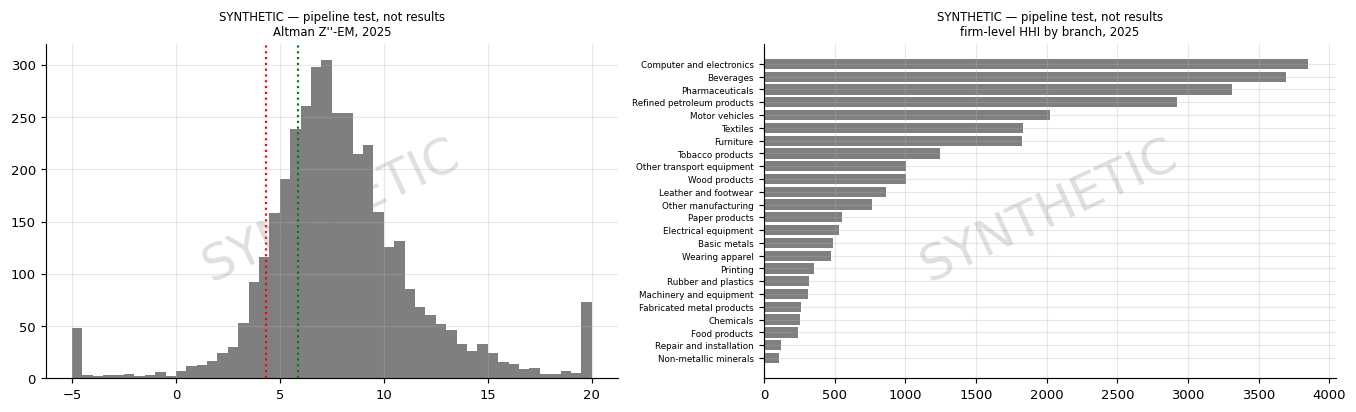

In [49]:
def run_layer_b(panel, mode, outdir, write=True, plot=False):
    P = panel.copy(); syn = mode == 'SYNTHETIC'
    for f in SCHEMA[SCHEMA.type == 'float'].field:
        if f in P: P[f] = pd.to_numeric(P[f], errors='coerce')
    if 'size_class' not in P or P.size_class.isna().any():
        P['size_class'] = size_class(P.employees.values, P.revenue.values)
    T = []
    def t(name, value, ok, note=''):
        if isinstance(value, (float, np.floating)):
            value = f'{value:.1e}' if (value != 0 and abs(value) < 1e-3) else f'{value:.3f}'
        T.append(dict(test=name, value=str(value), passed=bool(ok), note=note))
    bad = P.sample(min(6, len(P)), random_state=SEED).index
    PB = P.copy(); PB.loc[bad[:2], 'equity'] *= 1.5; PB.loc[bad[2:4], 'nace2'] = '34'; PB.loc[bad[4:], 'cash'] = -1.0
    v1 = validate(PB); caught = set(v1[v1.severity == 'error'].row - 2)
    t('validator catches 6 seeded corruptions (balance, NACE, negative cash)', len(caught & set(bad)), set(bad) <= caught)
    RAT = ratios(P)
    t('DuPont: margin x turnover x multiplier = ROE (max abs)', float((RAT.net_margin * RAT.asset_turnover * RAT.equity_multiplier - RAT.roe).abs().max()),
      float((RAT.net_margin * RAT.asset_turnover * RAT.equity_multiplier - RAT.roe).abs().max()) < 1e-9)
    P['tfp'] = tfp_index(P)
    cell = P.groupby(['nace2', 'year']).size().idxmax(); c = P[(P.nace2 == cell[0]) & (P.year == cell[1])]
    sL = (c.wage_bill / c.revenue).clip(0, 1).values; sM = ((c.cost_of_sales - c.wage_bill).clip(lower=0) / c.revenue).clip(0, 1).values
    sK = np.clip(1 - sL - sM, 0, None)
    X = {'l': np.log(c.employees.where(c.employees > 0).values), 'm': np.log(np.maximum((c.cost_of_sales - c.wage_bill).values, 1)),
         'k': np.log(np.maximum(c.fixed_assets.values, 1))}
    ref = np.log(c.revenue.values) - np.log(c.revenue.values).mean()
    for x, sh_ in [('l', sL), ('m', sM), ('k', sK)]: ref = ref - 0.5 * (sh_ + sh_.mean()) * (X[x] - np.nanmean(X[x]))
    mt = float(np.nanmax(np.abs(ref - P.loc[c.index, 'tfp'].values)))
    t(f'TFP index equals an independent firm-by-firm re-computation (NACE {cell[0]}, {cell[1]}; max abs gap)', mt, mt < 1e-10)
    CN = concentration(P, ['nace2']); CNR = concentration(P, ['nace2', 'region'])
    shs = (P.revenue / P.groupby(['nace2', 'year']).revenue.transform('sum')).groupby([P.nace2, P.year]).sum()
    t('market shares sum to one in every NACE-year cell (max gap)', float((shs - 1).abs().max()), (shs - 1).abs().max() < 1e-9)
    EE, SURV = entry_exit(P)
    fsh, SD = share_model(P)
    est = pd.Series(fsh.beta, index=fsh.names); se = pd.Series(fsh.se, index=fsh.names)
    fc_b = [b for b in P.nace2.unique() if b in BCODES]
    FF = firm_forecast(SD[SD.nace2.isin(fc_b)], est.values, B_['nom'])
    agg = FF.groupby(['year', 'nace2']).revenue_fc.sum() / 1000
    ffg = float((agg / B_['nom'].loc[FC_YEARS].stack().rename_axis(['year', 'nace2']).reindex(agg.index) - 1).abs().max() * 100)
    t('firm forecasts add up to the Layer-A branch forecast (%)', ffg, ffg < 1e-9)
    # v2: the firm-level econometric analysis (Part 17.4b-c) on the same panel, in both modes
    n_sh = int(SD.dropna(subset=['dlsh', 'rlp_l1', 'rlev_l1']).firm_id.nunique())
    E = firm_econometrics(P, RAT, mode, share_fit=(fsh, n_sh)); ET = econ_tables(E)
    t('firm-level econometric models estimated (statsmodels = independent numpy computation, asserted)', len(E['F']), len(E['F']) >= 13)
    if syn:
        rc = E['REC'].dropna(subset=['covered']); rc_ = rc[~rc.model_id.isin(['B_pf_pool', 'B_margin_pool'])]
        t('parameter recovery: consistent estimators within 4 s.e. of the true values (count)', f'{int((rc_.bias_in_se.abs() < 4).sum())}/{len(rc_)}',
          bool((rc_.bias_in_se.abs() < 4).all()), f'95% CI coverage {int(rc.covered.sum())}/{len(rc)} (all), {int(rc_.covered.sum())}/{len(rc_)} (consistent)')
    PR = peer_rank(P, RAT)
    t('peer percentile ranks lie in (0, 100]', float(PR.min().min()), (PR.min().min() > 0) and (PR.max().max() <= 100))
    rev = P.groupby(['year', 'nace2']).revenue.sum() / 1000
    cover = rev / GO.stack().rename_axis(['year', 'nace2']).reindex(rev.index)
    cnt = P.groupby(['year', 'nace2']).firm_id.nunique() / NENT.stack().rename_axis(['year', 'nace2']).reindex(rev.index)
    if syn:
        t('firm revenues add up to DSK branch output (max gap, %)', float((cover - 1).abs().max() * 100), (cover - 1).abs().max() < 1e-6)
        t('firm counts equal DSK active enterprises (max gap)', float((cnt - 1).abs().max()), (cnt - 1).abs().max() < 1e-9)
        t('determinant model recovers the DGP (true 0.15, -0.30)', f'{est.iloc[0]:.3f}, {est.iloc[1]:.3f} (s.e. {se.iloc[0]:.3f}, {se.iloc[1]:.3f})',
          all(abs(est.iloc[i] - BETA_TRUE[i]) < 3 * se.iloc[i] + 0.02 for i in range(2)))
    else:
        t('coverage diagnostic: firm revenue / DSK branch output (median)', float(cover.median()), True, 'diagnostic, not a test')
        t('coverage diagnostic: firms / DSK active enterprises (median)', float(cnt.median()), True, 'diagnostic, not a test')
        t('share model estimated (lagged relative productivity, leverage)', f'{est.iloc[0]:.3f}, {est.iloc[1]:.3f}', True, 'estimates, not a test')
    PIPE_ = pd.DataFrame(T)
    if write:
        pre = 'FR10_SYNTHETIC_' if syn else 'FR10_FIRM_'
        def sv(df, name):
            d = df.reset_index() if not isinstance(df.index, pd.RangeIndex) else df.copy()
            if syn and 'WATERMARK' not in d: d.insert(0, 'WATERMARK', SYN_MARK)
            d.to_csv(Path(outdir) / f'{pre}{name}.csv', index=False)
        sv(PIPE_, 'pipeline_tests')
        sv(pd.concat([v1.assign(dataset='with 6 seeded corruptions')]), 'validation_seeded_corruptions')
        ly = int(P.year.max()); m = P.year == ly
        sv(pd.concat([P.loc[m, ['firm_id', 'nace2', 'region', 'size_class']], RAT[m], PR[m].add_prefix('peer_pct_')], axis=1), f'firm_ratios_{ly}')
        sv(CNR.xs(ly, level='year'), f'concentration_nace_region_{ly}'); sv(CN, 'concentration_nace')
        sv(EE, 'entry_exit'); sv(SURV.rename_axis('cohort'), 'cohort_survival')
        sv(pd.DataFrame({'estimate': est.values, 'se': se.values, **({'true': BETA_TRUE} if syn else {})}, index=['rel_lp_l1', 'rel_leverage_l1']), 'share_model')
        sv(FF, 'firm_forecast'); sv(pd.DataFrame({'coverage_revenue_vs_DSK': cover, 'coverage_firms_vs_DSK': cnt}), 'coverage_vs_layer_a')
        for nm_, df_ in ET.items(): sv(df_, nm_)
    return dict(P=P, RAT=RAT, CN=CN, PIPE=PIPE_, FF=FF, est=est, se=se, E=E, ET=ET, fsh=fsh, SD=SD)
LB = run_layer_b(PANEL, DATA_MODE, OUT)
PIPE = LB['PIPE']
display(PIPE)
assert PIPE.passed.all(), 'Layer-B pipeline test failed'
print(f'[{DATA_MODE}] all {len(PIPE)} Layer-B tests pass; outputs {"FR10_SYNTHETIC_*" if DATA_MODE == "SYNTHETIC" else "FR10_FIRM_*"}.csv')
fig, ax = plt.subplots(1, 2, figsize=(13, 4)); ly = int(PANEL.year.max())
ax[0].hist(LB['RAT'].loc[LB['P'].year == ly, 'z_em'].clip(-5, 20), bins=50, color=PAL[7]); ax[0].axvline(4.35, color='r', ls=':'); ax[0].axvline(5.85, color='g', ls=':')
c_ = LB['CN'].xs(ly, level='year').HHI.rename(index=lambda b: BNAME.get(b, b)).sort_values()
ax[1].barh(c_.index, c_.values, color=PAL[7]); ax[1].tick_params(axis='y', labelsize=6)
for a, ttl in zip(ax, [f"Altman Z''-EM, {ly}", f'firm-level HHI by branch, {ly}']):
    a.set_title((SYN_MARK + '\n' if DATA_MODE == 'SYNTHETIC' else 'REAL DATA\n') + ttl, fontsize=8)
    if DATA_MODE == 'SYNTHETIC': a.text(0.5, 0.5, 'SYNTHETIC', transform=a.transAxes, fontsize=34, color='grey', alpha=0.25, ha='center', va='center', rotation=25)
plt.tight_layout(); plt.show()
SCHEMA.to_csv(OUT / 'FR10_input_schema.csv', index=False)
for _old in ['FR10_SYNTHETIC_input_schema.csv', 'FR10_SYNTHETIC_panel_sample.csv', 'FR10_SYNTHETIC_validation_report.csv',
             'FR10_SYNTHETIC_firm_forecast_2030.csv', 'FR10_SYNTHETIC_firm_ratios_2025.csv', 'FR10_SYNTHETIC_concentration_nace_region_2025.csv']:
    if (OUT / _old).exists() and DATA_MODE == 'SYNTHETIC' and not _old.endswith(('ratios_2025.csv', 'region_2025.csv')): (OUT / _old).unlink()

### 17.6 Swap tests: proving the replacement works, in a temporary directory

Reproducible checks run on throw-away copies in a temporary directory; the project's own `data/firm_panel/` is never
given a real-named file. (1) The synthetic file copied as `FR10_firm_panel.csv` with a neutral `data_status` loads as
**REAL**, passes the validator and produces `FR10_FIRM_*` outputs without watermark; (2) Azerbaijani headers load;
(3) `FIRM_PANEL_PATH` takes priority over a real-named file; (4) a broken file — a required column missing, and total
assets below current assets — produces clear validator messages and stops the run.

In [50]:
import tempfile, shutil
SW = []
def sw(name, ok, detail): SW.append(dict(test=name, passed=bool(ok), detail=detail))
with tempfile.TemporaryDirectory() as td:
    td = Path(td); (td / 'data' / 'firm_panel').mkdir(parents=True); (td / 'output').mkdir()
    real = pd.read_csv(SYN_CSV, dtype={'nace2': str, 'firm_id': str}); real['data_status'] = 'Ministry data (test copy)'
    real.to_csv(td / 'data' / 'firm_panel' / 'FR10_firm_panel.csv', index=False)
    shutil.copy(SYN_CSV, td / 'data' / 'firm_panel' / SYN_CSV.name)
    p_, m_, s_, _ = load_firm_panel(td)
    sw('real-named file with neutral data_status -> DATA_MODE = REAL', m_ == 'REAL' and s_.name == 'FR10_firm_panel.csv', f'mode {m_}, file {s_.name}')
    r_ = check_panel(p_, td / 'output' / 'FR10_firm_panel_validation_report.csv')
    sw('REAL file passes the validator (0 hard errors)', (~r_.severity.isin(['fatal', 'error'])).all(), f'{len(r_)} warnings')
    lb_ = run_layer_b(p_, m_, td / 'output')
    outs = sorted(p.name for p in (td / 'output').glob('FR10_*.csv'))
    sw('REAL mode writes FR10_FIRM_* only, without watermark, all tests pass',
       any(o.startswith('FR10_FIRM_') for o in outs) and not any(o.startswith('FR10_SYNTHETIC_') for o in outs)
       and 'WATERMARK' not in pd.read_csv(td / 'output' / 'FR10_FIRM_pipeline_tests.csv').columns and lb_['PIPE'].passed.all(),
       f'{len([o for o in outs if "_econ_" not in o])} files, e.g. {outs[:3]}')       # v1 table: econometric files are counted in the v2 table
    # v2: REAL mode runs the same firm-level econometrics (same data -> identical estimates); separate table
    ce = lb_['ET']['econ_coefficients'].set_index(['model_id', 'term']).coef
    cs = LB['ET']['econ_coefficients'].set_index(['model_id', 'term']).coef
    gap_e = float((ce - cs.reindex(ce.index)).abs().max()) if len(ce) == len(cs) else np.inf
    eco = sorted(p.name for p in (td / 'output').glob('FR10_FIRM_econ_*.csv'))
    rec_real = pd.read_csv(td / 'output' / 'FR10_FIRM_econ_recovery.csv')
    SW2 = [dict(test='REAL mode estimates the same firm-level models: identical coefficients on the same data',
                passed=bool(gap_e < 1e-9 and len(ce) == len(cs)), detail=f'{len(ce)} coefficients, max |gap| {gap_e:.1e}'),
           dict(test='REAL mode writes FR10_FIRM_econ_* (no watermark, no recovery against true values)',
                passed=bool(len(eco) >= 8 and 'WATERMARK' not in rec_real.columns and 'covered' not in rec_real.columns),
                detail=f'{len(eco)} files: ' + ', '.join(e.replace('FR10_FIRM_', '') for e in eco[:6]) + ' ...')]
    az = real.drop(columns='data_status').head(3000).rename(columns=AZ)
    az.to_excel(td / 'panel_az.xlsx', sheet_name='data', index=False)
    p2, m2, s2, unk = load_firm_panel(td, override=td / 'panel_az.xlsx')
    r2 = validate(p2)
    sw('Azerbaijani headers (xlsx, FIRM_PANEL_PATH) load and validate', s2.name == 'panel_az.xlsx' and not unk and (~r2.severity.isin(['fatal', 'error'])).all(),
       f'{len(p2)} rows, unknown columns {unk}, mode {m2}')
    sw('FIRM_PANEL_PATH has priority over the real-named file', s2.name == 'panel_az.xlsx', f'loaded {s2.name}')
    br = real.head(500).drop(columns='equity').copy(); br.loc[:4, 'total_assets'] = br.loc[:4, 'current_assets'] * 0.5
    r3 = validate(br)
    sw('broken file: missing required column reported as fatal', ((r3.severity == 'fatal') & (r3.field == 'equity')).any(),
       '; '.join(r3[r3.severity == 'fatal'].rule.unique()))
    br2 = real.head(500).copy(); br2.loc[:4, 'total_assets'] = br2.loc[:4, 'current_assets'] * 0.5
    r4 = validate(br2)
    flagged = sorted(set(r4[r4.field == 'total_assets'].row))
    try:
        check_panel(br2, td / 'output' / 'rep.csv'); stopped, msg = False, ''
    except ValueError as e:
        stopped, msg = True, str(e)
    sw('broken file: total assets < current assets flagged per row and the run stops', flagged[:5] == [2, 3, 4, 5, 6] and stopped, msg[:160])
SWAP = pd.DataFrame(SW)
display(SWAP)
assert SWAP.passed.all(), 'firm-panel swap test failed'
SWAP.to_csv(OUT / 'FR10_firm_panel_swap_tests.csv', index=False)
SWAP_ECON = pd.DataFrame(SW2); display(SWAP_ECON)
assert SWAP_ECON.passed.all(), 'econometrics swap test failed'
SWAP_ECON.to_csv(OUT / 'FR10_firm_panel_swap_tests_econ.csv', index=False)
assert not any((FPDIR / n).exists() for n in ['FR10_firm_panel.csv', 'FR10_firm_panel.xlsx']) or DATA_MODE == 'REAL'
print(f'all {len(SWAP)} swap tests pass; the project data/firm_panel/ holds no real-named file unless the Ministry placed one')

,test,passed,detail
0,real-named file with neutral data_status -> DA...,True,"mode REAL, file FR10_firm_panel.csv"
1,REAL file passes the validator (0 hard errors),True,0 warnings
2,"REAL mode writes FR10_FIRM_* only, without wat...",True,"11 files, e.g. ['FR10_FIRM_cohort_survival.csv..."
3,"Azerbaijani headers (xlsx, FIRM_PANEL_PATH) lo...",True,"3000 rows, unknown columns [], mode REAL"
4,FIRM_PANEL_PATH has priority over the real-nam...,True,loaded panel_az.xlsx
5,broken file: missing required column reported ...,True,required column missing (EN or AZ header)
6,broken file: total assets < current assets fla...,True,firm panel rejected: 15 hard errors (first: ro...


,test,passed,detail
0,REAL mode estimates the same firm-level models...,True,"81 coefficients, max |gap| 0.0e+00"
1,REAL mode writes FR10_FIRM_econ_* (no watermar...,True,"12 files: econ_coefficients.csv, econ_distress..."


all 7 swap tests pass; the project data/firm_panel/ holds no real-named file unless the Ministry placed one


### 17.7 Parameter recovery over replications (SYNTHETIC mode only)

One synthetic panel gives one draw of every estimate; whether a 95% interval covers the truth is a single
Bernoulli outcome. The structural layer is therefore re-drawn `MC_R` times (seeds `SEED + 1717 + r`, the v1 base
panel held fixed) and the models whose parameters the generator knows are re-estimated each time: the share of
replications whose 95% interval contains the true value is the **coverage**, and the mean estimate minus the truth,
divided by its Monte Carlo standard error, tests for bias. The pooled estimators are included to show the bias the
within estimator removes. Not run in REAL mode (no true parameters exist).

In [51]:
MC_R = 40
MC_SPECS = [('B_pf_fe', 'ols', 'ln_va', ['ln_L', 'ln_K'], 'firm+year', 'pf'), ('B_pf_pool', 'ols', 'ln_va', ['ln_L', 'ln_K'], 'nace+year', 'pf'),
            ('B_margin_fe', 'ols', 'op_margin', X_PROF_FE, 'firm+year', 'margin'), ('B_margin_pool', 'ols', 'op_margin', X_PROF_PO, 'nace_year', 'margin'),
            ('B_invest_fe', 'ols', 'inv_rate', ['sales_growth', 'leverage_l1', 'roa_w_l1', 'ln_emp_l1'], 'firm+year', 'invest'),
            ('B_tfp_pf', 'ols', 'tfp_pf', ['state', 'foreign', 'joint'], 'nace_year', 'tfp_own'),
            ('B_export', 'logit', 'exporter', ['ln_emp_l1', 'foreign', 'state', 'joint', 'ln_age', 'baku'], ('nace2', 'year'), 'export')]
def recovery_mc(base, R=MC_R):
    rows = []
    for r in range(R):
        S_, _, _ = structural_overlay(base.copy(), GO, seed=DGP_SEED + 1 + r)
        S_ = S_.reset_index(drop=True); RT_ = ratios(S_); S_['tfp'] = tfp_index(S_); D_ = econ_vars(S_, RT_)
        for mid, kind, y, xs, fe, tk in MC_SPECS:
            if y == 'tfp_pf':
                D_['tfp_pf'] = D_.ln_va - bpf['ln_L'] * D_.ln_L - bpf['ln_K'] * D_.ln_K
            f = econ_ols(D_, y, xs, fe=fe, fast=True) if kind == 'ols' else econ_logit(D_, y, xs, dummies=fe, fast=True)
            if mid == 'B_pf_fe': bpf = f.b
            tq = stats.t.ppf(0.975, f.dof) if f.dof else stats.norm.ppf(0.975); tv = DGP_TRUE[tk]
            items = [(c, f.b[c], f.se[c], tv[c]) for c in xs if c in tv]
            if tk == 'pf':
                a = np.ones(2); items.append(('RTS', float(f.b.sum()), float(np.sqrt(a @ f.V @ a)), tv['ln_L'] + tv['ln_K']))
            rows += [dict(rep=r, model_id=mid, term=c, true=t_, est=b_, se=s_, covered=abs(b_ - t_) <= tq * s_) for c, b_, s_, t_ in items]
    d = pd.DataFrame(rows)
    out = d.groupby(['model_id', 'term'], sort=False).agg(true=('true', 'first'), mean_estimate=('est', 'mean'), mc_sd=('est', 'std'),
                                                          mean_se=('se', 'mean'), coverage_95=('covered', 'mean'), reps=('rep', 'nunique')).reset_index()
    out['bias'] = out.mean_estimate - out.true; out['bias_t'] = out.bias / (out.mc_sd / np.sqrt(out.reps))
    out['se_ratio'] = out.mean_se / out.mc_sd
    out['consistent_estimator'] = ~out.model_id.isin(['B_pf_pool', 'B_margin_pool'])
    out['term_az'] = out.term.map(ECON_AZ)
    return out
if DATA_MODE == 'SYNTHETIC':
    _base = PANEL.drop(columns=[c for c in ['data_status', 'tfp'] if c in PANEL]).copy()
    for f_ in SCHEMA[SCHEMA.type == 'float'].field:
        if f_ in _base: _base[f_] = pd.to_numeric(_base[f_], errors='coerce')
    MC = recovery_mc(_base)
    mc_c = MC[MC.consistent_estimator]
    MC_SUM = dict(reps=MC_R, params=len(mc_c), mean_coverage=float(mc_c.coverage_95.mean()), min_coverage=float(mc_c.coverage_95.min()),
                  max_abs_bias_t=float(mc_c.bias_t.abs().max()), pooled_max_abs_bias_t=float(MC[~MC.consistent_estimator].bias_t.abs().max()))
    _m = MC.copy(); _m.insert(0, 'WATERMARK', SYN_MARK); _m.to_csv(OUT / 'FR10_SYNTHETIC_econ_recovery_mc.csv', index=False)
    _ip = pd.read_csv(OUT / 'FR10_SYNTHETIC_econ_interpretation_az.csv')
    _ip = pd.concat([_ip[_ip.model_id != 'recovery_mc'], pd.DataFrame([dict(WATERMARK=SYN_MARK, model_id='recovery_mc', interpretation_az=(
        f"[{SYN_AZ}] {MC_R} təkrarlamada (struktur qat yenidən çəkilir) ardıcıl qiymətləndiricilərin {len(mc_c)} parametri üzrə 95% "
        f"etibarlılıq intervalının orta əhatəsi {100 * MC_SUM['mean_coverage']:.1f}% (minimum {100 * MC_SUM['min_coverage']:.0f}%); "
        f"sürüşmə testinin maksimum |t| = {MC_SUM['max_abs_bias_t']:.1f}. Birləşdirilmiş OLS-də maksimum |t| = {MC_SUM['pooled_max_abs_bias_t']:.0f}: "
        f"daimi müəssisə effektləri nəzərə alınmadıqda əmsallar sürüşür."))])], ignore_index=True)
    _ip.to_csv(OUT / 'FR10_SYNTHETIC_econ_interpretation_az.csv', index=False)
    display(MC.round(4))
    print(f"[{SYN_MARK}] recovery over {MC_R} replications: consistent estimators mean 95% coverage {MC_SUM['mean_coverage']:.3f} "
          f"(min {MC_SUM['min_coverage']:.3f}), max |bias t| {MC_SUM['max_abs_bias_t']:.2f}; pooled OLS max |bias t| {MC_SUM['pooled_max_abs_bias_t']:.1f}")
    assert MC_SUM['mean_coverage'] > 0.85 and MC_SUM['max_abs_bias_t'] < 5, 'synthetic recovery failed: estimator or generator bug'
else:
    MC, MC_SUM = None, None
    print('REAL data: no true parameters, the replication study is not run')

,model_id,term,true,mean_estimate,mc_sd,mean_se,coverage_95,reps,bias,bias_t,se_ratio,consistent_estimator,term_az
0,B_pf_fe,ln_L,0.450,0.450,0.003,0.002,0.900,40,0.000,0.103,0.908,True,ln işçilərin sayı
1,B_pf_fe,ln_K,0.500,0.500,0.001,0.001,0.975,40,0.000,1.088,1.198,True,ln əsas fondlar
2,B_pf_fe,RTS,0.950,0.950,0.003,0.002,0.950,40,0.000,0.591,0.844,True,miqyasdan gəlir (βL + βK)
3,B_pf_pool,ln_L,0.450,0.493,0.003,0.003,0.000,40,0.043,102.296,1.001,False,ln işçilərin sayı
4,B_pf_pool,ln_K,0.500,0.462,0.002,0.002,0.000,40,-0.038,-125.598,1.028,False,ln əsas fondlar
5,B_pf_pool,RTS,0.950,0.955,0.001,0.002,0.050,40,0.005,25.491,1.224,False,miqyasdan gəlir (βL + βK)
6,B_margin_fe,ln_emp,0.010,0.010,0.001,0.001,0.975,40,-0.000,-0.484,0.972,True,ln işçilərin sayı (ölçü)
7,B_margin_fe,leverage,-0.060,-0.061,0.012,0.013,0.950,40,-0.001,-0.716,1.071,True,borc yükü (öhdəliklər / aktivlər)
8,B_margin_fe,ln_current_ratio,0.012,0.012,0.001,0.001,0.950,40,-0.000,-0.720,0.966,True,ln cari likvidlik əmsalı
9,B_margin_fe,ln_age,0.006,0.006,0.001,0.001,0.950,40,0.000,0.305,0.977,True,ln(1 + yaş)


[SYNTHETIC — pipeline test, not results] recovery over 40 replications: consistent estimators mean 95% coverage 0.945 (min 0.875), max |bias t| 3.76; pooled OLS max |bias t| 125.6


## Part 18 — Identity checks, exports, findings, documentation

### 18.1 Arithmetic checks

These verify the code, not the model: every one holds by construction (softmax adding-up, value = volume × price,
anchoring, the income-account identity). Evidence on the model is in Parts 11–13 and 16.

In [52]:
CH = []
def check(name, value, tol, unit='abs'):
    CH.append(dict(check=name, kind='arithmetic check - holds by construction', result=float(value), tolerance=tol, unit=unit,
                   passed=bool(abs(value) <= tol)))
for s_ in SCEN:
    S = SOL[s_]
    check(f'{s_}: manufacturing branch shares sum to 1', float((S['sh_man'].sum(axis=1) - 1).abs().max()), 1e-12)
    check(f'{s_}: industry branch shares sum to 1', float((S['sh_ind'].sum(axis=1) - 1).abs().max()), 1e-12)
    check(f'{s_}: regional shares sum to 1', float((S['reg_sh'].sum(axis=1) - 1).abs().max()), 1e-12)
    check(f'{s_}: manufacturing branches add up to section output', float((S['nom'][MANUF].sum(axis=1) / S['sec_go']['C'] - 1).abs().max()), 1e-12, 'ratio')
    check(f'{s_}: mining branches (oil part = residual) reconcile with FR1 mining output', float((S['nom'][MINING].sum(axis=1) / S['sec_go']['B'] - 1).abs().max()), 1e-12, 'ratio')
    _a = scen_arrays(s_)
    pidx = {k: pd.Series(_a[f'p_{v}'][0] / _a[f'p_{v}'][0, 0], index=YRS) for k, v in SECV.items()}
    oidx = pd.Series(_a['oil_exp_price'][0] / _a['oil_exp_price'][0, 0], index=YRS)
    gidx = pd.Series(_a['p_gdp'][0] / _a['p_gdp'][0, 0], index=YRS); cidx = pd.Series(_a['p_con'][0] / _a['p_con'][0, 0], index=YRS)
    defl = {b: PDEF.loc[LAST_ACT, b] * (oidx ** EPS_OIL[b] if b in OIL else gidx if b == '07' else cidx if b == '08' else pidx[BSEC[b]])
            for b in BCODES if b not in ('06', '09')}                 # 06, 09: residual (implied) deflator
    vv = max(float((S['real'][b] * defl[b] / S['nom'][b] - 1).abs().max()) for b in defl)
    check(f'{s_}: nominal = real x deflator for every branch (oil-linked: oil-price deflator)', vv, 1e-12, 'ratio')
    check(f'{s_}: non-oil + oil-linked branches add up to manufacturing output', float((S['nom'][MANUF].sum(axis=1) / S['sec_go']['C'] - 1).abs().max()), 1e-12, 'ratio')
    f_ = S['sec_fin']
    check(f'{s_}: section VA = compensation + other taxes + GOS', float((f_.VA - f_.CE - f_.OTP - f_.GOS).abs().max()), 1e-9, 'mn AZN')
B0 = SOL['Baseline']
check(f'model reproduces {LAST_ACT} branch output', float((B0['nom'].loc[LAST_ACT] / GO.loc[LAST_ACT, BCODES] - 1).abs().max()), 1e-12, 'ratio')
check(f'model reproduces {LAST_ACT} regional shares', float((B0['reg_sh'].loc[LAST_ACT] - SYS_R.W.loc[LAST_ACT]).abs().max()), 1e-12, 'share')
check(f'non-state share {LAST_ACT}: composition vs published (pp)', float(B0['ns_share'].loc[LAST_ACT] * 100 - NS.loc[LAST_ACT, 'ALL'] * 100), 0.05, 'pp')
check('vectorised fan simulator reproduces the solver (zero shocks)', VEC_CHECK, 1e-9)
check('Törnqvist TFP decomposition closes', float(gap_), 1e-9)
check('DSK adding-up checks (Part 5) all pass', float((~pd.DataFrame(REC).passed).sum()), 0, 'count')
check(f'Layer-B pipeline tests all pass ({DATA_MODE} panel)', float((~PIPE.passed).sum()), 0, 'count')
check('firm-panel swap tests all pass (temporary directory)', float((~SWAP.passed).sum()), 0, 'count')
CHK_T = pd.DataFrame(CH)
display(CHK_T)
assert CHK_T.passed.all(), f'failed checks: {CHK_T[~CHK_T.passed].check.tolist()}'
print(f'all {len(CHK_T)} arithmetic checks pass')

,check,kind,result,tolerance,unit,passed
0,Baseline: manufacturing branch shares sum to 1,arithmetic check - holds by construction,0.000,0.000,abs,True
1,Baseline: industry branch shares sum to 1,arithmetic check - holds by construction,0.000,0.000,abs,True
2,Baseline: regional shares sum to 1,arithmetic check - holds by construction,0.000,0.000,abs,True
3,Baseline: manufacturing branches add up to sec...,arithmetic check - holds by construction,0.000,0.000,ratio,True
4,Baseline: mining branches (oil part = residual...,arithmetic check - holds by construction,0.000,0.000,ratio,True
5,Baseline: nominal = real x deflator for every ...,arithmetic check - holds by construction,0.000,0.000,ratio,True
6,Baseline: non-oil + oil-linked branches add up...,arithmetic check - holds by construction,0.000,0.000,ratio,True
7,Baseline: section VA = compensation + other ta...,arithmetic check - holds by construction,0.000,0.000,mn AZN,True
8,Adverse: manufacturing branch shares sum to 1,arithmetic check - holds by construction,0.000,0.000,abs,True
9,Adverse: industry branch shares sum to 1,arithmetic check - holds by construction,0.000,0.000,abs,True


all 32 arithmetic checks pass


### 18.2 Exports

In [53]:
written = []
def save(df, name, index=True):
    p = OUT / f'FR10_{name}.csv'; df.to_csv(p, index=index); written.append((p.name, len(df)))
def long_frame(dct, value='value'):
    return pd.concat({k: (v.stack() if isinstance(v, pd.DataFrame) else v) for k, v in dct.items()}, names=['series', 'year', 'unit']).rename(value).reset_index()
SCORE = pd.DataFrame({'branch': [BNAME[b] for b in BCODES], 'section': [SECT[BSEC[b]] for b in BCODES],
                      f'share_of_industry_{LAST_ACT}_pct': SH_IND.loc[LAST_ACT, BCODES].values * 100,
                      'real_growth_2020_25_pct_pa': [avg_g(Q[b], 2020, LAST_ACT) for b in BCODES],
                      f'lp_{LAST_ACT}_thsd_AZN': LP_GO.loc[LAST_ACT, BCODES].values,
                      f'inv_rate_2023_25_pct': INV_RATE.loc[2023:LAST_ACT, BCODES].mean().values,
                      f'nonstate_share_{LAST_ACT}_pct': NS.loc[LAST_ACT, BCODES].values * 100,
                      'forecast_real_growth_2026_30_pct_pa': BR_FC['real growth % pa'].values}, index=BCODES)
SCORE = SCORE.join(EW[['margin_2023_25', 'n_flags', 'watch_list']]).join(PLAUS[['flag']].rename(columns={'flag': 'plausibility_flag'}))
save(SCORE.rename_axis('nace2'), 'branch_scorecard')
save(QUAD.rename_axis('nace2'), 'quadrant')
save(long_frame({'share_of_industry_pct': SH_IND * 100, 'share_of_manufacturing_pct': SH_MAN * 100}), 'branch_shares_history', False)
save(long_frame({'output_nominal_mn_AZN': GO, 'output_real_mn_AZN_2015': Q, 'deflator_2015_1': PDEF, 'nonstate_share': NS[BCODES],
                 'enterprises': NENT[BCODES], 'investment_mn_AZN': INV[BCODES], 'stocks_end_year_mn_AZN': STK.reindex(columns=BCODES),
                 'employees': EMPC, 'wage_AZN_month': WAGEC, 'va_nominal_NA': NA_VA}), 'branch_history', False)
fb = []
for s_ in SCEN:
    S = SOL[s_]
    for k_, nm_ in [('nom', 'output_nominal_mn_AZN'), ('real', 'output_real_mn_AZN_2015'), ('sh_ind', 'share_of_industry'),
                    ('sh_man', 'share_of_manufacturing'), ('emp', 'employees'), ('lp', 'lp_thsd_AZN_2015'), ('wage', 'wage_AZN_month'), ('gosp', 'gos_proxy_margin_pct')]:
        t = S[k_].stack().rename('value').reset_index(); t.columns = ['year', 'nace2', 'value']
        fb.append(t.assign(scenario=s_, indicator=nm_))
save(pd.concat(fb)[['scenario', 'indicator', 'year', 'nace2', 'value']], 'forecast_branches', False)
save(pd.concat({s_: SOL[s_]['sec_fin'].join(SOL[s_]['sec_go'].stack().rename('output').rename_axis(['year', 'sec']).swaplevel())
                for s_ in SCEN}, names=['scenario']), 'forecast_sections')
save(FAN, 'fan_charts')
save(pd.DataFrame([FAN_META]), 'fan_meta', False)
save(SCEN_SUM.rename_axis('scenario'), 'scenario_summary')
conc_f = pd.DataFrame({f'HHI manufacturing branches, {s_}': hhi(SOL[s_]['sh_man']).loc[FC_YEARS] for s_ in SCEN})
save(pd.concat([CONC, conc_f], axis=1), 'concentration')
save(pd.concat([own, pd.DataFrame({f'forecast non-state share %, {s_}': SOL[s_]['ns_share'].loc[FC_YEARS] * 100 for s_ in SCEN})], axis=1), 'ownership')
save(long_frame({'output_mn_AZN': REG_GO, 'share': REG_SH, 'nonstate_share': REG_NS, 'enterprises': REG_NENT, 'volume_index': REG_VI}), 'regional_history', False)
save(pd.concat({s_: pd.concat({'share': SOL[s_]['reg_sh'], 'output_mn_AZN': SOL[s_]['reg_go']}, axis=1) for s_ in SCEN}, names=['scenario', 'year']), 'forecast_regions')
save(REG_ENTRY, 'regional_entry_exit', False)
save(PROD_VIEW.rename_axis('product'), 'products')
save(EW.rename_axis('nace2'), 'early_warning')
save(SEC_FIN, 'financial_sections')
save(pd.concat([DVX_M, DVX], axis=1).rename_axis('year'), 'dvx_declarations')
save(GROWTH_CONTRIB.rename_axis('year'), 'growth_contributions')
save(DET, 'determinants_panel', False)
save(long_frame({'lp_output_thsd_AZN_2015': LP_GO, 'lp_va_thsd_AZN_2015': LP_VA, 'ic_share': IC_SH, 'capital_productivity': KPROD,
                 'investment_rate_pct': INV_RATE, 'innovation_intensity_pct': INNOV_INT, 'gos_proxy_margin_pct': GOSP}), 'efficiency_branches', False)
save(TFP_SUM.rename_axis('branch'), 'tfp_branches'); save(SEC_TFP, 'tfp_sections')
save(WPG.rename(index=BNAME).rename_axis('branch'), 'wage_productivity_gap')
save(SRC_MATRIX.rename_axis('id'), 'data_source_matrix'); save(GAPS.rename_axis('id'), 'data_gaps_and_alternatives')
save(FINDINGS, 'data_integrity_findings'); save(PRES, 'presentation_spec', False); save(NOAR, 'noar_constructs', False)
sel = []
for nm, lab in [('C', 'manufacturing'), ('B', 'mining'), ('R', 'regions')]:
    sel.append(SELECT[nm]['table'].assign(system=lab, stage='specification'))
    if SELECT[nm]['ktable'] is not None: sel.append(SELECT[nm]['ktable'].assign(system=lab, stage='shrinkage'))
save(pd.concat(sel).rename_axis('candidate'), 'share_system_selection')
save(SHARE_COEF if len(SHARE_COEF) else pd.DataFrame([{'note': 'no estimated slopes: constant-share systems'}]), 'share_system_coefficients', False)
save(HOLD, 'holdout_validation', False); save(HOLD_PER['C'].rename_axis('branch'), 'holdout_branches')
save(PLAUS, 'plausibility'); save(LEVERS.rename_axis('lever'), 'sensitivity_levers')
save(pd.DataFrame(REJ), 'rejected_specifications', False); save(CHK_T, 'identity_checks', False)
save(MANIFEST, 'dsk_manifest', False)
ASSUME = pd.DataFrame([('section output', 'output/VA ratio held at 2025', 'FR1 nominal VA'), ('non-oil branch relative prices', 'held at 2025', '-'),
                       ('refining real output', '2023-25 average throughput (capacity)', 'DSK 018'), ('refining price', 'oil export price in manat, estimated elasticity; exchange rate held', 'FR1 oil price'),
                       ('labour share of VA (margin baseline)', 'held at 2023-25 average', '-'),
                       ('within-branch non-state shares', 'held at 2025', '-'), ('within-section employment shares', 'held at 2025', 'FR4 section index'),
                       ('branch wages (sensitivity, productivity)', '2025 DSK wage x FR1 average-wage index', 'FR1 wage'), ('other taxes on production / VA', 'held at 2025', '-'),
                       ('branch VA / output', 'held at 2025', '-'), ('SME shares', 'held at 2024 (no time series)', '-')],
                      columns=['object', 'forecast rule', 'driver'])
save(ASSUME, 'forecast_assumptions', False)
save(OILB, 'oil_linked_block'); save(PSEL.rename_axis('candidate'), 'nonoil_allocation_selection')
save(pd.DataFrame([dict(**POOL_EST, mode=MAN_MODE)]), 'pooled_related_sector_model', False)
save(MULT.rename_axis('nace2'), 'cross_sector_multipliers'); save(pd.DataFrame([NONOIL_HIST]), 'nonoil_growth_vs_history', False)
save(DIVB, 'determinants_division_bias', False); save(PRODF, 'product_forecasts_derived', False)
save(PMS.rename_axis('product'), 'product_location_shares'); save(NS_TAB.rename_axis('nace2'), 'nonstate_composition')
save(pd.DataFrame([NS_COMP]), 'nonstate_composition_summary', False)
save(BR_FC.rename_axis('nace2'), 'branch_growth_table')
save(pd.concat([T08.assign(branch='08'), T07.assign(branch='07')]).rename_axis('rule'), 'mining_rules_selection')
save(pd.DataFrame([dict(**MINING_RULES, **MIN_REC)]), 'mining_reconciliation', False)
print(f'{len(written)} FR10 files written to {OUT} (plus {len(list(OUT.glob("FR10_SYNTHETIC_*.csv")))} SYNTHETIC files)')
display(pd.DataFrame(written, columns=['file', 'rows']))

52 FR10 files written to /Users/econ0757/My Drive/OxLon/MIIS_Micro_Risk_Policy/MicroUnit/output (plus 24 SYNTHETIC files)


,file,rows
0,FR10_branch_scorecard.csv,30
1,FR10_quadrant.csv,24
2,FR10_branch_shares_history.csv,1673
3,FR10_branch_history.csv,6933
4,FR10_forecast_branches.csv,4104
5,FR10_forecast_sections.csv,72
6,FR10_fan_charts.csv,1090
7,FR10_fan_meta.csv,1
8,FR10_scenario_summary.csv,3
9,FR10_concentration.csv,26


### 18.3 What was found

In [54]:
b_ = SOL['Baseline']; g_ = gk
print('=' * 100); print('FR10 — WHAT WAS FOUND'.center(100)); print('=' * 100)
print(f'1 DATA. {int(MANIFEST.status.isin(["present", "downloaded"]).sum())} DSK tables collected; {len(UNPUBLISHED)} no longer published (F1). '
      f'Branch output adds up to the industry total to {pd.DataFrame(REC).max_gap_pct.iloc[:3].max():.3f}%. {len(FINDINGS)} integrity findings.')
print(f'2 INDICATOR SYSTEM. {len(SRC_MATRIX)} indicators: ' + ', '.join(f'{k} {v}' for k, v in SRC_MATRIX.status_group.value_counts().items()) +
      f'; {len(GAPS)} gaps with alternatives; {len(PRES)} user views.')
print(f'3 MARKET POSITION {LAST_ACT}. Manufacturing HHI {CONC.loc[LAST_ACT, "HHI manufacturing branches"]:.0f} (2005: {CONC.loc[2005, "HHI manufacturing branches"]:.0f}); '
      f'refining {SH_MAN.loc[LAST_ACT, "19"]*100:.1f}% and food {SH_MAN.loc[LAST_ACT, "10"]*100:.1f}% of manufacturing; non-state share of industry '
      f'{NS.loc[LAST_ACT, "ALL"]*100:.1f}%; Baku {REG_SH.loc[LAST_ACT, "Baku city"]*100:.1f}% of industrial output.')
print(f'4 EFFICIENCY. Section TFP 2007-{LAST_ACT}, % a year: ' + ', '.join(f'{s_} {v:+.2f}' for s_, v in SEC_TFP.TFP.groupby(level=0).mean().mul(100).items()))
print(f'5 FINANCIAL CONDITION {LAST_ACT}. GOS % of VA: ' + ', '.join(f'{SECT[s_]} {INC.loc[(s_, LAST_ACT), "GOS"]/INC.loc[(s_, LAST_ACT), "VA"]*100:.1f}' for s_ in SECV)
      + f'; DVX declaration net margin {true_marg.loc[LAST_ACT]:.1f}%; branch GOS-proxy median {GOSP.loc[LAST_ACT].median():.1f}%.')
print(f'6 BRANCH MODEL. Refining by capacity and oil price; non-oil branches: {"pooled" if MAN_MODE == "pooled" else "combination of pooled related-sector model and constant shares"} '
      f'(beta {BETA:.3f}); benchmark share systems (windows <= {SEL_END}): manufacturing {LABEL[SELECT["C"]["chosen"]]}, mining {LABEL[SELECT["B"]["chosen"]]}, '
      f'regions {REG_LABEL.get(LABEL[SELECT["R"]["chosen"]], LABEL[SELECT["R"]["chosen"]])}' + (f' (kappa {SELECT["R"]["kappa"]:g})' if SELECT['R']['chosen'] != 'const' else '') + '.')
hs = HOLD[HOLD.selected & (HOLD.weighting == 'unweighted')].set_index(['system', 'measure'])
r_ = hs.loc[('manufacturing (24 branches): forecasting model', 'nominal')]
print(f'7 HOLD-OUT 2020-{LAST_ACT}. Manufacturing branch nominal output: U = {r_.U_vs_random_walk:.2f} vs random walk, {r_.U_vs_constant_growth:.2f} vs constant growth.')
print(f'8 FORECAST {FC_YEARS[0]}-{FC_YEARS[-1]} (baseline). Industry nominal output {SCEN_SUM.loc["Baseline", "industry nominal output growth % pa"]:+.2f}% a year, '
      f'manufacturing {SCEN_SUM.loc["Baseline", "manufacturing nominal growth % pa"]:+.2f}% nominal / {SCEN_SUM.loc["Baseline", "manufacturing real growth % pa (FR1 rva_man)"]:+.2f}% real; '
      f'90% band of manufacturing output growth {FAN.loc[("section output, mn AZN", "Manufacturing", g_), "p5"]:+.1f}% to {FAN.loc[("section output, mn AZN", "Manufacturing", g_), "p95"]:+.1f}%.')
print(f'9 PLAUSIBILITY. {nflag} of {len(PLAUS)} units flagged; watch list {int(EW.watch_list.sum())} branches.')
print(f'10 LAYER B. DATA_MODE = {DATA_MODE} ({PANEL_META["file"]}, {PANEL_META["rows"]:,} rows); {len(PIPE)} pipeline tests and {len(SWAP)} swap tests pass'
      + ('; SYNTHETIC: a pipeline demonstration, not findings - the Ministry replaces the file in its own system.' if DATA_MODE == 'SYNTHETIC' else '.'))

                                       FR10 — WHAT WAS FOUND                                        
1 DATA. 114 DSK tables collected; 6 no longer published (F1). Branch output adds up to the industry total to 0.001%. 14 integrity findings.
2 INDICATOR SYSTEM. 52 indicators: available now 40, requested 7, not available 5; 16 gaps with alternatives; 12 user views.
3 MARKET POSITION 2025. Manufacturing HHI 1400 (2005: 2188); refining 25.3% and food 23.0% of manufacturing; non-state share of industry 78.1%; Baku 79.9% of industrial output.
4 EFFICIENCY. Section TFP 2007-2025, % a year: Electricity -4.90, Manufacturing +0.23, Mining -6.87, Water -0.56
5 FINANCIAL CONDITION 2025. GOS % of VA: Mining 93.6, Manufacturing 65.8, Electricity 65.4, Water -51.6; DVX declaration net margin 10.0%; branch GOS-proxy median 20.4%.
6 BRANCH MODEL. Refining by capacity and oil price; non-oil branches: combination of pooled related-sector model and constant shares (beta 0.219); benchmark share systems (wi

### 18.4 Limitations

1. **The related-sector elasticity is significant in sample, but its out-of-sample allocation gain over constant
   shares is not established** (§11.5); the baseline combination follows a rule fixed in advance.
2. **Real branch output** does not beat constant growth on the hold-out (Part 13). Nominal output is more reliable.
3. **Refining** assumes no new capacity; the maximum-throughput lever shows the alternative.
4. **Financial condition is aggregate**: section GOS (national accounts), a branch GOS proxy (upper bound), and
   economy-wide tax declarations. Liquidity, leverage and distress need Layer B data.
5. **Efficiency** indicators rely on implicit deflators and a perpetual-inventory capital stock; small-branch TFP is
   noisy and branch-years with labour + materials shares above one are flagged.
6. **Determinants panel** has the power of 14 (7) year observations; most effects are not established.
7. **Exports, branch PPIs, energy costs, branch credit, renewal rates** are not available (gaps table).
8. **Layer B** is a tested pipeline, not an analysis: no firm data have been received.

### 18.6 Official Azerbaijani product and place names (DSK, Azerbaijani edition of the same tables)

DSK publishes every industry table in Azerbaijani under `https://www.stat.gov.az/source/industry/az/<file>.xls`
(found on the index page `https://www.stat.gov.az/source/industry/?lang=az`, browser User-Agent). Tables `018`
(products in kind) and `018_1` (products by city and district) are downloaded once into `data/dsk_enterprise_az/`
and matched to the English edition **row by row, with every numeric cell of the row required to agree (to 0.5%; the two
editions differ in a few last digits)**, so a
name is attached only to the row with the same data. The mapping is cached in `FR10_product_names_az.csv`.

In [55]:
AZ_DIR = BASE / 'data' / 'dsk_enterprise_az' / 'industry'; AZ_DIR.mkdir(parents=True, exist_ok=True)
AZ_URL = 'https://www.stat.gov.az/source/industry/az/{fn}'
_UA = 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0 Safari/537.36'
def fetch_az(fn):
    p = AZ_DIR / fn
    if p.exists() and p.read_bytes()[:8] == XLS_MAGIC: return p, 'present'
    try:
        req = urllib.request.Request(AZ_URL.format(fn=fn), headers={'User-Agent': _UA})
        with urllib.request.urlopen(req, timeout=60) as r: blob = r.read()
        if blob[:8] == XLS_MAGIC: p.write_bytes(blob); return p, 'downloaded'
        return None, 'not an Excel file (HTML reply)'
    except Exception as e:
        return None, f'failed: {e}'
def _rows(path):
    sh = xlrd.open_workbook(path).sheet_by_index(0); out = []
    for r in range(sh.nrows):
        lab = ' '.join(str(sh.cell_value(r, c)).strip() for c in range(2) if isinstance(sh.cell_value(r, c), str) and str(sh.cell_value(r, c)).strip())
        vals = tuple(to_num(sh.cell_value(r, c)) for c in range(2, sh.ncols))
        out.append((re.sub(r'\s+', ' ', lab).strip(), vals))
    return out
def match_az(fn_en, fn_az):
    '''{english label: azerbaijani label} for rows whose numeric cells are all equal (row-aligned editions).'''
    pa, st = fetch_az(fn_az)
    if pa is None: return {}, st, 0, 0
    en, az = _rows(P_('industry', fn_en)), _rows(pa)
    same = lambda a, b: len(a) == len(b) and all((np.isnan(x) and np.isnan(y)) or abs(x - y) <= 5e-3 * max(abs(x), abs(y), 1) for x, y in zip(a, b))
    m, n_lab, n_ok = {}, 0, 0
    for i, (le, ve) in enumerate(en):
        if not le or not re.search(r'[A-Za-z]', le): continue
        n_lab += 1
        if i < len(az) and az[i][0] and (same(ve, az[i][1]) or not np.isfinite(ve).any()):
            m.setdefault(le, az[i][0]); n_ok += 1
    return m, st, n_lab, n_ok
PROD_AZ, _st1, _n1, _k1 = match_az('018en.xls', '018.xls')
PLACE_AZ, _st2, _n2, _k2 = match_az('018_1en.xls', '018_1.xls')
_cache = AZ_DIR.parent / 'FR10_product_names_az.csv'
if PROD_AZ:
    pd.DataFrame([dict(table=t, en=k, az=v) for t, d_ in [('018', PROD_AZ), ('018_1', PLACE_AZ)] for k, v in d_.items()]).to_csv(_cache, index=False)
elif _cache.exists():
    _c = pd.read_csv(_cache); PROD_AZ = dict(zip(_c[_c.table == '018'].en, _c[_c.table == '018'].az)); PLACE_AZ = dict(zip(_c[_c.table == '018_1'].en, _c[_c.table == '018_1'].az))
_np_ = [l for l in PROD.label if l not in PROD_AZ]
print(f'DSK Azerbaijani edition: 018 {_st1} ({_k1}/{_n1} labelled rows matched on identical data), 018_1 {_st2} ({_k2}/{_n2}); '
      f'{len(PROD) - len(_np_)}/{len(PROD)} FR10 products have the official Azerbaijani name' + (f'; unmatched: {_np_[:5]}' if _np_ else ''))

DSK Azerbaijani edition: 018 present (160/160 labelled rows matched on identical data), 018_1 present (485/485); 142/142 FR10 products have the official Azerbaijani name


## Part 19 — v2: equation registry, indicator catalogue, full forecast table, scenario engine, robustness

### 19.1 Tənliklər reyestri (equation registry)

Every equation estimated anywhere in this notebook is registered with `microlib.registry` and written to
`output/FR10_equations.json`: the share systems (manufacturing and mining candidates as estimated at the 2019 cut,
the regional system actually used with its κ selection), the pooled related-sector model, the oil-linked block,
the mining rules, the determinants panel (two-way FE, DK, wild bootstrap, division-bias variants, between and
co-movement regressions) and — **Layer B** — every firm-level model (flagged `synthetic: true` while the panel is
SYNTHETIC). The registry re-estimates each OLS / DOLS / panel equation independently with statsmodels and asserts
that the coefficients equal the notebook's (relative 1e-6); where the forecast uses a transformed value (κ-shrunk
slopes, an imposed rule) the row's `used_value` carries it and the note says so. Hold-out re-estimates are the
`holdout` block of the corresponding equation.

In [56]:
if str(BASE) not in sys.path: sys.path.insert(0, str(BASE))
from microlib.registry import EquationRegistry
from microlib.summary import build_summary
from microlib import robustness as MR
REGX = EquationRegistry('FR10', data_mode='OBSERVED')
slug = lambda s: re.sub(r'[^A-Za-z0-9]+', '_', str(s)).strip('_')
CID = lambda kind, code: f'fr10:{kind}:{code}'
SUB = {'C': 'A1. Bazar payları: emal sənayesi sahələri', 'B': 'A2. Bazar payları: mədənçıxarma sahələri',
       'R': 'A3. Regional bölgü: iqtisadi rayonların sənaye payları', 'O': 'A4. Neftlə bağlı sahələr (neft emalı, kimya)',
       'D': 'A5. İnkişaf və tənəzzülün amilləri (determinantlar paneli)'}
SPEC_AZ = {'scale': 'miqyas (FR1 real əlavə dəyəri)', 'oil': 'neft qiyməti', 'scale+oil': 'miqyas + neft qiyməti',
           'combo': 'kombinasiya'}
def hold_block(r):
    return None if r is None else dict(cut=int(CUT), years=list(HY), rmse=float(r['RMSE']), theil_u_rw=float(r['U_vs_random_walk']),
                                       theil_u_const=float(r['U_vs_constant_growth']), dm_p_rw=float(r['DM_p_vs_rw']),
                                       dm_p_const=float(r['DM_p_vs_cg']), measure=r['measure'], weighting=r['weighting'], model=r['model'])

def reg_lr(eid, f, yl, Xl, used, comps, subtask, title_az, title_en, dep_az, notes='', extra=None, holdout=None):
    '''Register an lr_fit (DOLS rule) result with its exact design matrix and static levels sample.'''
    y = pd.Series(f.y, index=f.index, name='log_odds'); X = pd.DataFrame(f.X[:, 1:], index=f.index, columns=f.names[1:])
    est = f.estimator if f.estimator.startswith('DOLS') else 'OLS'
    eq = REGX.add(eid, y, X, estimator=est, cov='hac', fit_coef=f.lr, fit_se=f.lr_se, components=comps, subtask=subtask,
                  title_az=title_az, title_en=title_en, dependent_label_az=dep_az, used_in_forecast=used,
                  levels=(yl, Xl) if est.startswith('DOLS') else None, det=list(f.dcols), n_i1=len(f.icols),
                  lr_names=list(f.icols) + list(f.dcols), editable=[], notes_az=notes, extra=extra, holdout=holdout)
    eq['diagnostics']['eg_coint_p_notebook'] = None if not np.isfinite(f.eg_p) else float(f.eg_p)
    eq['diagnostics']['eg_note'] = 'eg_coint_p_notebook: ADF on the static OLS residual (Part 3 eg_coint_p); eg_coint_p: on the DOLS long-run residual'
    return eq

def reg_ols(eid, f, used, comps, subtask, title_az, title_en, dep_az, ycode, coint=False, notes='', extra=None, holdout=None,
            editable=None, restrictions=None, cov='hac', index=None):
    ix = f.index if index is None else index
    y = pd.Series(f.y, index=ix, name=ycode); X = pd.DataFrame(f.X[:, 1:], index=ix, columns=f.names[1:])
    return REGX.add(eid, y, X, estimator='OLS', cov=cov, fit_coef=dict(zip(f.names, f.beta)), fit_se=dict(zip(f.names, f.se)),
                    components=comps, subtask=subtask, title_az=title_az, title_en=title_en, dependent_label_az=dep_az,
                    used_in_forecast=used, coint=coint, notes_az=notes, extra=extra, holdout=holdout,
                    editable=editable if editable is not None else [], restrictions=restrictions)

def set_used(eq, name, value, **kw):
    for r in eq['coefficients']:
        if r['name'] == name:
            r['used_value'] = None if value is None else float(value); r.update(kw)
    eq['summary_text'] = build_summary(eq)

# --- A3: the regional share system actually used (spec, kappa chosen pre-cut), estimated 2005-2025
_sR = SELECT['R']; _xsR = SPEC_X.get(_sR['chosen'], [])
_yrsR = [y for y in SYS_R.W.index if SYS_R.est0 <= y <= LAST_ACT and SYS_R.W.loc[y].notna().all() and SYS_R.X.loc[y].notna().all()]
RAW_R = SYS_R.fit(_sR['chosen'], LAST_ACT, kappa=0.0) if _xsR else None        # coherence applied, no shrinkage
REG_SLOPES = {}
for k in [u for u in SYS_R.units if u != SYS_R.ref] if _xsR else []:
    p = PAR['R'][k]; f = p['fit']; s_ = slug(k)
    yl = SYS_R.LO[k].loc[_yrsR]; Xl = pd.concat([SYS_R.X.loc[_yrsR, _xsR], SYS_R.dum.loc[_yrsR, list(f.dcols)]], axis=1)
    fd = diff_fit(SYS_R.LO[k], SYS_R.X[_xsR], SYS_R.dum, sample=_yrsR)
    fd_used = 'difference form' in p.get('rule', '')
    comps = [CID('reg_share', s_), CID('reg_output', s_)]
    ex = dict(kappa=float(_sR['kappa']), shrink_B={x: p.get('B', {}).get(x) for x in _xsR}, slope_used={x: float(p['b'][x]) for x in _xsR},
              se_posterior={x: float(p['se'][x]) for x in _xsR}, slope_unshrunk={x: float(RAW_R[k]['b'][x]) for x in _xsR}, coherence=p.get('rule', ''))
    note = (f"Səviyyə (DOLS) və fərq formaları; uyğunluq qaydası: {'fərq forması istifadə olunur' if fd_used else 'səviyyə əmsalı istifadə olunur'}; "
            f"proqnozda empirik Bayes ilə büzülmüş dəyər (κ = {_sR['kappa']:g}) istifadə olunur — FR10.reg_system.")
    e1 = reg_lr(f'FR10.reg_{s_}_lvl', f, yl, Xl, not fd_used, comps, SUB['R'], f'{k}: sənaye payının log-nisbəti (səviyyə, DOLS)',
                f'{k}: log-odds of the industrial-output share vs Baku (levels, DOLS)', 'ln(pay / Bakı payı)', notes=note, extra=ex)
    e2 = reg_ols(f'FR10.reg_{s_}_fd', fd, fd_used, comps, SUB['R'], f'{k}: log-nisbət, fərq forması', f'{k}: log-odds, first differences',
                 'Δ ln(pay / Bakı payı)', 'd_log_odds', notes=note, extra=ex)
    for e in (e1, e2):
        if e['used_in_forecast']:
            for x in _xsR: set_used(e, x, p['b'][x])
        else:
            for r in e['coefficients']: r['used_value'] = None
    REG_SLOPES[k] = dict(slope=float(p['b'][_xsR[0]]), se=float(p['se'][_xsR[0]]), raw=float(RAW_R[k]['b'][_xsR[0]]),
                         raw_se=float(RAW_R[k]['se'][_xsR[0]]), eq_used=(e2 if fd_used else e1)['id'])
_hR = HOLD[HOLD.system.str.contains('regions') & HOLD.selected]
if REG_SLOPES:
    _hb = hold_block(_hR.iloc[0]) if len(_hR) else None
    eqS = REGX.add('FR10.reg_system', None, None, estimator=f'MNL log-odds share system, empirical-Bayes shrinkage (kappa={_sR["kappa"]:g})',
                   cov='posterior s.e. after shrinkage', fit_coef={slug(k): v['slope'] for k, v in REG_SLOPES.items()},
                   fit_se={slug(k): v['se'] for k, v in REG_SLOPES.items()}, p_dist='normal',
                   components=[CID('reg_share', slug(k)) for k in REG_NAMES] + [CID('reg_output', slug(k)) for k in REG_NAMES],
                   subtask=SUB['R'], title_az='14 iqtisadi rayonun sənaye payları sistemi (softmax, büzülmüş əmsallar)',
                   title_en='Regional share system (softmax, EB-shrunk slopes on the FR1 oil-sector mix)',
                   dependent_label_az='ln(rayon payı / Bakı payı)', dependent_code='log_odds', coef_labels_az={slug(k): f'{k}: neft-sektor qarışığına elastiklik' for k in REG_SLOPES},
                   used_in_forecast=True, holdout=_hb, notes_az='Bakı referensdir (əmsal 0). Spesifikasiya və κ 2019-a qədərki pəncərələrdə seçilib.',
                   extra=dict(selection=SELECT['R']['table'].reset_index().to_dict('records'),
                              kappa_selection=(SELECT['R']['ktable'].reset_index().to_dict('records') if SELECT['R']['ktable'] is not None else None),
                              chosen=_sR['chosen'], kappa=float(_sR['kappa'])))
    eqS['sample'].update(start=int(min(_yrsR)), end=int(max(_yrsR)), n=int(len(_yrsR)))
    eqS['summary_text'] = build_summary(eqS)
print(f'registry: regional share system registered ({len(REG_SLOPES)} region equations x level/difference form + the system); {len(REGX)} equations so far')

registry: regional share system registered (13 region equations x level/difference form + the system); 27 equations so far


In [57]:
# --- A1/A2: manufacturing and mining share-system candidates (constant shares chosen; candidates as estimated at the 2019 cut)
for nm, sy, units in [('C', SYS_C, MANUF), ('B', SYS_B, MINING)]:
    sel = SELECT[nm]['table']
    for spec in ['scale', 'oil', 'scale+oil']:
        par = sy.fit(spec, CUT, kappa=1.0); xs = SPEC_X[spec]
        yrs = [y for y in sy.W.index if sy.est0 <= y <= CUT and sy.W.loc[y].notna().all() and sy.X.loc[y].notna().all()]
        hr = HOLD[(HOLD.system == sy.name + ' (Part 11 share systems)') & (HOLD.model == LABEL[spec]) & (HOLD.measure == 'shares_pp')
                  & (HOLD.weighting == 'unweighted')]
        srow = sel.loc[LABEL[spec]]
        ex = dict(selection_rmse_pp=float(srow.RMSE_pp), selection_dm_p_vs_best=None if pd.isna(srow.DM_p_vs_best) else float(srow.DM_p_vs_best),
                  chosen_system=LABEL[SELECT[nm]['chosen']], estimated_to=int(CUT))
        for k in [u for u in sy.units if u != sy.ref]:
            f = par[k]['fit']
            yl = sy.LO[k].loc[yrs]; Xl = sy.X.loc[yrs, xs]
            reg_lr(f'FR10.{"man" if nm == "C" else "min"}_{k}_{spec.replace("+", "_")}', f, yl, Xl, False,
                   [CID('share_of_manufacturing' if nm == 'C' else 'share_of_industry', k)], SUB[nm],
                   f'{BNAME[k]}: pay log-nisbəti, namizəd "{SPEC_AZ[spec]}" (2005–{CUT})',
                   f'{BNAME[k]}: share log-odds vs {BNAME[sy.ref]}, candidate "{LABEL[spec]}" (estimated to {CUT})',
                   f'ln(pay / {BNAME[sy.ref]} payı)', extra=ex, holdout=hold_block(hr.iloc[0]) if len(hr) else None,
                   notes=(f'Rədd edilmiş namizəd: seçim RMSE {srow.RMSE_pp:.3f} f.b.; seçilən sistem — {LABEL[SELECT[nm]["chosen"]]}. '
                          f'Nümunədən kənar yoxlama bloku sistem üzrədir (2020–{LAST_ACT}).'))
print(f'registry: manufacturing and mining share-system candidates registered; {len(REGX)} equations so far')

# --- A1: the pooled related-sector model (branch FE, first differences, DK, wild bootstrap), used in the forecast
_PP = P_POOL.set_index(['unit', 'year'])
_hf = HOLD_FULL[HOLD_FULL.selected & (HOLD_FULL.measure == 'nominal') & (HOLD_FULL.weighting == 'unweighted')].iloc[0]
_hb = dict(cut=int(CUT), years=list(HY), rmse=float(_hf.RMSE), theil_u_rw=float(_hf.U_vs_random_walk), theil_u_const=float(_hf.U_vs_constant_growth),
           dm_p_rw=float(_hf.DM_p_vs_rw), dm_p_const=float(_hf.DM_p_vs_cg), measure='nominal branch output, log-%', model=_hf.model)
eqP = REGX.add('FR10.pooled', _PP['y'], _PP[['x']], estimator='FE-oneway (branch), first differences', cov='DK',
               fit_coef={'x': BETA}, fit_se={'x': BETA_SE}, panel={'entity': 'unit', 'time': 'year', 'twoway': False},
               components=[CID(c, b) for b in NONOIL for c in ('output_nominal_mn_AZN', 'output_real_mn_AZN_2015', 'share_of_manufacturing', 'share_of_industry')],
               subtask=SUB['C'], title_az='Əlaqəli sektor modeli: qeyri-neft sahə payları (ümumi elastiklik β)',
               title_en='Pooled related-sector model of non-oil branch shares (common elasticity)',
               dependent_label_az='Δ ln sahənin qeyri-neft emalında payı', dependent_code='dln_share', coef_labels_az={'x': 'Δ ln(əlaqəli sektor / sektor cəmi)'},
               sign_expected={'x': +1}, holdout=_hb, editable=['x'],
               notes_az=(f'Proqnozda {"bu model" if MAN_MODE == "pooled" else "bu model ilə sabit payların bərabər çəkili kombinasiyası"} istifadə olunur '
                         f'(seçim: DM p = {PSEL.loc["pooled", "DM_p_vs_const"]:.3f}). Sahə trendləri (μ_b) proqnoza köçürülmür.'),
               extra=dict(p_wild_bootstrap=float(WILD_POOL), beta_levels=float(F_LEV.beta[0]), levels_inside_fd_ci=bool(POOL_EST['levels_inside_fd_ci']),
                          mode=MAN_MODE, combination_weight=1.0 if MAN_MODE == 'pooled' else 0.5, links=LINK,
                          selection=PSEL.reset_index().to_dict('records')))
_PL = pooled_panel(LAST_ACT, lev=True).set_index(['unit', 'year'])
REGX.add('FR10.pooled_lev', _PL['y'], _PL[['x']], estimator='FE-oneway (branch), levels', cov='DK', fit_coef={'x': float(F_LEV.beta[0])},
         fit_se={'x': float(F_LEV.se[0])}, panel={'entity': 'unit', 'time': 'year', 'twoway': False}, components=[], subtask=SUB['C'],
         title_az='Əlaqəli sektor modeli, səviyyə forması (uyğunluq yoxlaması)', title_en='Pooled related-sector model in levels (coherence check)',
         dependent_label_az='ln sahə payı', dependent_code='ln_share', used_in_forecast=False, notes_az='Səviyyə əmsalı fərq formasının 95% intervalı daxilindədir: '
         + ('bəli' if POOL_EST['levels_inside_fd_ci'] else 'xeyr'))

# --- A4: oil-linked block: price elasticity of the refining / chemicals deflator to the oil price in manat (first differences)
OIL_EQ = {}
for b in OIL_CAND:
    yb = np.log(PDEF[b]).diff().loc[2006:LAST_ACT]; xb = np.log(OILAZN).diff().loc[2006:LAST_ACT].rename('dln_oil_azn').to_frame()
    fo = ols(yb, xb); used = b in OIL; r_ = OILB.loc[b]
    comps = [CID(c, b) for c in ('output_nominal_mn_AZN', 'share_of_manufacturing', 'share_of_industry')] if used else []
    e = reg_ols(f'FR10.oil_{b}', fo, used, comps, SUB['O'], f'{BNAME[b]}: deflyatorun neft qiymətinə (manatla) elastikliyi',
                f'{BNAME[b]}: elasticity of the branch deflator to the oil price in manat', 'Δ ln sahə deflyatoru', f'dln_pdef_{b}',
                editable=['dln_oil_azn'] if used else [],
                restrictions=[dict(text_az='Güc (emal həcmi) qaydası ilkin yoxlamada (2019-a qədər) sektor tempindən dəqiqdir', test='DM/HLN',
                                   stat=float(r_.precut_DM_stat), p=float(r_.precut_DM_p), imposed=bool(used))],
                extra=dict(cap_factor_baseline=float(r_.cap_factor_baseline), cap_factor_max=float(r_.cap_factor_max),
                           precut_rmse_capacity=float(r_.precut_RMSE_capacity), precut_rmse_sector=float(r_.precut_RMSE_sector_rate)),
                notes=('Real buraxılış = emal həcmi (güc); qiymət = 2025 × (neft qiyməti indeksi)^ε. Sabit proqnoza köçürülmür.' if used else
                       'Güc qaydası rədd edilib: sahə qeyri-neft bölgüsünə daxildir; elastiklik proqnozda istifadə olunmur.'))
    set_used(e, 'const', None); OIL_EQ[b] = e
    if not used:
        for r in e['coefficients']: r['used_value'] = None
print(f'registry: pooled model, oil-linked block registered; {len(REGX)} equations so far')

registry: manufacturing and mining share-system candidates registered; 105 equations so far
registry: pooled model, oil-linked block registered; 109 equations so far


In [58]:
# --- A2: mining rules (quarrying elasticity to construction; metal ores rule), both chosen pre-cut
_f08 = ols(np.log(Q['08']).diff().loc[2006:LAST_ACT], np.log(F1H['rva_con']).diff().loc[2006:LAST_ACT].rename('x').to_frame())
assert abs(_f08.beta[1] - E08_EST) < 1e-12
_won = MINING_RULES['rule08'].startswith('unit')                # v2: unit link adopted only if it beats the neutral null pre-cut
_u8 = T08.loc['unit elasticity to construction']
_q8c = [CID(c, '08') for c in ('output_nominal_mn_AZN', 'output_real_mn_AZN_2015', 'share_of_industry')] + \
       [CID(c, b) for b in ('06', '09') for c in ('output_nominal_mn_AZN', 'share_of_industry')]
eM8 = reg_ols('FR10.mining_08', _f08, _won, _q8c, SUB['B'],
              'Digər faydalı qazıntılar (08): FR1 tikinti əlavə dəyərinə elastiklik', 'Quarrying (08): elasticity to FR1 construction value added',
              'Δ ln real buraxılış (08)', 'dlnQ_08', editable=['x'],
              restrictions=[dict(text_az='Vahid elastiklik (β = 1): tam nümunədə məlumatla rədd edilir' if UNIT08_TEST['p'] < 0.05 else 'Vahid elastiklik (β = 1)',
                                 test=f"HAC t(n−k={UNIT08_TEST['df']})", stat=UNIT08_TEST['t'], p=UNIT08_TEST['p'], imposed=_won),
                            dict(text_az='Vahid elastiklik qaydası (son faktiki ilə lövbərlənmiş) neytral qaydadan (son faktiki səviyyə sabit) ilkin yoxlamada əhəmiyyətli dərəcədə dəqiqdir',
                                 test='DM/HLN, hədəf ili üzrə (2019-a qədər)', stat=None, p=float(_u8.DM_p_vs_first), imposed=_won,
                                 rmse_neutral=float(T08.iloc[0].RMSE_log_pct), rmse_unit=float(_u8.RMSE_log_pct),
                                 rmse_estimated=float(T08.loc['estimated elasticity to construction'].RMSE_log_pct))],
              extra=dict(rule08=MINING_RULES['rule08'], e08_link=float(MINING_RULES['e08']), e08_estimated=float(E08_EST), e08_se=float(E08_SE),
                         precut_table=T08.reset_index().to_dict('records')),
              notes=('Vahid elastiklik qaydası seçilib (neytral qaydadan əhəmiyyətli dərəcədə dəqiq). ' if _won else
                     f'Vahid məhdudiyyət tam nümunədə rədd edilir (p = {UNIT08_TEST["p"]:.3f}) və ilkin yoxlamada neytral qaydadan dəqiq deyil '
                     f'(DM p = {_u8.DM_p_vs_first:.3f}): baza proqnozu neytral qaydadır (FR10.mining_08_rule); tikinti əlaqəsi rıçaq kimi saxlanılır. ')
                    + 'Sərbəst qiymətləndirmə qeyri-stabildir; neft-qaz hissəsi (06, 09) mədənçıxarma cəminin qalığıdır.')
set_used(eM8, 'x', MINING_RULES['e08'] if _won else None, **({'imposed_value': float(MINING_RULES['e08'])} if _won else {}))
set_used(eM8, 'const', None)
_y8 = np.log(Q['08']).loc[2005:LAST_ACT].rename('ln_Q_08')
REGX.add('FR10.mining_08_rule', _y8, None, estimator='Calibrated rule: anchored null, real output constant at the last actual level',
         cov='calibrated (no s.e.)', fit_coef={'level_factor_vs_2025': float(MINING_RULES['q08_level_factor'])}, fit_se={}, components=_q8c,
         subtask=SUB['B'], title_az='Digər faydalı qazıntılar (08): neytral qayda — real buraxılış 2025 faktiki səviyyəsində sabit',
         title_en='Quarrying (08): anchored null, real output constant at its 2025 actual level', dependent_label_az='ln real buraxılış (08)',
         used_in_forecast=not _won, editable=[], notes_az='Qiymət: FR1 tikinti deflyatoru. Seçim ilkin yoxlama pəncərələrində (2011–2017, hədəflər ≤ 2019).',
         extra=dict(precut_table=T08.reset_index().to_dict('records')))
_d07 = 'rva_min' if 'mining' in RULE07 else ('rva_con' if 'construction' in RULE07 else None)
RULE07_AZ = {'neutral: held at trailing 3-year average': 'neytral: son 3 ilin ortası səviyyəsində saxlanılır',
             'grows with FR1 mining VA': 'FR1 mədənçıxarma əlavə dəyəri ilə eyni tempdə artır',
             'grows with FR1 construction VA': 'FR1 tikinti əlavə dəyəri ilə eyni tempdə artır'}
_y7 = np.log(Q['07']).diff().loc[2006:LAST_ACT].rename('dlnQ_07')
if _d07:
    _x7 = np.log(F1H[_d07]).diff().loc[2006:LAST_ACT].rename(f'dln_{_d07}')
    eM7 = REGX.add('FR10.mining_07', _y7, _x7.to_frame(), estimator='Calibrated rule: unit elasticity, chosen pre-cut', cov='calibrated (no s.e.)',
                   fit_coef={f'dln_{_d07}': 1.0}, fit_se={}, resid=(_y7 - _x7), fitted=_x7, add_const=False,
                   components=[CID(c, '07') for c in ('output_nominal_mn_AZN', 'output_real_mn_AZN_2015', 'share_of_industry')], subtask=SUB['B'],
                   title_az=f'Metal filizləri (07): {RULE07_AZ.get(RULE07, RULE07)}', title_en=f'Metal ores (07): {RULE07}', dependent_label_az='Δ ln real buraxılış (07)',
                   editable=[f'dln_{_d07}'], notes_az='Qayda 2019-a qədərki pəncərələrdə neytral qaydadan əhəmiyyətli dərəcədə dəqiq olduğu üçün seçilib (DM p < 0.10).',
                   extra=dict(precut_table=T07.reset_index().to_dict('records')))
print(f'registry: mining rules registered; {len(REGX)} equations so far')

# --- A5: determinants panel (two-way FE, DK on t(T-1), wild cluster bootstrap), division-bias variants, between, co-movement
def _tw(d, dep, regs):
    w = _within(d, dep, regs, 'unit', 'year', True)               # exact two-way within transform (unbalanced panel)
    ix = pd.MultiIndex.from_arrays([w.unit.values, w.year.values], names=['unit', 'year'])
    return pd.Series(w[dep].values, index=ix, name=dep), pd.DataFrame(w[regs].values, index=ix, columns=regs)
DET_LAB = {'inv_rate_l1': 'investisiya norması, t−1', 'drelp_l1': 'Δ ln nisbi qiymət, t−1', 'nonstate_l1': 'qeyri-dövlət payı, t−1',
           'stocks_go_l1': 'ehtiyatlar / buraxılış, t−1', 'dln_ent_l1': 'Δ ln müəssisələrin sayı, t−1', 'dln_rwage_l1': 'Δ ln real əmək haqqı, t−1',
           'labour_share_l1': 'əməyin payı, t−1'}
DET_LAB.update({k + '_same': v + ' (eyni il məxrəci)' for k, v in DET_LAB.items()})
for spec, regs, yr0 in [('A', REGS1, 2011), ('B', REGS2, 2018)]:
    rows = DET[DET.spec.str.startswith(spec)].set_index('regressor')
    d = PNL[(PNL.year >= yr0) & (PNL.year <= LAST_ACT)].dropna(subset=['dlnQ_w'] + regs)
    yv, Xv = _tw(d, 'dlnQ_w', regs)
    REGX.add(f'FR10.det_{spec}', yv, Xv, estimator='FE-twoway (branch + year), within', cov='DK', fit_coef=rows.coef, fit_se=rows.se_DK,
             panel={'entity': 'unit', 'time': 'year', 'twoway': True}, components=[], subtask=SUB['D'], used_in_forecast=False,
             title_az=f'Sahə artımının amilləri, spesifikasiya {spec} ({yr0}–{LAST_ACT})', title_en=f'Determinants of branch real growth, spec {spec}',
             dependent_label_az='Δ ln real buraxılış ×100 (5/95% vinzorlaşdırılmış)', coef_labels_az=DET_LAB,
             notes_az='İki yönlü daxili çevirmə dəqiqdir (balanslaşdırılmamış panel); DK SE, t(T−1). Rekursiv/LOO yolları sadə ikiqat orta çıxarma ilə təqribidir.',
             extra=dict(p_wild_bootstrap=rows.p_wild.to_dict(), between_coef=rows.between_coef.to_dict(), between_p=rows.between_p.to_dict(),
                        branches=int(rows.branches.iloc[0]), years=int(rows.years.iloc[0])))
    bw = between_fit(d, 'dlnQ_w', regs)
    reg_ols(f'FR10.det_{spec}_between', bw, False, [], SUB['D'], f'Sahələr arası (between) qiymətləndirici, spesifikasiya {spec}',
            f'Between estimator (branch means), spec {spec}', 'sahə ortası: Δ ln real buraxılış', 'dlnQ_w_mean', cov='hc1',
            index=pd.RangeIndex(len(bw.y)), notes='Kəsişmə üzrə əlaqə (hansı növ sahələr sürətli böyüyür), sahə daxili təsir deyil; rekursiv/LOO sahələr üzrədir.')
    regs_s = [r + '_same' if r + '_same' in PNL else r for r in regs]
    d2 = PNL[PNL.year >= yr0].dropna(subset=['dlnQ_w'] + regs + regs_s)
    f2 = panel_fe(d2, 'dlnQ_w', regs_s); y2, X2 = _tw(d2, 'dlnQ_w', regs_s)
    REGX.add(f'FR10.det_{spec}_same', y2, X2, estimator='FE-twoway (branch + year), within', cov='DK', fit_coef=dict(zip(regs_s, f2.beta)),
             fit_se=dict(zip(regs_s, f2.se)), panel={'entity': 'unit', 'time': 'year', 'twoway': True}, components=[], subtask=SUB['D'],
             used_in_forecast=False, title_az=f'Amillər paneli {spec}: eyni il məxrəcli nisbətlər (bölmə sürüşməsi yoxlaması)',
             title_en=f'Determinants spec {spec}, same-year denominators (division-bias variant)', dependent_label_az='Δ ln real buraxılış ×100',
             coef_labels_az=DET_LAB, notes_az='Həssaslıq variantı: məxrəc t−1 ilində (əsas spesifikasiyada t−2).')
_dl = PNL.merge(pd.DataFrame({'year': F1H.index, 'dln_rva_man': np.log(F1H.rva_man).diff().values * 100}), on='year').dropna(subset=['dlnQ_w', 'dln_rva_man'])
_fl = panel_fe(_dl, 'dlnQ_w', ['dln_rva_man'], twoway=False)
_il = pd.MultiIndex.from_arrays([_dl.unit.values, _dl.year.values], names=['unit', 'year'])
REGX.add('FR10.det_link', pd.Series(_dl.dlnQ_w.values, index=_il), pd.DataFrame({'dln_rva_man': _dl.dln_rva_man.values}, index=_il),
         estimator='FE-oneway (branch), within', cov='DK', fit_coef={'dln_rva_man': float(_fl.beta[0])}, fit_se={'dln_rva_man': float(_fl.se[0])},
         panel={'entity': 'unit', 'time': 'year', 'twoway': False}, components=[], subtask=SUB['D'], used_in_forecast=False,
         title_az='Sahə artımının FR1 emal əlavə dəyəri ilə birgə hərəkəti (təsviri)', title_en='Co-movement of branch growth with FR1 manufacturing VA growth',
         dependent_label_az='Δ ln real buraxılış ×100', coef_labels_az={'dln_rva_man': 'Δ ln FR1 real emal əlavə dəyəri ×100'},
         notes_az='Təsviri: aqreqat qismən sahələrin cəmidir.')
print(f'registry: determinants panel registered; {len(REGX)} Layer-A equations')

registry: mining rules registered; 112 equations so far


registry: determinants panel registered; 119 Layer-A equations


**Layer B in the registry.** Every firm-level model is registered with its full output; while the panel is
SYNTHETIC each equation carries `synthetic: true`, `data_mode: "SYNTHETIC"`, the watermark and the Azerbaijani note
*"sintetik məlumat — texniki nümayiş"*. Robustness: recursive (expanding by year) and leave-one-year-out coefficient
paths, verdict by the registry rule (Chow and CUSUM are not defined for these panel estimators).

In [59]:
EB = LB['E']; EBD = EB['D']; EBF = EB['F']; EB_INT = LB['ET']['econ_interpretation_az'].set_index('model_id').interpretation_az
SUB_B = 'B. Müəssisə səviyyəsi: ' + ('SİNTETİK məlumat — texniki nümayiş' if DATA_MODE == 'SYNTHETIC' else 'real müəssisə paneli')
def _refit(f):
    if f.kind == 'ols':
        return lambda sub: (lambda q: (q.b, q.se))(econ_ols(sub(EBD), f.y, f.xs, fe=f.fe, fast=True))
    return lambda sub: (lambda q: (q.b, q.se))(econ_logit(sub(EBD), f.y, f.xs, dummies=f.dummies, fast=True))
def _b_block(eq, f, mid):
    L = ['-' * 92, 'Müəssisə paneli: ' + (f'{f.firms:,} müəssisə, ' if f.firms else '') + f'{f.n:,} müşahidə'
         + (f', {f.G:,} klaster (müəssisə)' if f.G else '') + (f', illər {min(f.years)}–{max(f.years)}' if f.years else '')]
    if f.kind == 'logit':
        L.append(f"AUC = {f.auc:.3f}; Brier = {f.brier:.4f}; Hosmer–Lemeshow p = {f.hl_p:.3f}"
                 + (f"; nümunədən kənar AUC ({f.oos['test_years']}) = {f.oos['auc_oos']:.3f}" if getattr(f, 'oos', None) else ''))
        L.append('Orta marjinal effektlər (AME): ' + '; '.join(f"{ECON_AZ.get(i, i)} {r['ame']:.4f} (s.x. {r['se']:.4f})" for i, r in f.ame.iterrows()))
    rc = EB['REC']; rc = rc[rc.model_id == mid] if 'model_id' in rc else rc.iloc[0:0]
    if len(rc) and 'covered' in rc and rc.covered.notna().any():
        L.append('Generatorun həqiqi parametrləri ilə müqayisə: ' + '; '.join(
            f"{r.term} həqiqi {r.true:.3f} / qiym. {r.estimate:.3f} [{r.ci_low:.3f}, {r.ci_high:.3f}] {'əhatə olunur' if r.covered else 'ƏHATƏ OLUNMUR'}"
            for r in rc.dropna(subset=['covered']).itertuples()))
    elif len(rc):
        L.append('Həqiqi parametr: ' + str(rc.note_az.iloc[0]))
    if DATA_MODE == 'SYNTHETIC': L.append(f'*** {SYN_MARK} — {SYN_AZ} ***')
    eq['summary_text'] = build_summary(eq) + '\n' + '\n'.join(L)

B_EQ = {}
for mid, f in EBF.items():
    eid = f'FR10.{mid}'; syn = DATA_MODE == 'SYNTHETIC'
    labels = {c: ECON_AZ.get(c, c) for c in list(f.b.index)}
    common = dict(components=[], subtask=SUB_B + ' — ' + ECON_BLOCK_AZ[f.block], title_az=f.title_az, title_en=f.title_en,
                  dependent_label_az=ECON_AZ.get(f.y, f.y), coef_labels_az=labels, used_in_forecast=(mid == 'B_share'), editable=[],
                  synthetic=syn, notes_az=EB_INT.get(mid, ''))
    if mid == 'B_share':
        fs_ = f.fit; yrs_ = LB['SD'].loc[fs_.index, 'year'].astype(int).values
        nm_ = list(f.b.index); y_ = pd.Series(fs_.y, index=yrs_, name='dlsh'); X_ = pd.DataFrame(fs_.X, index=yrs_, columns=nm_)
        eq = REGX.add(eid, y_, X_, estimator='OLS', cov='hc1', fit_coef=dict(zip(nm_, fs_.beta)), fit_se=dict(zip(nm_, fs_.se)),
                      add_const=False, coint=False, chow_breaks=(), dependent_code='dlsh', **common)
    elif f.kind == 'ols':
        yy = pd.Series(f.yv, index=f.sample.year.astype(int).values, name=f.y)
        eq = REGX.add(eid, yy, f.X.set_axis(f.sample.year.astype(int).values), estimator=f.est,
                      cov='cluster(firm)', cov_label='cluster(firm): CR1 G/(G-1)(N-1)/(N-K), t(G-1)', fit_coef=f.b, fit_se=f.se,
                      fit_df=int(f.dof), p_dist='t', results=f.res, resid=f.resid, fitted=pd.Series(f.fitted, index=yy.index), **common)
        eq['fit'].update(r2=f.r2, r2_adj=f.r2_adj, ser=f.ser, f_stat=f.F, f_p=f.F_p, f_type='cluster-robust Wald F(m, G-1)',
                         r2_type='within R²' if f.fe == 'firm+year' else 'R²')
        for k_ in ('r2_adj', 'ser', 'f_stat', 'f_p'): eq['fit'].get('null_reasons', {}).pop(k_, None)
        eq['diagnostics']['dw'] = None
        eq['diagnostics'].setdefault('null_reasons', {})['dw'] = 'müəssisə paneli: zaman sırası qalıq testi tətbiq olunmur'
        if f.block == 'b': eq['restrictions'] = [dict(text_az='Miqyasa görə sabit gəlir (βL + βK = 1)', test='cluster Wald F(1, G−1)',
                                                       stat=rts_test(f)['crs_wald_F'], p=rts_test(f)['crs_p'], imposed=False, rts=rts_test(f)['RTS'])]
        if f.fe == 'firm+year': eq['fitted']['note'] = 'within-transformed (firm-demeaned) actual and fitted, period means'
    else:
        eq = REGX.add(eid, pd.Series(f.yv, index=f.sample.year.astype(int).values), None, estimator=f.est,
                      cov='cluster(firm)', cov_label='cluster(firm), MLE sandwich', fit_coef=f.res.params, fit_se=f.res.bse, results=f.res,
                      **common)
        eq['diagnostics'].update(auc=f.auc, brier=f.brier, hosmer_lemeshow=f.hl_stat, hosmer_lemeshow_p=f.hl_p, event_rate=float(f.yv.mean()),
                                 calibration=f.calib.reset_index().to_dict('records'))
        if getattr(f, 'oos', None): eq['diagnostics'].update(auc_oos=f.oos['auc_oos'], brier_oos=f.oos['brier_oos'], oos=f.oos)
        eq['extra'] = dict(eq.get('extra') or {}, ame=f.ame.reset_index().rename(columns={'index': 'term'}).to_dict('records'))
    if f.kind != 'share':
        eq['sample'].update(firms=int(f.firms), clusters=int(f.G), years=[int(v) for v in f.years])
        rec, loo = year_paths(_refit(f), f.years, list(f.b.index))
        used_ = list(f.b.index)
        vd, nt = MR.verdict(rec, loo, [], None, used_, {c: float(f.b[c]) for c in used_})
        eq['robustness'].update(recursive=rec, loo=loo, loo_year_range=loo['range'], verdict=vd,
                                notes_az=nt + '; Chow və CUSUM bu panel qiymətləndiricisi üçün tətbiq olunmur')
        eq['robustness'].setdefault('null_reasons', {}).update(chow='panel: Chow tətbiq olunmur', cusum_p='panel: CUSUM tətbiq olunmur')
        for k_ in ('recursive', 'loo_year_range'): eq['robustness']['null_reasons'].pop(k_, None)
    eq['data_mode'] = DATA_MODE; eq['watermark'] = SYN_MARK if DATA_MODE == 'SYNTHETIC' else None
    eq['extra'] = dict(eq.get('extra') or {}, dropped_regressors=EB['DROPPED'].get(mid), interpretation_az=EB_INT.get(mid, ''))
    _b_block(eq, f, mid); B_EQ[mid] = eq
print(f'registry: {len(B_EQ)} Layer-B (firm-level, {DATA_MODE}) equations registered; {len(REGX)} equations in total')

registry: 14 Layer-B (firm-level, SYNTHETIC) equations registered; 133 equations in total


In [60]:
# registry coefficients equal the notebook's own estimates (forecast-relevant values and every Layer-B estimate)
_cv = lambda eid, name, key='coef': next(r[key] for r in REGX.get(eid)['coefficients'] if r['name'] == name)
REG_CHK = [('pooled beta', _cv('FR10.pooled', 'x'), BETA), ('pooled beta s.e.', _cv('FR10.pooled', 'x', 'se'), BETA_SE),
           ('refining oil-price elasticity', _cv('FR10.oil_19', 'dln_oil_azn'), EPS_OIL['19']),
           ('quarrying elasticity (estimate)', _cv('FR10.mining_08', 'x'), E08_EST),
           ('quarrying neutral level factor', _cv('FR10.mining_08_rule', 'level_factor_vs_2025'), MINING_RULES['q08_level_factor'])]
REG_CHK += [(f'regional slope {k}', _cv('FR10.reg_system', slug(k)), v['slope']) for k, v in REG_SLOPES.items()]
REG_CHK += [(f'determinants {r.spec[:1]} {r.regressor}', _cv(f'FR10.det_{r.spec[:1]}', r.regressor), r.coef) for r in DET.itertuples()]
REG_CHK += [(f'{m} {c}', _cv(f'FR10.{m}', c), float(f.b[c])) for m, f in EBF.items() for c in f.b.index]
REG_CHK = pd.DataFrame(REG_CHK, columns=['check', 'registry', 'notebook'])
REG_CHK['abs_diff'] = (REG_CHK.registry - REG_CHK.notebook).abs()
assert (REG_CHK.abs_diff <= 1e-9 * np.maximum(1, REG_CHK.notebook.abs())).all(), REG_CHK[REG_CHK.abs_diff > 1e-9]
# verdict basis (contract rule: 'all USED coefficients'): the forecast-used slopes; for rejected / analysis equations every
# stochastic regressor. Deterministic dummies (d2019 step/impulse) and DOLS lead/lag terms are not part of the basis.
_DET = {'d2019'}
for e in REGX.equations:
    if e['id'].startswith('FR10.B_'): continue
    rows = [r for r in e['coefficients'] if r.get('role') == 'regressor' and r['name'] not in _DET]
    basis = [r['name'] for r in rows if e['used_in_forecast'] and r.get('used_value') is not None] or [r['name'] for r in rows]
    rb = e['robustness']
    vd, nt = MR.verdict(rb.get('recursive'), rb.get('loo'), rb.get('chow_tests'), rb.get('cusum_p'), basis, {r['name']: r['coef'] for r in rows})
    rb['verdict_registry_all_regressors'] = rb['verdict']; rb['verdict'], rb['notes_az'] = vd, nt; rb['verdict_basis'] = basis
    e['summary_text'] = build_summary(e)
REGX.validate()
REG_PATH = OUT / 'FR10_equations.json'
REGX.write(REG_PATH)
_j = json.loads(REG_PATH.read_text(encoding='utf-8'))
_j.update(layer_a_data_mode='OBSERVED', layer_b_data_mode=DATA_MODE, layer_b_watermark=SYN_MARK if DATA_MODE == 'SYNTHETIC' else None,
          layer_b_note_az=(f'B qatının bütün tənlikləri {SYN_AZ} (synthetic: true)' if DATA_MODE == 'SYNTHETIC' else 'B qatı real müəssisə məlumatı üzrədir'))
REG_PATH.write_text(json.dumps(_j, ensure_ascii=False, indent=1, allow_nan=False), encoding='utf-8')
from microlib.schema import validate_file
assert validate_file(REG_PATH) == []
REG_T = REGX.table()
REG_T['layer'] = np.where(REG_T.id.str.startswith('FR10.B_'), 'B', 'A')
REG_T['subtask'] = [e['subtask'] for e in REGX.equations]
print(f'{len(REG_CHK)} registry-vs-notebook coefficient checks pass (max abs diff {REG_CHK.abs_diff.max():.1e}); '
      f'{REG_PATH.name}: {len(REGX)} equations ({int((REG_T.layer == "A").sum())} Layer A, {int((REG_T.layer == "B").sum())} Layer B), '
      f'{int(REG_T.used.sum())} used in forecasting; verdicts: {REG_T.verdict.value_counts().to_dict()}')
display(REG_T.groupby(['layer', 'subtask']).agg(equations=('id', 'size'), used=('used', 'sum')))
print(REGX.summary('FR10.pooled'))
print(REGX.summary('FR10.B_pf_fe'))

111 registry-vs-notebook coefficient checks pass (max abs diff 0.0e+00); FR10_equations.json: 133 equations (119 Layer A, 14 Layer B), 19 used in forecasting; verdicts: {'qismən stabil': 47, 'stabil': 45, 'qeyri-stabil': 41}


equations  used
layer subtask                                                            
A     A1. Bazar payları: emal sənayesi sahələri                  71     1
      A2. Bazar payları: mədənçıxarma sahələri                   12     2
      A3. Regional bölgü: iqtisadi rayonların sənaye ...         27    14
      A4. Neftlə bağlı sahələr (neft emalı, kimya)                2     1
      A5. İnkişaf və tənəzzülün amilləri (determinant...          7     0
B     B. Müəssisə səviyyəsi: SİNTETİK məlumat — texni...          4     0
      B. Müəssisə səviyyəsi: SİNTETİK məlumat — texni...          2     0
      B. Müəssisə səviyyəsi: SİNTETİK məlumat — texni...          3     0
      B. Müəssisə səviyyəsi: SİNTETİK məlumat — texni...          1     0
      B. Müəssisə səviyyəsi: SİNTETİK məlumat — texni...          2     0
      B. Müəssisə səviyyəsi: SİNTETİK məlumat — texni...          1     1
      B. Müəssisə səviyyəsi: SİNTETİK məlumat — texni...          1     0

Reqressiya nəticəsi — tənlik FR10.pooled
Əlaqəli sektor modeli: qeyri-neft sahə payları (ümumi elastiklik β)
Asılı dəyişən:                       dln_share    Determinasiya əmsalı (R²):              0.0109
  (Δ ln sahənin qeyri-neft emalın)                Düzəldilmiş R²:                              —
Qiymətləndirmə üsulu:             FE-oneway (branch), first differences    F-statistikası:                          5.927
Kovariasiya növü:                           DK    p-dəyəri (F):                           0.0249
Müşahidələr:                               200    Log-həqiqətəbənzərlik:                       —
Qalıq sərbəstlik dərəcəsi:                  19    AIC:                                         —
Parametrlər (k):                            11    BIC:                                         —
Nümunə:                              2006–2025    Reqressiyanın standart xətası:          0.4611
Kovariasiya: DK(L=2), n/(n-k), t(T-1)
----------------------------------------------------

### 19.2 Components: the indicator catalogue and the full forecast table

Every forecast component gets a stable id `fr10:<code>` (catalogue `output/FR10_indicator_catalog.csv`) and every
year of history plus 2026–2030 in each of the three FR1 scenarios (`output/FR10_forecast_tidy.csv`, with the 5–95%
band where Part 15 computes one — Baseline). Components: all 30 branches (nominal and real output, shares of
industry and of manufacturing, employment, labour productivity, wage, GOS-proxy margin), the four sections
(output, value added, compensation, other taxes, GOS, GOS share and labour share of value added), the industry total,
14 regions (share and output), manufacturing HHI, the non-state share (composition), and the products (derived
volumes). What is not forecast is listed with the reason in `output/FR10_not_forecast.csv`.

In [61]:
REGION_AZ = {'Baku city': 'Bakı şəhəri', 'Nakhchivan AR': 'Naxçıvan MR', 'Absheron-Khizi': 'Abşeron-Xızı', 'Daghlig Shirvan': 'Dağlıq Şirvan',
             'Ganja-Dashkasan': 'Gəncə-Daşkəsən', 'Garabagh': 'Qarabağ', 'Gazakh-Tovuz': 'Qazax-Tovuz', 'Guba-Khachmaz': 'Quba-Xaçmaz',
             'Lankaran-Astara': 'Lənkəran-Astara', 'Central Aran': 'Mərkəzi Aran', 'Mil-Mughan': 'Mil-Muğan', 'Shaki-Zagatala': 'Şəki-Zaqatala',
             'Eastern Zangezur': 'Şərqi Zəngəzur', 'Shirvan-Salyan': 'Şirvan-Salyan'}
_NACE_AZ = {'06': 'Xam neft və təbii qaz hasilatı', '07': 'Metal filizlərinin hasilatı', '08': 'Digər faydalı qazıntılar', '09': 'Mədənçıxarma sahəsində xidmətlər',
            '10': 'Qida məhsulları', '11': 'İçkilər', '12': 'Tütün məmulatları', '13': 'Toxuculuq', '14': 'Geyim', '15': 'Dəri və ayaqqabı', '16': 'Ağac emalı',
            '17': 'Kağız və karton', '18': 'Poliqrafiya', '19': 'Neft emalı məhsulları', '20': 'Kimya məhsulları', '21': 'Əczaçılıq məhsulları',
            '22': 'Rezin və plastik kütlə', '23': 'Digər qeyri-metal mineral məhsullar', '24': 'Metallurgiya', '25': 'Hazır metal məmulatları',
            '26': 'Kompüter və elektronika', '27': 'Elektrik avadanlığı', '28': 'Maşın və avadanlıq', '29': 'Avtomobil və qoşqular',
            '30': 'Digər nəqliyyat vasitələri', '31': 'Mebel', '32': 'Digər hazır məmulatlar', '33': 'Maşın və avadanlığın təmiri və quraşdırılması',
            '35': 'Elektrik enerjisi, qaz və buxar', '36': 'Su təchizatı, tullantılar'}
BNAME_AZ = _NACE_AZ
SECT_AZ = {'B': 'Mədənçıxarma', 'C': 'Emal sənayesi', 'D': 'Elektrik enerjisi, qaz və buxar', 'E': 'Su təchizatı, tullantılar'}
B_IND = [  # code, label_az, label_en, unit_az, kind, frame key, scale, history, fan indicator, branches
 ('output_nominal_mn_AZN', 'Nominal buraxılış', 'nominal output', 'mln manat', 'level', 'nom', 1, GO, 'branch nominal output, mn AZN', BCODES),
 ('output_real_mn_AZN_2015', 'Real buraxılış (2015 qiymətləri)', 'real output, 2015 prices', 'mln manat (2015)', 'level', 'real', 1, Q,
  'branch real output, mn AZN 2015 prices', BCODES),
 ('share_of_industry', 'Sənaye buraxılışında pay', 'share of industrial output', '%', 'share', 'sh_ind', 100, SH_IND, 'branch share of industry, %', BCODES),
 ('share_of_manufacturing', 'Emal sənayesində pay', 'share of manufacturing output', '%', 'share', 'sh_man', 100, SH_MAN,
  'branch share of manufacturing, %', MANUF),
 ('employees', 'İşçilərin sayı', 'employees', 'nəfər', 'level', 'emp', 1, EMPC, None, BCODES),
 ('lp_thsd_AZN_2015', 'Əmək məhsuldarlığı (real buraxılış / işçi)', 'labour productivity', 'min manat (2015) / işçi', 'level', 'lp', 1, LP_GO,
  'labour productivity, thsd AZN 2015 prices per employee', BCODES),
 ('wage_AZN_month', 'Orta aylıq əmək haqqı', 'average monthly wage', 'manat / ay', 'level', 'wage', 1, WAGEC, None, BCODES),
 ('gos_proxy_margin_pct', 'Ümumi mənfəət (proksi) marjası, buraxılışın %-i', 'GOS-proxy margin, % of output', '%', 'rate', 'gosp', 1, GOSP,
  'GOS-proxy margin, % of output', MANUF)]
S_IND = [('sec_output', 'Buraxılış', 'output', 'mln manat', 'level', 'output', 'section output, mn AZN'),
         ('sec_VA', 'Əlavə dəyər', 'value added', 'mln manat', 'level', 'VA', None), ('sec_CE', 'İşçilərə ödənişlər', 'compensation of employees', 'mln manat', 'level', 'CE', None),
         ('sec_OTP', 'İstehsala digər vergilər', 'other taxes on production', 'mln manat', 'level', 'OTP', None),
         ('sec_GOS', 'Ümumi mənfəət', 'gross operating surplus', 'mln manat', 'level', 'GOS', None),
         ('sec_GOS_share_VA', 'Ümumi mənfəət / əlavə dəyər', 'GOS share of value added', '%', 'share', 'GOS_share_VA', 'section GOS, % of value added'),
         ('sec_labour_share_VA', 'Əməyin payı / əlavə dəyər', 'labour share of value added', '%', 'share', 'labour_share_VA', None)]
_sec_hist = {'output': SEC_GO, 'VA': INC.VA.unstack(0), 'CE': INC.CE.unstack(0), 'OTP': INC.OTP.unstack(0), 'GOS': INC.GOS.unstack(0),
             'GOS_share_VA': (INC.GOS / INC.VA * 100).unstack(0), 'labour_share_VA': (INC.CE / INC.VA * 100).unstack(0)}
def _prod_code(r):
    return f"{r.branch}_{slug(re.sub(r',[^,]*$', '', r['product']).lower())[:48]}"
PROD_IDS = {}
for _, r in PRODF.iterrows():
    c = _prod_code(r); c = c if c not in PROD_IDS.values() else f'{c}_{len(PROD_IDS)}'; PROD_IDS[r['product']] = c
assert len(set(PROD_IDS.values())) == len(PRODF)
COMP = []          # (id, group_az, label_az, label_en, unit_az, kind, getter(sol)->Series by year, history Series, fan key, source csv, source column, eq ids)
_eq_b = lambda b: (['FR10.oil_' + b] if b in OIL else ['FR10.mining_08_rule', 'FR10.mining_08'] if b == '08' else
                   ['FR10.mining_08_rule', 'FR10.mining_07'] if b in ('06', '09') else ['FR10.mining_07'] if b == '07' and 'FR10.mining_07' in [e['id'] for e in REGX.equations]
                   else ['FR10.pooled'] if b in NONOIL else [])
for code, laz, len_, unit, kind, key, sc, hist, fan, units in B_IND:
    for b in units:
        COMP.append(dict(id=CID(code, b), group_az=f'Sənaye sahələri (NACE): {laz.lower()}', label_az=f'{b} {BNAME_AZ[b]}: {laz}',
                         label_en=f'{b} {BNAME[b]}: {len_}', unit_az=unit, kind=kind, get=(lambda S, key=key, b=b, sc=sc: S[key][b] * sc),
                         hist=(hist[b] * sc if b in hist else pd.Series(dtype=float)), fan=(fan, b) if fan else None,
                         source_csv='FR10_forecast_branches.csv', source_column=f'{code}|{b}', equation_ids=_eq_b(b)))
for code, laz, len_, unit, kind, col, fan in S_IND:
    for s_ in SECV:
        COMP.append(dict(id=CID(code, s_), group_az=f'Sənaye bölmələri: {laz.lower()}', label_az=f'{SECT_AZ[s_]}: {laz}', label_en=f'{SECT[s_]}: {len_}',
                         unit_az=unit, kind=kind, get=(lambda S, col=col, s_=s_: S['sec_go'][s_] if col == 'output' else S['sec_fin'].xs(s_)[col]),
                         hist=_sec_hist[col][s_].dropna(), fan=(fan, SECT[s_]) if fan else None, source_csv='FR10_forecast_sections.csv',
                         source_column=f'{col}|{s_}', equation_ids=[]))
COMP.append(dict(id='fr10:ind_output', group_az='Sənaye, cəmi', label_az='Sənaye buraxılışı, cəmi (30 sahə)', label_en='industrial output, total', unit_az='mln manat',
                 kind='level', get=lambda S: S['nom'].sum(axis=1), hist=GO[BCODES].sum(axis=1, min_count=30).dropna(), fan=('industry output, mn AZN', 'Industry'),
                 source_csv='FR10_forecast_branches.csv', source_column='sum of output_nominal_mn_AZN', equation_ids=[]))
for rg in REG_NAMES:
    for code, laz, unit, kind, key, sc, hist, fan in [('reg_share', 'sənaye buraxılışında pay', '%', 'share', 'reg_sh', 100, REG_SH, 'regional share of industrial output, %'),
                                                      ('reg_output', 'sənaye buraxılışı', 'mln manat', 'level', 'reg_go', 1, REG_GO, None)]:
        COMP.append(dict(id=CID(code, slug(rg)), group_az=f'İqtisadi rayonlar: {laz}', label_az=f'{REGION_AZ[rg]}: {laz}', label_en=f'{rg}: {code}',
                         unit_az=unit, kind=kind, get=(lambda S, key=key, rg=rg, sc=sc: S[key][rg] * sc), hist=hist[rg].dropna() * sc,
                         fan=(fan, rg) if fan else None, source_csv='FR10_forecast_regions.csv', source_column=f'{key}|{rg}',
                         equation_ids=['FR10.reg_system'] + [REG_SLOPES[rg]['eq_used']] if rg in REG_SLOPES else ['FR10.reg_system']))
COMP.append(dict(id='fr10:hhi_man', group_az='Bazar mövqeyi', label_az='Emal sahələri üzrə Herfindahl-Hirschman indeksi', label_en='HHI across manufacturing branches',
                 unit_az='HHI (0–10 000)', kind='index', get=lambda S: hhi(S['sh_man']), hist=CONC['HHI manufacturing branches'].dropna(),
                 fan=('HHI across manufacturing branches', 'Manufacturing'), source_csv='FR10_concentration.csv', source_column='HHI manufacturing branches', equation_ids=['FR10.pooled']))
COMP.append(dict(id='fr10:nonstate_share', group_az='Bazar mövqeyi', label_az='Qeyri-dövlət sektorunun sənaye buraxılışında payı (tərkib effekti)',
                 label_en='non-state share of industrial output (composition)', unit_az='%', kind='share', get=lambda S: S['ns_share'] * 100,
                 hist=(NS['ALL'] * 100).dropna(), fan=('non-state share of industry, %', 'Industry'), source_csv='FR10_ownership.csv',
                 source_column='forecast non-state share %', equation_ids=[]))
for _, r in PRODF.iterrows():
    b, lab = r.branch, r['product']; inten = r.intensity_2023_25
    hp = PROD.set_index('label').loc[lab, yc18] if lab in set(PROD.label) else pd.Series(dtype=float)
    hp = (hp.iloc[0] if isinstance(hp, pd.DataFrame) else hp).astype(float).dropna()
    laz = PROD_AZ.get(lab, lab)
    COMP.append(dict(id=CID('prod', PROD_IDS[lab]), group_az=f'Məhsullar (natura ifadəsində): {BNAME_AZ[b]}', label_az=laz, label_en=lab,
                     unit_az=laz.rsplit(',', 1)[-1].strip() if ',' in laz else '', kind='level', get=(lambda S, b=b, i=inten: S['real'][b] * i),
                     hist=hp, fan=None, source_csv='FR10_product_forecasts_derived.csv', source_column=lab, equation_ids=_eq_b(b)))
assert len({c['id'] for c in COMP}) == len(COMP), 'duplicate component ids'
print(f'{len(COMP)} forecast components defined: ' + ', '.join(f'{k} {v}' for k, v in pd.Series([c["id"].split(":")[1] for c in COMP]).value_counts().items()))

414 forecast components defined: prod 127, lp_thsd_AZN_2015 30, output_real_mn_AZN_2015 30, wage_AZN_month 30, output_nominal_mn_AZN 30, employees 30, share_of_industry 30, share_of_manufacturing 24, gos_proxy_margin_pct 24, reg_share 14, reg_output 14, sec_output 4, sec_VA 4, sec_OTP 4, sec_GOS 4, sec_GOS_share_VA 4, sec_labour_share_VA 4, sec_CE 4, ind_output 1, hhi_man 1, nonstate_share 1


In [62]:
from microlib.catalog import write_catalog, check_catalog
_fanY = lambda key: (lambda f: f.loc[[i for i in f.index if isinstance(i, (int, np.integer))]].astype(float))(FAN.loc[key]) if key in FAN.index.droplevel(2) else None
TIDY, CAT = [], []
for c in COMP:
    h = pd.Series(c['hist'], dtype=float).dropna(); h = h[h.index <= LAST_ACT]; h.index = h.index.astype(int)
    band = _fanY(c['fan']) if c['fan'] else None
    for s_ in SCEN:
        fc = c['get'](SOL[s_]).loc[FC_YEARS].astype(float)
        if s_ == 'Baseline' and band is not None:
            assert np.allclose(band.baseline.loc[FC_YEARS].values, fc.values, rtol=1e-9, atol=1e-9), c['id']
        TIDY.append(pd.DataFrame({'id': c['id'], 'scenario': s_, 'year': h.index, 'value': h.values, 'lower_5': np.nan, 'upper_95': np.nan,
                                  'is_forecast': False}))
        TIDY.append(pd.DataFrame({'id': c['id'], 'scenario': s_, 'year': FC_YEARS, 'value': fc.values,
                                  'lower_5': band.p5.loc[FC_YEARS].values if (band is not None and s_ == 'Baseline') else np.nan,
                                  'upper_95': band.p95.loc[FC_YEARS].values if (band is not None and s_ == 'Baseline') else np.nan, 'is_forecast': True}))
    CAT.append(dict(id=c['id'], group_az=c['group_az'], label_az=c['label_az'], label_en=c['label_en'], unit_az=c['unit_az'], kind=c['kind'],
                    has_forecast=True, scenarios=SCEN, has_band=band is not None, source_csv=c['source_csv'], source_column=c['source_column'],
                    equation_ids=c['equation_ids'], imputed_years=[]))
TIDY = pd.concat(TIDY, ignore_index=True)
_meta = pd.DataFrame(CAT).set_index('id')[['unit_az', 'kind']]
TIDY = TIDY.join(_meta, on='id'); TIDY['imputed'] = False
TIDY = TIDY[['id', 'scenario', 'year', 'value', 'lower_5', 'upper_95', 'unit_az', 'kind', 'is_forecast', 'imputed']]
TIDY.to_csv(OUT / 'FR10_forecast_tidy.csv', index=False)
CATALOG = write_catalog(CAT, OUT / 'FR10_indicator_catalog.csv', 'FR10')
# completeness: every component has every year 2026-2030 in every scenario, finite
_fcT = TIDY[TIDY.is_forecast]
_cnt = _fcT.dropna(subset=['value']).groupby(['id', 'scenario']).year.nunique()
assert len(_cnt) == len(COMP) * len(SCEN) and (_cnt == len(FC_YEARS)).all(), 'forecast table incomplete'
assert np.isfinite(_fcT.value).all(), 'non-finite forecast values'
_fb = pd.read_csv(OUT / 'FR10_forecast_branches.csv', dtype={'nace2': str})
_fb = _fb[(_fb.indicator == 'output_nominal_mn_AZN') & _fb.year.isin(FC_YEARS)].assign(id=lambda d: 'fr10:output_nominal_mn_AZN:' + d.nace2.str.zfill(2))
_jj = _fb.merge(_fcT, on=['id', 'scenario', 'year'])
assert len(_jj) == len(_fb) and np.allclose(_jj.value_x, _jj.value_y, rtol=1e-12), 'tidy table differs from FR10_forecast_branches.csv'
NOT_FC = pd.DataFrame([
    ('fr10:tfp:<branch|section>', 'Ümumi amil məhsuldarlığı (TFP), sahə və bölmə', 'TFP by branch and section',
     'TFP artım uçotu ilə ölçülür; proqnozu sahə üzrə kapital ehtiyatı və aralıq istehlak proqnozu tələb edir, FR1-də bunlar sahə üzrə yoxdur', 'FR10_tfp_branches.csv'),
    ('fr10:early_warning:<branch>', 'Erkən xəbərdarlıq bayraqları', 'early-warning flags',
     'Bayraqlar son illərin müşahidə olunan dəyişmələri üzrə qərar qaydalarıdır (2023–25 vs 2020–22); proqnoz obyekti deyil', 'FR10_early_warning.csv'),
    ('fr10:investment_rate:<branch>', 'İnvestisiya norması, ehtiyatlar/buraxılış, innovasiya intensivliyi, kapital məhsuldarlığı', 'investment rate, stocks, innovation, capital productivity',
     'Bu səmərəlilik göstəriciləri üçün FR1-də ekzogen sürücü yoxdur; öz tarixindən proqnoz qadağandır (avtoreqressiya yoxdur)', 'FR10_efficiency_branches.csv'),
    ('fr10:sme_share:<activity>', 'KOS-un buraxılış, məşğulluq, aktivlərdə payı', 'SME shares', 'Yalnız 2023–2024 (iki il) mövcuddur; 2024 səviyyəsində saxlanılır, model yoxdur',
     'FR10_data_source_matrix.csv'),
    ('fr10:enterprises:<branch|region>', 'Müəssisələrin sayı, yaradılan və ləğv edilən müəssisələr', 'enterprise counts, entry and exit',
     'Giriş/çıxış üçün struktur sürücülü model qurulmayıb; öz tarixindən proqnoz qadağandır', 'FR10_regional_entry_exit.csv'),
    ('fr10:dvx:<indicator>', 'DVX bəyannamə göstəriciləri (mənfəət vergisi ödəyiciləri, zərər, borclar)', 'DVX declaration aggregates',
     'Yalnız 2021–2025 (5 il) və iqtisadiyyat üzrə; sahə üzrə deyil — proqnoz üçün kifayət deyil', 'FR10_dvx_declarations.csv'),
    ('fr10:product_location_share:<product>', 'Məhsulların istehsal yerləri üzrə payları (018_1)', 'product shares by place of production',
     'Yer üzrə paylar üçün sürücü yoxdur; təsviri göstərici', 'FR10_product_location_shares.csv'),
    ('fr10:firm:<firm_id>', 'Müəssisə səviyyəsində proqnozlar (B qatı)', 'firm-level forecasts (Layer B)',
     f'B qatı {DATA_MODE} panel üzrə işləyir; sintetik rejimdə yalnız texniki nümayişdir (FR10_SYNTHETIC_firm_forecast.csv), A qatının komponenti deyil', 'FR10_SYNTHETIC_firm_forecast.csv'),
    ('fr10:regional_nonstate_share:<region>', 'Regionlarda qeyri-dövlət sektorunun payı', 'regional non-state share',
     'Regional mülkiyyət strukturu üçün model yoxdur; tarixi göstərici', 'FR10_regional_history.csv')],
    columns=['id_pattern', 'label_az', 'label_en', 'reason_az', 'source_csv'])
NOT_FC.to_csv(OUT / 'FR10_not_forecast.csv', index=False)
print(f'catalogue: {len(CATALOG)} components; forecast table: {len(TIDY):,} rows, {len(COMP)} components x {len(SCEN)} scenarios x '
      f'{len(FC_YEARS)} years complete; bands for {int(CATALOG.has_band.eq("true").sum())} components (Baseline); {len(NOT_FC)} groups not forecast (reasons listed)')

catalogue: 414 components; forecast table: 34,689 rows, 414 components x 3 scenarios x 5 years complete; bands for 193 components (Baseline); 9 groups not forecast (reasons listed)


### 19.3 Scenario engine: exported state and `microlib/engines/fr10.py`

The engine re-implements the forecast solver of Part 14 (`core`) for one path. Editable: every FR1 driver path
2026–2030 and FR4's employment indices (exogenous), the forecast coefficients (pooled elasticity β, refining
oil-price elasticity, the two mining-rule elasticities, the 13 regional slopes — value, s.e. and CI from the
registry) and the levers (refinery capacity factor, labour-share shift and margin rule, the combination weight of
the non-oil allocation, the regional shrinkage κ). `selftest()` must reproduce `FR10_forecast_tidy.csv` in every
scenario (relative 1e-8) — asserted in the last cell.

In [63]:
from microlib.engines import base as EB_
_regeq = {e['id']: e for e in REGX.equations}
def _coef_row(eid, name, label_az, sign=None, value=None, ci=None):
    r = next(c for c in _regeq[eid]['coefficients'] if c['name'] == name)
    v = r['used_value'] if value is None else value
    return dict(eq_id=eid, name=name, label_az=label_az, value=float(v), se=r['se'], ci_low=(ci or (r['ci_low'], r['ci_high']))[0],
                ci_high=(ci or (r['ci_low'], r['ci_high']))[1], estimate=r['coef'], sign_expected=sign, editable=True,
                min=None, max=None)
DV_AZ = {'rva_min': ('FR1: mədənçıxarma real əlavə dəyəri', 'mln manat (2015)'), 'rva_man': ('FR1: emal sənayesi real əlavə dəyəri', 'mln manat (2015)'),
         'rva_elc': ('FR1: elektrik enerjisi real əlavə dəyəri', 'mln manat (2015)'), 'rva_wat': ('FR1: su təchizatı real əlavə dəyəri', 'mln manat (2015)'),
         'p_min': ('FR1: mədənçıxarma deflyatoru', 'indeks'), 'p_man': ('FR1: emal sənayesi deflyatoru', 'indeks'), 'p_elc': ('FR1: elektrik enerjisi deflyatoru', 'indeks'),
         'p_wat': ('FR1: su təchizatı deflyatoru', 'indeks'), 'oil_exp_price': ('FR1: neftin ixrac qiyməti', 'ABŞ dolları / barel'),
         'wage': ('FR1: orta aylıq nominal əmək haqqı', 'manat'), 'rva_con': ('FR1: tikinti real əlavə dəyəri', 'mln manat (2015)'),
         'rcons': ('FR1: ev təsərrüfatlarının real istehlakı', 'mln manat (2015)'), 'rinv_non': ('FR1: qeyri-neft real investisiya', 'mln manat (2015)'),
         'rgdpoil': ('FR1: neft-qaz real ÜDM', 'mln manat (2015)'), 'p_con': ('FR1: tikinti deflyatoru', 'indeks'), 'p_gdp': ('FR1: ÜDM deflyatoru', 'indeks')}
EX_V = [v for v in DVARS if v != 'emp']
_exo = [dict(id=f'fr1_{v}', label_az=DV_AZ[v][0], unit=DV_AZ[v][1], years=FC_YEARS, min=1e-9, max=None, step=None, source='FR1_forecast_full.csv',
             baseline={s_: [float(x) for x in scen_arrays(s_)[v][0, 1:]] for s_ in SCEN}) for v in EX_V]
_exo += [dict(id=f'fr4_hired_{s_}', label_az=f'FR4: muzdlu işçilərin indeksi, {SECT_AZ[s_].lower()} (2025 = 1)', unit='indeks (2025 = 1)', years=FC_YEARS,
              min=1e-9, max=None, step=None, source='FR4_hired_by_activity.csv', baseline={sc: [float(x) for x in fr4_index(sc)[s_][0, 1:]] for sc in SCEN})
         for s_ in SECV]
_coefs = [_coef_row('FR10.pooled', 'x', 'Əlaqəli sektor elastikliyi β (qeyri-neft sahə payları)', +1),
          _coef_row('FR10.mining_08', 'x', 'Digər faydalı qazıntılar: tikinti əlavə dəyərinə elastiklik (yalnız quarrying_rule = construction_link olduqda)',
                    +1, value=MINING_RULES['e08'])]
_coefs += [_coef_row(f'FR10.oil_{b}', 'dln_oil_azn', f'{BNAME_AZ[b]}: deflyatorun neft qiymətinə elastikliyi', +1) for b in OIL]
if 'FR10.mining_07' in _regeq:
    _r7 = next(c for c in _regeq['FR10.mining_07']['coefficients'])
    _coefs.append(dict(eq_id='FR10.mining_07', name=_r7['name'], label_az='Metal filizləri: sürücüyə elastiklik (qayda: 1)', value=1.0, se=None,
                       ci_low=None, ci_high=None, estimate=1.0, sign_expected=+1, editable=True, min=None, max=None))
_coefs += [_coef_row('FR10.reg_system', slug(k), f'{REGION_AZ[k]}: neft-sektor qarışığına elastiklik (büzülmüş)', None) for k in REG_SLOPES]
_levers = [dict(id=f'cap_factor_{b}', label_az=f'{BNAME_AZ[b]}: emal həcmi əmsalı (2026–30 / 2025)', value=float(CAPF[b]), default=float(CAPF[b]),
                min=0.5, max=1.5, step=0.005, note_az=f'baza: 2023–25 orta emal həcmi; maksimum 2015–25: {CAPMAX[b]:.3f}') for b in OIL]
_levers += [dict(id='quarrying_rule', label_az='Digər faydalı qazıntılar (08): proqnoz qaydası',
                 value='construction_link' if MINING_RULES['rule08'].startswith('unit') else 'neutral',
                 default='construction_link' if MINING_RULES['rule08'].startswith('unit') else 'neutral', options=['neutral', 'construction_link'],
                 note_az=f"neutral: real buraxılış 2025 faktiki səviyyəsində sabit (baza, DM p = {MINING_RULES['unit08_dm_p']:.3f}); "
                         "construction_link: FR1 tikinti əlavə dəyəri indeksi^elastiklik (həssaslıq)"),
            dict(id='labour_share_shift_pp', label_az='Əməyin əlavə dəyərdə payına düzəliş (faiz bəndi, marja qaydası)', value=0.0, default=0.0,
                 min=-20.0, max=20.0, step=0.5),
            dict(id='margin_mode', label_az='Marja qaydası', value='labour_share', default='labour_share',
                 options=['labour_share', 'fr1_wage', 'product_wage'], note_az='labour_share: əməyin payı 2023–25 ortası; fr1_wage: FR1 əmək haqqı yolu; product_wage: məhsul ifadəsində sabit əmək haqqı'),
            dict(id='combo_weight', label_az='Qeyri-neft bölgüsündə əlaqəli sektor modelinin çəkisi (0 = sabit paylar, 1 = model)',
                 value=1.0 if MAN_MODE == 'pooled' else 0.5, default=1.0 if MAN_MODE == 'pooled' else 0.5, min=0.0, max=1.0, step=0.05),
            dict(id='kappa_regions', label_az='Regional əmsalların büzülmə intensivliyi κ (0 = büzülmə yoxdur)', value=float(SELECT['R']['kappa']),
                 default=float(SELECT['R']['kappa']), min=0.0, max=1e6, step=None)]
ENG_INPUTS = dict(exogenous=_exo, coefficients=_coefs, levers=_levers)
_xsR = SPEC_X.get(PAR['R']['spec'], [])
ENG_STATE = dict(
    module='FR10', scen=SCEN, years=YRS, fc_years=FC_YEARS, last_act=LAST_ACT, bcodes=BCODES, manuf=MANUF, mining=MINING, oil=OIL, nonoil=NONOIL,
    bsec=BSEC, secv=SECV, link=LINK, sectot=SECTOT, reg_names=REG_NAMES, dvars=DVARS,
    q25={b: float(Q.loc[LAST_ACT, b]) for b in BCODES}, pdef25={b: float(PDEF.loc[LAST_ACT, b]) for b in BCODES},
    capf={b: float(v) for b, v in CAPF.items()}, eps_oil={b: float(v) for b, v in EPS_OIL.items()}, beta=float(BETA), man_mode=MAN_MODE,
    s25C=[float(x) for x in S25['C']], mining_rules={k: (float(v) if isinstance(v, (int, float, np.floating)) else v) for k, v in MINING_RULES.items()},
    d07=_d07, sec_go25={s_: float(SEC_GO.loc[LAST_ACT, s_]) for s_ in SECV},
    inc25={s_: dict(VA=float(INC.loc[(s_, LAST_ACT), 'VA']), CE=float(INC.loc[(s_, LAST_ACT), 'CE'])) for s_ in SECV},
    otp_sh={s_: float(OTP_SH[s_]) for s_ in SECV}, ls_avg={s_: float(LS_AVG[s_]) for s_ in SECV},
    na_go25={b: float(NA_GO.loc[LAST_ACT, b]) for b in MANUF}, vago25={b: float(VAGO25[b]) for b in MANUF},
    wbva_avg={b: float(WBVA_AVG[b]) for b in MANUF}, wbill25={b: float(WBILL.loc[LAST_ACT, b]) for b in MANUF},
    emp25={b: float(EMP25[b]) for b in BCODES}, wage25={b: float(WAGE25[b]) for b in BCODES}, ns25=[float(x) for x in NS25],
    reg=dict(xs=_xsR, lo25=[float(SYS_R.LO[k].loc[LAST_ACT]) for k in REG_NAMES], x2_25=float(SYS_R.X.loc[LAST_ACT, 'x2']),
             b={k: [float(PAR['R'][k]['b'][x]) for x in _xsR] for k in REG_NAMES},
             raw_b={k: [float(RAW_R[k]['b'][x]) if k != SYS_R.ref else 0.0 for x in _xsR] for k in REG_NAMES} if _xsR else {},
             raw_se={k: [float(RAW_R[k]['se'][x]) if k != SYS_R.ref else float('nan') for x in _xsR] for k in REG_NAMES} if _xsR else {},
             w25=[float(SYS_R.W.loc[LAST_ACT, k]) for k in REG_NAMES], ref=SYS_R.ref, kappa=float(SELECT['R']['kappa']),
             go25_sum=float(REG_GO.loc[LAST_ACT].sum()), slugs={k: slug(k) for k in REG_NAMES}),
    f1h25={v: float(F1H.loc[LAST_ACT, v]) for v in DVARS if v != 'emp'},
    products=[dict(id=CID('prod', PROD_IDS[r['product']]), branch=r.branch, intensity=float(r.intensity_2023_25)) for _, r in PRODF.iterrows()],
    components=[c['id'] for c in COMP], inputs=ENG_INPUTS, tidy_csv='FR10_forecast_tidy.csv',
    headline=['fr10:ind_output', 'fr10:sec_output:C', 'fr10:sec_output:B', 'fr10:share_of_manufacturing:19', 'fr10:sec_GOS_share_VA:C'])
EB_.save_state('FR10', ENG_STATE, root=str(BASE))
print(f'engine state written: output/engine/FR10_state.json (+ .npz) — {len(_exo)} exogenous paths, {len(_coefs)} coefficients, '
      f'{len(_levers)} levers, {len(COMP)} output series')

engine state written: output/engine/FR10_state.json (+ .npz) — 20 exogenous paths, 17 coefficients, 6 levers, 414 output series


### 19.4 Engine self-test, robustness summary and coefficient sensitivity (tornado)

The engine is imported fresh and must reproduce the full forecast table. Robustness: per equation, the registry
verdict and the test(s) behind it. Sensitivity: each editable forecast coefficient moved by −1 and +1 standard error
(Baseline), effect on the 2030 headline components (industry, manufacturing and mining output, the refining share of
manufacturing, the manufacturing GOS share of value added) in % of the baseline value; the levers likewise.

In [64]:
import importlib
import microlib.engines.fr10 as ENG
ENG = importlib.reload(ENG); ENG._S = None
import time as _time
_t0 = _time.perf_counter(); ENG_ST = ENG.selftest(); _t1 = _time.perf_counter() - _t0
print(f"engine selftest: {'PASS' if ENG_ST['ok'] else 'FAIL'}; max rel diff " +
      ', '.join(f"{s_} {v['max_rel_diff']:.1e} ({v['n_rows']} rows)" for s_, v in ENG_ST['detail'].items()) + f"; {_t1:.2f} s for 3 scenarios")
assert ENG_ST['ok'], {s_: v['problems'] for s_, v in ENG_ST['detail'].items()}
CAT_PROBS = check_catalog(OUT / 'FR10_indicator_catalog.csv', OUT / 'FR10_equations.json', ENG.run({}, 'Baseline'))
assert not CAT_PROBS, CAT_PROBS[:5]
print('catalogue cross-check (registry components, catalogue equation ids, engine series ids): 0 problems')
# --- robustness summary from the registry
RB = []
for e in REGX.equations:
    rb, dg = e['robustness'], e['diagnostics']; used = rb.get('verdict_basis') or [c['name'] for c in e['coefficients'] if c.get('role') == 'regressor']
    fails = []
    rec = rb.get('recursive') or {}
    for c in used:
        s0 = np.sign(next(r['coef'] for r in e['coefficients'] if r['name'] == c) or 0)
        p_ = [v for v in (rec.get('coef') or {}).get(c, []) if v is not None]
        if p_ and s0 and (np.sign(p_) != s0).any(): fails.append(f'rekursiv işarə dəyişməsi ({c})')
        lo = (rb.get('loo') or {}).get('coef', {}).get(c, [])
        if lo and s0 and (np.sign(lo) != s0).any(): fails.append(f'LOO işarə dəyişməsi ({c})')
    for r in rb.get('chow_tests') or []:
        if r.get('p') is not None and r['p'] < 0.05: fails.append(f"Chow {r['break_year']} p={r['p']:.3f}")
    if rb.get('cusum_p') is not None and rb['cusum_p'] <= 0.05: fails.append(f"CUSUM p={rb['cusum_p']:.3f}")
    if (dg.get('diff_form') or {}).get('coherent') is False: fails.append('fərq forması ilə uyğunsuzluq')
    if dg.get('coint_established') is False: fails.append('kointeqrasiya müəyyən edilməyib')
    for c in e['coefficients']:
        uv = c.get('used_value')
        if e['used_in_forecast'] and uv is not None and c.get('ci_low') is not None and c['role'] in ('regressor',) and not (c['ci_low'] <= uv <= c['ci_high']):
            fails.append(f"istifadə olunan dəyər ({c['name']} = {uv:.3g}) 95% intervaldan kənar" + (' (EB büzülməsi)' if e['id'].startswith('FR10.reg_') else
                                                                                                   ' (tətbiq edilmiş qayda)' if c.get('imposed_value') is not None else ''))
    RB.append(dict(equation=e['id'], layer='B' if e['id'].startswith('FR10.B_') else 'A', subtask=e['subtask'], used_in_forecast=e['used_in_forecast'],
                   estimator=e['estimator'], verdict=rb['verdict'], failed_tests='; '.join(dict.fromkeys(fails)) or '—',
                   note_az=(rb.get('notes_az') or '') + (f' [{SYN_AZ}]' if e.get('synthetic') else ''), synthetic=e.get('synthetic', False)))
ROB = pd.DataFrame(RB); ROB.to_csv(OUT / 'FR10_robustness_summary.csv', index=False)
print('robustness verdicts:', ROB.groupby(['layer', 'verdict']).size().to_dict())
print('used in forecasting:', ROB[ROB.used_in_forecast & (ROB.layer == 'A')].verdict.value_counts().to_dict())
# --- coefficient and lever sensitivity, Baseline, 2030
HL = ENG_STATE['headline']; HL_AZ = {c['id']: c['label_az'] for c in COMP if c['id'] in HL}
_b0 = ENG.run({}, 'Baseline')['series']; y30 = str(FC_YEARS[-1])
SENS = []
def _sens(kind, key, lab, val, se, lo, hi, ovl, ovh, note='', base=None):
    rl, rh = ENG.run(ovl, 'Baseline'), ENG.run(ovh, 'Baseline'); b0 = _b0 if base is None else base
    for h in HL:
        b, l_, h_ = b0[h][y30], rl['series'][h][y30], rh['series'][h][y30]
        SENS.append(dict(type=kind, input=key, label_az=lab, value=val, se=se, low_value=lo, high_value=hi, component=h, component_az=HL_AZ[h],
                         base_2030=b, low_2030=l_, high_2030=h_, effect_low_pct=(l_ / b - 1) * 100, effect_high_pct=(h_ / b - 1) * 100, note_az=note))
for c in ENG.inputs()['coefficients']:
    k = f"{c['eq_id']}|{c['name']}"
    if c.get('se') is None or not np.isfinite(c['se'] or np.nan):
        SENS.append(dict(type='coefficient', input=k, label_az=c['label_az'], value=c['value'], note_az='standart xəta yoxdur (kalibrlənmiş qayda): ±1 s.x. tətbiq olunmur'))
        continue
    lo, hi = c['value'] - c['se'], c['value'] + c['se']
    _lv8 = {'quarrying_rule': 'construction_link'} if k == 'FR10.mining_08|x' else {}          # this elasticity acts through the lever only
    _sens('coefficient', k, c['label_az'], c['value'], c['se'], lo, hi, {'coefficients': {k: lo}, 'levers': _lv8}, {'coefficients': {k: hi}, 'levers': _lv8},
          'quarrying_rule = construction_link ilə (baza: neytral qayda)' if _lv8 else '', base=ENG.run({'levers': _lv8}, 'Baseline')['series'] if _lv8 else None)
for l in ENG.inputs()['levers']:
    if l['id'].startswith('cap_factor'):
        _sens('lever', l['id'], l['label_az'], l['value'], None, l['value'] - 0.05, l['value'] + 0.05, {'levers': {l['id']: l['value'] - 0.05}}, {'levers': {l['id']: l['value'] + 0.05}}, '±0,05')
    elif l['id'] == 'labour_share_shift_pp':
        _sens('lever', l['id'], l['label_az'], 0.0, None, -1.0, 1.0, {'levers': {l['id']: -1.0}}, {'levers': {l['id']: 1.0}}, '±1 faiz bəndi')
    elif l['id'] == 'combo_weight':
        _sens('lever', l['id'], l['label_az'], l['value'], None, 0.0, 1.0, {'levers': {l['id']: 0.0}}, {'levers': {l['id']: 1.0}}, '0 = sabit paylar, 1 = model')
    elif l['id'] == 'kappa_regions':
        _sens('lever', l['id'], l['label_az'], l['value'], None, 0.0, 1e6, {'levers': {l['id']: 0.0}}, {'levers': {l['id']: 1e6}}, 'büzülməsiz / tam büzülmə')
    elif l['id'] == 'quarrying_rule':
        _sens('lever', l['id'], l['label_az'], np.nan, None, np.nan, np.nan, {'levers': {l['id']: 'neutral'}}, {'levers': {l['id']: 'construction_link'}},
              'aşağı = neytral qayda (baza), yuxarı = FR1 tikinti əlaqəsi (vahid elastiklik)')
    elif l['id'] == 'margin_mode':
        _sens('lever', l['id'], l['label_az'], np.nan, None, np.nan, np.nan, {'levers': {l['id']: 'fr1_wage'}}, {'levers': {l['id']: 'product_wage'}},
              'aşağı = FR1 əmək haqqı yolu, yuxarı = məhsul ifadəsində sabit əmək haqqı')
# each coefficient's largest effect on ANY component (the headline totals are FR1 paths; coefficients redistribute)
_ball = _b0
for c in ENG.inputs()['coefficients']:
    if c.get('se') is None: continue
    k = f"{c['eq_id']}|{c['name']}"
    _lv8 = {'quarrying_rule': 'construction_link'} if k == 'FR10.mining_08|x' else {}
    _bb = ENG.run({'levers': _lv8}, 'Baseline')['series'] if _lv8 else _ball
    rl, rh = [ENG.run({'coefficients': {k: c['value'] + d * c['se']}, 'levers': _lv8}, 'Baseline')['series'] for d in (-1, 1)]
    eff = {h: (rl[h][y30] / _bb[h][y30] - 1, rh[h][y30] / _bb[h][y30] - 1) for h in _bb if _bb[h][y30]}
    h = max(eff, key=lambda h: (round(max(abs(eff[h][0]), abs(eff[h][1])), 12), 'output_real' in h or 'reg_share' in h))
    SENS.append(dict(type='coefficient: largest effect on any component', input=k, label_az=c['label_az'], value=c['value'], se=c['se'],
                     low_value=c['value'] - c['se'], high_value=c['value'] + c['se'], component=h, component_az=next(x['label_az'] for x in COMP if x['id'] == h),
                     base_2030=_bb[h][y30], low_2030=rl[h][y30], high_2030=rh[h][y30], effect_low_pct=eff[h][0] * 100, effect_high_pct=eff[h][1] * 100,
                     note_az='quarrying_rule = construction_link ilə' if _lv8 else ''))
SENS = pd.DataFrame(SENS)
SENS.insert(1, 'type_az', SENS.type.map({'coefficient': 'əmsal (±1 standart xəta)', 'lever': 'rıçaq',
                                         'coefficient: largest effect on any component': 'əmsal: istənilən komponentə ən böyük təsir'}))
SENS.to_csv(OUT / 'FR10_coef_sensitivity.csv', index=False)
_sx = SENS[SENS.type != 'coefficient: largest effect on any component'].dropna(subset=['effect_low_pct']).assign(span=lambda d: (d.effect_high_pct - d.effect_low_pct).abs())
TORNADO_TOP = _sx.sort_values('span', ascending=False).groupby('component').head(2)[['component', 'input', 'effect_low_pct', 'effect_high_pct']]
display(TORNADO_TOP.round(3))
# sanity: the levers reproduce the notebook's sensitivity runs (Part 14.2)
_lv = ENG.run({'levers': {'combo_weight': 0.0}}, 'Baseline')['series']
assert abs(_lv['fr10:hhi_man'][y30] - LEVERS.loc['allocation: constant shares', 'HHI manufacturing 2030']) < 1e-6 * LEVERS.loc['allocation: constant shares', 'HHI manufacturing 2030']
_lv = ENG.run({'levers': {f'cap_factor_{OIL[0]}': CAPMAX[OIL[0]]}}, 'Baseline')['series'] if OIL else None
if OIL: assert abs(_lv['fr10:hhi_man'][y30] / LEVERS.loc['oil-linked branches at maximum throughput', 'HHI manufacturing 2030'] - 1) < 1e-9
_lq = ENG.run({'levers': {'quarrying_rule': 'construction_link'}}, 'Baseline')['series']
assert all(abs(_lq['fr10:output_nominal_mn_AZN:08'][str(y)] / QUARRY_LINK['nom'].loc[y, '08'] - 1) < 1e-12 for y in FC_YEARS)
assert all(abs(_lq['fr10:sec_output:B'][str(y)] / SOL['Baseline']['sec_go'].loc[y, 'B'] - 1) < 1e-12 for y in FC_YEARS)   # mining still = FR1
print('engine levers reproduce the notebook sensitivity runs (constant shares; maximum throughput; quarrying construction link)')

engine selftest: PASS; max rel diff Baseline 1.4e-15 (2070 rows), Adverse 1.7e-15 (2070 rows), Reform 1.3e-15 (2070 rows); 0.10 s for 3 scenarios
catalogue cross-check (registry components, catalogue equation ids, engine series ids): 0 problems


robustness verdicts: {('A', 'qeyri-stabil'): 41, ('A', 'qismən stabil'): 44, ('A', 'stabil'): 34, ('B', 'qismən stabil'): 3, ('B', 'stabil'): 11}
used in forecasting: {'qismən stabil': 10, 'stabil': 7, 'qeyri-stabil': 1}


,component,input,effect_low_pct,effect_high_pct
84,fr10:share_of_manufacturing:19,cap_factor_19,-5.091,5.091
100,fr10:sec_GOS_share_VA:C,margin_mode,7.455,12.581
95,fr10:sec_GOS_share_VA:C,labour_share_shift_pp,1.520,-1.520
13,fr10:share_of_manufacturing:19,FR10.oil_19|dln_oil_azn,0.683,-0.678
101,fr10:ind_output,combo_weight,0.000,-0.000
81,fr10:ind_output,cap_factor_19,-0.000,0.000
72,fr10:sec_output:C,FR10.reg_system|Eastern_Zangezur,0.000,0.000
73,fr10:sec_output:B,FR10.reg_system|Eastern_Zangezur,0.000,0.000
77,fr10:sec_output:C,FR10.reg_system|Shirvan_Salyan,0.000,0.000
78,fr10:sec_output:B,FR10.reg_system|Shirvan_Salyan,0.000,0.000


engine levers reproduce the notebook sensitivity runs (constant shares; maximum throughput; quarrying construction link)


### 19.5 Azerbaijani strings

Every English text that FR10 writes into a CSV (cell values and column headers with words) gets an Azerbaijani
version in `output/FR10_strings_az.csv` (en, az, how, files). Product and place names use DSK's own Azerbaijani
edition of the same table (§18.6); everything else uses the translation templates in
`data/fr10_az/FR10_strings_az_templates.csv` (numbers are placeholders, so run-dependent figures are carried
over). Existing CSVs keep their shape (no-regression rule); the new v2 tables carry `*_az` columns themselves.

In [65]:
TPL = pd.read_csv(BASE / 'data' / 'fr10_az' / 'FR10_strings_az_templates.csv')
TPL_MAP = dict(zip(TPL.template_en, TPL.template_az))
_NUMRX = re.compile(r'(?<![A-Za-z_\d])[-+−]?\d+(?:[.,]\d+)*(?:e[-+]?\d+)?')
_AZCH = re.compile('[əƏığĞşŞçÇöÖüÜ]')
def _tmpl(s):
    nums = []
    def rep(m): nums.append(m.group(0)); return '{%d}' % (len(nums) - 1)
    return _NUMRX.sub(rep, s), nums
def to_az(s):
    s0 = re.sub(r'\s+', ' ', s).strip()
    for d_, how in [(PROD_AZ, 'DSK az (018)'), (PLACE_AZ, 'DSK az (018_1)')]:
        if s0 in d_: return d_[s0], how
    if s0 in BNAME.values(): return BNAME_AZ[[b for b, n in BNAME.items() if n == s0][0]], 'branch dictionary'
    if s0 in REGION_AZ: return REGION_AZ[s0], 'region dictionary'
    t, nums = _tmpl(s)
    if t in TPL_MAP:
        return re.sub(r'\{(\d+)\}', lambda m: nums[int(m.group(1))], TPL_MAP[t]), 'translation template'
    return None, 'untranslated'
TECH_COLS = {'source_csv', 'source_column', 'equation_ids', 'scenarios', 'id', 'id_pattern', 'regressors', 'dropped_regressors', 'input',
             'component', 'model_id', 'term', 'eq_id', 'file', 'files', 'feeding_files', 'equation', 'imputed_years'}
_STR = {}
for p in sorted(OUT.glob('FR10_*.csv')):
    if p.name.startswith(('FR10_SYNTHETIC_firm', 'FR10_FIRM_firm', 'FR10_forecast_tidy', 'FR10_strings_az')): continue
    df_ = pd.read_csv(p, dtype=str)
    _twin = lambda c: (str(c).endswith('_az') or f'{c}_az' in df_.columns or (str(c).endswith('_en') and f'{str(c)[:-3]}_az' in df_.columns)
                       or str(c) in TECH_COLS)
    cells = [(v, f'{p.name}:{c}') for c in df_.columns if not _twin(c) for v in df_[c].dropna().unique()]
    cells += [(str(c), f'{p.name}:<header>') for c in df_.columns if ' ' in str(c) and not str(c).startswith('Unnamed')]
    for v, where in cells:
        if not re.search(r'[A-Za-z]{3,}', v) or re.fullmatch(r'[-+0-9.eE]+', v): continue
        if _AZCH.search(v) and not re.search(r'\b(the|of|and|by|in)\b', v): continue        # already Azerbaijani
        if not re.search(r'[A-Za-z]{3,}', re.sub(r'\b(Chow|CUSUM|DM|HLN|AUC|ROA|TFP|HHI|NACE)\b', '', v)): continue   # test names only
        if re.fullmatch(r'[\w{}%().,\-+/:=*|;<>]+', v) and ' ' not in v: continue             # identifiers / codes / file names
        if re.fullmatch(r'(\s*[\w\-]+\.(csv|xls|xlsx|md|ipynb)\s*[,;]?)+', v) or v.startswith('http'): continue
        _STR.setdefault(v, set()).add(where)
STR_AZ = pd.DataFrame([dict(en=k, az=to_az(k)[0], how=to_az(k)[1], files=';'.join(sorted({w.split(':')[0] for w in v}))) for k, v in _STR.items()])
STR_AZ.to_csv(OUT / 'FR10_strings_az.csv', index=False)
_un = STR_AZ[STR_AZ.az.isna()]
print(f'FR10_strings_az.csv: {len(STR_AZ)} English strings, translated {len(STR_AZ) - len(_un)} '
      f'({(1 - len(_un) / len(STR_AZ)) * 100:.1f}%): ' + ', '.join(f'{k} {v}' for k, v in STR_AZ.how.value_counts().items()))
if len(_un): print('untranslated (new strings since the template was made):', _un.en.head(12).tolist())
assert len(_un) <= 0.02 * len(STR_AZ), 'too many untranslated strings: extend data/fr10_az/FR10_strings_az_templates.csv'

FR10_strings_az.csv: 1075 English strings, translated 1075 (100.0%): translation template 861, DSK az (018) 137, DSK az (018_1) 49, branch dictionary 24, region dictionary 4


### 18.5 Documentation step

Every run-dependent number in `docs/FR10_Methodology.md` is generated here from the CSV files just written, between
`<!-- AUTO:name -->` and `<!-- /AUTO:name -->` markers. The cell asserts that every marker exists.

In [66]:
DOC = BASE / 'docs' / 'FR10_Methodology.md'
rd = lambda n, **kw: pd.read_csv(OUT / f'FR10_{n}.csv', **kw)
def mdt(df, fmt=None, index=False, dflt='{:.2f}'):
    fmt = fmt or {}
    d = df.reset_index() if index else df.copy()
    def cell(c, v):
        if isinstance(v, (float, np.floating)):
            return '—' if not np.isfinite(v) else fmt.get(c, dflt).format(v)
        if isinstance(v, (bool, np.bool_)): return 'yes' if v else 'no'
        return str(v).replace('|', '/')
    out = ['| ' + ' | '.join(str(c) for c in d.columns) + ' |', '|' + '---|' * len(d.columns)]
    out += ['| ' + ' | '.join(cell(c, r[c]) for c in d.columns) + ' |' for _, r in d.iterrows()]
    return '\n'.join(out)
pc = lambda v, d=2: f'{v:+.{d}f}%'
G = {}
man = rd('dsk_manifest'); fnd = rd('data_integrity_findings'); mx_ = rd('data_source_matrix'); gp = rd('data_gaps_and_alternatives')
ss = rd('scenario_summary', index_col=0); fm = rd('fan_meta').iloc[0]; pl = rd('plausibility', index_col=0); ew = rd('early_warning', index_col=0)
G['rev'] = (f"This run: {int(man.status.isin(['present', 'downloaded']).sum())} DSK tables, {len(fnd)} integrity findings, "
            f"{len(mx_)} indicators in the source matrix ({', '.join(f'{k} {v}' for k, v in mx_.status_group.value_counts().items())}); "
            f"branch model: {', '.join(BNAME[b] for b in OIL)} by throughput capacity and the oil price, non-oil branches by the "
            f"{'pooled related-sector model' if MAN_MODE == 'pooled' else 'equal-weight combination of the pooled related-sector model (β = ' + format(BETA, '.3f') + ') and constant shares'}; "
            f"regions {REG_LABEL.get(LABEL[SELECT['R']['chosen']], LABEL[SELECT['R']['chosen']])}"
            + (f" (κ = {SELECT['R']['kappa']:g})" if SELECT['R']['chosen'] != 'const' else '')
            + f"; baseline industry output {pc(ss.loc['Baseline', 'industry nominal output growth % pa'])} a year (nominal) 2026–2030; "
            f"{len(list(OUT.glob('FR10_*.csv')))} FR10 CSV files, of which {len(list(OUT.glob('FR10_SYNTHETIC_*.csv')))} SYNTHETIC.")
G['data'] = (mdt(man.groupby('section').status.value_counts().unstack(fill_value=0).reset_index())
             + f"\n\nBranch output adds up to the published mining, manufacturing and industry totals to "
             f"{pd.DataFrame(REC).max_gap_pct.iloc[:3].max():.3f}% in {yrs_full[0]}–{yrs_full[-1]}; national-accounts branch VA to "
             f"{REC2[1]['max_gap_pct']:.3f}%; FR1 and DSK section value added coincide in {LAST_ACT}.")
G['integrity'] = mdt(fnd[['id', 'finding', 'evidence', 'consequence']])
cnt = mx_.groupby(['pillar', 'status_group']).size().unstack(fill_value=0)
G['matrix_summary'] = mdt(cnt.reset_index(), dflt='{:.0f}')
G['matrix'] = mdt(mx_[['id', 'pillar', 'indicator_az', 'indicator_en', 'source_institution', 'dataset_table_row', 'granularity',
                       'years_available_now', 'status', 'integration_into_MIIS', 'analytical_use', 'presentation_form', 'alternative_if_unavailable']])
G['gaps'] = mdt(gp)
G['pres'] = mdt(rd('presentation_spec'))
cc = rd('concentration', index_col=0)
G['market'] = (f"Manufacturing HHI across branches {cc.loc[2005, 'HHI manufacturing branches']:.0f} (2005) → "
               f"{cc.loc[LAST_ACT, 'HHI manufacturing branches']:.0f} ({LAST_ACT}); CR4 {cc.loc[LAST_ACT, 'CR4 manufacturing, %']:.1f}%; HHI across "
               f"14 regions {cc.loc[LAST_ACT, 'HHI 14 regions']:.0f}. {LAST_ACT} leaders: " + ', '.join(f'{BNAME[b]} {v*100:.1f}%' for b, v in top.head(5).items())
               + f". Non-state share of industry {NS.loc[LAST_ACT, 'ALL']*100:.1f}% (manufacturing {NS.loc[LAST_ACT, 'C']*100:.1f}%, mining "
               f"{NS.loc[LAST_ACT, 'B']*100:.1f}%). Active industrial enterprises {NENT.loc[LAST_ACT, 'ALL']:,.0f} ({LAST_ACT}) vs "
               f"{NENT.loc[2015, 'ALL']:,.0f} (2015). Firm-concentration bound: large (non-SME) enterprises produce "
               f"{HHI_BOUND['non_sme_output_share']*100:.1f}% of industrial output (2024) and the register counts {HHI_BOUND['n_large_units']:.0f} large "
               f"industrial units (1 July 2026); an equal split among them gives HHI = {HHI_BOUND['hhi_lower_bound']:.1f}, and any unequal split "
               f"raises it, so this is a lower bound (the two sources refer to different dates). "
               f"The output-weighted branch non-state shares reproduce the published industry figure to {OWN_GAP:.2f} pp except in "
               + ', '.join(f'{int(y)} ({v:+.1f} pp)' for y, v in OWN_BAD.items()) + ' (F12).')
st_ = rd('tfp_sections', index_col=[0, 1]); tb = rd('tfp_branches', index_col=0)
G['eff'] = (mdt((st_.groupby(level=0).mean() * 100).round(2).reset_index().rename(columns={'section': 'section (mean % a year, 2007–2025)'}))
            + '\n\nBranch TFP (gross output, 2017–2025 cumulative, log points × 100), highest and lowest:\n\n'
            + mdt(pd.concat([tb.sort_values('TFP', ascending=False).head(4), tb.sort_values('TFP').head(4)]).reset_index()))
fs = rd('financial_sections', index_col=[0, 1])
G['fin'] = (mdt(fs['GOS_share_VA'].unstack(0).loc[[2005, 2010, 2015, 2019, 2022, LAST_ACT]].rename(columns=SECT).reset_index())
            + f"\n\nDVX profit-tax declarations: net margin {true_marg.min():.1f}–{true_marg.max():.1f}% (2021–{LAST_ACT}); declared losses "
            f"{(DVX.pt_loss/DVX.pt_profit*100).min():.0f}–{(DVX.pt_loss/DVX.pt_profit*100).max():.0f}% of taxable profit; tax arrears "
            f"{DVX.arrears.loc[2021]:,.0f} → {DVX.arrears.loc[LAST_ACT]:,.0f} mn AZN; investment self-financing "
            + ', '.join(f'{int(y)} {v:.1f}%' for y, v in SELF_FIN.items()) + f". Branch GOS-proxy margin {LAST_ACT}: median {GOSP.loc[LAST_ACT].median():.1f}% "
            f"of output, negative in " + (', '.join(BNAME[b] for b in GOSP.columns[GOSP.loc[LAST_ACT] < 0]) or 'none') + '.')
dt = rd('determinants_panel')
G['det'] = (mdt(dt[['spec', 'regressor', 'coef', 'se_DK', 'p_DK_t', 'p_wild', 'between_coef', 'n', 'years']], fmt={'n': '{:.0f}', 'years': '{:.0f}'}, dflt='{:.3f}')
            + f"\n\nContributions to real manufacturing growth 2016–{LAST_ACT} (log points × 100): top " + ', '.join(f'{BNAME[b]} {v:+.1f}' for b, v in cum[::-1].head(5).items())
            + '; bottom ' + ', '.join(f'{BNAME[b]} {v:+.1f}' for b, v in cum.head(3).items()) + '.')

In [67]:
ob = rd('oil_linked_block', index_col=0, dtype={'branch': str}); ps = rd('nonoil_allocation_selection', index_col=0); pe = rd('pooled_related_sector_model').iloc[0]
G['oil'] = (mdt(ob.reset_index()[['branch', 'name', 'n_products', 'corr_dlnQ_dlnThroughput', 'real_growth_2015_25', 'price_elasticity_oil', 'price_el_p',
                                  'cap_factor_baseline', 'cap_factor_max', 'precut_RMSE_capacity', 'precut_RMSE_sector_rate', 'precut_DM_p', 'capacity_rule_adopted']], dflt='{:.3f}')
            + f"\n\nCapacity rule adopted for: {', '.join(BNAME[b] for b in OIL) or 'none'}; " +
            (', '.join(f'{BNAME[b]} joins the non-oil allocation (the capacity rule is significantly less accurate pre-cut, p {ob.loc[b, "precut_DM_p"]:.3f})' for b in OIL_CAND if b not in OIL) or '') + '.')
G['pooled'] = (f"β = {pe.beta:.3f} (Driscoll–Kraay s.e. {pe.se:.3f}, p {pe.p_DK:.3f} on t({int(pe.years) - 1}); wild-bootstrap p {pe.p_wild:.3f}); "
               f"{int(pe.branches)} linked branches × {int(pe.years)} years; levels-with-FE estimate {pe.beta_levels:.3f}, "
               f"{'inside' if pe.levels_inside_fd_ci else 'outside'} the first-difference 95% CI [{pe.ci_lo:.2f}, {pe.ci_hi:.2f}].\n\n"
               + mdt(ps.reset_index(), dflt='{:.3f}')
               + f"\n\nBaseline allocation: **{'pooled related-sector model' if MAN_MODE == 'pooled' else 'equal-weight combination of the pooled model and constant shares'}** "
               f"(decision rule fixed in advance). On the pre-cut windows the pooled model is "
               f"{'more' if ps.loc['pooled', 'RMSE_pp'] < ps.loc['const', 'RMSE_pp'] else 'less'} accurate than constant shares "
               f"({ps.loc['pooled', 'RMSE_pp']:.3f} vs {ps.loc['const', 'RMSE_pp']:.3f} pp, DM p {ps.loc['pooled', 'DM_p_vs_const']:.3f}) and the combination "
               f"{ps.loc['combo', 'RMSE_pp']:.3f} pp (p {ps.loc['combo', 'DM_p_vs_const']:.3f}): the related-sector channel is an economically "
               "motivated, statistically significant in-sample elasticity whose out-of-sample allocation gain is not established.")
bg = rd('branch_growth_table', index_col=0, dtype={'nace2': str}); mu = rd('cross_sector_multipliers', index_col=0, dtype={'nace2': str}); nh = rd('nonoil_growth_vs_history').iloc[0]
mm = bg.loc[MANUF]
G['branches'] = (mdt(bg.reset_index()[['nace2', 'branch', 'model', 'nominal growth % pa', 'real growth % pa', f'share of industry {FC_YEARS[-1]} %', 'LP growth % pa']])
                 + f"\n\nManufacturing branches, baseline real growth 2026–2030: min {mm['real growth % pa'].min():+.2f}% ({mm.loc[mm['real growth % pa'].idxmin(), 'branch']}), "
                 f"max {mm['real growth % pa'].max():+.2f}% ({mm.loc[mm['real growth % pa'].idxmax(), 'branch']}). Implied non-oil manufacturing real growth "
                 f"{nh.forecast_2026_30:+.2f}% a year against {nh.avg_2010_19:+.2f}% (2010–19), {nh.avg_2021_25:+.2f}% (2021–25), best five-year {nh.best_5yr:+.2f}%"
                 + (' — FLAGGED' if isinstance(nh.flag, str) and nh.flag else ' — within history') + '.\n\nImplied cross-sector multipliers (% change in branch output per 1% in the related sector, sector total given):\n\n'
                 + mdt(mu.reset_index()[['nace2', 'branch', 'related_sector', 'multiplier', 'multiplier_p5', 'multiplier_p95']], dflt='{:.3f}'))
G['regions'] = (f"Selected: {REG_LABEL.get(LABEL[SELECT['R']['chosen']], LABEL[SELECT['R']['chosen']])}"
                + (f", κ = {SELECT['R']['kappa']:g}" if SELECT['R']['chosen'] != 'const' else '') +
                f". Baku's share of industrial output {REG_SH.loc[LAST_ACT, 'Baku city']*100:.1f}% in {LAST_ACT}; in {FC_YEARS[-1]}: "
                + ', '.join(f"{s_} {ss.loc[s_, f'Baku share {FC_YEARS[-1]} %']:.1f}%" for s_ in SCEN) + '.')
lv_ = rd('sensitivity_levers', index_col=0)
G['margin'] = (f"Baseline (labour share of VA held at its 2023–25 average): manufacturing GOS {SOL['Baseline']['sec_fin'].loc[('C', LAST_ACT), 'GOS_share_VA']:.1f}% of VA in "
               f"{LAST_ACT} and {lv_.loc['baseline', 'manufacturing GOS % VA 2030']:.1f}% in {FC_YEARS[-1]}. Sensitivities: FR1 wage path "
               f"{lv_.loc['margin: FR1 wage path', 'manufacturing GOS % VA 2030']:.1f}%; wages constant in product terms "
               f"{lv_.loc['margin: wages constant in product terms', 'manufacturing GOS % VA 2030']:.1f}%. Median branch GOS-proxy margin 2030: baseline "
               f"{lv_.loc['baseline', 'median branch GOS-proxy margin 2030']:.1f}%, FR1 wage path {lv_.loc['margin: FR1 wage path', 'median branch GOS-proxy margin 2030']:.1f}%.\n\n"
               + mdt(lv_.reset_index()))
nc = rd('nonstate_composition_summary').iloc[0]
G['ns'] = (f"Mining falls from {nc.mining_share_2025:.1f}% to {nc.mining_share_2030:.1f}% of industrial output (baseline); with within-branch non-state "
           f"shares held (mining {nc.ns_mining:.1f}%, refining {nc.ns_refining:.1f}%, electricity {nc.ns_electricity:.1f}%), the industry non-state share "
           f"moves from {nc.ns_2025:.1f}% to {nc.ns_2030:.1f}% — **pure composition, not an ownership forecast**.\n\n"
           + mdt(rd('nonstate_composition', index_col=0).reset_index()))
pf = rd('product_forecasts_derived'); pm_ = rd('product_location_shares', index_col=0)
G['products'] = (f"{len(pf)} products in {pf.branch.nunique()} branches receive **derived** volume paths (product mix held at 2023–25); "
                 f"{len(pm_)} products have producing places in {LAST_ACT} (median {pm_.places.median():.0f} places, median top-place share "
                 f"{pm_.top_place_share_pct.median():.0f}%). Most concentrated by place:\n\n"
                 + mdt(pm_.sort_values('HHI_places', ascending=False).head(8).reset_index()[['product', 'places', 'top_place', 'top_place_share_pct', 'HHI_places', 'coverage_of_national_pct']], dflt='{:.1f}'))
G['divb'] = mdt(rd('determinants_division_bias'), dflt='{:.3f}')
hf = rd('holdout_validation')
sel_ = hf[hf.selected & hf.system.str.contains('forecasting model')]
rr = sel_[(sel_.measure == 'real')].set_index('weighting')
sigw = lambda p: 'significantly' if p < 0.10 else 'not significantly'
G['holdout_note'] = (f"Real branch output does **not beat constant growth**: U = {rr.loc['unweighted', 'U_vs_constant_growth']:.3f} unweighted "
                     f"({sigw(rr.loc['unweighted', 'DM_p_vs_cg'])} different, DM p {rr.loc['unweighted', 'DM_p_vs_cg']:.3f}) and "
                     f"{rr.loc['share-weighted', 'U_vs_constant_growth']:.3f} share-weighted ({sigw(rr.loc['share-weighted', 'DM_p_vs_cg'])} worse, DM p "
                     f"{rr.loc['share-weighted', 'DM_p_vs_cg']:.3f}); for the Part 11 constant-share system the figures were "
                     + ', '.join(f"{r.U_vs_constant_growth:.3f} (p {r.DM_p_vs_cg:.3f}, {r.weighting})" for _, r in hf[(hf.system.str.startswith('manufacturing (24 branches) (')) & (hf.measure == 'real') & (hf.model == 'constant shares')].iterrows())
                     + '. Real branch paths should be read with their bands; nominal output is the more reliable output.')
mr = rd('mining_rules_selection', index_col=0); mrec = rd('mining_reconciliation').iloc[0]
G['mining'] = (mdt(mr.reset_index(), dflt='{:.3f}')
               + f"\n\nQuarrying: **{mrec.rule08}** — the unit-elasticity link to FR1 construction VA against the neutral null: DM/HLN p = {mrec.unit08_dm_p:.3f} "
               f"(both rules anchored on the origin's last actual; pre-cut RMSE {T08.loc['unit elasticity to construction', 'RMSE_log_pct']:.1f} vs {T08.iloc[0].RMSE_log_pct:.1f} log-% for the null; "
               f"the link is adopted only if significantly MORE accurate, p < 0.10); the free elasticity {mrec.e08_est:.3f} (s.e. {mrec.e08_se:.3f}) rejects the unit restriction (p = {mrec.unit08_wald_p:.3f}). "
               f"{'The construction link is kept as the engine lever `quarrying_rule`. ' if mrec.rule08.startswith('neutral') else ''}Metal ores: {mrec.rule07}. "
               + ' '.join(f"{BNAME[b]}: {bg.loc[b, f'nominal {LAST_ACT}']:,.1f} → {bg.loc[b, f'nominal {FC_YEARS[-1]}']:,.1f} mn AZN nominal, real {bg.loc[b, 'real growth % pa']:+.2f}% a year."
                          for b in ['06', '07', '08', '09'])
               + f" Reconciliation: the four branches equal FR1's mining output to {mrec.max_gap_pct:.1e}% in every scenario and year (asserted); the "
               f"implied deflator of the oil part grows {mrec.implied_oil_deflator_growth_pa:+.2f}% a year against FR1's mining deflator {mrec.fr1_mining_deflator_growth_pa:+.2f}%.")

In [68]:
# v2 blocks of the methodology document (registry, components, engine, robustness, strings, Layer-B econometrics)
_pre = 'SYNTHETIC_' if DATA_MODE == 'SYNTHETIC' else 'FIRM_'
_hdr = (f"**Data mode: {DATA_MODE}** ({PANEL_META['file']}, {PANEL_META['rows']:,} rows, {PANEL_META['firms']:,} firms, {PANEL_META['year_min']}–{PANEL_META['year_max']})"
        + (f' — **{SYN_MARK}** / *{SYN_AZ}*.' if DATA_MODE == 'SYNTHETIC' else '.'))
_rt = REG_T.assign(layer=np.where(REG_T.id.str.startswith('FR10.B_'), 'B', 'A'))
_g = _rt.groupby(['layer', 'subtask']).agg(equations=('id', 'size'), used_in_forecast=('used', 'sum'),
                                          stabil=('verdict', lambda v: int((v == 'stabil').sum())),
                                          qismen=('verdict', lambda v: int((v == 'qismən stabil').sum())),
                                          qeyri=('verdict', lambda v: int((v == 'qeyri-stabil').sum()))).reset_index()
_g.columns = ['layer', 'subtask', 'equations', 'used in forecast', 'stabil', 'qismən stabil', 'qeyri-stabil']
_ru = ROB[ROB.used_in_forecast & (ROB.layer == 'A')][['equation', 'estimator', 'verdict', 'failed_tests']]
G['v2_registry'] = (f"{len(REGX)} equations ({int((_rt.layer == 'A').sum())} Layer A, {int((_rt.layer == 'B').sum())} Layer B — "
                    f"{'SYNTHETIC, `synthetic: true`' if DATA_MODE == 'SYNTHETIC' else 'REAL'}); {int(_rt[_rt.layer == 'A'].used.sum())} Layer-A equations "
                    f"enter the forecast. Registry vs notebook: {len(REG_CHK)} coefficient checks, max abs difference {REG_CHK.abs_diff.max():.1e}.\n\n"
                    + mdt(_g, dflt='{:.0f}') + '\n\nEquations used in the forecast:\n\n' + mdt(_ru))
G['v2_tidy'] = (f"{len(COMP)} components ({', '.join(f'{k} {v}' for k, v in pd.Series([c['id'].split(':')[1] for c in COMP]).value_counts().items())}) × "
                f"{len(SCEN)} scenarios × {len(FC_YEARS)} years: complete (asserted); history from each series' first year; 5–95% bands for "
                f"{int(CATALOG.has_band.eq('true').sum())} components (Baseline). Not forecast, with the reason:\n\n"
                + mdt(NOT_FC[['id_pattern', 'label_az', 'reason_az']]))
_inp = ENG.inputs()
G['v2_engine'] = (f"Inputs: {len(_inp['exogenous'])} exogenous paths (FR1 drivers and FR4 indices, 2026–2030, per scenario), "
                  f"{len(_inp['coefficients'])} coefficients, {len(_inp['levers'])} levers. Self-test: " +
                  ', '.join(f"{s_} max rel. diff {v['max_rel_diff']:.1e} over {v['n_rows']} values" for s_, v in ENG_ST['detail'].items())
                  + f" — {'PASS' if ENG_ST['ok'] else 'FAIL'}; run time {ENG_ST['max_runtime_s']:.3f} s per scenario.\n\n"
                  + mdt(pd.DataFrame(_inp['coefficients'])[['eq_id', 'name', 'label_az', 'value', 'se', 'ci_low', 'ci_high']], dflt='{:.3f}'))
_sx2 = SENS[SENS.type.isin(['coefficient', 'lever'])].dropna(subset=['effect_low_pct']).copy(); _sx2['span'] = (_sx2.effect_high_pct - _sx2.effect_low_pct).abs()
_nz = _sx2[_sx2.span > 1e-9]
_top = _nz.sort_values('span', ascending=False).groupby('component').head(4).sort_values(['component', 'span'], ascending=[True, False])
_zero = [HL_AZ[h] for h in HL if h not in set(_nz.component)]
G['v2_sens'] = ('Robustness verdicts: ' + ', '.join(f'{l} {v}: {n}' for (l, v), n in ROB.groupby(['layer', 'verdict']).size().items())
                + '. Non-zero 2030 effects on the headline components (Baseline, % of the baseline value, −1 s.e. / +1 s.e. or lever low / high); '
                + ('no coefficient or lever moves: ' + '; '.join(_zero) + ' (they are FR1 paths). ' if _zero else '') + '\n\n'
                + mdt(_top[['component_az', 'type', 'input', 'effect_low_pct', 'effect_high_pct']], dflt='{:+.3f}')
                + '\n\nEach coefficient\'s largest 2030 effect on any component (± 1 s.e.):\n\n'
                + mdt(SENS[SENS.type == 'coefficient: largest effect on any component'][['input', 'component_az', 'effect_low_pct', 'effect_high_pct']], dflt='{:+.3f}'))
G['v2_strings'] = (f"{len(STR_AZ)} English strings in FR10's CSVs; " + ', '.join(f'{k} {v}' for k, v in STR_AZ.how.value_counts().items())
                   + f". Products with the official DSK Azerbaijani name: {len(PROD) - len(_np_)} of {len(PROD)}.")
_em = rd(f'{_pre}econ_models')
_cols = [c for c in ['model_id', 'estimator', 'dependent', 'n_obs', 'n_firms', 'r2', 'r2_type', 'auc', 'auc_oos', 'RTS', 'crs_p'] if c in _em]
_ec = rd(f'{_pre}econ_coefficients')
G['econ_models'] = (_hdr + '\n\n' + mdt(_em[_cols], fmt={'n_obs': '{:.0f}', 'n_firms': '{:.0f}'}, dflt='{:.3f}')
                    + '\n\nCoefficients (cluster-robust by firm):\n\n' + mdt(_ec[['model_id', 'term', 'coef', 'se', 'p', 'ci_low', 'ci_high']], dflt='{:.4f}')
                    + '\n\nInterpretation (Azerbaijani):\n\n' + '\n'.join(f"- **{r.model_id}**: {r.interpretation_az}" for r in rd(f'{_pre}econ_interpretation_az').itertuples()))
_rc = rd(f'{_pre}econ_recovery')
G['econ_recovery'] = ((mdt(_rc[['model_id', 'term', 'true', 'estimate', 'se', 'ci_low', 'ci_high', 'covered']].dropna(subset=['true']), dflt='{:.4f}')
                       + (f"\n\nOver {MC_R} replications of the structural layer (`FR10_SYNTHETIC_econ_recovery_mc.csv`): consistent estimators' mean 95% "
                          f"coverage {MC_SUM['mean_coverage'] * 100:.1f}% (minimum {MC_SUM['min_coverage'] * 100:.0f}%), largest |bias t| "
                          f"{MC_SUM['max_abs_bias_t']:.2f}; pooled OLS (production function, margin size effect) largest |bias t| "
                          f"{MC_SUM['pooled_max_abs_bias_t']:.0f} — the bias the within estimator removes.\n\n"
                          + mdt(MC[['model_id', 'term', 'true', 'mean_estimate', 'mc_sd', 'mean_se', 'coverage_95', 'bias_t']], dflt='{:.4f}')
                          if MC is not None else '')) if 'true' in _rc else 'REAL data: the true parameters are unknown; no recovery test.')

In [69]:
sl = rd('share_system_selection', index_col=0)
G['select'] = '\n\n'.join(f'**{lab}**\n\n' + mdt(sl[sl.system == lab].drop(columns=['system']).reset_index(), dflt='{:.3f}')
                          for lab in ['manufacturing', 'mining', 'regions'])
ho = rd('holdout_validation')
G['holdout'] = mdt(ho[ho.selected][['system', 'measure', 'weighting', 'model', 'RMSE', 'U_vs_random_walk', 'U_vs_constant_growth', 'DM_p_vs_rw', 'DM_p_vs_cg']], dflt='{:.3f}')
G['holdout_full_alt'] = mdt(ho[(~ho.selected) & ho.system.str.contains('forecasting model')][['measure', 'weighting', 'model', 'RMSE', 'U_vs_random_walk', 'U_vs_constant_growth']], dflt='{:.3f}')
G['holdout_info'] = mdt(ho[(~ho.selected) & (~ho.system.str.contains('forecasting model')) & (ho.weighting == 'unweighted') & ho.measure.isin(['nominal', 'shares_pp'])]
                        [['system', 'measure', 'model', 'RMSE', 'U_vs_random_walk', 'U_vs_constant_growth']], dflt='{:.3f}')
G['forecast'] = (mdt(ss.reset_index()) + '\n\nSections, baseline:\n\n' + mdt(SEC_FC.reset_index().rename(columns={'index': 'section'})))
fan_ = rd('fan_charts', index_col=[0, 1, 2])
def band(ind, u):
    r = fan_.loc[(ind, u, gk)]
    return f"baseline {pc(r.baseline)}, median {pc(r.p50)}, 90% band {pc(r.p5, 1)} to {pc(r.p95, 1)}"
G['bands'] = (f"{int(fm.n_reps)} FR1 replications; {int(fm.n_paths_C)} historical model-error paths for the branch allocation and "
              f"{int(fm.n_paths_R)} for regions (paths crossing the 2019 coverage break excluded). Average growth 2026–2030 — industry output: "
              f"{band('industry output, mn AZN', 'Industry')}; " + '; '.join(f"{SECT[s_].lower()}: {band('section output, mn AZN', SECT[s_])}" for s_ in SECV)
              + ". The baseline is FR1's scenario path, the median is that of the replications; they differ because FR1's draws are not centred on its scenario. "
              f"The wide industry and electricity tails come from FR1's oil- and electricity-price draws: with FR1's prices held at their baseline paths the bands are — industry: "
              f"{band('industry output, mn AZN — FR1 prices held at baseline', 'Industry')}; electricity: {band('section output, mn AZN — FR1 prices held at baseline', 'Electricity')}. "
              f"Refining share of manufacturing in {FC_YEARS[-1]}: {fan_.loc[('branch share of manufacturing, %', '19', str(FC_YEARS[-1])), 'p5']:.1f}–"
              f"{fan_.loc[('branch share of manufacturing, %', '19', str(FC_YEARS[-1])), 'p95']:.1f}% (baseline {fan_.loc[('branch share of manufacturing, %', '19', str(FC_YEARS[-1])), 'baseline']:.1f}%). "
              f"Manufacturing GOS share of VA in {FC_YEARS[-1]}: {fan_.loc[('section GOS, % of value added', 'Manufacturing', str(FC_YEARS[-1])), 'p5']:.1f}–"
              f"{fan_.loc[('section GOS, % of value added', 'Manufacturing', str(FC_YEARS[-1])), 'p95']:.1f}%. Baseline inside the inter-quartile band in "
              f"{fm.share_inside_iqr:.1f}% of series-years, inside the 90% band in {fm.share_inside_90:.1f}%.")
G['plaus'] = (mdt(pl.reset_index()[['code', 'unit', 'forecast_real_growth', 'hist_2010_2019', 'hist_2021_2025', 'best_5yr', 'worst_5yr', 'flag', 'hist_2010_19_inside_90band']])
              + f"\n\n{int((pl.flag.fillna('') != '').sum())} of {len(pl)} units flagged.")
G['ew'] = (mdt(ew.reset_index()[['nace2', 'branch', 'share_2025_pct', 'margin_2023_25', 'margin_z', 'share_z', 'lp_z', 'F_renewal', 'F_stocks', 'n_flags', 'watch_list']])
           + f"\n\nWatch list ({int(ew.watch_list.sum())}): " + ', '.join(ew[ew.watch_list].sort_values('n_flags', ascending=False).branch) + '.')
_pre = 'SYNTHETIC_' if DATA_MODE == 'SYNTHETIC' else 'FIRM_'
pm = PANEL_META
G['mode_header'] = (f"**Layer-B data mode: {pm['mode']}** — input file `data/firm_panel/{pm['file']}`, {pm['rows']:,} rows, {pm['firms']:,} firms, "
                    f"{pm['branches']} NACE divisions, {pm['year_min']}–{pm['year_max']}."
                    + (" The firm panel is **SYNTHETIC — not real enterprise data**; Layer-B outputs are a pipeline demonstration, not findings."
                       if pm['mode'] == 'SYNTHETIC' else " Layer-B outputs (`FR10_FIRM_*.csv`) are computed from the Ministry's enterprise data."))
G['layerb'] = (G['mode_header'] + "\n\n"
               + ("**This section is a pipeline demonstration, not findings.** The Ministry replaces "
                  "`data/firm_panel/FR10_firm_panel_SYNTHETIC.csv` with its own data in its own system (`FR10_firm_panel.csv/.xlsx` or "
                  "`FIRM_PANEL_PATH`) and re-runs the notebook; outputs then become `FR10_FIRM_*.csv`.\n\n" if pm['mode'] == 'SYNTHETIC' else '')
               + 'Pipeline tests on the loaded panel:\n\n' + mdt(rd(f'{_pre}pipeline_tests')[['test', 'value', 'passed']])
               + '\n\nSwap tests (temporary directory; the project never holds a real-named file it did not receive):\n\n'
               + mdt(rd('firm_panel_swap_tests')) + f"\n\nValidator on the loaded panel: {int((VREP.severity == 'warning').sum())} warnings, 0 hard errors "
               "(`FR10_firm_panel_validation_report.csv`).")
ck = rd('identity_checks')
G['checks'] = f"{int(ck.passed.sum())} of {len(ck)} arithmetic checks pass (`FR10_identity_checks.csv`); every one holds by construction."
G['outputs'] = ', '.join(f'`{p.name}`' for p in sorted(OUT.glob('FR10_*.csv')))
doc = DOC.read_text(); missing = []
for k, v in G.items():
    pat = re.compile(rf'(<!-- AUTO:{k} -->)(.*?)(<!-- /AUTO:{k} -->)', re.S)
    if not pat.search(doc): missing.append(k); continue
    doc = pat.sub(lambda m: m.group(1) + '\n' + v + '\n' + m.group(3), doc)
assert not missing, f'doc markers missing: {missing}'
left = set(re.findall(r'<!-- AUTO:(\w+) -->', doc)) - set(G)
assert not left, f'doc has markers the notebook does not fill: {left}'
DOC.write_text(doc)
print(f'docs/FR10_Methodology.md: {len(G)} generated blocks filled from this run\'s CSV outputs: {sorted(G)}')

docs/FR10_Methodology.md: 40 generated blocks filled from this run's CSV outputs: ['bands', 'branches', 'checks', 'data', 'det', 'divb', 'econ_models', 'econ_recovery', 'eff', 'ew', 'fin', 'forecast', 'gaps', 'holdout', 'holdout_full_alt', 'holdout_info', 'holdout_note', 'integrity', 'layerb', 'margin', 'market', 'matrix', 'matrix_summary', 'mining', 'mode_header', 'ns', 'oil', 'outputs', 'plaus', 'pooled', 'pres', 'products', 'regions', 'rev', 'select', 'v2_engine', 'v2_registry', 'v2_sens', 'v2_strings', 'v2_tidy']


### Final check: the scenario engine reproduces this notebook (contract §B)

The engine is re-imported from disk and its `selftest()` must reproduce `FR10_forecast_tidy.csv` in every scenario
(relative difference ≤ 1e-8), so engine and notebook cannot drift. The registry file is validated once more.

In [70]:
import importlib, microlib.engines.fr10 as _fr10
_fr10 = importlib.reload(_fr10); _fr10._S = None
_final = _fr10.selftest()
print('engine selftest (final):', 'PASS' if _final['ok'] else 'FAIL', {s_: f"{v['max_rel_diff']:.1e}" for s_, v in _final['detail'].items()},
      f"max run time {_final['max_runtime_s']:.3f} s")
assert _final['ok'], 'FR10 engine does not reproduce the notebook'
assert validate_file(OUT / 'FR10_equations.json') == []
from microlib.engines.chain import run_chain
_ch = run_chain({}, 'Baseline', modules=['FR1', 'FR10'])
print(f"chain FR1 -> FR10 (Baseline): ran {_ch['order']}, skipped {_ch['skipped']}, errors {list(_ch['errors'])[:2]}")
assert 'FR10' in _ch['order'], _ch['errors']
print(f'FR10 v2 complete: {len(REGX)} equations, {len(COMP)} components x {len(SCEN)} scenarios, engine selftest PASS, '
      f'Layer B {DATA_MODE} ({len(EBF)} firm-level models)')

engine selftest (final): PASS {'Baseline': '1.4e-15', 'Adverse': '1.7e-15', 'Reform': '1.3e-15'} max run time 0.008 s


chain FR1 -> FR10 (Baseline): ran ['FR1', 'FR10'], skipped [], errors []
FR10 v2 complete: 133 equations, 414 components x 3 scenarios, engine selftest PASS, Layer B SYNTHETIC (14 firm-level models)
